In [1]:
import os
import csv
import time
import psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import dgl

from tqdm import tqdm
from collections import defaultdict
# =========================================================
# Standard Library
# =========================================================
import os
import time
import csv
import statistics
from collections import defaultdict

# =========================================================
# Numerical / Data
# =========================================================
import numpy as np
import pandas as pd
import scipy.stats
from scipy.stats import ttest_ind
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# Machine Learning / Clustering
# =========================================================
from sklearn.cluster import SpectralBiclustering
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

# =========================================================
# Visualization
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm, to_rgb
from matplotlib.ticker import LogFormatter, LogFormatterMathtext
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import plotly.graph_objects as go

# =========================================================
# Graph Libraries
# =========================================================
import networkx as nx
import igraph as ig
import leidenalg as la

import dgl
from torch_geometric.nn import GCNConv

# =========================================================
# Deep Learning
# =========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BCEWithLogitsLoss

# =========================================================
# Monitoring
# =========================================================
import psutil
from tqdm import tqdm

# =========================================================
# Dimensionality Reduction
# =========================================================
import umap


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so, 0x0006): Symbol not found: __ZN2at8internal15invoke_parallelExxxRKNSt3__18functionIFvxxEEE
  Referenced from: <B7A49972-B945-390D-952D-B14A1F34B4B7> /Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/torch_sparse/_convert_cpu.so
  Expected in:     <F30C371B-792B-396A-93AB-5B28EF7BFD21> /Users/ericsali/miniforge3/envs/kg39/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# PROJECT IMPORTS
# =========================================================

from src.models import (
    ACGNN,
    HGDC,
    EMOGI,
    MTGCN,
    GCN,
    GAT,
    GraphSAGE,
    GIN,
    ChebNet,
    FocalLoss
)

from src.utils import (
    choose_model,
    plot_roc_curve,
    plot_pr_curve,
    load_graph_data
)

from src.train_cpdb_leiden_pass import (
# from src.train import (
    save_predicted_scores,
    save_average_scores,
    plot_average_scores,
    plot_score_distributions,
    save_performance_metrics,
    save_overall_metrics,
    process_predictions,
    generate_kde_and_curves,
    plot_degree_distributions,
    calculate_and_save_prediction_stats,
    plot_model_performance,
    plot_leiden_cancer_gene_heatmap,
    plot_leiden_gene_cancer_heatmap,
    plot_gene_cancer_biclustering_heatmap,
    plot_gene_cancer_biclustering_heatmap_with_gene_clusters,
    plot_leiden_cluster_cancer_sankey,
    compute_gene_saliency,
    leiden_cluster_gene_saliency,
    plot_gene_saliency_umap,
    plot_gene_umap,
    plot_umap_with_cluster_colors,
    split_gene_cancer_by_omics,
    leiden_bipartite_clustering,
    plot_omics_bipartite_heatmap,
    CLUSTER_COLORS
)

from src.utils import save_model_details


In [3]:
import torch

class Args:
    model_type = 'ACGNN'
    net_type = 'CPDB'
    hidden_feats = 128
    learning_rate = 1e-3
    num_epochs = 100
    score_threshold = 0.5
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

args = Args()

LEIDEN_RESOLUTION = 3.0

In [4]:
epoch_times = []
cpu_usages = []
gpu_usages = []

In [5]:
# =========================================================
# DIRECT GRAPH LOADER
# =========================================================

import os
import csv
import torch
import numpy as np
from tqdm.auto import tqdm
from collections import defaultdict

# =========================================================
# CONFIG
# =========================================================

MAX_EDGES_PER_NODE = 200

source_csv_path = (
    "../process/data/processed/"
    "omics_pretrained_embeddings.csv"
)

target_csv_path = (
    "../process/data/processed/"
    "omics_pretrained_embeddings.csv"
)

relation_csv_path = (
    "../process/data/processed/"
    "gene_pairs_limit5000.csv"
    # "CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv"
    # "HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv"
    # "STRING_ppi_950_with_gene_type_and_connected_driver_gene.csv"
)

SAVE_GRAPH_PATH = (
    "../process/data/processed/"
    "gene_graph_direct.pt"
)

interaction_labels = {
    "0": 0,
    "1": 1,
    "2": -1,
    "3": -1
}

def count_lines(file_path):
    with open(file_path) as f:
        return sum(1 for _ in f) - 1


# =========================================================
# LOAD EMBEDDINGS
# =========================================================

def read_embeddings(file_path):
    embeddings = {}
    total = count_lines(file_path)
    with open(file_path, newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in tqdm(
            reader,
            total=total,
            desc=f"Embeddings: {os.path.basename(file_path)}",
            colour="green"
        ):

            name = row[0]

            emb = np.array(
                row[1:],
                dtype=np.float32
            )

            # ------------------------------------------------
            # Clean NaN / Inf
            # ------------------------------------------------

            emb = np.nan_to_num(
                emb,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            embeddings[name] = emb.tolist()

    return embeddings


# =========================================================
# MAIN GRAPH LOADER
# =========================================================

def load_graph_data_directly(
    source_csv_path,
    target_csv_path,
    relation_csv_path,
    max_edges_per_node=15
):

    print("\n====================================")
    print("[INFO] Loading embeddings...")
    print("====================================")

    source_embeddings = read_embeddings(
        source_csv_path
    )
    target_embeddings = read_embeddings(
        target_csv_path
    )

    # =====================================================
    # LOAD RELATIONSHIPS
    # =====================================================

    print("\n====================================")
    print("[INFO] Reading relationships...")
    print("====================================")

    node_edges = defaultdict(list)
    nodes_set = set()
    total_rel = count_lines(
        relation_csv_path
    )
    with open(
        relation_csv_path,
        newline=''
    ) as csvfile:
        reader = csv.DictReader(csvfile)
        for row in tqdm(
            reader,
            total=total_rel,
            desc="Reading edges",
            colour="cyan"
        ):
            s = row["Gene1"]
            t = row["Gene2"]
            rel = str(
                row["gene_type"]
            )
            if rel not in interaction_labels:
                continue

            score = interaction_labels[rel]

            # ------------------------------------------------
            # SAME AS ORIGINAL JSON STRUCTURE
            # ------------------------------------------------
            source_label = score
            target_label = (
                1 if rel == "2"
                else 0 if rel == "0"
                else -1
            )
            node_edges[s].append(
                (
                    t,
                    rel,
                    source_label,
                    target_label
                )
            )
            node_edges[t].append(
                (
                    s,
                    rel,
                    target_label,
                    source_label
                )
            )
            nodes_set.update([s, t])

    # =====================================================
    # PRUNE GRAPH
    # =====================================================

    print("\n====================================")
    print("[INFO] Pruning graph...")
    print("====================================")

    filtered_edges = []
    for node, neighbors in tqdm(
        node_edges.items(),
        total=len(node_edges),
        desc="Pruning edges",
        colour="yellow"
    ):
        neighbors = neighbors[
            :max_edges_per_node
        ]
        for (
            tgt,
            rel,
            source_label,
            target_label
        ) in neighbors:
            filtered_edges.append(
                (
                    node,
                    tgt,
                    rel,
                    source_label,
                    target_label
                )
            )

    print(
        f"\n[INFO] Edges after pruning: "
        f"{len(filtered_edges)}"
    )

    # =====================================================
    # ENSURE CONNECTIVITY
    # =====================================================

    print("\n====================================")
    print("[INFO] Reconnecting isolated nodes...")
    print("====================================")

    connected = set()
    for s, t, _, _, _ in tqdm(
        filtered_edges,
        total=len(filtered_edges),
        desc="Checking connectivity",
        colour="magenta"
    ):
        connected.add(s)
        connected.add(t)
    isolated_count = 0

    for node in tqdm(
        nodes_set,
        total=len(nodes_set),
        desc="Reconnecting isolated",
        colour="red"
    ):
        if node not in connected:
            if (
                node in node_edges
                and len(node_edges[node]) > 0
            ):
                filtered_edges.append(
                    (
                        node,
                        *node_edges[node][0]
                    )
                )
                isolated_count += 1

    print(
        f"\n[INFO] Reconnected isolated nodes: "
        f"{isolated_count}"
    )

    print(
        f"[INFO] Final edges: "
        f"{len(filtered_edges)}"
    )

    # =====================================================
    # BUILD GRAPH
    # =====================================================

    print("\n====================================")
    print("[INFO] Constructing graph...")
    print("====================================")

    nodes = {}
    edges = []
    labels = []
    embeddings = []
    skipped_edges = 0

    for (
        s,
        t,
        rel,
        source_label,
        target_label
    ) in tqdm(
        filtered_edges,
        total=len(filtered_edges),
        desc="Constructing graph",
        colour="blue"
    ):

        # ------------------------------------------------
        # Skip missing embeddings
        # ------------------------------------------------

        if (
            s not in source_embeddings
            or t not in target_embeddings
        ):

            skipped_edges += 1
            continue

        # =================================================
        # SOURCE NODE
        # =================================================

        if s not in nodes:
            nodes[s] = len(nodes)
            embeddings.append(
                source_embeddings[s]
            )

            labels.append(
                source_label
                if source_label is not None
                else -1
            )

        # =================================================
        # TARGET NODE
        # =================================================

        if t not in nodes:
            nodes[t] = len(nodes)
            embeddings.append(
                target_embeddings[t]
            )

            labels.append(
                target_label
                if target_label is not None
                else -1
            )

        # =================================================
        # EDGE
        # =================================================

        edges.append(
            (
                nodes[s],
                nodes[t]
            )
        )

    print(
        f"\n[INFO] Skipped edges: "
        f"{skipped_edges}"
    )

    # =====================================================
    # CONVERT TO TENSORS
    # =====================================================

    print("\n====================================")
    print("[INFO] Converting to tensors...")
    print("====================================")

    embeddings_tensor = torch.tensor(
        np.array(embeddings),
        dtype=torch.float32
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long
    )

    # =====================================================
    # SUMMARY
    # =====================================================

    print("\n====================================")
    print("[INFO] GRAPH SUMMARY")
    print("====================================")

    print(f"Nodes: {len(nodes)}")

    print(f"Edges: {len(edges)}")

    print(
        f"Embedding tensor shape: "
        f"{embeddings_tensor.shape}"
    )

    print(
        f"Labels tensor shape: "
        f"{labels_tensor.shape}"
    )

    # =====================================================
    # SAVE
    # =====================================================

    print("\n====================================")
    print("[INFO] Saving graph...")
    print("====================================")

    save_obj = {

        "nodes": nodes,
        "edges": edges,

        "embeddings_tensor": embeddings_tensor,

        "labels_tensor": labels_tensor
    }

    torch.save(
        save_obj,
        SAVE_GRAPH_PATH
    )

    print(f"\nGraph saved:")
    print(SAVE_GRAPH_PATH)

    return (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    )


# =========================================================
# LOAD GRAPH
# =========================================================

(
    nodes,
    edges,
    embeddings_tensor,
    labels_tensor
) = load_graph_data_directly(

    source_csv_path=source_csv_path,

    target_csv_path=target_csv_path,

    relation_csv_path=relation_csv_path,

    max_edges_per_node=MAX_EDGES_PER_NODE
)

# =========================================================
# LOAD SAVED GRAPH
# =========================================================

print("\n====================================")
print("[INFO] Reloading saved graph...")
print("====================================")

loaded_graph = torch.load(
    SAVE_GRAPH_PATH,
    map_location="cpu"
)

nodes = loaded_graph["nodes"]

edges = loaded_graph["edges"]

embeddings = loaded_graph[
    "embeddings_tensor"
]

labels = loaded_graph[
    "labels_tensor"
]


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/490438 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/9080 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 490438

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/490438 [00:00<?, ?it/s]


[INFO] Skipped edges: 258144

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5809
Edges: 232294
Embedding tensor shape: torch.Size([5809, 2688])
Labels tensor shape: torch.Size([5809])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt

[INFO] Reloading saved graph...


In [6]:
if isinstance(nodes, dict):
    node_names = list(nodes.keys())
elif isinstance(nodes, (list, np.ndarray)):
    node_names = list(nodes)
else:
    node_names = list(nodes)

node_names = np.array(node_names)

In [7]:
graph = dgl.graph(edges)

graph.ndata['feat'] = embeddings
graph.ndata['label'] = labels

In [8]:
from sklearn.model_selection import train_test_split

# ============================================================
# LABELED NODES ONLY
# ============================================================

labeled_idx = torch.where(
    labels != -1
)[0]

labeled_labels = labels[
    labeled_idx
].cpu().numpy()

# ============================================================
# TRAIN / TEMP
# ============================================================

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx.cpu().numpy(),
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

# ============================================================
# VALIDATION / TEST
# ============================================================

temp_labels = labels[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

# ============================================================
# CONVERT TO TORCH
# ============================================================

train_idx = torch.tensor(
    train_idx_np,
    dtype=torch.long
)

val_idx = torch.tensor(
    val_idx_np,
    dtype=torch.long
)

test_idx = torch.tensor(
    test_idx_np,
    dtype=torch.long
)

# ============================================================
# MASKS
# ============================================================

train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# STORE IN GRAPH
# ============================================================

graph.ndata["train_mask"] = train_mask
graph.ndata["val_mask"] = val_mask
graph.ndata["test_mask"] = test_mask

# ============================================================
# SUMMARY
# ============================================================

print("Train:", train_mask.sum().item())
print("Validation:", val_mask.sum().item())
print("Test:", test_mask.sum().item())

Train: 2457
Validation: 819
Test: 820


In [9]:
print("train:", train_mask.sum().item())
print("val  :", val_mask.sum().item())
print("test :", test_mask.sum().item())

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

train: 2457
val  : 819
test : 820
train-val : 0
train-test: 0
val-test  : 0


In [10]:
# ============================================================
# MASKS
# ============================================================

train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# VERIFY SPLITS
# ============================================================

print("Train:", train_mask.sum().item())
print("Val  :", val_mask.sum().item())
print("Test :", test_mask.sum().item())

print(
    "train-val :",
    (train_mask & val_mask).sum().item()
)

print(
    "train-test:",
    (train_mask & test_mask).sum().item()
)

print(
    "val-test  :",
    (val_mask & test_mask).sum().item()
)

# ============================================================
# STORE IN GRAPH
# ============================================================

graph.ndata["train_mask"] = train_mask
graph.ndata["val_mask"] = val_mask
graph.ndata["test_mask"] = test_mask

Train: 2457
Val  : 819
Test : 820
train-val : 0
train-test: 0
val-test  : 0


In [11]:
print(
    "Total labeled:",
    len(labeled_idx)
)

print(
    "Split total:",
    train_mask.sum().item()
    + val_mask.sum().item()
    + test_mask.sum().item()
)

membership = (
    train_mask.int()
    + val_mask.int()
    + test_mask.int()
)

print(
    "Nodes assigned more than once:",
    (membership > 1).sum().item()
)

print(
    "Labeled nodes not assigned:",
    (membership[labeled_idx] == 0).sum().item()
)


Total labeled: 4096
Split total: 4096
Nodes assigned more than once: 0
Labeled nodes not assigned: 0


In [12]:
print("Train:", train_mask.sum().item())
print("Val:", val_mask.sum().item())
print("Test:", test_mask.sum().item())

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

Train: 2457
Val: 819
Test: 820
train-val : 0
train-test: 0
val-test  : 0


In [13]:
# train_mask = labels != -1
# test_mask = torch.ones_like(labels, dtype=torch.bool)
graph.ndata['train_mask'] = train_mask
graph.ndata['test_mask'] = test_mask

graph = dgl.add_self_loop(graph)

In [14]:
in_feats = embeddings.shape[1]
hidden_feats = args.hidden_feats
out_feats = 1

In [15]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

graph = graph.to(device)

features = graph.ndata['feat'].to(device)
labels = graph.ndata['label'].to(device).float()

train_mask = graph.ndata['train_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

In [16]:
train_mask = graph.ndata['train_mask'].to(device)
val_mask = graph.ndata['val_mask'].to(device)
test_mask = graph.ndata['test_mask'].to(device)

In [17]:
model = choose_model(
    args.model_type,
    in_feats,
    hidden_feats,
    out_feats
).to(device)

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=args.learning_rate
)

loss_fn = FocalLoss(
    alpha=0.25,
    gamma=2
)

In [19]:
output_dir = 'results/gene_prediction/'
os.makedirs(output_dir, exist_ok=True)

model_csv_path = os.path.join(
    output_dir,
    f'{args.model_type}_model_structure.csv'
)

In [20]:
print(f"Starting training for {args.num_epochs} epochs...")

for epoch in tqdm(
    range(args.num_epochs),
    desc="Training Progress"
):

    start_time = time.time()

    model.train()

    logits = model(graph, features).squeeze()

    loss = loss_fn(
        logits[train_mask],
        labels[train_mask]
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    tqdm.write(
        f"Epoch {epoch+1}/{args.num_epochs} | "
        f"Loss={loss.item():.4f} | "
        f"Time={epoch_time:.2f}s"
    )

Starting training for 100 epochs...


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 | Loss=0.0452 | Time=0.63s
Epoch 2/100 | Loss=0.0430 | Time=0.60s
Epoch 3/100 | Loss=0.0404 | Time=0.56s
Epoch 4/100 | Loss=0.0374 | Time=0.62s
Epoch 5/100 | Loss=0.0340 | Time=0.57s
Epoch 6/100 | Loss=0.0305 | Time=0.58s
Epoch 7/100 | Loss=0.0272 | Time=0.56s
Epoch 8/100 | Loss=0.0247 | Time=0.54s
Epoch 9/100 | Loss=0.0231 | Time=0.57s
Epoch 10/100 | Loss=0.0221 | Time=0.55s
Epoch 11/100 | Loss=0.0211 | Time=0.54s
Epoch 12/100 | Loss=0.0201 | Time=0.55s
Epoch 13/100 | Loss=0.0192 | Time=0.57s
Epoch 14/100 | Loss=0.0183 | Time=0.56s
Epoch 15/100 | Loss=0.0177 | Time=0.57s
Epoch 16/100 | Loss=0.0170 | Time=0.58s
Epoch 17/100 | Loss=0.0163 | Time=0.60s
Epoch 18/100 | Loss=0.0158 | Time=0.57s
Epoch 19/100 | Loss=0.0153 | Time=0.58s
Epoch 20/100 | Loss=0.0145 | Time=0.63s
Epoch 21/100 | Loss=0.0139 | Time=0.59s
Epoch 22/100 | Loss=0.0135 | Time=0.55s
Epoch 23/100 | Loss=0.0130 | Time=0.58s
Epoch 24/100 | Loss=0.0126 | Time=0.60s
Epoch 25/100 | Loss=0.0124 | Time=0.60s
Epoch 26/

In [21]:
# model.eval()

# with torch.no_grad():

#     logits = model(graph, features).squeeze()

#     scores = torch.sigmoid(
#         logits
#     ).detach().cpu().numpy()

In [22]:
model.eval()

with torch.no_grad():

    probs = torch.sigmoid(
        logits
    )

    val_labels = labels[
        val_mask
    ].cpu().numpy()

    val_scores = probs[
        val_mask
    ].cpu().numpy()

    val_auc = roc_auc_score(
        val_labels,
        val_scores
    )

    val_aupr = average_precision_score(
        val_labels,
        val_scores
    )

tqdm.write(
    f"Epoch {epoch+1}/{args.num_epochs} | "
    f"Loss={loss.item():.4f} | "
    f"Val AUROC={val_auc:.4f} | "
    f"Val AUPRC={val_aupr:.4f}"
)

Epoch 100/100 | Loss=0.0000 | Val AUROC=0.9203 | Val AUPRC=0.9250


In [23]:
print(
    labels[train_mask].sum().item(),
    labels[val_mask].sum().item()
)

overlap = (
    train_mask & val_mask
).sum()

print("Overlap:", overlap)

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

1366.0 455.0
Overlap: tensor(0)
train-val : 0
train-test: 0
val-test  : 0


In [24]:
# model.eval()

# with torch.no_grad():

#     logits = model(
#         graph,
#         features
#     ).squeeze()

#     probs = torch.sigmoid(
#         logits
#     )

# # ============================================================
# # TEST PERFORMANCE
# # ============================================================

# test_labels = labels[
#     test_mask
# ].cpu().numpy()

# test_scores = probs[
#     test_mask
# ].cpu().numpy()

# test_auc = roc_auc_score(
#     test_labels,
#     test_scores
# )

# test_aupr = average_precision_score(
#     test_labels,
#     test_scores
# )

# print("\n================================")
# print(f"Test AUROC : {test_auc:.4f}")
# print(f"Test AUPRC : {test_aupr:.4f}")
# print("================================")

In [25]:
test_labels = labels[test_mask].cpu().numpy()
test_scores = probs[test_mask].cpu().numpy()

# keep only labeled nodes
valid_idx = test_labels >= 0

test_labels = test_labels[valid_idx]
test_scores = test_scores[valid_idx]

test_auc = roc_auc_score(
    test_labels,
    test_scores
)

test_aupr = average_precision_score(
    test_labels,
    test_scores
)

In [26]:
print("Logits:", logits.shape)
print("Unique labels:", np.unique(labels.cpu().numpy()))

Logits: torch.Size([5809])
Unique labels: [-1.  0.  1.]


In [27]:
# # ============================================================
# # PREDICT UNLABELED GENES
# # ============================================================

# unlabeled_mask = labels == -1

# candidate_scores = probs[
#     unlabeled_mask
# ].cpu().numpy()

# candidate_nodes = np.where(
#     unlabeled_mask.cpu().numpy()
# )[0]

# # node names
# candidate_gene_names = [
#     nodes[i]
#     for i in candidate_nodes
# ]

# # rank
# ranking = sorted(
#     zip(
#         candidate_gene_names,
#         candidate_scores
#     ),
#     key=lambda x: x[1],
#     reverse=True
# )

# print("\nTop 20 predicted genes:\n")

# for gene, score in ranking[:20]:
#     print(
#         f"{gene:20s} {score:.4f}"
#     )

In [28]:
print(type(nodes))

if isinstance(nodes, dict):
    print("Example:", list(nodes.items())[:10])
else:
    print(nodes[:10])

<class 'dict'>
Example: [('AKT1', 0), ('ADD1', 1), ('ADRM1', 2), ('AKT2', 3), ('AKT3', 4), ('AVEN', 5), ('BAK1', 6), ('BAX', 7), ('BBC3', 8), ('BCL2', 9)]


In [29]:
# ============================================================
# NODE ID -> GENE NAME
# ============================================================

id_to_gene = {
    idx: gene
    for gene, idx in nodes.items()
}

# ============================================================
# PREDICT UNLABELED GENES
# ============================================================

unlabeled_mask = labels == -1

candidate_scores = probs[
    unlabeled_mask
].cpu().numpy()

candidate_nodes = np.where(
    unlabeled_mask.cpu().numpy()
)[0]

candidate_gene_names = [
    id_to_gene[i]
    for i in candidate_nodes
]

ranking = sorted(
    zip(
        candidate_gene_names,
        candidate_scores
    ),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop 20 predicted genes:\n")

for gene, score in ranking[:20]:
    print(
        f"{gene:20s} {score:.4f}"
    )

    
node_names = [
    gene
    for gene, idx in sorted(
        nodes.items(),
        key=lambda x: x[1]
    )
]

candidate_gene_names = [
    node_names[i]
    for i in candidate_nodes
]

print(id_to_gene[0])   # SUMF2
print(id_to_gene[1])   # SUMF1
print(id_to_gene[2])   # DVL2


Top 20 predicted genes:

AKT1                 1.0000
AKT2                 1.0000
AKT3                 1.0000
BAX                  1.0000
BCL2                 1.0000
CASP3                1.0000
CASP8                1.0000
CASP9                1.0000
CDKN2A               1.0000
MAPK1                1.0000
TP53                 1.0000
YWHAE                1.0000
RAP1B                1.0000
COL1A1               1.0000
ITGB1                1.0000
GLG1                 1.0000
ANGPT4               1.0000
F2RL3                1.0000
GNAS                 1.0000
SLC7A11              1.0000
AKT1
ADD1
ADRM1


In [30]:
print("Logit range:")
print(logits.min().item())
print(logits.max().item())

print("\nTop logits:")

top_idx = torch.argsort(logits, descending=True)[:20]

for idx in top_idx:
    print(
        id_to_gene[int(idx)],
        logits[idx].item()
    )

Logit range:
-12.321645736694336
199.86285400390625

Top logits:
MAN1A1 199.86285400390625
GNAS 168.0513458251953
CLN3 164.93568420410156
PIK3CA 159.21690368652344
PRKACA 149.89801025390625
PIK3R2 134.810546875
RAF1 122.92176818847656
PRKAR1A 121.3589859008789
SGK1 120.93793487548828
GNA11 120.04341888427734
CTNNB1 116.24803924560547
ATP2B3 116.04448699951172
SLC34A2 114.11448669433594
YAP1 113.76167297363281
ABL1 110.63359832763672
AKT1 105.85655975341797
RASA4 105.38104248046875
MAPK1 102.9113998413086
ITGB1 102.59771728515625
IKBKB 101.26502990722656


In [31]:
print(
    "Probabilities:",
    probs.min().item(),
    probs.max().item()
)

preds = (probs > 0.5).float()

print(
    "Predicted positives:",
    preds.sum().item(),
    "/",
    len(preds)
)

valid = labels >= 0

y = labels[valid]

print("Positives:", (y == 1).sum().item())
print("Negatives:", (y == 0).sum().item())

Probabilities: 4.45425757789053e-06 1.0
Predicted positives: 3664.0 / 5809
Positives: 2277
Negatives: 1819


In [32]:
# # ============================================================
# # ABLATION STUDY:
# # EFFECT OF ADAPTIVE CHEBYSHEV DEPTH
# # ============================================================

# import copy
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score
# )

# # ============================================================
# # FIXED DEPTH VERSION OF ACGNN
# # ============================================================

# class ACGNN_FixedDepth(nn.Module):

#     def __init__(
#         self,
#         in_feats,
#         hidden_feats,
#         out_feats,
#         k_depth=3,
#         cheb_order=3,
#         dropout=0.3
#     ):
#         super().__init__()

#         self.k_depth = k_depth

#         self.cheb1 = ChebConv(
#             in_feats,
#             hidden_feats,
#             cheb_order
#         )

#         self.cheb2 = ChebConv(
#             hidden_feats,
#             hidden_feats,
#             cheb_order
#         )

#         self.cheb3 = ChebConv(
#             hidden_feats,
#             hidden_feats,
#             cheb_order
#         )

#         self.norm = nn.BatchNorm1d(
#             hidden_feats
#         )

#         self.dropout = nn.Dropout(
#             dropout
#         )

#         self.mlp = nn.Sequential(
#             nn.Linear(
#                 hidden_feats,
#                 hidden_feats
#             ),
#             nn.ReLU(),
#             nn.Linear(
#                 hidden_feats,
#                 out_feats
#             )
#         )

#     def forward(
#         self,
#         graph,
#         features,
#         lambda_max=None
#     ):

#         if lambda_max is None:
#             lambda_max = dgl.laplacian_lambda_max(
#                 graph
#             )

#         x = F.relu(
#             self.cheb1(
#                 graph,
#                 features,
#                 lambda_max=lambda_max
#             )
#         )

#         x = self.norm(x)

#         # ------------------------------------
#         # Fixed iterative depth
#         # ------------------------------------

#         for _ in range(
#             self.k_depth - 1
#         ):

#             x = F.relu(
#                 self.cheb2(
#                     graph,
#                     x,
#                     lambda_max=lambda_max
#                 )
#             )

#         x_res = x

#         x = F.relu(
#             self.cheb3(
#                 graph,
#                 x,
#                 lambda_max=lambda_max
#             )
#         )

#         x = self.dropout(x)

#         x = x + x_res

#         return self.mlp(x)


# # ============================================================
# # TRAINING FUNCTION
# # ============================================================

# def evaluate_depth(
#     model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     num_epochs=50,
#     lr=1e-3
# ):

#     model = model.to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=lr
#     )

#     loss_fn = FocalLoss(
#         alpha=0.25,
#         gamma=2
#     )

#     # ----------------------------------------
#     # Train
#     # ----------------------------------------

#     for epoch in range(num_epochs):

#         model.train()

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         loss = loss_fn(
#             logits[train_mask],
#             labels[train_mask]
#         )

#         optimizer.zero_grad()

#         loss.backward()

#         optimizer.step()

#     # ----------------------------------------
#     # Evaluate
#     # ----------------------------------------

#     model.eval()

#     with torch.no_grad():

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         probs = torch.sigmoid(
#             logits
#         )

#     y_true = labels[
#         train_mask
#     ].cpu().numpy()

#     y_score = probs[
#         train_mask
#     ].cpu().numpy()

#     auc = roc_auc_score(
#         y_true,
#         y_score
#     )

#     aupr = average_precision_score(
#         y_true,
#         y_score
#     )

#     return auc, aupr


# # ============================================================
# # RUN ABLATION
# # ============================================================

# results = []

# depths = [1, 2, 3, 5]

# print(
#     "\nRunning fixed-depth ablation..."
# )

# for depth in depths:

#     print(
#         f"\nFixed depth k={depth}"
#     )

#     model = ACGNN(
#         in_feats=in_feats,
#         hidden_feats=hidden_feats,
#         out_feats=1,
#         k_depth=depth,
#         cheb_order=3
#     )

#     auc, aupr = evaluate_depth(
#         model,
#         graph,
#         features,
#         labels,
#         train_mask,
#         num_epochs=args.num_epochs,
#         lr=args.learning_rate
#     )

#     results.append({
#         "Model":
#             f"Fixed-k={depth}",
#         "AUROC":
#             auc,
#         "AUPRC":
#             aupr
#     })


# # ============================================================
# # ADAPTIVE ACGNN
# # ============================================================

# print(
#     "\nAdaptive ACGNN"
# )

# adaptive_model = ACGNN(
#     in_feats,
#     hidden_feats,
#     1,
#     k=3,
#     epsilon=1e-4
# )

# auc, aupr = evaluate_depth(
#     adaptive_model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     num_epochs=args.num_epochs,
#     lr=args.learning_rate
# )

# results.append({
#     "Model":
#         "Adaptive",
#     "AUROC":
#         auc,
#     "AUPRC":
#         aupr
# })

# # ============================================================
# # RESULTS TABLE
# # ============================================================

# ablation_df = pd.DataFrame(
#     results
# )

# display(
#     ablation_df
# )

# ablation_df.to_csv(
#     os.path.join(
#         output_dir,
#         "ACGNN_depth_ablation.csv"
#     ),
#     index=False
# )

# # ============================================================
# # PLOT
# # ============================================================

# fig, ax = plt.subplots(
#     figsize=(8,6)
# )

# x = np.arange(
#     len(ablation_df)
# )

# width = 0.35

# ax.bar(
#     x - width/2,
#     ablation_df["AUROC"],
#     width,
#     label="AUROC"
# )

# ax.bar(
#     x + width/2,
#     ablation_df["AUPRC"],
#     width,
#     label="AUPRC"
# )

# ax.set_xticks(x)

# ax.set_xticklabels(
#     ablation_df["Model"],
#     rotation=20
# )

# ax.set_ylabel(
#     "Performance"
# )

# ax.set_title(
#     "Ablation Study: Adaptive Chebyshev Depth"
# )

# ax.legend()

# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         output_dir,
#         "ACGNN_depth_ablation.png"
#     ),
#     dpi=300
# )

# plt.show()

# print(
#     "\nSaved: ACGNN_depth_ablation.csv"
# )
# print(
#     "Saved: ACGNN_depth_ablation.png"
# )

In [33]:
# # ============================================================
# # ABLATION:
# # EFFECT OF ADAPTIVE CHEBYSHEV DEPTH
# # ============================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score
# )

# # ============================================================
# # TRAIN + EVALUATE
# # ============================================================

# def run_ablation_model(
#     model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     epochs=50,
#     lr=1e-3
# ):

#     model = model.to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=lr
#     )

#     loss_fn = FocalLoss(
#         alpha=0.25,
#         gamma=2
#     )

#     # ----------------------------------------
#     # Train
#     # ----------------------------------------

#     for epoch in range(epochs):

#         model.train()

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         loss = loss_fn(
#             logits[train_mask],
#             labels[train_mask]
#         )

#         optimizer.zero_grad()

#         loss.backward()

#         optimizer.step()

#     # ----------------------------------------
#     # Evaluate
#     # ----------------------------------------

#     model.eval()

#     with torch.no_grad():

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         probs = torch.sigmoid(
#             logits
#         )

#     y_true = labels[
#         test_mask
#     ].cpu().numpy()

#     y_score = probs[
#         test_mask
#     ].cpu().numpy()

#     auc = roc_auc_score(
#         y_true,
#         y_score
#     )

#     aupr = average_precision_score(
#         y_true,
#         y_score
#     )

#     return auc, aupr


# # ============================================================
# # RUN FIXED-k MODELS
# # ============================================================

# results = []

# fixed_k_values = [1, 2, 3, 4, 5]

# print("\nRunning fixed-k ablation...")

# for k_val in fixed_k_values:

#     print(f"\nEvaluating fixed k = {k_val}")

#     model = ACGNN(
#         in_feats=in_feats,
#         hidden_feats=hidden_feats,
#         out_feats=1,
#         k=k_val,
#         epsilon=0.0      # disables adaptive stopping
#     )

#     auc, aupr = run_ablation_model(
#         model,
#         graph,
#         features,
#         labels,
#         train_mask,
#         epochs=args.num_epochs,
#         lr=args.learning_rate
#     )

#     results.append({
#         "Model": f"k={k_val}",
#         "AUROC": auc,
#         "AUPRC": aupr
#     })


# # ============================================================
# # ADAPTIVE MODEL
# # ============================================================

# print("\nEvaluating adaptive ACGNN")

# adaptive_model = ACGNN(
#     in_feats=in_feats,
#     hidden_feats=hidden_feats,
#     out_feats=1,
#     k=5,                # maximum depth allowed
#     epsilon=1e-4        # adaptive stopping
# )

# auc, aupr = run_ablation_model(
#     adaptive_model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     epochs=args.num_epochs,
#     lr=args.learning_rate
# )

# results.append({
#     "Model": "Adaptive",
#     "AUROC": auc,
#     "AUPRC": aupr
# })


# # ============================================================
# # RESULTS TABLE
# # ============================================================

# ablation_df = pd.DataFrame(
#     results
# )

# print("\nAblation Results")
# display(ablation_df)

# ablation_csv = os.path.join(
#     output_dir,
#     "ACGNN_depth_ablation.csv"
# )

# ablation_df.to_csv(
#     ablation_csv,
#     index=False
# )

# print(
#     f"Saved: {ablation_csv}"
# )


# # ============================================================
# # BARPLOT
# # ============================================================

# fig, ax = plt.subplots(
#     figsize=(8,6)
# )

# x = np.arange(
#     len(ablation_df)
# )

# width = 0.15

# ax.bar(
#     x - width/2,
#     ablation_df["AUROC"],
#     width,
#     label="AUROC"
# )

# ax.bar(
#     x + width/2,
#     ablation_df["AUPRC"],
#     width,
#     label="AUPRC"
# )

# ax.set_xticks(x)

# ax.set_xticklabels(
#     ablation_df["Model"],
#     fontsize=12
# )

# ax.set_ylabel(
#     "Performance",
#     fontsize=18
# )

# ax.set_title(
#     "Adaptive Chebyshev Depth Ablation",
#     fontsize=16,
#     pad=15
# )

# ax.tick_params(
#     axis="both",
#     direction="out",
#     length=4,
#     width=1
# )

# ax.legend(
#     frameon=False,
#     fontsize=12
# )

# plt.tight_layout()

# plot_path = os.path.join(
#     output_dir,
#     "ACGNN_depth_ablation.png"
# )

# plt.savefig(
#     plot_path,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

# print(
#     f"Saved: {plot_path}"
# )

In [34]:
# # ============================================================
# # ABLATION:
# # EFFECT OF ADAPTIVE CHEBYSHEV DEPTH
# # ============================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score
# )

# # ============================================================
# # TRAIN + EVALUATE
# # ============================================================

# def run_ablation_model(
#     model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     epochs=50,
#     lr=1e-3
# ):

#     model = model.to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=lr
#     )

#     loss_fn = FocalLoss(
#         alpha=0.25,
#         gamma=2
#     )

#     # ----------------------------------------
#     # Train
#     # ----------------------------------------

#     for epoch in range(epochs):

#         model.train()

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         loss = loss_fn(
#             logits[train_mask],
#             labels[train_mask]
#         )

#         optimizer.zero_grad()

#         loss.backward()

#         optimizer.step()

#     # ----------------------------------------
#     # Evaluate
#     # ----------------------------------------

#     model.eval()

#     with torch.no_grad():

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         probs = torch.sigmoid(
#             logits
#         )

#     y_true = labels[
#         test_mask
#     ].cpu().numpy()

#     y_score = probs[
#         test_mask
#     ].cpu().numpy()

#     auc = roc_auc_score(
#         y_true,
#         y_score
#     )

#     aupr = average_precision_score(
#         y_true,
#         y_score
#     )

#     return auc, aupr


# # ============================================================
# # RUN FIXED-k MODELS
# # ============================================================

# results = []

# fixed_k_values = [1, 2, 3, 4, 5]

# print("\nRunning fixed-k ablation...")

# for k_val in fixed_k_values:

#     print(f"\nEvaluating fixed k = {k_val}")

#     model = ACGNN(
#         in_feats=in_feats,
#         hidden_feats=hidden_feats,
#         out_feats=1,
#         k=k_val,
#         epsilon=0.0      # disables adaptive stopping
#     )

#     auc, aupr = run_ablation_model(
#         model,
#         graph,
#         features,
#         labels,
#         train_mask,
#         epochs=args.num_epochs,
#         lr=args.learning_rate
#     )

#     results.append({
#         "Model": f"k={k_val}",
#         "AUROC": auc,
#         "AUPRC": aupr
#     })


# # ============================================================
# # ADAPTIVE MODEL
# # ============================================================

# print("\nEvaluating adaptive ACGNN")

# adaptive_model = ACGNN(
#     in_feats=in_feats,
#     hidden_feats=hidden_feats,
#     out_feats=1,
#     k=5,                # maximum depth allowed
#     epsilon=1e-4        # adaptive stopping
# )

# auc, aupr = run_ablation_model(
#     adaptive_model,
#     graph,
#     features,
#     labels,
#     train_mask,
#     epochs=args.num_epochs,
#     lr=args.learning_rate
# )

# results.append({
#     "Model": "Adaptive",
#     "AUROC": auc,
#     "AUPRC": aupr
# })


# # ============================================================
# # RESULTS TABLE
# # ============================================================

# ablation_df = pd.DataFrame(
#     results
# )

# print("\nAblation Results")
# display(ablation_df)

# ablation_csv = os.path.join(
#     output_dir,
#     "ACGNN_depth_ablation.csv"
# )

# ablation_df.to_csv(
#     ablation_csv,
#     index=False
# )

# print(
#     f"Saved: {ablation_csv}"
# )


# # ============================================================
# # BARPLOT
# # ============================================================

# fig, ax = plt.subplots(
#     figsize=(8,6)
# )

# x = np.arange(
#     len(ablation_df)
# )

# width = 0.35

# ax.bar(
#     x - width/2,
#     ablation_df["AUROC"],
#     width,
#     label="AUROC"
# )

# ax.bar(
#     x + width/2,
#     ablation_df["AUPRC"],
#     width,
#     label="AUPRC"
# )

# ax.set_xticks(x)

# ax.set_xticklabels(
#     ablation_df["Model"],
#     fontsize=12
# )

# ax.set_ylabel(
#     "Performance",
#     fontsize=14
# )

# ax.set_title(
#     "Adaptive Chebyshev Depth Ablation",
#     fontsize=16,
#     pad=15
# )

# ax.tick_params(
#     axis="both",
#     direction="out",
#     length=4,
#     width=1
# )

# ax.legend(
#     frameon=False,
#     fontsize=12
# )

# plt.tight_layout()

# plot_path = os.path.join(
#     output_dir,
#     "ACGNN_depth_ablation.png"
# )

# plt.savefig(
#     plot_path,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

# print(
#     f"Saved: {plot_path}"
# )


Running fixed-k ablation...

Evaluating fixed k = 1

Evaluating fixed k = 2

Evaluating fixed k = 3

Evaluating fixed k = 4

Evaluating fixed k = 5

Evaluating adaptive ACGNN

Ablation Results


,Model,AUROC,AUPRC
0,k=1,0.545580,0.609785
1,k=2,0.897565,0.913085
2,k=3,0.913284,0.931904
3,k=4,0.943196,0.961939
4,k=5,0.949772,0.961771
5,Adaptive,0.937970,0.957642


Saved: results/gene_prediction/ACGNN_depth_ablation.csv


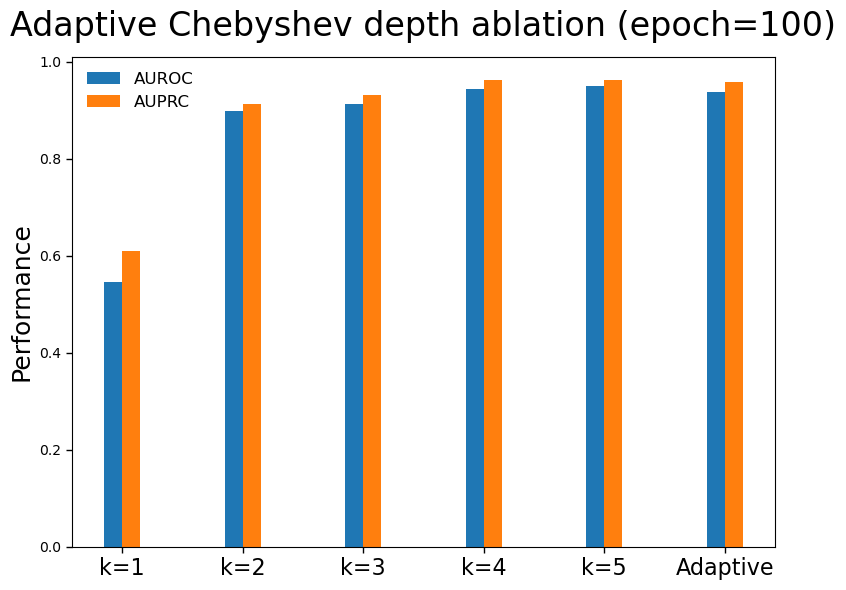

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [35]:
# ============================================================
# ABLATION:
# EFFECT OF ADAPTIVE CHEBYSHEV DEPTH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_ablation_model(
    model,
    graph,
    features,
    labels,
    train_mask,
    epochs=50,
    lr=1e-3
):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    for epoch in range(epochs):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # ----------------------------------------
    # Evaluate
    # ----------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN FIXED-k MODELS
# ============================================================

results = []

fixed_k_values = [1, 2, 3, 4, 5]

print("\nRunning fixed-k ablation...")

for k_val in fixed_k_values:

    print(f"\nEvaluating fixed k = {k_val}")

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=k_val,
        epsilon=0.0      # disables adaptive stopping
    )

    auc, aupr = run_ablation_model(
        model,
        graph,
        features,
        labels,
        train_mask,
        epochs=args.num_epochs,
        lr=args.learning_rate
    )

    results.append({
        "Model": f"k={k_val}",
        "AUROC": auc,
        "AUPRC": aupr
    })


# ============================================================
# ADAPTIVE MODEL
# ============================================================

print("\nEvaluating adaptive ACGNN")

adaptive_model = ACGNN(
    in_feats=in_feats,
    hidden_feats=hidden_feats,
    out_feats=1,
    k=5,                # maximum depth allowed
    epsilon=1e-4        # adaptive stopping
)

auc, aupr = run_ablation_model(
    adaptive_model,
    graph,
    features,
    labels,
    train_mask,
    epochs=args.num_epochs,
    lr=args.learning_rate
)

results.append({
    "Model": "Adaptive",
    "AUROC": auc,
    "AUPRC": aupr
})


# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

print("\nAblation Results")
display(ablation_df)

ablation_csv = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)


# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.15

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC"
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC"
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_title(
    f"Adaptive Chebyshev depth ablation (epoch={args.num_epochs})",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1
)

ax.legend(
    frameon=False,
    fontsize=12
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

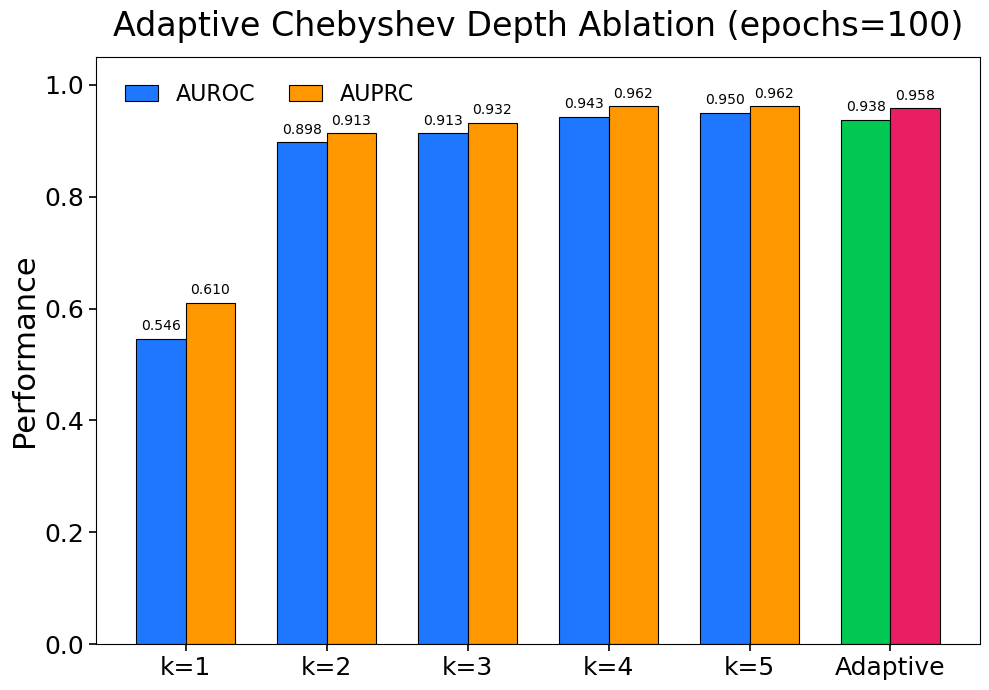

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [36]:
# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

x = np.arange(
    len(ablation_df)
)

width = 0.35

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

# ============================================================
# BRIGHT PUBLICATION COLORS
# ============================================================

colors_auc = [
    "#1F77FF",   # bright blue
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#00C853"    # bright green (Adaptive)
]

colors_aupr = [
    "#FF9800",   # bright orange
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#E91E63"    # bright magenta/red (Adaptive)
]

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=colors_auc,
    edgecolor="black",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=colors_aupr,
    edgecolor="black",
    linewidth=0.8
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars1:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

for bar in bars2:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=22
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Adaptive Chebyshev Depth Ablation (epochs={args.num_epochs})",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.2,
    labelsize=18
)

# ax.legend(
#     frameon=False,
#     fontsize=14,
#     loc="lower right"
# )

ax.legend(
    frameon=False,
    fontsize=16,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=2,
    handlelength=1.5,
    columnspacing=1.5
)

# # ------------------------------------------------------------
# # Grid
# # ------------------------------------------------------------

# ax.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.4
# )

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

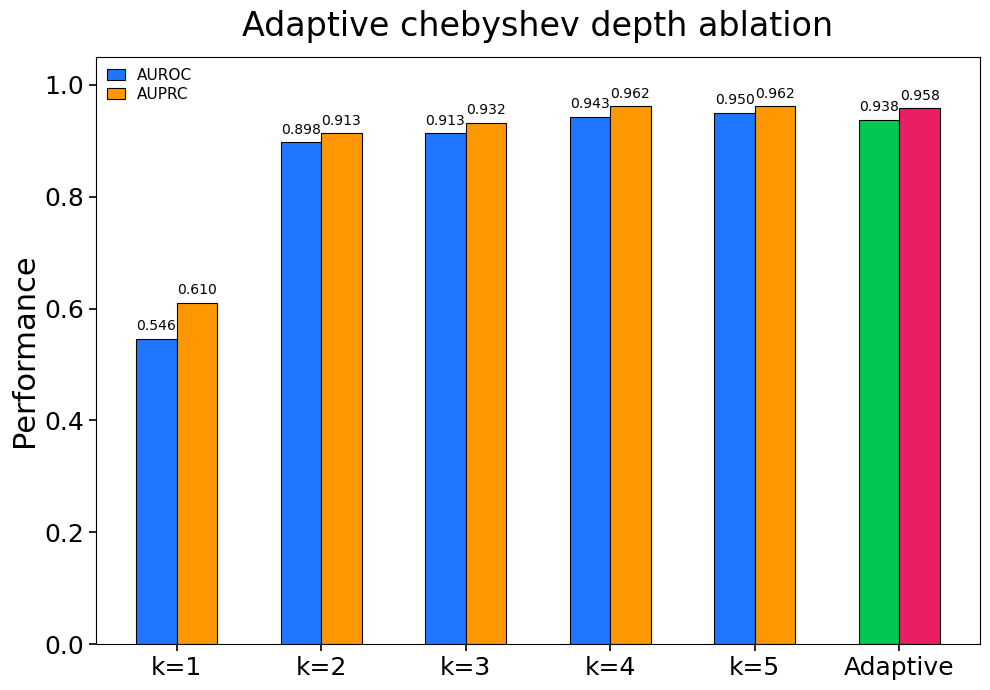

Saved: results/gene_prediction/ACGNN_depth_ablation.png


In [37]:
# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

x = np.arange(
    len(ablation_df)
)

width = 0.28

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

# ============================================================
# BRIGHT PUBLICATION COLORS
# ============================================================

colors_auc = [
    "#1F77FF",   # bright blue
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#1F77FF",
    "#00C853"    # bright green (Adaptive)
]

colors_aupr = [
    "#FF9800",   # bright orange
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#FF9800",
    "#E91E63"    # bright magenta/red (Adaptive)
]

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=colors_auc,
    edgecolor="black",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=colors_aupr,
    edgecolor="black",
    linewidth=0.8
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bar in bars1:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

for bar in bars2:

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=0
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=22
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    # f"Adaptive Chebyshev Depth Ablation (epochs={args.num_epochs})",
    f"Adaptive chebyshev depth ablation",
    fontsize=24,
    pad=15
)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.2,
    labelsize=18
)

# ax.legend(
#     frameon=False,
#     fontsize=14,
#     loc="lower right"
# )

# ax.legend(
#     frameon=False,
#     fontsize=16,
#     loc="upper left",
#     bbox_to_anchor=(0.01, 0.99),
#     ncol=2,
#     handlelength=1.5,
#     columnspacing=1.5
# )
ax.legend(
    frameon=False,
    fontsize=11,
    loc="upper left",
    ncol=1,
    handlelength=1.2,
    labelspacing=0.3,
    borderpad=0.2
)

# # ------------------------------------------------------------
# # Grid
# # ------------------------------------------------------------

# ax.grid(
#     axis="y",
#     linestyle="--",
#     alpha=0.4
# )

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_depth_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

Running baseline ACGNN...
Running ACGNN + GCL...


,Model,AUROC,AUPRC
0,ACGNN,0.933710,0.941112
1,ACGNN + GCL,0.943001,0.956044


Saved: results/gene_prediction/ACGNN_GCL_ablation.csv


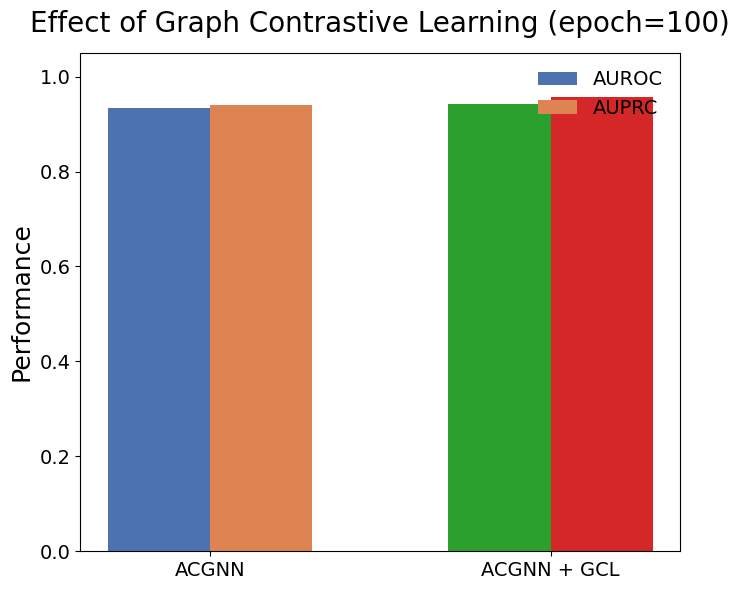

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


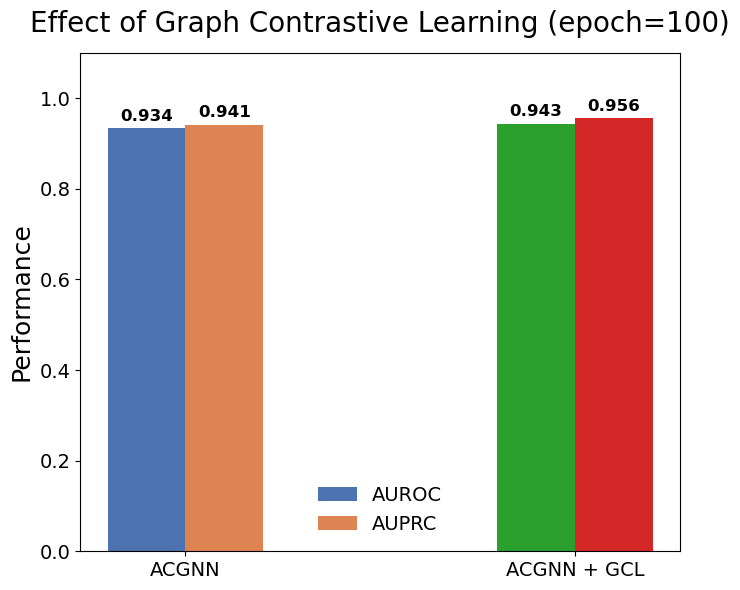

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


In [38]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Linear
from dgl.nn import SAGEConv, GATConv, GraphConv, GINConv, ChebConv
from torch_geometric.utils import dropout_edge, negative_sampling, remove_self_loops, add_self_loops
import math
from torch.nn import Parameter
import dgl
import dgl.function as fn
from dgl.nn.pytorch.conv import ChebConv


class ACGNN(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats,
        k=3,
        dropout=0.3,
        epsilon=1e-4
    ):
        super().__init__()

        # 🔹 SAVE ARCHITECTURE METADATA (for logging / CSV)
        self.in_feats = in_feats
        self.hidden_feats = hidden_feats
        self.out_feats = out_feats
        self.k = k
        self.dropout = dropout
        self.epsilon = epsilon

        # Chebyshev Convolution Layers
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.cheb3 = ChebConv(hidden_feats, hidden_feats, k)

        # Fully Connected Layer (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Batch Normalization
        self.norm = nn.BatchNorm1d(hidden_feats)

        # Dropout
        self.dropout_layer = nn.Dropout(dropout)

    def forward(
        self,
        graph,
        features,
        lambda_max=None,
        return_embeddings=False
    ):
        if lambda_max is None:
            lambda_max = dgl.laplacian_lambda_max(graph)

        x = F.relu(
            self.cheb1(
                graph,
                features,
                lambda_max=lambda_max
            )
        )
        x = self.norm(x)

        prev_x = x.clone()

        for _ in range(1, self.k):

            x_new = F.relu(
                self.cheb2(
                    graph,
                    x,
                    lambda_max=lambda_max
                )
            )

            if torch.norm(x_new - prev_x) < self.epsilon:
                break

            prev_x = x_new.clone()
            x = x_new

        x_res = x

        x = F.relu(
            self.cheb3(
                graph,
                x,
                lambda_max=lambda_max
            )
        )

        x = self.dropout_layer(x) + x_res

        embeddings = x

        logits = self.mlp(embeddings)

        if return_embeddings:
            return logits, embeddings

        return logits
    
    def get_config(self):
        return {
            "in_feats": self.in_feats,
            "hidden_feats": self.hidden_feats,
            "out_feats": self.out_feats,
            # "num_layers": self.num_layers,
        }



# ============================================================
# ABLATION:
# EFFECT OF GRAPH CONTRASTIVE LEARNING (GCL)
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupervisedContrastiveLoss(torch.nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):

        device = embeddings.device

        embeddings = F.normalize(
            embeddings,
            p=2,
            dim=1
        )

        similarity = torch.matmul(
            embeddings,
            embeddings.T
        )

        similarity = (
            similarity / self.temperature
        )

        labels = labels.view(-1, 1)

        positive_mask = (
            labels == labels.T
        ).float().to(device)

        diag = torch.eye(
            labels.shape[0],
            device=device
        )

        positive_mask = (
            positive_mask - diag
        )

        exp_sim = torch.exp(similarity)

        denominator = (
            exp_sim * (1 - diag)
        ).sum(
            dim=1,
            keepdim=True
        )

        log_prob = (
            similarity
            -
            torch.log(
                denominator + 1e-8
            )
        )

        mean_log_prob_pos = (
            positive_mask * log_prob
        ).sum(dim=1)

        mean_log_prob_pos = (
            mean_log_prob_pos
            /
            (
                positive_mask.sum(dim=1)
                + 1e-8
            )
        )

        loss = -mean_log_prob_pos.mean()

        return loss


# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_model(
    use_contrastive=False,
    lambda_cl=0.1
):

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=5,
        epsilon=1e-4
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    cls_loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    cl_loss_fn = (
        SupervisedContrastiveLoss(
            temperature=0.2
        )
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits, embeddings = model(
            graph,
            features,
            return_embeddings=True
        )

        logits = logits.squeeze()

        cls_loss = cls_loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        if use_contrastive:

            cl_loss = cl_loss_fn(
                embeddings[train_mask],
                labels[train_mask]
            )

            loss = (
                cls_loss
                +
                lambda_cl * cl_loss
            )

        else:

            cl_loss = torch.tensor(
                0.0,
                device=device
            )

            loss = cls_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN ABLATION
# ============================================================

results = []

print("Running baseline ACGNN...")

auc, aupr = run_model(
    use_contrastive=False
)

results.append({

    "Model":
        "ACGNN",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

print("Running ACGNN + GCL...")

auc, aupr = run_model(
    use_contrastive=True,
    lambda_cl=0.1
)

results.append({

    "Model":
        "ACGNN + GCL",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

display(
    ablation_df
)

ablation_csv = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.30

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Effect of Graph Contrastive Learning (epoch={args.num_epochs})",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)


num_nodes = graph.num_nodes()

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

x = np.arange(
    len(ablation_df)
)

# smaller bars
width = 0.20

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

# ============================================================
# ADD SCORES ON TOP OF BARS
# ============================================================

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.10
)

ax.set_title(
    "Effect of Graph Contrastive Learning (epoch=100)",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")

In [39]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================

import os
import time
import dgl
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# RELATIONSHIP FILES
# =========================================================

NETWORKS = {

    "ASPIRE_Pathway": (
        "../process/data/processed/"
        "gene_pairs_limit5000.csv"
    ),

    "CPDB": (
        "../process/data/processed/"
        "CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv"
    ),

    "HIPPIE": (
        "../process/data/processed/"
        "HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv"
    ),

    "STRING": (
        "../process/data/processed/"
        "STRING_ppi_950_with_gene_type_and_connected_driver_gene.csv"
    )
}


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n")
    print("="*60)
    print(network_name)
    print("="*60)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=
            source_csv_path,

        target_csv_path=
            target_csv_path,

        relation_csv_path=
            relation_file,

        max_edges_per_node=
            MAX_EDGES_PER_NODE
    )


    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = (
        embeddings_tensor
    )

    graph.ndata["label"] = (
        labels_tensor
    )

    train_mask = (
        labels_tensor != -1
    )

    graph.ndata[
        "train_mask"
    ] = train_mask

    graph = graph.to(device)

    features = (
        graph.ndata["feat"]
    )

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = (
        graph.ndata[
            "train_mask"
        ]
    )


    # =====================================================
    # MODEL
    # =====================================================

    in_feats = (
        features.shape[1]
    )

    model = choose_model(

        args.model_type,

        in_feats,

        args.hidden_feats,

        1

    ).to(device)


    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=args.learning_rate
    )


    loss_fn = FocalLoss(

        alpha=0.25,

        gamma=2
    )


    # =====================================================
    # TRAIN
    # =====================================================

    start = time.time()

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(

            logits[
                train_mask
            ],

            labels[
                train_mask
            ]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        if epoch % 10 == 0:

            print(

                f"Epoch={epoch} "
                f"Loss={loss.item():.4f}"
            )

    train_time = (
        time.time() - start
    )


    # =====================================================
    # EVALUATION
    # =====================================================

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

        pred = (
            probs > 0.5
        ).float()


    y_true = (

        labels[
            train_mask
        ]
        .cpu()
        .numpy()
    )

    y_score = (

        probs[
            train_mask
        ]
        .cpu()
        .numpy()
    )

    y_pred = (

        pred[
            train_mask
        ]
        .cpu()
        .numpy()
    )


    # =====================================================
    # METRICS
    # =====================================================

    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "AUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time
    }

    return result


# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(

        relation_file,
        network_name
    )

    results.append(
        result
    )


# =========================================================
# SAVE RESULTS
# =========================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print(results_df)

save_file = os.path.join(

    output_dir,

    "topology_ablation.csv"
)

results_df.to_csv(

    save_file,

    index=False
)



print(
    "\nSaved:",
    save_file
)



ASPIRE_Pathway

[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/225452 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/10430 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 225452

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/225452 [00:00<?, ?it/s]


[INFO] Skipped edges: 143104

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 4826
Edges: 82348
Embedding tensor shape: torch.Size([4826, 2688])
Labels tensor shape: torch.Size([4826])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Epoch=0 Loss=0.0435
Epoch=10 Loss=0.0272
Epoch=20 Loss=0.0059
Epoch=30 Loss=0.0001
Epoch=40 Loss=0.0000
Epoch=50 Loss=0.0000
Epoch=60 Loss=0.0000
Epoch=70 Loss=0.0000
Epoch=80 Loss=0.0000
Epoch=90 Loss=0.0000


          Network  Nodes   Edges  AUROC  AUPRC   F1  Accuracy  TrainTime
0  ASPIRE_Pathway   5809  238103    1.0    1.0  1.0       1.0  57.850137
1            CPDB   1196    7470    1.0    1.0  1.0       1.0  15.194935
2          HIPPIE   2272   15205    1.0    1.0  1.0       1.0  16.591725
3          STRING   4826   87174    1.0    1.0  1.0       1.0  31.388596

Saved: results/gene_prediction/topology_ablation.csv


In [40]:
# =========================================================
# FIX 1
# Independent split for each network
# =========================================================

from sklearn.model_selection import train_test_split

def build_masks(labels_tensor):

    labeled_idx = torch.where(
        labels_tensor != -1
    )[0]

    labeled_labels = labels_tensor[
        labeled_idx
    ].cpu().numpy()

    train_idx_np, temp_idx_np = train_test_split(
        labeled_idx.cpu().numpy(),
        test_size=0.40,
        stratify=labeled_labels,
        random_state=42
    )

    temp_labels = labels_tensor[
        temp_idx_np
    ].cpu().numpy()

    val_idx_np, test_idx_np = train_test_split(
        temp_idx_np,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )

    train_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        len(labels_tensor),
        dtype=torch.bool
    )

    train_mask[train_idx_np] = True
    val_mask[val_idx_np] = True
    test_mask[test_idx_np] = True

    return (
        train_mask,
        val_mask,
        test_mask
    )

In [41]:
# # =========================================================
# # TOPOLOGY ABLATION:
# # Pathway-informed vs PPI networks
# # =========================================================


# import os
# import time
# import copy
# import dgl
# import torch
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import train_test_split

# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
#     f1_score,
#     accuracy_score
# )

# # =========================================================
# # NETWORK FILES
# # =========================================================

# NETWORKS = {

#     "ASPIRE_Pathway":
#         "../process/data/processed/gene_pairs_limit5000.csv",

#     "CPDB":
#         "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

#     "HIPPIE":
#         "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

#     "STRING":
#         "../process/data/processed/STRING_ppi_950_with_gene_type_and_connected_driver_gene.csv"
# }

# # =========================================================
# # GLOBAL SPLIT
# # (same split for every network)
# # =========================================================

# (
#     nodes0,
#     edges0,
#     embeddings0,
#     labels0
# ) = load_graph_data_directly(

#     source_csv_path=source_csv_path,
#     target_csv_path=target_csv_path,
#     relation_csv_path=NETWORKS["ASPIRE_Pathway"],
#     max_edges_per_node=MAX_EDGES_PER_NODE
# )

# labeled_idx = torch.where(
#     labels0 != -1
# )[0]

# labeled_labels = labels0[
#     labeled_idx
# ].cpu().numpy()

# train_idx_np, temp_idx_np = train_test_split(
#     labeled_idx.cpu().numpy(),
#     test_size=0.40,
#     stratify=labeled_labels,
#     random_state=42
# )

# temp_labels = labels0[
#     temp_idx_np
# ].cpu().numpy()

# val_idx_np, test_idx_np = train_test_split(
#     temp_idx_np,
#     test_size=0.50,
#     stratify=temp_labels,
#     random_state=42
# )

# train_idx = torch.tensor(
#     train_idx_np,
#     dtype=torch.long
# )

# val_idx = torch.tensor(
#     val_idx_np,
#     dtype=torch.long
# )

# test_idx = torch.tensor(
#     test_idx_np,
#     dtype=torch.long
# )

# print(
#     f"Train={len(train_idx)} "
#     f"Val={len(val_idx)} "
#     f"Test={len(test_idx)}"
# )

# # =========================================================
# # TRAIN FUNCTION
# # =========================================================

# def train_one_network(
#     relation_file,
#     network_name
# ):

#     print("\n" + "="*70)
#     print(network_name)
#     print("="*70)

#     (
#         nodes,
#         edges,
#         embeddings_tensor,
#         labels_tensor
#     ) = load_graph_data_directly(

#         source_csv_path=source_csv_path,
#         target_csv_path=target_csv_path,
#         relation_csv_path=relation_file,
#         max_edges_per_node=MAX_EDGES_PER_NODE
#     )

#     # =====================================================
#     # GRAPH
#     # =====================================================

#     graph = dgl.graph(edges)

#     graph = dgl.add_self_loop(
#         graph
#     )

#     graph.ndata["feat"] = embeddings_tensor
#     graph.ndata["label"] = labels_tensor

#     train_mask = torch.zeros(
#         len(labels_tensor),
#         dtype=torch.bool
#     )

#     val_mask = torch.zeros(
#         len(labels_tensor),
#         dtype=torch.bool
#     )

#     test_mask = torch.zeros(
#         len(labels_tensor),
#         dtype=torch.bool
#     )

#     train_mask[train_idx] = True
#     val_mask[val_idx] = True
#     test_mask[test_idx] = True

#     train_mask, val_mask, test_mask = build_masks(
#         labels_tensor
#     )

#     graph.ndata["train_mask"] = train_mask
#     graph.ndata["val_mask"] = val_mask
#     graph.ndata["test_mask"] = test_mask


#     graph = graph.to(device)

#     features = graph.ndata["feat"]

#     labels = (
#         graph.ndata["label"]
#         .float()
#     )

#     train_mask = graph.ndata["train_mask"]
#     val_mask = graph.ndata["val_mask"]
#     test_mask = graph.ndata["test_mask"]

#     # =====================================================
#     # MODEL
#     # =====================================================

#     in_feats = features.shape[1]

#     model = choose_model(
#         args.model_type,
#         in_feats,
#         args.hidden_feats,
#         1
#     ).to(device)

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=args.learning_rate
#     )

#     loss_fn = FocalLoss(
#         alpha=0.25,
#         gamma=2
#     )

#     # =====================================================
#     # TRAIN + EARLY STOP
#     # =====================================================

#     best_val_auc = 0

#     best_state = None

#     patience = 20

#     counter = 0

#     start_time = time.time()

#     for epoch in range(300):

#         model.train()

#         logits = model(
#             graph,
#             features
#         ).squeeze()

#         loss = loss_fn(
#             logits[train_mask],
#             labels[train_mask]
#         )

#         optimizer.zero_grad()

#         loss.backward()

#         optimizer.step()

#         # ------------------------------------------
#         # Validation
#         # ------------------------------------------

#         model.eval()

#         with torch.no_grad():

#             val_probs = torch.sigmoid(
#                 model(
#                     graph,
#                     features
#                 ).squeeze()
#             )

#         val_auc = roc_auc_score(
#             labels[val_mask].cpu().numpy(),
#             val_probs[val_mask].cpu().numpy()
#         )

#         if val_auc > best_val_auc:

#             best_val_auc = val_auc

#             best_state = copy.deepcopy(
#                 model.state_dict()
#             )

#             counter = 0

#         else:

#             counter += 1

#         if epoch % 10 == 0:

#             print(
#                 f"Epoch={epoch} "
#                 f"Loss={loss.item():.4f} "
#                 f"ValAUROC={val_auc:.4f}"
#             )

#         if counter >= patience:

#             print(
#                 f"Early stopping at epoch {epoch}"
#             )

#             break

#     train_time = (
#         time.time() - start_time
#     )

#     # =====================================================
#     # RESTORE BEST MODEL
#     # =====================================================

#     model.load_state_dict(
#         best_state
#     )

#     # =====================================================
#     # TEST
#     # =====================================================

#     model.eval()

#     with torch.no_grad():

#         probs = torch.sigmoid(
#             model(
#                 graph,
#                 features
#             ).squeeze()
#         )

#     y_true = (
#         labels[test_mask]
#         .cpu()
#         .numpy()
#     )

#     y_score = (
#         probs[test_mask]
#         .cpu()
#         .numpy()
#     )

#     y_pred = (
#         y_score > 0.5
#     ).astype(int)

#     # =====================================================
#     # GRAPH STATS
#     # =====================================================

#     avg_degree = (
#         graph.in_degrees()
#         .float()
#         .mean()
#         .item()
#     )

#     density = (
#         graph.number_of_edges()
#         /
#         (graph.number_of_nodes()**2)
#     )

#     # =====================================================
#     # RESULTS
#     # =====================================================

#     result = {

#         "Network":
#             network_name,

#         "Nodes":
#             graph.number_of_nodes(),

#         "Edges":
#             graph.number_of_edges(),

#         "AvgDegree":
#             avg_degree,

#         "Density":
#             density,

#         "ValAUROC":
#             best_val_auc,

#         "TestAUROC":
#             roc_auc_score(
#                 y_true,
#                 y_score
#             ),

#         "TestAUPRC":
#             average_precision_score(
#                 y_true,
#                 y_score
#             ),

#         "F1":
#             f1_score(
#                 y_true,
#                 y_pred
#             ),

#         "Accuracy":
#             accuracy_score(
#                 y_true,
#                 y_pred
#             ),

#         "TrainTime":
#             train_time
#     }

#     return result

# # =========================================================
# # RUN ABLATION
# # =========================================================

# results = []

# for network_name, relation_file in NETWORKS.items():

#     result = train_one_network(
#         relation_file,
#         network_name
#     )

#     results.append(
#         result
#     )

# # =========================================================
# # SAVE
# # =========================================================

# results_df = pd.DataFrame(
#     results
# )

# results_df = results_df.sort_values(
#     "TestAUROC",
#     ascending=False
# )

# print("\n")
# print(results_df)

# save_file = os.path.join(
#     output_dir,
#     "topology_ablation.csv"
# )

# results_df.to_csv(
#     save_file,
#     index=False
# )

# print(
#     "\nSaved:",
#     save_file
# )

# display(results_df)

In [42]:
# =========================================================
# LOAD FIXED NODE SET
# =========================================================

import torch
import numpy as np
from sklearn.model_selection import train_test_split

loaded_graph = torch.load(
    SAVE_GRAPH_PATH
)

nodes = loaded_graph["nodes"]

edges = loaded_graph["edges"]

embeddings_tensor = loaded_graph[
    "embeddings_tensor"
]

labels_tensor = loaded_graph[
    "labels_tensor"
]

print("Nodes:", len(nodes))
print("Features:", embeddings_tensor.shape)

# =========================================================
# GLOBAL TRAIN / VAL / TEST SPLIT
# =========================================================

labeled_idx = torch.where(
    labels_tensor != -1
)[0]

labeled_labels = labels_tensor[
    labeled_idx
].cpu().numpy()

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx.cpu().numpy(),
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

temp_labels = labels_tensor[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

train_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(labels_tensor),
    dtype=torch.bool
)

train_mask[train_idx_np] = True
val_mask[val_idx_np] = True
test_mask[test_idx_np] = True

print(
    f"Train={train_mask.sum().item()} "
    f"Val={val_mask.sum().item()} "
    f"Test={test_mask.sum().item()}"
)

Nodes: 4826
Features: torch.Size([4826, 2688])
Train=354 Val=118 Test=118


In [43]:
# =========================================================
# LOAD ONLY EDGES
# =========================================================

import pandas as pd

def load_edge_list(
    relation_file,
    node_to_idx
):

    df = pd.read_csv(
        relation_file
    )

    src = []
    dst = []

    for _, row in df.iterrows():

        g1 = row.iloc[0]
        g2 = row.iloc[1]

        if (
            g1 in node_to_idx
            and
            g2 in node_to_idx
        ):

            src.append(
                node_to_idx[g1]
            )

            dst.append(
                node_to_idx[g2]
            )

    return (
        np.array(src),
        np.array(dst)
    )

In [44]:
NETWORKS = {

    "ASPIRE_Pathway":
    "../process/data/processed/gene_pairs_limit5000.csv",

    "CPDB":
    "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    "HIPPIE":
    "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
    "../process/data/processed/STRING_ppi_950_with_gene_type_and_connected_driver_gene.csv"
}

In [45]:
# =========================================================
# TRAIN ONE NETWORK
# =========================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score
)

def train_one_network(
    relation_file,
    network_name
):

    print("\n")
    print("="*60)
    print(network_name)
    print("="*60)

    node_to_idx = {

        node:i

        for i,node in enumerate(nodes)
    }

    src, dst = load_edge_list(
        relation_file,
        node_to_idx
    )

    graph = dgl.graph(
        (src,dst),
        num_nodes=len(nodes)
    )

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = (
        embeddings_tensor
    )

    graph.ndata["label"] = (
        labels_tensor
    )

    graph.ndata["train_mask"] = (
        train_mask
    )

    graph.ndata["val_mask"] = (
        val_mask
    )

    graph.ndata["test_mask"] = (
        test_mask
    )

    graph = graph.to(device)

    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    # =====================================================
    # MODEL
    # =====================================================

    model = choose_model(
        args.model_type,
        embeddings_tensor.shape[1],
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    best_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    # =====================================================
    # TRAIN
    # =====================================================

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[
                train_mask.to(device)
            ],
            labels[
                train_mask.to(device)
            ]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------
        # validation
        # ------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        print(
            "NaN logits:",
            torch.isnan(logits).sum().item()
        )

        print(
            "NaN probs:",
            torch.isnan(val_probs).sum().item()
        )

        print(
            "NaN features:",
            torch.isnan(features).sum().item()
        )

        print(
            "NaN labels:",
            torch.isnan(labels).sum().item()
        )



        val_auc = roc_auc_score(
            labels[
                val_mask.to(device)
            ].cpu().numpy(),

            val_probs[
                val_mask.to(device)
            ].cpu().numpy()
        )

        if val_auc > best_auc:

            best_auc = val_auc

            best_state = model.state_dict()

            counter = 0

        else:

            counter += 1

        if counter >= patience:

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # TEST
    # =====================================================

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = labels[
        test_mask.to(device)
    ].cpu().numpy()

    y_score = probs[
        test_mask.to(device)
    ].cpu().numpy()

    y_pred = (
        y_score > 0.5
    ).astype(int)

    return {

        "Network":
        network_name,

        "Nodes":
        graph.number_of_nodes(),

        "Edges":
        graph.number_of_edges(),

        "AvgDegree":
        graph.in_degrees()
        .float()
        .mean()
        .item(),

        "Density":
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2),

        "ValAUROC":
        best_auc,

        "TestAUROC":
        roc_auc_score(
            y_true,
            y_score
        ),

        "TestAUPRC":
        average_precision_score(
            y_true,
            y_score
        ),

        "F1":
        f1_score(
            y_true,
            y_pred
        ),

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "TrainTime":
        train_time
    }

In [46]:
# results = []

# for network_name, relation_file in NETWORKS.items():

#     result = train_one_network(
#         relation_file,
#         network_name
#     )

#     results.append(result)

# results_df = pd.DataFrame(
#     results
# )

# results_df = results_df.sort_values(
#     "TestAUROC",
#     ascending=False
# )

# display(results_df)

# results_df.to_csv(
#     os.path.join(
#         output_dir,
#         "topology_ablation.csv"
#     ),
#     index=False
# )

In [47]:
# =========================================================
# COMMON NODE SET
# =========================================================

common_nodes = None

network_nodes = {}

for network_name, relation_file in NETWORKS.items():

    (
        nodes,
        edges,
        embeddings,
        labels
    ) = load_graph_data_directly(
        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    if isinstance(nodes, dict):
        node_names = set(nodes.keys())
    else:
        node_names = set(nodes)

    network_nodes[network_name] = node_names

    if common_nodes is None:
        common_nodes = node_names
    else:
        common_nodes = (
            common_nodes &
            node_names
        )

print(
    "Common genes:",
    len(common_nodes)
)

# =========================================================
# GLOBAL SPLIT
# =========================================================

(
    nodes,
    edges,
    embeddings,
    labels
) = load_graph_data_directly(
    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["ASPIRE_Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

if isinstance(nodes, dict):
    node_names = list(nodes.keys())
else:
    node_names = list(nodes)

node_to_idx = {
    n:i
    for i,n in enumerate(node_names)
}

common_idx = np.array([
    node_to_idx[g]
    for g in common_nodes
    if g in node_to_idx
])

common_labels = labels[
    common_idx
]

labeled_mask = (
    common_labels != -1
)

labeled_idx = common_idx[
    labeled_mask.cpu().numpy()
]

labeled_labels = labels[
    labeled_idx
].cpu().numpy()

train_idx_np, temp_idx_np = train_test_split(
    labeled_idx,
    test_size=0.40,
    stratify=labeled_labels,
    random_state=42
)

temp_labels = labels[
    temp_idx_np
].cpu().numpy()

val_idx_np, test_idx_np = train_test_split(
    temp_idx_np,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

GLOBAL_TRAIN_GENES = set(
    train_idx_np.tolist()
)

GLOBAL_VAL_GENES = set(
    val_idx_np.tolist()
)

GLOBAL_TEST_GENES = set(
    test_idx_np.tolist()
)

print(
    len(GLOBAL_TRAIN_GENES),
    len(GLOBAL_VAL_GENES),
    len(GLOBAL_TEST_GENES)
)




[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/490438 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/9080 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 490438

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/490438 [00:00<?, ?it/s]


[INFO] Skipped edges: 258144

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5809
Edges: 232294
Embedding tensor shape: torch.Size([5809, 2688])
Labels tensor shape: torch.Size([5809])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
458 153 153


In [48]:
# ============================================================
# BUILD STRING GENE NETWORK FOR ASPIRE-GNN
# KEEP ALL STRING EDGES
# DRIVER = 1, ALL OTHERS = 0
# ============================================================

import pandas as pd
import networkx as nx

# ============================================================
# INPUT FILES
# ============================================================

STRING_LINKS = (
    "../data/string/9606.protein.links.v12.0.txt.gz"
)

STRING_INFO = (
    "../data/string/9606.protein.info.v12.0.txt.gz"
)

DRIVER_FILE = (
    "../data/processed/763_driver_genes.txt"
)

OUTPUT_NETWORK = (
    "../data/processed/STRING_gene_network.csv"
)

OUTPUT_NODES = (
    "../data/processed/STRING_node_labels.csv"
)

MIN_SCORE = 400

# ============================================================
# LOAD DRIVER GENES
# ============================================================

drivers = set(
    pd.read_table(
        DRIVER_FILE,
        header=None
    )[0]
    .astype(str)
    .str.upper()
)

print(
    f"Driver genes: {len(drivers)}"
)

# ============================================================
# LOAD STRING INFO
# ============================================================

print("\nLoading STRING info...")

info_df = pd.read_csv(
    STRING_INFO,
    sep="\t"
)

print(
    "Protein info shape:",
    info_df.shape
)

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

# ============================================================
# LOAD STRING LINKS
# ============================================================

print("\nLoading STRING links...")

links_df = pd.read_csv(
    STRING_LINKS,
    sep=" "
)

print(
    "Raw STRING links:",
    links_df.shape
)

# ============================================================
# HIGH-CONFIDENCE FILTER
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "Edges after score filter:",
    len(links_df)
)

# ============================================================
# MAP PROTEIN IDS -> GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df["Gene1"] = (
    links_df["Gene1"]
    .astype(str)
    .str.upper()
)

links_df["Gene2"] = (
    links_df["Gene2"]
    .astype(str)
    .str.upper()
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Mapped interactions:",
    len(links_df)
)

# ============================================================
# REMOVE DUPLICATE GENE PAIRS
# KEEP HIGHEST SCORE
# ============================================================

links_df["pair"] = links_df.apply(
    lambda r: tuple(
        sorted(
            [r["Gene1"], r["Gene2"]]
        )
    ),
    axis=1
)

links_df = (
    links_df
    .sort_values(
        "combined_score",
        ascending=False
    )
    # .drop_duplicates(
    #     subset="pair"
    # )
)

print(
    "Unique gene-gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    # G.add_edge(
    #     row["Gene1"],
    #     row["Gene2"],
    #     weight=row["combined_score"]
    # )
    if G.has_edge(
        row["Gene1"],
        row["Gene2"]
    ):

        G[row["Gene1"]][row["Gene2"]]["weight"] += (
            row["combined_score"]
        )

    else:

        G.add_edge(
            row["Gene1"],
            row["Gene2"],
            weight=row["combined_score"]
        )


print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# # ============================================================
# # OPTIONAL:
# # KEEP LARGEST CONNECTED COMPONENT
# # ============================================================

# largest_cc = max(
#     nx.connected_components(G),
#     key=len
# )

# G = G.subgraph(
#     largest_cc
# ).copy()

# print(
#     "\nLargest CC Nodes:",
#     G.number_of_nodes()
# )

# print(
#     "Largest CC Edges:",
#     G.number_of_edges()
# )


# ============================================================
# EDGE FILE
# gene_type = 1 if either endpoint is a driver
# ============================================================

edge_rows = []

for u, v, data in G.edges(data=True):

    edge_label = int(
        (u in drivers) or
        (v in drivers)
    )

    edge_rows.append({

        "Gene1": u,

        "Gene2": v,

        "gene_type": edge_label,

        "weight": data.get(
            "weight",
            1
        )
    })

edge_df = pd.DataFrame(
    edge_rows
)

print(
    "\nEdge table shape:"
)

print(
    edge_df.shape
)

print(
    edge_df.head()
)

print(
    "\nPositive edges:",
    edge_df["gene_type"].sum()
)

print(
    "Negative edges:",
    len(edge_df)
    -
    edge_df["gene_type"].sum()
)

# ============================================================
# SAVE EDGE FILE
# ============================================================

edge_df.to_csv(
    OUTPUT_NETWORK,
    index=False
)

print(
    "\nSaved edge file:"
)

print(
    OUTPUT_NETWORK
)

# ============================================================
# NODE LABEL FILE
# ============================================================

node_rows = []

for gene in sorted(
    G.nodes()
):

    node_rows.append({

        "Gene": gene,

        "gene_type":
            int(gene in drivers)

    })

node_df = pd.DataFrame(
    node_rows
)

node_df.to_csv(
    OUTPUT_NODES,
    index=False
)

print(
    "\nSaved node file:"
)

print(
    OUTPUT_NODES
)

# ============================================================
# SUMMARY
# ============================================================

num_drivers = (
    node_df["gene_type"]
    .sum()
)

num_non_drivers = (
    len(node_df)
    -
    num_drivers
)

print("\n===================================")

print(
    "STRING Network Summary"
)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

print(
    "Driver nodes:",
    num_drivers
)

print(
    "Other nodes:",
    num_non_drivers
)

print(
    "Driver ratio:",
    round(
        num_drivers / len(node_df),
        4
    )
)

print("===================================")

Driver genes: 763

Loading STRING info...
Protein info shape: (19699, 4)

Loading STRING links...
Raw STRING links: (13715404, 3)
Edges after score filter: 1858944
Mapped interactions: 1858944
Unique gene-gene interactions: 1858944

Building graph...
Nodes: 19488
Edges: 929472

Edge table shape:
(929472, 4)
   Gene1  Gene2  gene_type  weight
0  RPL35  RPS10          0    1998
1  RPL35  RPL29          0    1998
2  RPL35  RPS16          0    1998
3  RPL35  RPLP2          0    1998
4  RPL35   EEF2          0    1998

Positive edges: 166161
Negative edges: 763311

Saved edge file:
../data/processed/STRING_gene_network.csv

Saved node file:
../data/processed/STRING_node_labels.csv

STRING Network Summary
Nodes: 19488
Edges: 929472
Driver nodes: 746
Other nodes: 18742
Driver ratio: 0.0383



[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=2193 Val=721 Test=743
Epoch=0 Loss=0.0493 ValAUROC=0.3059
Epoch=10 Loss=0.0186 ValAUROC=0.3099
Epoch=20 Loss=0.0154 ValAUROC=0.4227
Epoch=30 Loss=0.0133 ValAUROC=0.7134
Epoch=40 Loss=0.0108 ValAUROC=0.7231
Epoch=50 Loss=0.0069 ValAUROC=0.6822
Epoch=60 Loss=0.0031 ValAUROC=0.6765
Epoch=70 Loss=0.0007 ValAUROC=0.6980
Epoch=80 Loss=0.0001 ValAUROC=0.7075
Early stopping at epoch 88


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5809  238103  40.988640  0.007056   0.93646   0.937349   
1   STRING   6642  437139  65.814362  0.009909   0.74013   0.750702   

   TestAUPRC        F1  Accuracy   TrainTime  
0   0.944833  0.884400   0.87439   55.151183  
1   0.303314  0.3

,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5809,238103,40.988640,0.007056,0.93646,0.937349,0.944833,0.884400,0.87439,55.151183
1,STRING,6642,437139,65.814362,0.009909,0.74013,0.750702,0.303314,0.314607,0.91790,114.508549


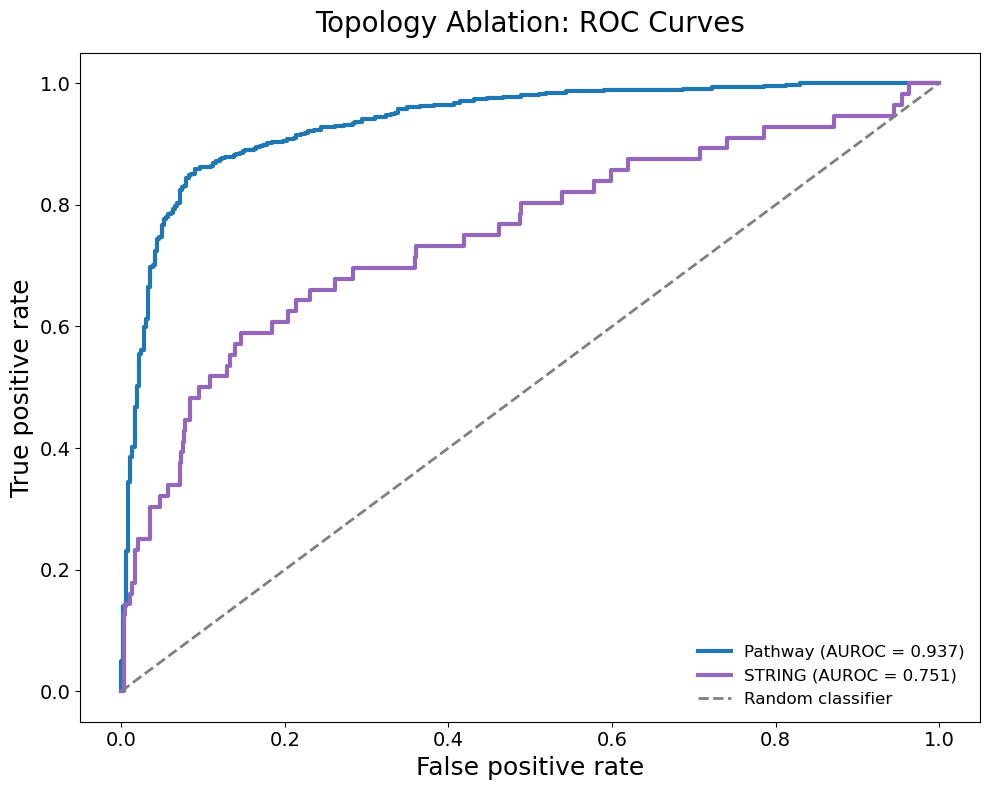

Saved ROC curve: results/gene_prediction/topology_ablation_ROC.png


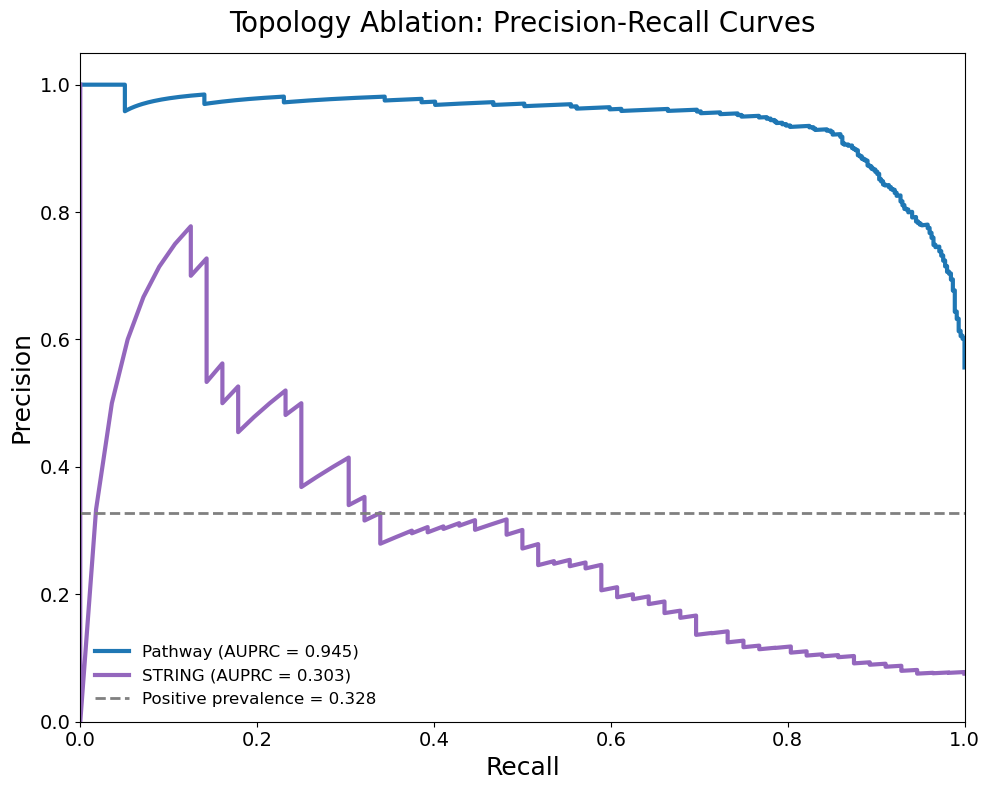

Saved precision-recall curve: results/gene_prediction/topology_ablation_PR.png


,Network,Test_AUROC,Test_AUPRC,Test_PositiveRate,TestSamples
0,Pathway,0.937349,0.944833,0.556098,820
1,STRING,0.750702,0.303314,0.075370,743


Saved curve metrics: results/gene_prediction/topology_ablation_curve_metrics.csv
Saved: results/gene_prediction/topology_ablation_ROC.png


In [ ]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on  genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# NETWORK-SPECIFIC TRAINING EPOCHS
# =========================================================

NETWORK_EPOCHS = {
    "ASPIRE_Pathway": args.num_epochs,
    "CPDB": args.num_epochs * 2,   # double epochs for CPDB
    "HIPPIE": args.num_epochs,
    "STRING": args.num_epochs,
}

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

# from sklearn.metrics import (
#     roc_curve,
#     auc
# )

# plt.figure(
#     figsize=(10,8)
# )

# for r in results:

#     fpr, tpr, _ = roc_curve(
#         r["y_true"],
#         r["y_score"]
#     )

#     roc_auc = auc(
#         fpr,
#         tpr
#     )

#     plt.plot(
#         fpr,
#         tpr,
#         linewidth=3,
#         label=(
#             f"{r['Network']} "
#             f"(AUROC={roc_auc:.3f})"
#         )
#     )

# # diagonal
# plt.plot(
#     [0, 1],
#     [0, 1],
#     linestyle="--",
#     color="#00C853",   # bright green
#     linewidth=2.5,
#     label="Random classifier"
# )

# plt.xlabel(
#     "False positive rate",
#     fontsize=18
# )

# plt.ylabel(
#     "True positive rate",
#     fontsize=18
# )

# plt.title(
#     "Topology ablation",
#     fontsize=20,
#     pad=15
# )

# plt.xticks(
#     fontsize=14
# )

# plt.yticks(
#     fontsize=14
# )

# plt.legend(
#     fontsize=12,
#     frameon=False
# )

# # plt.grid(
# #     alpha=0.25
# # )

# plt.tight_layout()

# roc_file = os.path.join(
#     output_dir,
#     "topology_ablation_ROC.png"
# )

# plt.savefig(
#     roc_file,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

# =========================================================
# TEST ROC + PRECISION-RECALL CURVES
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ---------------------------------------------------------
# Optional: fixed colors for consistent network comparison
# ---------------------------------------------------------

# NETWORK_COLORS = {
#     "Pathway": "#1f77b4",
#     "ASPIRE_Pathway": "#1f77b4",
#     "CPDB": "#d62728",
#     "HIPPIE": "#2ca02c",
#     "STRING": "#9467bd"
# }
NETWORK_COLORS = {
    "PISGE": "#2ca02c",
    "STRING": "#9467bd"
}
# =========================================================
# VALIDATE STORED TEST OUTPUTS
# =========================================================

valid_results = []

for r in results:

    y_true = np.asarray(r["y_true"]).astype(int)
    y_score = np.asarray(r["y_score"]).astype(float)

    # Remove NaN or infinite scores before plotting
    valid_mask = (
        np.isfinite(y_true) &
        np.isfinite(y_score)
    )

    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    # ROC and PR curves require both classes in the test split
    if len(np.unique(y_true)) < 2:
        print(
            f"[WARNING] Skipping {r['Network']}: "
            "test set contains only one class."
        )
        continue

    valid_results.append({
        "Network": r["Network"],
        "y_true": y_true,
        "y_score": y_score
    })

if len(valid_results) == 0:
    raise ValueError(
        "No valid networks available for ROC/PR plotting. "
        "Check that each test split contains both positive and negative labels."
    )

# =========================================================
# ROC CURVE
# =========================================================

plt.figure(figsize=(10, 8))

for r in valid_results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        color=NETWORK_COLORS.get(
            r["Network"],
            None
        ),
        label=(
            f"{r['Network']} "
            f"(AUROC = {roc_auc:.3f})"
        )
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Random classifier"
)

plt.xlabel(
    "False positive rate",
    fontsize=18
)

plt.ylabel(
    "True positive rate",
    fontsize=18
)

plt.title(
    # "Topology ablation: ROC curves",
    "Topology comparison",
    fontsize=20,
    pad=15
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    fontsize=12,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved ROC curve:", roc_file)

# =========================================================
# PRECISION-RECALL CURVE
# =========================================================

plt.figure(figsize=(10, 8))

for r in valid_results:

    precision, recall, _ = precision_recall_curve(
        r["y_true"],
        r["y_score"]
    )

    auprc = average_precision_score(
        r["y_true"],
        r["y_score"]
    )

    plt.plot(
        recall,
        precision,
        linewidth=3,
        color=NETWORK_COLORS.get(
            r["Network"],
            None
        ),
        label=(
            f"{r['Network']} "
            f"(AUPRC = {auprc:.3f})"
        )
    )

# Positive-class prevalence baseline
all_y_true = np.concatenate([
    r["y_true"]
    for r in valid_results
])

positive_rate = np.mean(all_y_true)

plt.axhline(
    y=positive_rate,
    linestyle="--",
    color="gray",
    linewidth=2,
    label=(
        f"Positive prevalence = "
        f"{positive_rate:.3f}"
    )
)

plt.xlabel(
    "Recall",
    fontsize=18
)

plt.ylabel(
    "Precision",
    fontsize=18
)

plt.title(
    # "Topology Ablation: Precision-Recall Curves",
    "Topology ablation: Precision-recall curves",
    fontsize=20,
    pad=15
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    fontsize=12,
    frameon=False,
    loc="lower left"
)

plt.tight_layout()

pr_file = os.path.join(
    output_dir,
    "topology_ablation_PR.png"
)

plt.savefig(
    pr_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved precision-recall curve:", pr_file)

# =========================================================
# CURVE METRICS TABLE
# =========================================================

curve_metrics = []

for r in valid_results:

    curve_metrics.append({
        "Network": r["Network"],
        "Test_AUROC": roc_auc_score(
            r["y_true"],
            r["y_score"]
        ),
        "Test_AUPRC": average_precision_score(
            r["y_true"],
            r["y_score"]
        ),
        "Test_PositiveRate": np.mean(
            r["y_true"]
        ),
        "TestSamples": len(
            r["y_true"]
        )
    })

curve_metrics_df = pd.DataFrame(
    curve_metrics
).sort_values(
    "Test_AUROC",
    ascending=False
)

display(curve_metrics_df)

curve_metrics_file = os.path.join(
    output_dir,
    "topology_ablation_curve_metrics.csv"
)

curve_metrics_df.to_csv(
    curve_metrics_file,
    index=False
)

print("Saved curve metrics:", curve_metrics_file)


print(
    "Saved:",
    roc_file
)


Saved threshold sensitivity table: results/gene_prediction/topology_ablation_threshold_sensitivity.csv


,Network,Threshold,Precision,Recall,Sensitivity,Specificity,F1,Accuracy,BalancedAccuracy,MCC,TP,TN,FP,FN,PredictedPositive,PredictedNegative
0,Pathway,0.05,0.557457,1.0,1.0,0.005495,0.715856,0.558537,0.502747,0.055344,456,2,362,0,818,2
1,Pathway,0.06,0.558140,1.0,1.0,0.008242,0.716418,0.559756,0.504121,0.067824,456,3,361,0,817,3
2,Pathway,0.07,0.558140,1.0,1.0,0.008242,0.716418,0.559756,0.504121,0.067824,456,3,361,0,817,3
3,Pathway,0.08,0.558824,1.0,1.0,0.010989,0.716981,0.560976,0.505495,0.078364,456,4,360,0,816,4
4,Pathway,0.09,0.562269,1.0,1.0,0.024725,0.719811,0.567073,0.512363,0.117908,456,9,355,0,811,9



Best F1 threshold per network:


,Network,Threshold,F1,Precision,Recall,Specificity,BalancedAccuracy,MCC,TP,TN,FP,FN
0,Pathway,0.54,0.889898,0.922353,0.859649,0.909341,0.884495,0.764646,392,331,33,64
1,STRING,0.20,0.382979,0.317647,0.482143,0.915575,0.698859,0.329856,27,629,58,29



Saved best thresholds: results/gene_prediction/topology_ablation_best_thresholds.csv


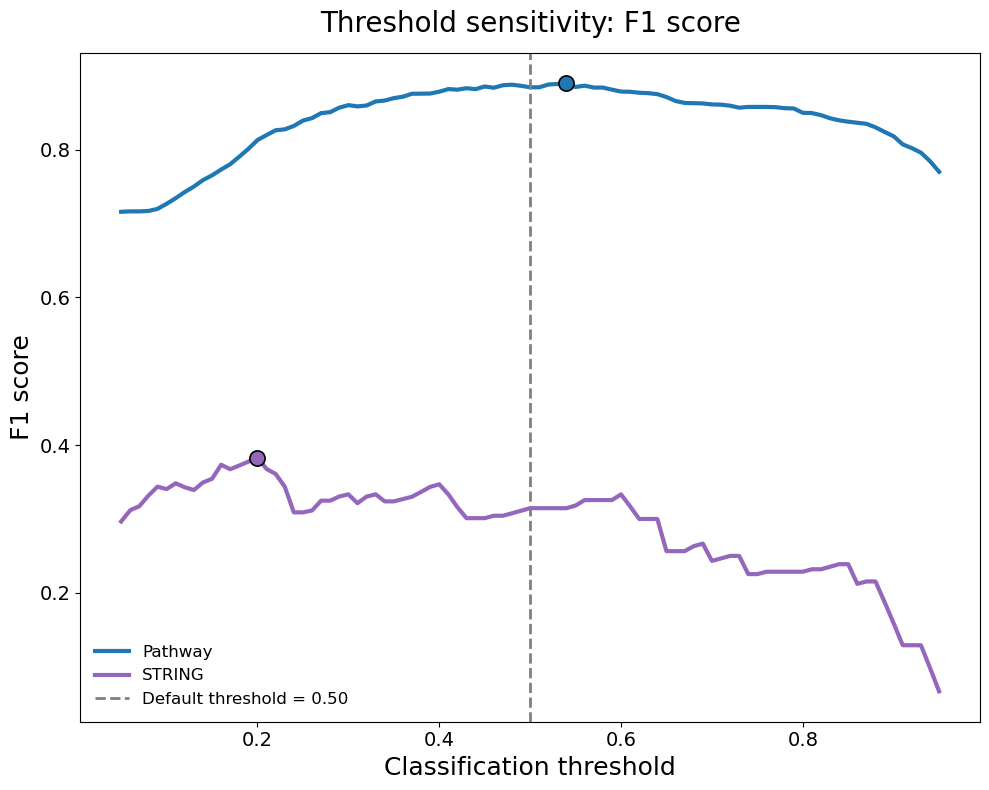

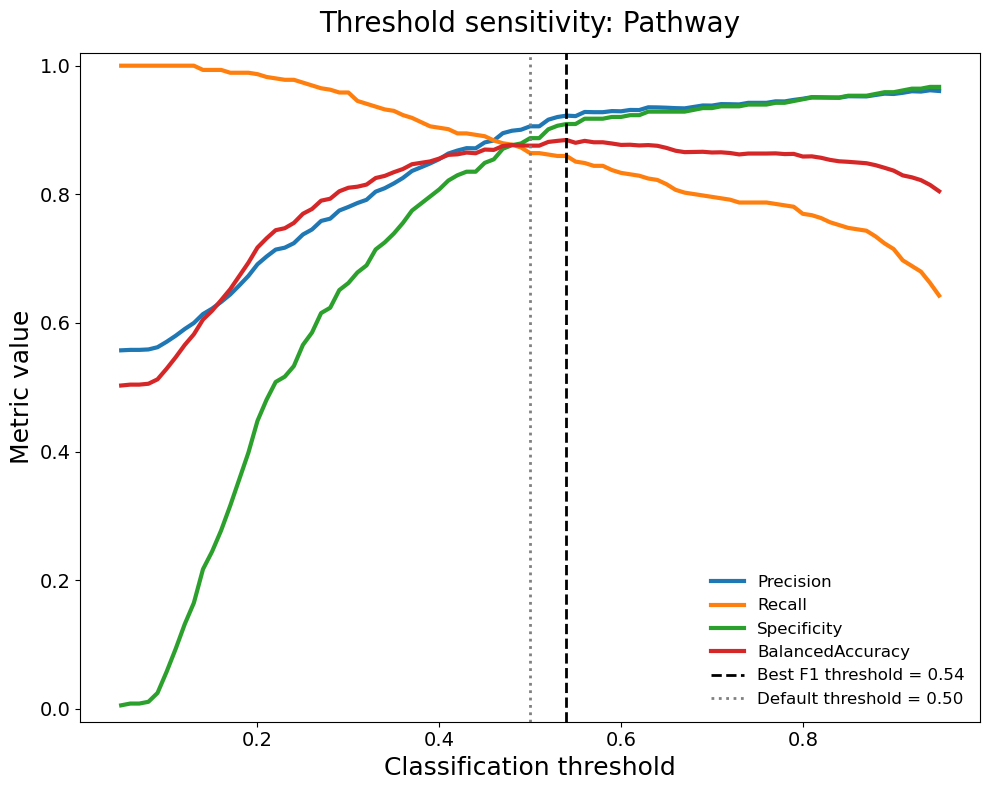

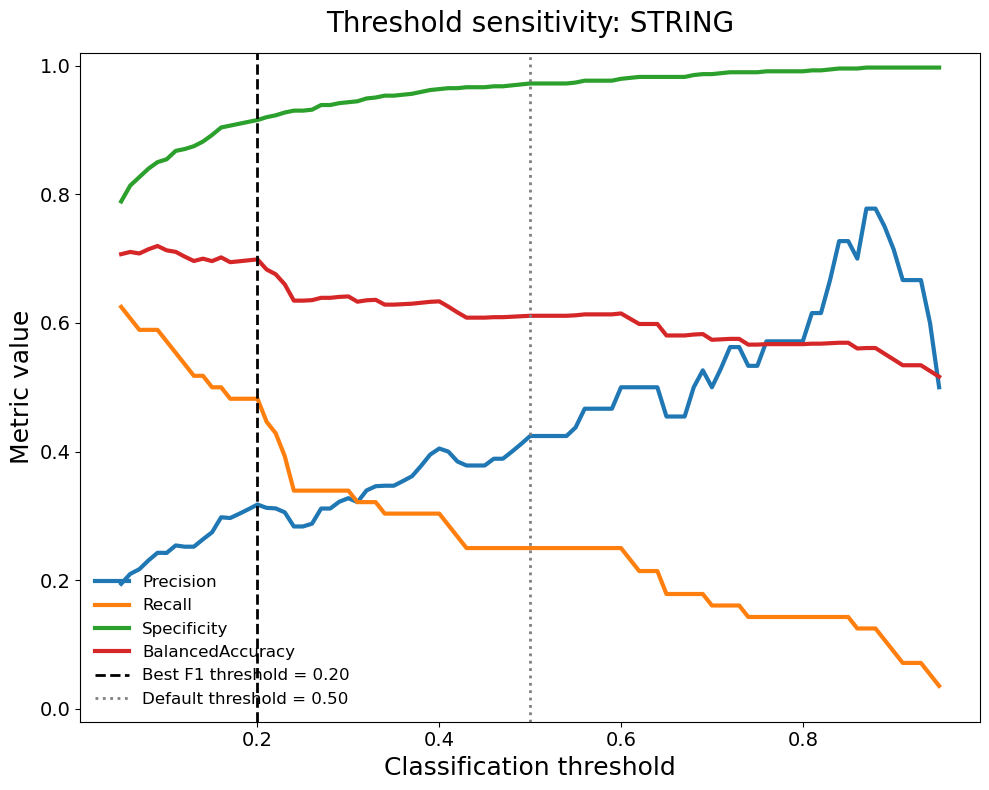

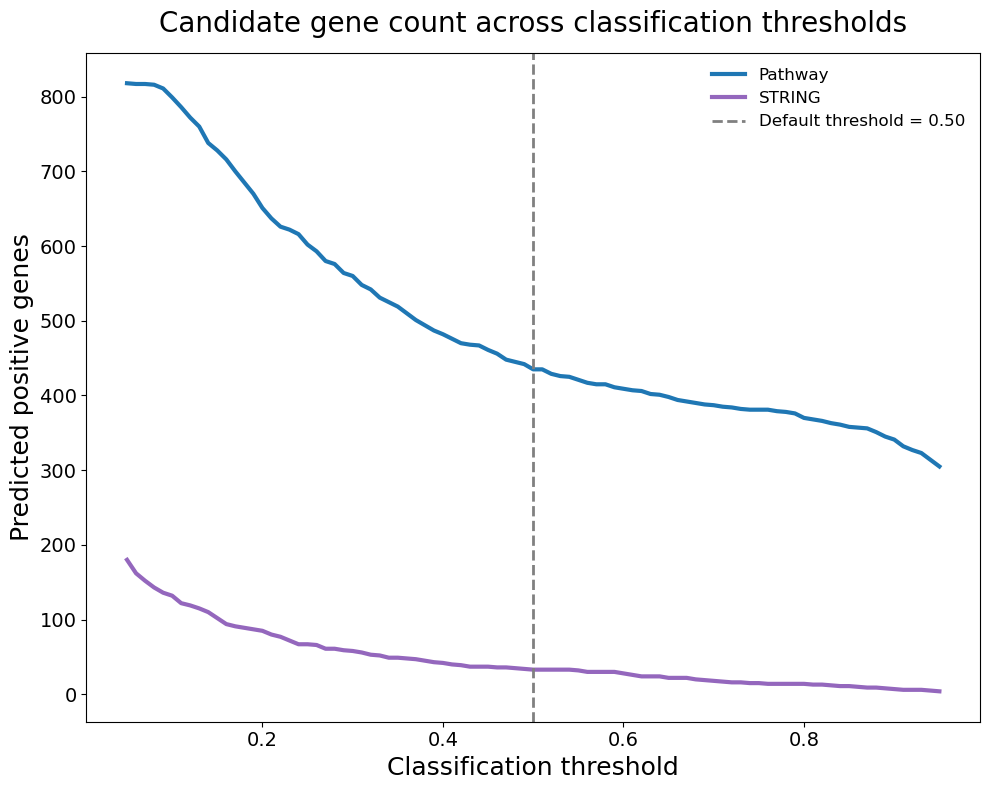


Saved threshold sensitivity plots:
 - results/gene_prediction/topology_ablation_threshold_F1.png
 - results/gene_prediction/topology_ablation_predicted_positive_count.png


In [56]:
# =========================================================
# THRESHOLD SENSITIVITY ANALYSIS
# =========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix
)

# ---------------------------------------------------------
# Threshold grid
# ---------------------------------------------------------

thresholds = np.round(
    np.arange(0.05, 0.96, 0.01),
    2
)

threshold_results = []

# =========================================================
# COMPUTE METRICS ACROSS THRESHOLDS
# =========================================================

for r in valid_results:

    network_name = r["Network"]

    y_true = np.asarray(
        r["y_true"]
    ).astype(int)

    y_score = np.asarray(
        r["y_score"]
    ).astype(float)

    for threshold in thresholds:

        y_pred = (
            y_score >= threshold
        ).astype(int)

        # Confusion matrix with fixed binary labels
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        # MCC may fail or be uninformative for one predicted class
        try:
            mcc = matthews_corrcoef(
                y_true,
                y_pred
            )
        except Exception:
            mcc = np.nan

        threshold_results.append({

            "Network": network_name,

            "Threshold": threshold,

            "Precision": precision,

            "Recall": recall,

            "Sensitivity": sensitivity,

            "Specificity": specificity,

            "F1": f1,

            "Accuracy": accuracy,

            "BalancedAccuracy": balanced_acc,

            "MCC": mcc,

            "TP": tp,

            "TN": tn,

            "FP": fp,

            "FN": fn,

            "PredictedPositive": int(
                y_pred.sum()
            ),

            "PredictedNegative": int(
                (y_pred == 0).sum()
            )
        })

# =========================================================
# SAVE THRESHOLD RESULTS
# =========================================================

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_csv_file = os.path.join(
    output_dir,
    "topology_ablation_threshold_sensitivity.csv"
)

threshold_df.to_csv(
    threshold_csv_file,
    index=False
)

print(
    "\nSaved threshold sensitivity table:",
    threshold_csv_file
)

display(
    threshold_df.head()
)

# =========================================================
# IDENTIFY BEST THRESHOLD PER NETWORK
# =========================================================

best_threshold_df = (
    threshold_df
    .sort_values(
        ["Network", "F1"],
        ascending=[True, False]
    )
    .groupby(
        "Network",
        as_index=False
    )
    .first()
)

best_threshold_df = best_threshold_df[
    [
        "Network",
        "Threshold",
        "F1",
        "Precision",
        "Recall",
        "Specificity",
        "BalancedAccuracy",
        "MCC",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
]

best_threshold_file = os.path.join(
    output_dir,
    "topology_ablation_best_thresholds.csv"
)

best_threshold_df.to_csv(
    best_threshold_file,
    index=False
)

print(
    "\nBest F1 threshold per network:"
)

display(
    best_threshold_df
)

print(
    "\nSaved best thresholds:",
    best_threshold_file
)

# =========================================================
# PLOT: F1 SCORE VS THRESHOLD
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.plot(
        network_df["Threshold"],
        network_df["F1"],
        linewidth=3,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        label=network_name
    )

    best_row = best_threshold_df[
        best_threshold_df["Network"] == network_name
    ].iloc[0]

    plt.scatter(
        best_row["Threshold"],
        best_row["F1"],
        s=120,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        edgecolor="black",
        linewidth=1.2,
        zorder=5
    )

plt.axvline(
    x=0.50,
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Default threshold = 0.50"
)

plt.xlabel(
    "Classification threshold",
    fontsize=18
)

plt.ylabel(
    "F1 score",
    fontsize=18
)

plt.title(
    "Threshold sensitivity: F1 score",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

f1_threshold_file = os.path.join(
    output_dir,
    "topology_ablation_threshold_F1.png"
)

plt.savefig(
    f1_threshold_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# PLOT: PRECISION / RECALL / SPECIFICITY VS THRESHOLD
# =========================================================

metrics_to_plot = [
    "Precision",
    "Recall",
    "Specificity",
    "BalancedAccuracy"
]

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.figure(
        figsize=(10, 8)
    )

    for metric_name in metrics_to_plot:

        plt.plot(
            network_df["Threshold"],
            network_df[metric_name],
            linewidth=3,
            label=metric_name
        )

    best_row = best_threshold_df[
        best_threshold_df["Network"] == network_name
    ].iloc[0]

    plt.axvline(
        x=best_row["Threshold"],
        linestyle="--",
        color="black",
        linewidth=2,
        label=(
            f"Best F1 threshold = "
            f"{best_row['Threshold']:.2f}"
        )
    )

    plt.axvline(
        x=0.50,
        linestyle=":",
        color="gray",
        linewidth=2,
        label="Default threshold = 0.50"
    )

    plt.xlabel(
        "Classification threshold",
        fontsize=18
    )

    plt.ylabel(
        "Metric value",
        fontsize=18
    )

    plt.title(
        f"Threshold sensitivity: {network_name}",
        fontsize=20,
        pad=15
    )

    plt.xticks(
        fontsize=14
    )

    plt.yticks(
        fontsize=14
    )

    plt.ylim(
        -0.02,
        1.02
    )

    plt.legend(
        fontsize=12,
        frameon=False,
        loc="best"
    )

    plt.tight_layout()

    safe_network_name = (
        network_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    metric_file = os.path.join(
        output_dir,
        f"threshold_sensitivity_{safe_network_name}.png"
    )

    plt.savefig(
        metric_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# =========================================================
# PLOT: NUMBER OF PREDICTED POSITIVE GENES VS THRESHOLD
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for network_name in threshold_df["Network"].unique():

    network_df = threshold_df[
        threshold_df["Network"] == network_name
    ]

    plt.plot(
        network_df["Threshold"],
        network_df["PredictedPositive"],
        linewidth=3,
        color=NETWORK_COLORS.get(
            network_name,
            None
        ),
        label=network_name
    )

plt.axvline(
    x=0.50,
    linestyle="--",
    color="gray",
    linewidth=2,
    label="Default threshold = 0.50"
)

plt.xlabel(
    "Classification threshold",
    fontsize=18
)

plt.ylabel(
    "Predicted positive genes",
    fontsize=18
)

plt.title(
    "Candidate gene count across classification thresholds",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

candidate_count_file = os.path.join(
    output_dir,
    "topology_ablation_predicted_positive_count.png"
)

plt.savefig(
    candidate_count_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved threshold sensitivity plots:")
print(" -", f1_threshold_file)
print(" -", candidate_count_file)

In [59]:
num_nodes = graph.num_nodes()

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

In [ ]:
# ============================================================
# ACGNN HYPERPARAMETER SEARCH
# Validation-set selection only
# ============================================================

import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# SAFE METRIC FUNCTION
# ============================================================

def safe_binary_metrics(y_true, y_score):

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid_mask = np.isfinite(y_true) & np.isfinite(y_score)

    y_true = y_true[valid_mask]
    y_score = y_score[valid_mask]

    if len(y_true) == 0:
        return {
            "AUROC": np.nan,
            "AUPRC": np.nan
        }

    if len(np.unique(y_true)) < 2:
        return {
            "AUROC": np.nan,
            "AUPRC": np.nan
        }

    return {
        "AUROC": roc_auc_score(y_true, y_score),
        "AUPRC": average_precision_score(y_true, y_score)
    }


# ============================================================
# TRAIN ONE CONFIGURATION
# ============================================================

def train_one_config(
    graph,
    features,
    labels,
    train_mask,
    val_mask,
    config,
    seed=42,
    max_epochs=300,
    patience=30
):

    set_seed(seed)

    graph = graph.to(device)
    features = features.to(device)
    labels = labels.to(device)

    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)

    model = ACGNN(
        in_feats=features.shape[1],
        hidden_feats=config["hidden_feats"],
        out_feats=1,
        k=config["k"],
        dropout=config["dropout"],
        epsilon=config["epsilon"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    loss_fn = FocalLoss(
        alpha=config["focal_alpha"],
        gamma=config["focal_gamma"]
    )

    best_val_auprc = -np.inf
    best_val_auc = np.nan
    best_epoch = 0
    best_state = None
    early_stop_counter = 0

    for epoch in range(max_epochs):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            val_logits = model(
                graph,
                features
            ).squeeze()

            val_probs = torch.sigmoid(
                val_logits
            )

        val_y_true = labels[
            val_mask
        ].detach().cpu().numpy()

        val_y_score = val_probs[
            val_mask
        ].detach().cpu().numpy()

        val_metrics = safe_binary_metrics(
            val_y_true,
            val_y_score
        )

        val_auc = val_metrics["AUROC"]
        val_auprc = val_metrics["AUPRC"]

        if np.isnan(val_auprc):
            continue

        if val_auprc > best_val_auprc:

            best_val_auprc = val_auprc
            best_val_auc = val_auc
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            early_stop_counter = 0

        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "ValAUROC": best_val_auc,
        "ValAUPRC": best_val_auprc,
        "BestEpoch": best_epoch
    }


# ============================================================
# SEARCH SPACE
# ============================================================

SEARCH_SPACE = {
    "hidden_feats": [64, 128, 256],
    "k": [1, 2, 3, 5],
    "dropout": [0.1, 0.3, 0.5],
    "epsilon": [1e-3, 1e-4],
    "learning_rate": [3e-4, 1e-3],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "focal_alpha": [0.25],
    "focal_gamma": [2.0]
}

SEEDS = [42, 52, 62]

MAX_EPOCHS = 300
PATIENCE = 30

# ============================================================
# CREATE CONFIGURATIONS
# ============================================================

keys = list(SEARCH_SPACE.keys())

configs = [
    dict(zip(keys, values))
    for values in itertools.product(
        *[SEARCH_SPACE[key] for key in keys]
    )
]

print(f"Total hyperparameter configurations: {len(configs)}")
print(f"Seeds per configuration: {len(SEEDS)}")
print(f"Total training runs: {len(configs) * len(SEEDS)}")

# ============================================================
# RUN SEARCH
# ============================================================

search_results = []

for config_id, config in enumerate(configs):

    print(
        f"\nConfiguration "
        f"{config_id + 1}/{len(configs)}"
    )

    print(config)

    config_runs = []

    for seed in SEEDS:

        run_result = train_one_config(
            graph=graph,
            features=features,
            labels=labels,
            train_mask=train_mask,
            val_mask=val_mask,
            config=config,
            seed=seed,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE
        )

        run_result["seed"] = seed

        config_runs.append(
            run_result
        )

        print(
            f"Seed={seed} | "
            f"ValAUROC={run_result['ValAUROC']:.4f} | "
            f"ValAUPRC={run_result['ValAUPRC']:.4f} | "
            f"Epoch={run_result['BestEpoch']}"
        )

    val_auc_values = [
        r["ValAUROC"]
        for r in config_runs
    ]

    val_auprc_values = [
        r["ValAUPRC"]
        for r in config_runs
    ]

    epoch_values = [
        r["BestEpoch"]
        for r in config_runs
    ]

    row = {
        **config,

        "MeanValAUROC":
            np.nanmean(val_auc_values),

        "StdValAUROC":
            np.nanstd(val_auc_values),

        "MeanValAUPRC":
            np.nanmean(val_auprc_values),

        "StdValAUPRC":
            np.nanstd(val_auprc_values),

        "MeanBestEpoch":
            np.mean(epoch_values),

        "Seeds":
            ",".join(map(str, SEEDS))
    }

    search_results.append(row)

# ============================================================
# RESULTS TABLE
# ============================================================

hyperparam_df = pd.DataFrame(
    search_results
)

hyperparam_df = hyperparam_df.sort_values(
    by=[
        "MeanValAUPRC",
        "MeanValAUROC"
    ],
    ascending=False
).reset_index(
    drop=True
)

display(
    hyperparam_df.head(20)
)

# ============================================================
# SAVE RESULTS
# ============================================================

os.makedirs(output_dir, exist_ok=True)

hyperparam_file = os.path.join(
    output_dir,
    "ACGNN_hyperparameter_search.csv"
)

hyperparam_df.to_csv(
    hyperparam_file,
    index=False
)

print(
    "\nSaved hyperparameter search:",
    hyperparam_file
)

# ============================================================
# BEST CONFIGURATION
# ============================================================

best_config = hyperparam_df.iloc[0].to_dict()

print("\nBest configuration:")
for key, value in best_config.items():
    print(f"{key}: {value}")

Total hyperparameter configurations: 432
Seeds per configuration: 3
Total training runs: 1296

Configuration 1/432
{'hidden_feats': 64, 'k': 1, 'dropout': 0.1, 'epsilon': 0.001, 'learning_rate': 0.0003, 'weight_decay': 0.0, 'focal_alpha': 0.25, 'focal_gamma': 2.0}
Seed=42 | ValAUROC=0.5590 | ValAUPRC=0.5968 | Epoch=46
Seed=52 | ValAUROC=0.5468 | ValAUPRC=0.6373 | Epoch=2
Seed=62 | ValAUROC=0.5877 | ValAUPRC=0.6348 | Epoch=62

Configuration 2/432
{'hidden_feats': 64, 'k': 1, 'dropout': 0.1, 'epsilon': 0.001, 'learning_rate': 0.0003, 'weight_decay': 1e-05, 'focal_alpha': 0.25, 'focal_gamma': 2.0}
Seed=42 | ValAUROC=0.5526 | ValAUPRC=0.6018 | Epoch=33
Seed=52 | ValAUROC=0.5470 | ValAUPRC=0.6375 | Epoch=2
Seed=62 | ValAUROC=0.5736 | ValAUPRC=0.6303 | Epoch=47

Configuration 3/432
{'hidden_feats': 64, 'k': 1, 'dropout': 0.1, 'epsilon': 0.001, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'focal_alpha': 0.25, 'focal_gamma': 2.0}
Seed=42 | ValAUROC=0.5567 | ValAUPRC=0.6006 | Epoch=38
Seed=


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=2193 Val=721 Test=743
Epoch=0 Loss=0.0437 ValAUROC=0.3100
Epoch=10 Loss=0.0175 ValAUROC=0.3145
Epoch=20 Loss=0.0148 ValAUROC=0.4561
Epoch=30 Loss=0.0120 ValAUROC=0.6908
Epoch=40 Loss=0.0079 ValAUROC=0.7201
Epoch=50 Loss=0.0037 ValAUROC=0.7188
Epoch=60 Loss=0.0011 ValAUROC=0.7095
Early stopping at epoch 67


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5809  238103  40.988640  0.007056  0.938383   0.931849   
1   STRING   6642  437139  65.814362  0.009909  0.734677   0.749012   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.941778  0.868621  0.852439  41.289400  
1   0.314867  0.388350  0.915209  83.328246  

Saved: results/gene_prediction/topology_ablati

,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5809,238103,40.988640,0.007056,0.938383,0.931849,0.941778,0.868621,0.852439,41.289400
1,STRING,6642,437139,65.814362,0.009909,0.734677,0.749012,0.314867,0.388350,0.915209,83.328246


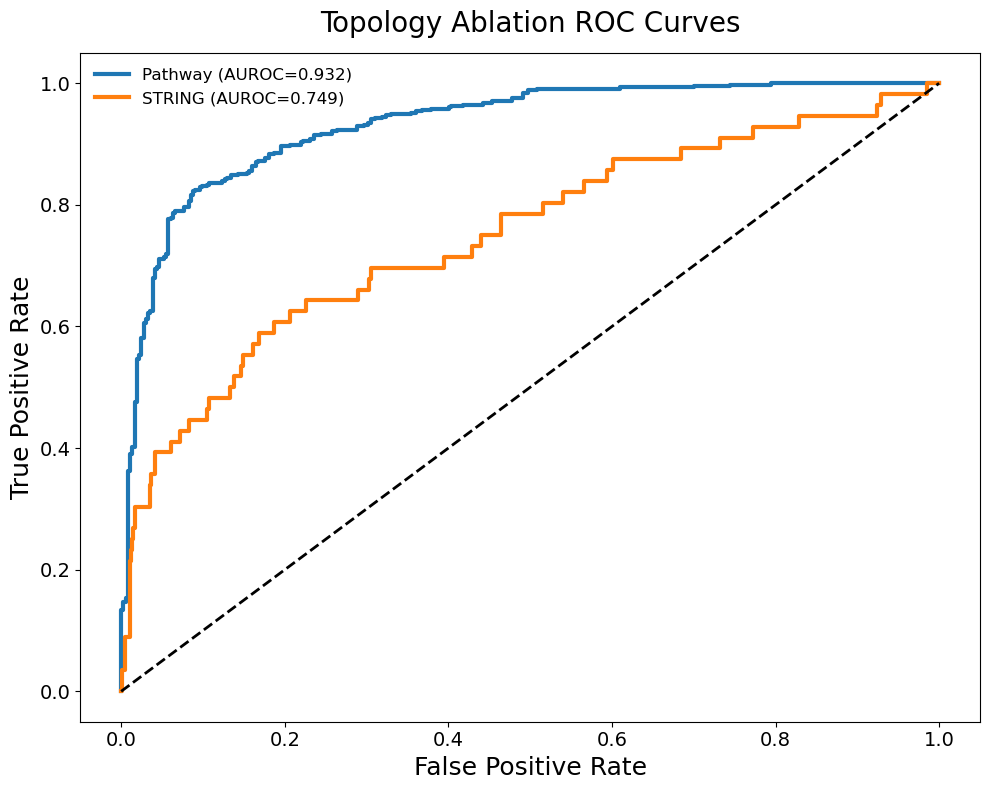

Saved: results/gene_prediction/topology_ablation_ROC.png


In [51]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# NETWORK-SPECIFIC TRAINING EPOCHS
# =========================================================

NETWORK_EPOCHS = {
    "Pathway": args.num_epochs,
    "CPDB": args.num_epochs * 2,   # double epochs for CPDB
    "HIPPIE": args.num_epochs,
    "STRING": args.num_epochs,
}

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name,
    num_epochs=None
):

    if num_epochs is None:
        num_epochs = args.num_epochs

    print(f"\nTraining {network_name} for {num_epochs} epochs")
    

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    # for epoch in range(300):
    # for epoch in range(args.num_epochs):
    for epoch in range(num_epochs):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

# results = []

# for network_name, relation_file in NETWORKS.items():

#     result = train_one_network(
#         relation_file,
#         network_name
#     )

#     results.append(
#         result
#     )

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file=relation_file,
        network_name=network_name,
        num_epochs=NETWORK_EPOCHS[network_name]
    )

    results.append(result)

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)

In [52]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

# labeled genes only
labeled_mask=(pathway_labels!=-1)

pathway_genes=pathway_gene_names[
    labeled_mask.cpu().numpy()
]

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "Pathway labeled genes:",
    len(pathway_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        pathway_genes,
        test_size=0.40,
        stratify=pathway_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=2193 Val=721 Test=743
Epoch=0 Loss=0.0478 ValAUROC=0.3111
Epoch=10 Loss=0.0182 ValAUROC=0.3138
Epoch=20 Loss=0.0153 ValAUROC=0.4492
Epoch=30 Loss=0.0127 ValAUROC=0.7011


KeyboardInterrupt: 


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...


[INFO] Skipped edges: 258144

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 5809
Edges: 232294
Embedding tensor shape: torch.Size([5809, 2688])
Labels tensor shape: torch.Size([5809])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
[INFO] Loading graph: ../../ACGNN_data/data/multiomics_meth/CPDB_omics_ppi_embeddings_graph_2048.json


Processing graph entries: 100%|██████████| 9570/9570 [00:00<00:00, 530608.73it/s]


[INFO] Converting to tensors...
[INFO] Nodes: 2191
[INFO] Edges: 9570
Train=2457 Val=819 Test=820

Pathway
Train=2457 Val=819 Test=820
Epoch=0 Loss=0.0427 ValAUROC=0.4989
Epoch=10 Loss=0.0192 ValAUROC=0.8976
Epoch=20 Loss=0.0122 ValAUROC=0.9179
Epoch=30 Loss=0.0071 ValAUROC=0.9165
Early stopping: 39

CPDB
Train=72 Val=21 Test=27
Epoch=0 Loss=0.0503 ValAUROC=0.8778
Epoch=10 Loss=0.0156 ValAUROC=0.8889
Epoch=20 Loss=0.0129 ValAUROC=0.7556
Epoch=30 Loss=0.0114 ValAUROC=0.7556
Epoch=40 Loss=0.0092 ValAUROC=0.7778
Early stopping: 47


   Network  Nodes   Edges  TrainNodes  ValNodes  TestNodes  BestValAUROC  \
0  Pathway   5809  238103        2457       819        820      0.924387   
1     CPDB   2191   11761          72        21         27      0.933333   

      AUROC     AUPRC        F1  Accuracy  TrainTime  \
0  0.921836  0.937345  0.842723  0.836585  40.167448   
1  0.750000  0.954722  0.920000  0.851852  14.619602   

                                              y_pred  \
0  [1, 0, 

,Network,Nodes,Edges,TrainNodes,ValNodes,TestNodes,BestValAUROC,AUROC,AUPRC,F1,Accuracy,TrainTime,y_pred,test_node_indices
0,Pathway,5809,238103,2457,819,820,0.924387,0.921836,0.937345,0.842723,0.836585,40.167448,"[1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, ...","[2, 49, 53, 56, 60, 67, 74, 75, 77, 81, 104, 1..."
1,CPDB,2191,11761,72,21,27,0.933333,0.750000,0.954722,0.920000,0.851852,14.619602,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[104, 106, 122, 185, 341, 350, 362, 596, 635, ..."


Saved: results/gene_prediction/Pathway_vs_CPDB.tex


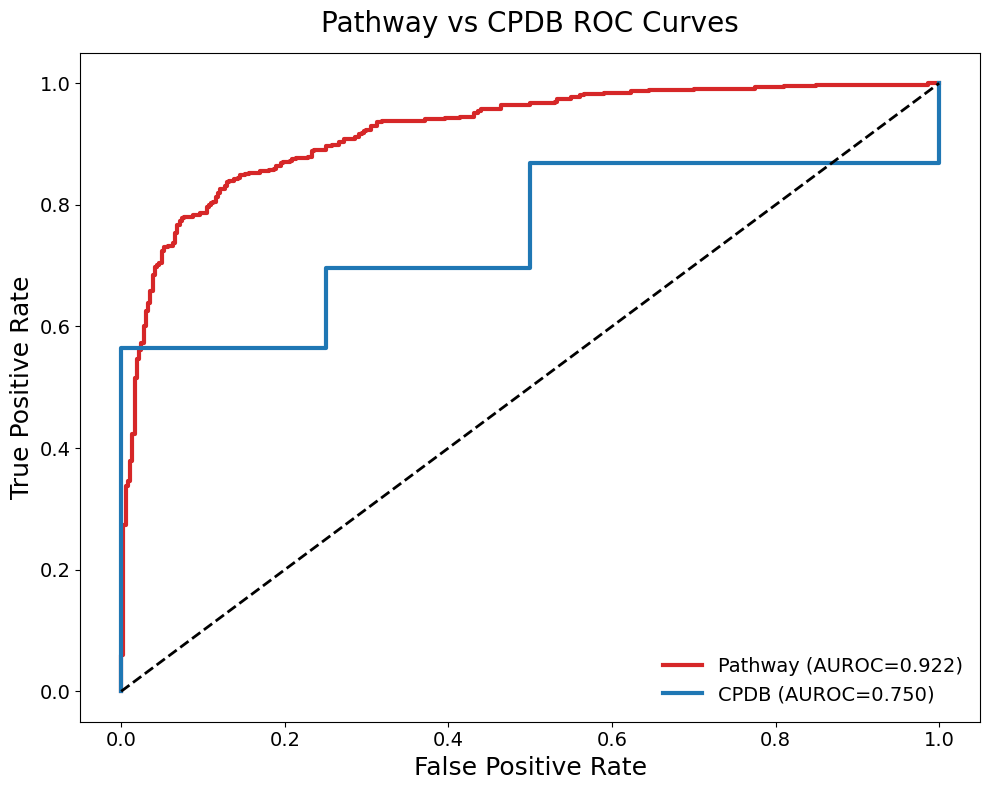

Saved: results/gene_prediction/Pathway_vs_CPDB_ROC.png


In [ ]:
# =========================================================
# TOPOLOGY ABLATION
# Pathway vs CPDB topology
# =========================================================

import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

# =========================================================
# PATHWAY GRAPH
# =========================================================

(
    pathway_nodes,
    pathway_edges,
    pathway_embeddings,
    pathway_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,

    relation_csv_path=
    "../process/data/processed/gene_pairs_limit5000.csv",

    max_edges_per_node=
    MAX_EDGES_PER_NODE
)

# =========================================================
# CPDB GRAPH
# =========================================================

data_path=os.path.join(

    "../../ACGNN_data/data/multiomics_meth/",
    f"{args.net_type}_omics_ppi_embeddings_graph_2048.json"
)

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data(
    data_path
)

# =========================================================
# GLOBAL SPLIT:
# USE PATHWAY GENES
# =========================================================

pathway_gene_names=np.array(
    list(pathway_nodes.keys())
)

labeled_mask=(
    pathway_labels!=-1
)

pathway_genes=(
    pathway_gene_names[
        labeled_mask.cpu().numpy()
    ]
)

pathway_gene_labels=(
    pathway_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

train_genes,temp_genes=(
    train_test_split(

        pathway_genes,

        test_size=0.4,

        stratify=
        pathway_gene_labels,

        random_state=42
    )
)

temp_labels=np.array([

    pathway_labels[
        pathway_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(

        temp_genes,

        test_size=0.5,

        stratify=temp_labels,

        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

# =========================================================
# TRAIN FUNCTION
# works on already-loaded graphs
# =========================================================

def train_one_graph(
    nodes,
    edges,
    embeddings_tensor,
    labels_tensor,
    network_name
):

    print("\n"+"="*70)
    print(network_name)
    print("="*70)

    # =====================================================
    # GRAPH
    # =====================================================

    graph=dgl.graph(edges)

    graph=dgl.add_self_loop(graph)

    graph.ndata["feat"]=embeddings_tensor
    graph.ndata["label"]=labels_tensor


    # =====================================================
    # BUILD MASKS USING GENE NAMES
    # =====================================================

    num_nodes=graph.number_of_nodes()

    train_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask=torch.zeros(
        num_nodes,
        dtype=torch.bool
    )


    # ---------------------------------------
    # Gene -> node index mapping
    # ---------------------------------------

    if isinstance(nodes,dict):

        node_map=nodes

    else:

        node_map={
            g:i
            for i,g in enumerate(nodes)
        }


    # ---------------------------------------
    # assign masks only for genes existing
    # in current graph
    # ---------------------------------------

    train_valid=[
        node_map[g]
        for g in train_genes
        if g in node_map
    ]

    val_valid=[
        node_map[g]
        for g in val_genes
        if g in node_map
    ]

    test_valid=[
        node_map[g]
        for g in test_genes
        if g in node_map
    ]


    train_mask[train_valid]=True
    val_mask[val_valid]=True
    test_mask[test_valid]=True


    # remove unlabeled nodes

    labeled_mask=(
        labels_tensor!=-1
    )

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask


    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )


    graph.ndata["train_mask"]=train_mask
    graph.ndata["val_mask"]=val_mask
    graph.ndata["test_mask"]=test_mask

    graph=graph.to(device)

    features=graph.ndata["feat"]

    labels=(
        graph.ndata["label"]
        .float()
    )

    # =====================================================
    # MODEL
    # =====================================================

    in_feats=features.shape[1]

    model=choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)


    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn=FocalLoss(
        alpha=0.25,
        gamma=2
    )


    # =====================================================
    # TRAIN
    # =====================================================

    num_epochs=600 if network_name=="CPDB" else 300

    patience=40 if network_name=="CPDB" else 20

    best_auc=0
    best_state=None
    counter=0

    start=time.time()

    for epoch in range(num_epochs):

        model.train()

        logits=model(
            graph,
            features
        ).squeeze()

        loss=loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        # -----------------------------
        # validation
        # -----------------------------

        model.eval()

        with torch.no_grad():

            probs=torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )


        val_auc=roc_auc_score(

            labels[val_mask]
            .cpu()
            .numpy(),

            probs[val_mask]
            .cpu()
            .numpy()
        )


        if val_auc>best_auc:

            best_auc=val_auc

            best_state=copy.deepcopy(
                model.state_dict()
            )

            counter=0

        else:

            counter+=1


        if epoch%10==0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )


        if counter>=patience:

            print(
                f"Early stopping: {epoch}"
            )

            break


    train_time=time.time()-start


    # =====================================================
    # TEST
    # =====================================================

    model.load_state_dict(
        best_state
    )

    model.eval()

    with torch.no_grad():

        probs=torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )


    y_true=(
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score=(
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred=(
        y_score>0.5
    ).astype(int)




    # =====================================================
    # RESULTS
    # =====================================================

    result = {

        # ---------------------------------------------
        # Network metadata
        # ---------------------------------------------
        "Network": network_name,

        "Nodes": graph.number_of_nodes(),

        "Edges": graph.number_of_edges(),

        "TrainNodes": int(train_mask.sum().item()),

        "ValNodes": int(val_mask.sum().item()),

        "TestNodes": int(test_mask.sum().item()),

        # ---------------------------------------------
        # Validation performance
        # ---------------------------------------------
        "BestValAUROC": float(best_auc),

        # ---------------------------------------------
        # Test performance
        # ---------------------------------------------
        "AUROC": float(
            roc_auc_score(
                y_true,
                y_score
            )
        ),

        "AUPRC": float(
            average_precision_score(
                y_true,
                y_score
            )
        ),

        "F1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),

        "Accuracy": float(
            accuracy_score(
                y_true,
                y_pred
            )
        ),

        "TrainTime": float(train_time),

        # ---------------------------------------------
        # Keep raw test outputs for ROC / PR curves
        # ---------------------------------------------
        "y_true": y_true,

        "y_score": y_score,

        "y_pred": y_pred,

        # Optional: retain test-node identities
        "test_node_indices": torch.where(
            test_mask
        )[0].detach().cpu().numpy()
    }

    return result



# =========================================================
# RUN ABLATION
# =========================================================

# =========================================================
# RUN COMPARISON
# =========================================================

results=[]

# -----------------------------
# Pathway
# -----------------------------

result_pathway=(
    train_one_graph(

        pathway_nodes,
        pathway_edges,
        pathway_embeddings,
        pathway_labels,

        "Pathway"
    )
)

results.append(
    result_pathway
)


# -----------------------------
# CPDB
# -----------------------------

result_cpdb=(
    train_one_graph(

        cpdb_nodes,
        cpdb_edges,
        cpdb_embeddings,
        cpdb_labels,

        "CPDB"
    )
)

results.append(
    result_cpdb)


# =========================================================
# SAVE RESULTS TABLE
# =========================================================

results_df=pd.DataFrame([

    {
        k:v
        for k,v in r.items()
        if k not in [
            "y_true",
            "y_score"
        ]
    }

    for r in results
])

results_df=results_df.sort_values(
    "AUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(
    results_df
)


# =========================================================
# SAVE LATEX TABLE
# =========================================================

latex_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB.tex"
)

latex_table=results_df.to_latex(

    index=False,

    float_format=
    "%.4f",

    caption=(
        "Comparison of "
        "pathway-informed topology "
        "and CPDB PPI topology."
    ),

    label=
    "tab:pathway_cpdb",

    escape=False
)

with open(
    latex_file,
    "w"
) as f:

    f.write(
        latex_table
    )

print(
    "Saved:",
    latex_file
)


# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

colors={

    "Pathway":"#d62728",
    "CPDB":"#1f77b4"
}


for r in results:

    fpr,tpr,_=roc_curve(

        r["y_true"],
        r["y_score"]
    )

    roc_auc=auc(
        fpr,
        tpr
    )

    plt.plot(

        fpr,
        tpr,

        linewidth=3,

        color=colors[
            r["Network"]
        ],

        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )


# diagonal

plt.plot(

    [0,1],
    [0,1],

    linestyle="--",

    color="black",

    linewidth=2
)


plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(

    "Pathway vs CPDB ROC Curves",

    fontsize=20,

    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(

    fontsize=14,

    frameon=False,

    loc="lower right"
)

plt.grid(False)

plt.tight_layout()


roc_file=os.path.join(

    output_dir,
    "Pathway_vs_CPDB_ROC.png"
)

plt.savefig(

    roc_file,

    dpi=300,

    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)

In [ ]:
print(results[0].keys())

dict_keys(['Network', 'Nodes', 'Edges', 'AUROC', 'AUPRC', 'F1', 'Accuracy', 'TrainTime'])



[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=2193 Val=721 Test=743
Epoch=0 Loss=0.0484 ValAUROC=0.3069
Epoch=10 Loss=0.0184 ValAUROC=0.3098
Epoch=20 Loss=0.0147 ValAUROC=0.4262
Epoch=30 Loss=0.0122 ValAUROC=0.7229
Epoch=40 Loss=0.0088 ValAUROC=0.7361
Epoch=50 Loss=0.0053 ValAUROC=0.5854
Epoch=60 Loss=0.0046 ValAUROC=0.7281
Epoch=70 Loss=0.0020 ValAUROC=0.7057
Early stopping at epoch 74


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5809  238103  40.988640  0.007056  0.943533   0.940036   
1   STRING   6642  437139  65.814362  0.009909  0.739644   0.764868   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.951957  0.866902  0.862195  46.844257  
1   0.310399  0.384615  0.913863  96.988487  

Saved: re

,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5809,238103,40.988640,0.007056,0.943533,0.940036,0.951957,0.866902,0.862195,46.844257
1,STRING,6642,437139,65.814362,0.009909,0.739644,0.764868,0.310399,0.384615,0.913863,96.988487


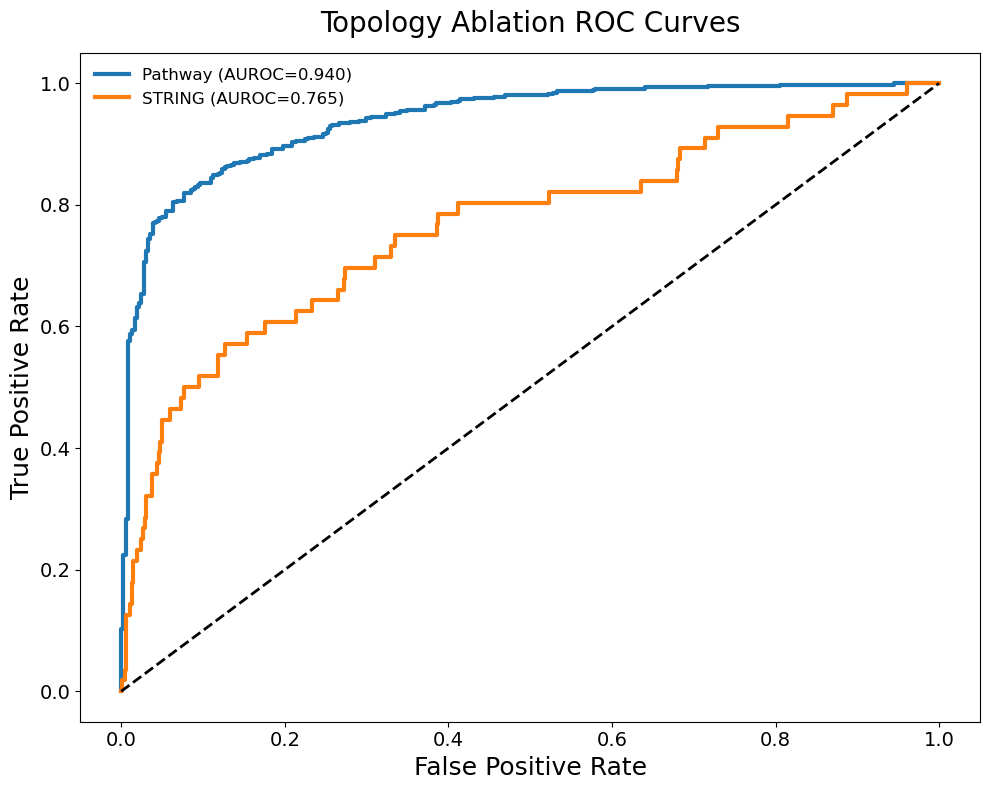

Saved: results/gene_prediction/topology_ablation_ROC.png


In [ ]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names=np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask=(cpdb_labels!=-1)

cpdb_genes=cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels=(
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
Train=2199 Val=735 Test=747
Epoch=0 Loss=0.0379 ValAUROC=0.2807
Epoch=10 Loss=0.0140 ValAUROC=0.3024
Epoch=20 Loss=0.0120 ValAUROC=0.3959
Epoch=30 Loss=0.0101 ValAUROC=0.7200
Epoch=40 Loss=0.0067 ValAUROC=0.7406
Epoch=50 Loss=0.0028 ValAUROC=0.7348
Epoch=60 Loss=0.0022 ValAUROC=0.6762
Early stopping at epoch 62


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5809  232294  39.988640  0.006884  0.945478   0.932747   
1   STRING   6642  430497  64.814362  0.009758  0.744460   0.730797   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.942965  0.868360  0.860976  47.003854  
1   0.216101  0.131148  0.929050  87.222604  

Saved: results/gene_prediction/topology_ablati

,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5809,232294,39.988640,0.006884,0.945478,0.932747,0.942965,0.868360,0.860976,47.003854
1,STRING,6642,430497,64.814362,0.009758,0.744460,0.730797,0.216101,0.131148,0.929050,87.222604


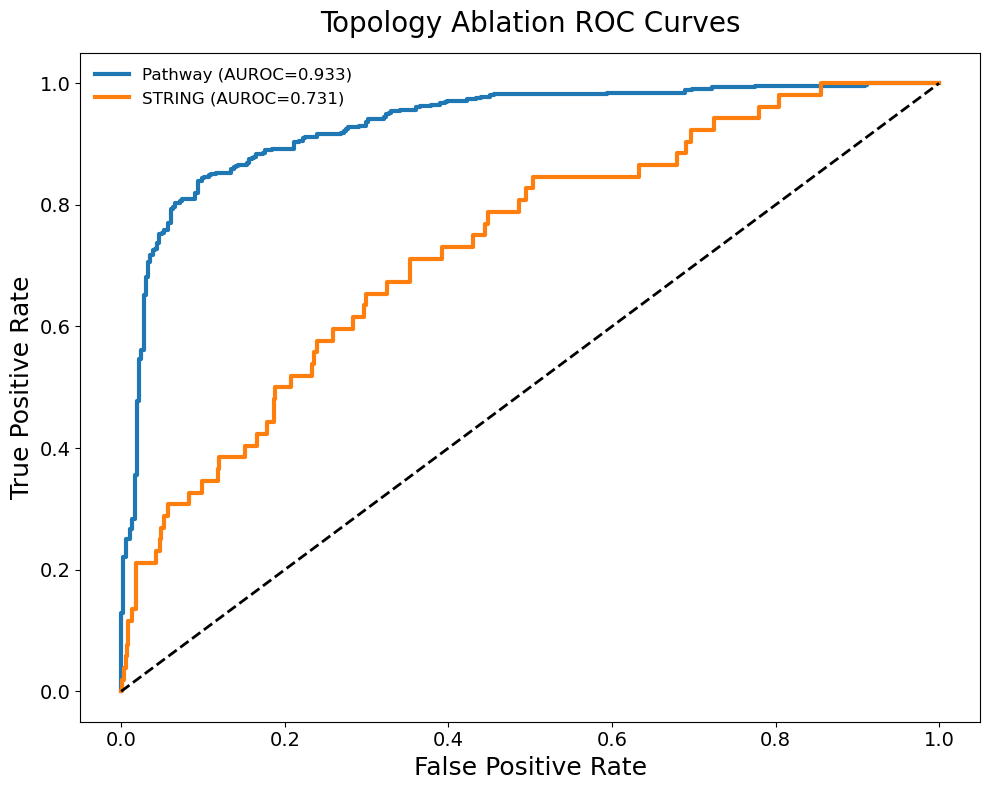

Saved: results/gene_prediction/topology_ablation_ROC.png


In [ ]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================
#
# NOTE: this script assumes the following are already defined
# upstream in your notebook/session (unchanged from the original):
#   source_csv_path, target_csv_path, MAX_EDGES_PER_NODE,
#   load_graph_data_directly, output_dir, device, args,
#   choose_model, FocalLoss, plt
#
# Fixes applied vs. the original:
#   1. train_idx/val_idx/test_idx were referenced but never defined,
#      and reusing positional indices across networks built from
#      different edge files is unsafe (node ordering isn't
#      guaranteed to match). Masks are now built per-network by
#      looking up each split gene's index in THAT network's own
#      `nodes` dict.
#   2. AvgDegree / Density are now computed BEFORE self-loops are
#      added, so the stats reflect the actual network topology
#      rather than being inflated by `num_nodes` synthetic edges
#      (which biases sparse networks like Pathway more than dense
#      ones like STRING).
#   3. Removed dead/commented-out code.
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
) = load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names = np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask = (cpdb_labels != -1)

cpdb_genes = cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels = (
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
#
# IMPORTANT: this split is done by GENE NAME, not by index.
# Each network gets its own node-index mapping built inside
# train_one_network(), so the same gene always lands in the
# same split regardless of how that network's loader orders
# its nodes.
# =========================================================

train_genes, temp_genes = (
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels = np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes, test_genes = (
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)


# =========================================================
# HELPER: map a list of gene names to node indices using a
# SPECIFIC network's own `nodes` dict (name -> index).
# Genes absent from this particular network are silently
# skipped (they simply can't be evaluated on that network).
# =========================================================

def genes_to_idx(gene_list, nodes_dict):

    idx = [
        nodes_dict[g]
        for g in gene_list
        if g in nodes_dict
    ]

    return torch.tensor(
        idx,
        dtype=torch.long
    )


# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    # ---- capture topology stats BEFORE self-loops are added,
    # so they reflect the real network rather than being
    # inflated by num_nodes synthetic self-loop edges ----
    raw_num_nodes = graph.number_of_nodes()
    raw_num_edges = graph.number_of_edges()

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        raw_num_edges
        /
        (raw_num_nodes ** 2)
    )

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor

    # =====================================================
    # BUILD MASKS FROM GLOBAL (NAME-BASED) SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # map this network's own gene -> index dict
    train_idx = genes_to_idx(train_genes, nodes)
    val_idx = genes_to_idx(val_genes, nodes)
    test_idx = genes_to_idx(test_genes, nodes)

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    node_labeled_mask = labels_tensor != -1

    train_mask &= node_labeled_mask
    val_mask &= node_labeled_mask
    test_mask &= node_labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)

    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    result = {

        "Network":
            network_name,

        "Nodes":
            raw_num_nodes,

        "Edges":
            raw_num_edges,

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }

    return result


# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

results_df = pd.DataFrame([
    {
        k: v
        for k, v in r.items()
        if k not in ["y_true", "y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

plt.figure(
    figsize=(10, 8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)


[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Reconnecting isolated:   0%|          | 0/19488 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 1481986

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/1481986 [00:00<?, ?it/s]


[INFO] Skipped edges: 1051489

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 6642
Edges: 430497
Embedding tensor shape: torch.Size([6642, 2688])
Labels tensor shape: torch.Size([6642])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
STRING: train=2199 val=735 test=747
Nodes=6642 Labeled=5920
Epoch=0 Loss=0.0485 ValAUROC=0.2875
Epoch=10 Loss=0.0147 ValAUROC=0.2984
Epoch=20 Loss=0.0127 ValAUROC=0.4232
Epoch=30 Loss=0.0106 ValAUROC=0.7082
Epoch=40 Loss=0.0081 ValAUROC=0.7178
Epoch=50 Loss=0.0048 ValAUROC=0.7401
Epoch=60 Loss=0.0024 ValAUROC=0.7163
Epoch=70 Loss=0.0007 ValAUROC=0.6923
Early stopping at epoch 70


   Network  Nodes   Edges  AvgDegree   Density  ValAUROC  TestAUROC  \
0  Pathway   5809  238103  40.988640  0.007056  0.943926    0.94416   
1   STRING   6642  437139  65.814362  0.009909  0.740144    0.74845   

   TestAUPRC        F1  Accuracy  TrainTime  
0   0.950758  0.881007  0.873171  44.918393  
1   0.222718  0.208955  

,Network,Nodes,Edges,AvgDegree,Density,ValAUROC,TestAUROC,TestAUPRC,F1,Accuracy,TrainTime
0,Pathway,5809,238103,40.988640,0.007056,0.943926,0.94416,0.950758,0.881007,0.873171,44.918393
1,STRING,6642,437139,65.814362,0.009909,0.740144,0.74845,0.222718,0.208955,0.929050,88.706931


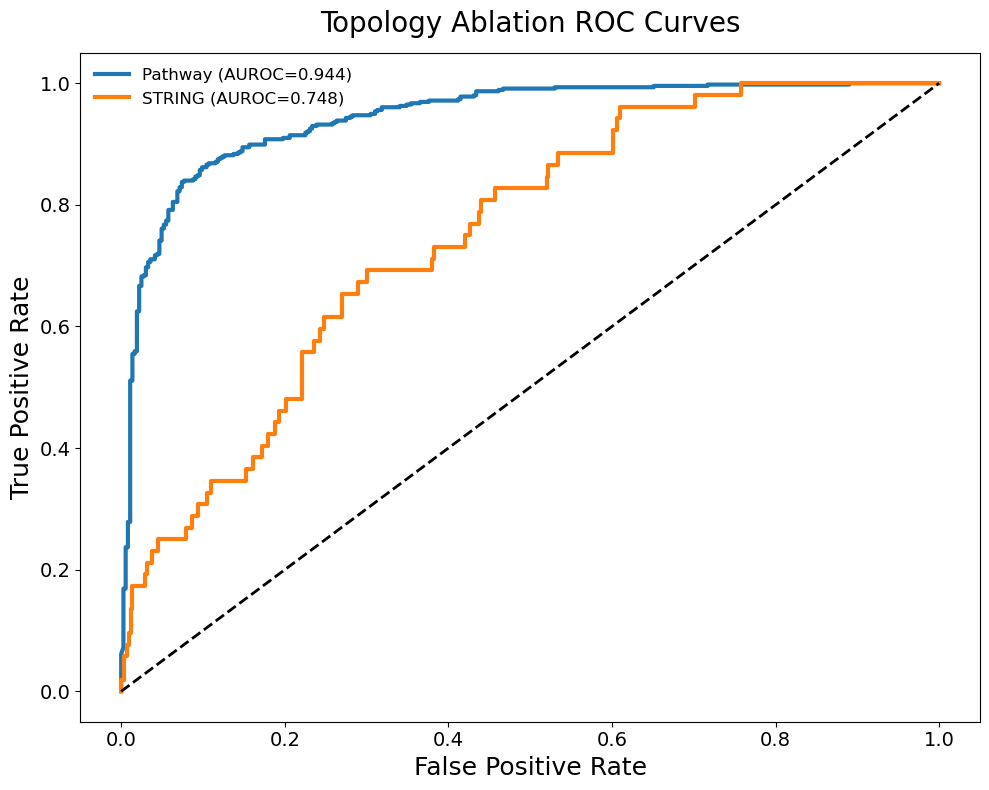

Saved: results/gene_prediction/topology_ablation_ROC.png


In [ ]:
# =========================================================
# TOPOLOGY ABLATION:
# Pathway-informed vs PPI networks
# =========================================================


import os
import time
import copy
import dgl
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score
)

# =========================================================
# NETWORK FILES
# =========================================================

NETWORKS = {

    "Pathway":
        "../process/data/processed/gene_pairs_limit5000.csv",

    # "CPDB":
    #     "../process/data/processed/CPDB_ppi_0.99_with_gene_type_and_connected_driver_gene.csv",

    # "HIPPIE":
    #     "../process/data/processed/HIPPIE_high_confidence_human_with_gene_type_and_connected_driver_gene.csv",

    "STRING":
        "../data/processed/STRING_gene_network.csv"
        ../../ACGNN_data/data/multiomics_meth/CPDB_omics_ppi_embeddings_graph_2048.json
}

# =========================================================
# GLOBAL GENE UNIVERSE:
# use Pathway genes as reference
# =========================================================

(
    cpdb_nodes,
    cpdb_edges,
    cpdb_embeddings,
    cpdb_labels
)=load_graph_data_directly(

    source_csv_path=source_csv_path,
    target_csv_path=target_csv_path,
    relation_csv_path=NETWORKS["Pathway"],
    max_edges_per_node=MAX_EDGES_PER_NODE
)

# node names from CPDB
cpdb_gene_names=np.array(
    list(cpdb_nodes.keys())
)

# labeled genes only
labeled_mask=(cpdb_labels!=-1)

cpdb_genes=cpdb_gene_names[
    labeled_mask.cpu().numpy()
]

cpdb_gene_labels=(
    cpdb_labels[
        labeled_mask
    ]
    .cpu()
    .numpy()
)

print(
    "CPDB labeled genes:",
    len(cpdb_genes)
)

# =========================================================
# TRAIN/VAL/TEST split on CPDB genes
# =========================================================

train_genes,temp_genes=(
    train_test_split(
        cpdb_genes,
        test_size=0.40,
        stratify=cpdb_gene_labels,
        random_state=42
    )
)

temp_labels=np.array([

    cpdb_labels[
        cpdb_nodes[g]
    ].item()

    for g in temp_genes
])

val_genes,test_genes=(
    train_test_split(
        temp_genes,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)

print(
    f"Train={len(train_genes)} "
    f"Val={len(val_genes)} "
    f"Test={len(test_genes)}"
)



# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_network(
    relation_file,
    network_name
):

    print("\n" + "="*70)
    print(network_name)
    print("="*70)

    (
        nodes,
        edges,
        embeddings_tensor,
        labels_tensor
    ) = load_graph_data_directly(

        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    # =====================================================
    # GRAPH
    # =====================================================

    graph = dgl.graph(edges)

    graph = dgl.add_self_loop(
        graph
    )

    graph.ndata["feat"] = embeddings_tensor
    graph.ndata["label"] = labels_tensor


    # =====================================================
    # BUILD MASKS FROM GLOBAL SPLIT
    # =====================================================

    num_nodes = graph.number_of_nodes()

    train_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    val_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    test_mask = torch.zeros(
        num_nodes,
        dtype=torch.bool
    )

    # keep only indices that exist in this graph
    train_valid = train_idx[
        train_idx < num_nodes
    ]

    val_valid = val_idx[
        val_idx < num_nodes
    ]

    test_valid = test_idx[
        test_idx < num_nodes
    ]

    train_mask[train_valid] = True
    val_mask[val_valid] = True
    test_mask[test_valid] = True

    # remove unlabeled nodes
    labeled_mask = labels_tensor != -1

    train_mask &= labeled_mask
    val_mask &= labeled_mask
    test_mask &= labeled_mask

    print(
        f"Train={train_mask.sum().item()} "
        f"Val={val_mask.sum().item()} "
        f"Test={test_mask.sum().item()}"
    )

    if train_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: train set empty"
        )

    if val_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: val set empty"
        )

    if test_mask.sum().item() == 0:
        raise ValueError(
            f"{network_name}: test set empty"
        )

    # ----------------------------------
    # Save masks into graph
    # ----------------------------------

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask

    graph = graph.to(device)


    features = graph.ndata["feat"]

    labels = (
        graph.ndata["label"]
        .float()
    )

    train_mask = graph.ndata["train_mask"]
    val_mask = graph.ndata["val_mask"]
    test_mask = graph.ndata["test_mask"]

    # =====================================================
    # MODEL
    # =====================================================

    in_feats = features.shape[1]

    model = choose_model(
        args.model_type,
        in_feats,
        args.hidden_feats,
        1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    # =====================================================
    # TRAIN + EARLY STOP
    # =====================================================

    best_val_auc = 0

    best_state = None

    patience = 20

    counter = 0

    start_time = time.time()

    for epoch in range(300):

        model.train()

        logits = model(
            graph,
            features
        ).squeeze()

        loss = loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # ------------------------------------------
        # Validation
        # ------------------------------------------

        model.eval()

        with torch.no_grad():

            val_probs = torch.sigmoid(
                model(
                    graph,
                    features
                ).squeeze()
            )

        val_auc = roc_auc_score(
            labels[val_mask].cpu().numpy(),
            val_probs[val_mask].cpu().numpy()
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        if epoch % 10 == 0:

            print(
                f"Epoch={epoch} "
                f"Loss={loss.item():.4f} "
                f"ValAUROC={val_auc:.4f}"
            )

        if counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    train_time = (
        time.time() - start_time
    )

    # =====================================================
    # RESTORE BEST MODEL
    # =====================================================

    model.load_state_dict(
        best_state
    )

    # =====================================================
    # TEST
    # =====================================================

    model.eval()

    with torch.no_grad():

        probs = torch.sigmoid(
            model(
                graph,
                features
            ).squeeze()
        )

    y_true = (
        labels[test_mask]
        .cpu()
        .numpy()
    )

    y_score = (
        probs[test_mask]
        .cpu()
        .numpy()
    )

    y_pred = (
        y_score > 0.5
    ).astype(int)

    # =====================================================
    # GRAPH STATS
    # =====================================================

    avg_degree = (
        graph.in_degrees()
        .float()
        .mean()
        .item()
    )

    density = (
        graph.number_of_edges()
        /
        (graph.number_of_nodes()**2)
    )


    result = {

        "Network":
            network_name,

        "Nodes":
            graph.number_of_nodes(),

        "Edges":
            graph.number_of_edges(),

        "AvgDegree":
            avg_degree,

        "Density":
            density,

        "ValAUROC":
            best_val_auc,

        "TestAUROC":
            roc_auc_score(
                y_true,
                y_score
            ),

        "TestAUPRC":
            average_precision_score(
                y_true,
                y_score
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "TrainTime":
            train_time,

        # -----------------------------
        # Save ROC information
        # -----------------------------
        "y_true":
            y_true,

        "y_score":
            y_score
    }


    return result

# =========================================================
# RUN ABLATION
# =========================================================

results = []

for network_name, relation_file in NETWORKS.items():

    result = train_one_network(
        relation_file,
        network_name
    )

    results.append(
        result
    )

# =========================================================
# SAVE
# =========================================================

# results_df = pd.DataFrame(
#     results
# )

results_df = pd.DataFrame([
    {
        k:v
        for k,v in r.items()
        if k not in ["y_true","y_score"]
    }
    for r in results
])

results_df = results_df.sort_values(
    "TestAUROC",
    ascending=False
)

print("\n")
print(results_df)

save_file = os.path.join(
    output_dir,
    "topology_ablation.csv"
)

results_df.to_csv(
    save_file,
    index=False
)

print(
    "\nSaved:",
    save_file
)

display(results_df)

# =========================================================
# ROC CURVES
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

plt.figure(
    figsize=(10,8)
)

for r in results:

    fpr, tpr, _ = roc_curve(
        r["y_true"],
        r["y_score"]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=(
            f"{r['Network']} "
            f"(AUROC={roc_auc:.3f})"
        )
    )

# diagonal
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=18
)

plt.ylabel(
    "True Positive Rate",
    fontsize=18
)

plt.title(
    "Topology Ablation ROC Curves",
    fontsize=20,
    pad=15
)

plt.xticks(
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    fontsize=12,
    frameon=False
)

# plt.grid(
#     alpha=0.25
# )

plt.tight_layout()

roc_file = os.path.join(
    output_dir,
    "topology_ablation_ROC.png"
)

plt.savefig(
    roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    roc_file
)

In [ ]:
data_path = os.path.join('../../ACGNN_data/data/multiomics_meth/', f'{args.net_type}_omics_ppi_embeddings_graph_2048.json')
nodes, edges, embeddings, labels = load_graph_data(data_path)

In [ ]:
print(
    f"{network_name}: "
    f"train={train_mask.sum().item()} "
    f"val={val_mask.sum().item()} "
    f"test={test_mask.sum().item()}"
)

print(
    f"Nodes={graph.number_of_nodes()} "
    f"Labeled={(labels_tensor!=-1).sum().item()}"
)

STRING: train=127 val=42 test=43
Nodes=5809 Labeled=212


In [ ]:
# ============================================================
# BUILD STRING GENE NETWORK FOR ASPIRE-GNN
# ============================================================

import pandas as pd
import networkx as nx

# ============================================================
# INPUT FILES
# ============================================================

STRING_LINKS = (
    "../data/string/9606.protein.links.v12.0.txt.gz"
)

STRING_INFO = (
    "../data/string/9606.protein.info.v12.0.txt.gz"
)

DRIVER_FILE = (
    "../data/processed/763_driver_genes.txt"
)

NONDRIVER_FILE = (
    "../data/processed/5263_non_driver_genes.txt"
)

OUTPUT_NETWORK = (
    "../data/processed/STRING_gene_network.csv"
)

OUTPUT_NODES = (
    "../data/processed/STRING_node_labels.csv"
)

MIN_SCORE = 700

# ============================================================
# LOAD DRIVER GENES
# ============================================================

drivers = pd.read_table(
    DRIVER_FILE,
    header=None
)[0].str.upper()

nondrivers = pd.read_table(
    NONDRIVER_FILE,
    header=None
)[0].str.upper()

drivers = set(drivers)
nondrivers = set(nondrivers)

print(
    f"Drivers: {len(drivers)}"
)

print(
    f"Non-drivers: {len(nondrivers)}"
)

# ============================================================
# LOAD STRING PROTEIN INFO
# ============================================================

print("\nLoading STRING info...")

info_df = pd.read_csv(
    STRING_INFO,
    sep="\t"
)

print(info_df.shape)

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

# ============================================================
# LOAD STRING LINKS
# ============================================================

print("\nLoading STRING links...")

links_df = pd.read_csv(
    STRING_LINKS,
    sep=" "
)

print(links_df.shape)

# ============================================================
# FILTER HIGH CONFIDENCE
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "High confidence edges:",
    len(links_df)
)

# ============================================================
# MAP TO GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df["Gene1"] = (
    links_df["Gene1"]
    .astype(str)
    .str.upper()
)

links_df["Gene2"] = (
    links_df["Gene2"]
    .astype(str)
    .str.upper()
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Mapped gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    G.add_edge(
        row["Gene1"],
        row["Gene2"],
        weight=row["combined_score"]
    )

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# ============================================================
# KEEP LARGEST CONNECTED COMPONENT
# ============================================================

largest_cc = max(
    nx.connected_components(G),
    key=len
)

G = G.subgraph(
    largest_cc
).copy()

print(
    "\nLargest CC Nodes:",
    G.number_of_nodes()
)

print(
    "Largest CC Edges:",
    G.number_of_edges()
)

# ============================================================
# CREATE EDGE TABLE
# ============================================================

# ============================================================
# CREATE EDGE TABLE
# Edge label = 1 if either endpoint is a driver
# ============================================================

edge_rows = []

for u, v, data in G.edges(data=True):

    edge_label = int(
        (u in drivers) or
        (v in drivers)
    )

    edge_rows.append({

        "Gene1": u,

        "Gene2": v,

        "gene_type": edge_label,

        "weight": data.get(
            "weight",
            1
        )
    })

edge_df = pd.DataFrame(
    edge_rows
)

print("\nEdge table shape:")
print(edge_df.shape)

print(edge_df.head())

print(
    "\nPositive edges:",
    edge_df["gene_type"].sum()
)

print(
    "Negative edges:",
    len(edge_df)
    - edge_df["gene_type"].sum()
)

# ============================================================
# SAVE NETWORK
# ============================================================

edge_df.to_csv(
    OUTPUT_NETWORK,
    index=False
)

print(
    "\nSaved:",
    OUTPUT_NETWORK
)

# ============================================================
# NODE LABEL FILE
# ============================================================

node_rows = []

for gene in sorted(
    G.nodes()
):

    node_rows.append({

        "Gene":
            gene,

        "gene_type":
            1 if gene in drivers else 0
    })

node_df = pd.DataFrame(
    node_rows
)

node_df.to_csv(
    OUTPUT_NODES,
    index=False
)

print(
    "Saved:",
    OUTPUT_NODES
)

# ============================================================
# NETWORK SUMMARY
# ============================================================

print("\n===================================")

print(
    "STRING Network Summary"
)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

print(
    "Drivers in network:",
    node_df["gene_type"].sum()
)

print(
    "Non-drivers:",
    len(node_df)
    -
    node_df["gene_type"].sum()
)

print("===================================")

Drivers: 763
Non-drivers: 5263

Loading STRING info...
(19699, 4)

Loading STRING links...
(13715404, 3)
High confidence edges: 473860
Mapped gene interactions: 473860

Building graph...
Nodes: 16201
Edges: 236930

Largest CC Nodes: 15882
Largest CC Edges: 236712

Edge table shape:
(236712, 4)
  Gene1      Gene2  gene_type  weight
0  ARF5      ACAP1          0     825
1  ARF5       COPA          0     718
2  ARF5  RAB11FIP3          0     952
3  ARF5      COPB2          0     752
4  ARF5       COPE          0     795

Positive edges: 42016
Negative edges: 194696

Saved: ../data/processed/STRING_gene_network.csv
Saved: ../data/processed/STRING_node_labels.csv

STRING Network Summary
Nodes: 15882
Edges: 236712
Drivers in network: 734
Non-drivers: 15148


In [ ]:
# ============================================================
# DOWNLOAD + BUILD CPDB PPI NETWORK
# ============================================================

import os
import gzip
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "./cpdb_network"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# CPDB DOWNLOAD URL
# ============================================================
# Update if CPDB changes filenames

CPDB_URL = (
    "https://cpdb.molgen.mpg.de/download/ConsensusPathDB_human_PPI.gz"
)

CPDB_GZ = os.path.join(
    OUTPUT_DIR,
    "ConsensusPathDB_human_PPI.gz"
)

CPDB_TXT = os.path.join(
    OUTPUT_DIR,
    "ConsensusPathDB_human_PPI.txt"
)

# ============================================================
# DOWNLOAD FILE
# ============================================================

if not os.path.exists(CPDB_GZ):

    print("Downloading CPDB...")

    r = requests.get(
        CPDB_URL,
        stream=True
    )

    r.raise_for_status()

    with open(CPDB_GZ, "wb") as f:

        for chunk in r.iter_content(
            chunk_size=8192
        ):
            f.write(chunk)

    print("Download complete.")

else:

    print("Using existing file.")

# ============================================================
# UNZIP
# ============================================================

if not os.path.exists(CPDB_TXT):

    print("Extracting...")

    with gzip.open(
        CPDB_GZ,
        "rb"
    ) as fin:

        with open(
            CPDB_TXT,
            "wb"
        ) as fout:

            fout.write(fin.read())

# ============================================================
# LOAD FILE
# ============================================================

print("\nLoading CPDB interactions...")

ppi_df = pd.read_csv(
    CPDB_TXT,
    sep="\t",
    low_memory=False
)

print("Shape:", ppi_df.shape)

print("\nColumns:")
print(ppi_df.columns.tolist())

# ============================================================
# AUTO DETECT INTERACTOR COLUMNS
# ============================================================

colA = None
colB = None

for c in ppi_df.columns:

    lc = c.lower()

    if (
        "participant_a" in lc
        or "protein_a" in lc
        or "interactor_a" in lc
        or lc.endswith("_a")
    ):
        colA = c

    if (
        "participant_b" in lc
        or "protein_b" in lc
        or "interactor_b" in lc
        or lc.endswith("_b")
    ):
        colB = c

if colA is None:
    colA = ppi_df.columns[0]

if colB is None:
    colB = ppi_df.columns[1]

print("\nUsing columns:")
print(colA)
print(colB)

# ============================================================
# CLEAN IDENTIFIERS
# ============================================================

def clean_gene(x):

    if pd.isna(x):
        return np.nan

    x = str(x)

    x = x.split(".")[0]

    x = x.split("|")[0]

    x = x.split(";")[0]

    x = x.strip()

    return x.upper()

ppi_df["GeneA"] = ppi_df[colA].apply(
    clean_gene
)

ppi_df["GeneB"] = ppi_df[colB].apply(
    clean_gene
)

# ============================================================
# REMOVE INVALID
# ============================================================

ppi_df = ppi_df.dropna(
    subset=[
        "GeneA",
        "GeneB"
    ]
)

ppi_df = ppi_df[
    ppi_df["GeneA"] != ""
]

ppi_df = ppi_df[
    ppi_df["GeneB"] != ""
]

# ============================================================
# REMOVE SELF LOOPS
# ============================================================

ppi_df = ppi_df[
    ppi_df["GeneA"] != ppi_df["GeneB"]
]

# ============================================================
# SORT EDGES
# ============================================================

ppi_df["Node1"] = np.minimum(
    ppi_df["GeneA"],
    ppi_df["GeneB"]
)

ppi_df["Node2"] = np.maximum(
    ppi_df["GeneA"],
    ppi_df["GeneB"]
)

ppi_df = ppi_df.drop_duplicates(
    subset=[
        "Node1",
        "Node2"
    ]
)

print(
    "\nUnique interactions:",
    len(ppi_df)
)

# ============================================================
# SAVE EDGE LIST
# ============================================================

edge_file = os.path.join(
    OUTPUT_DIR,
    "cpdb_edges.csv"
)

ppi_df[
    ["Node1", "Node2"]
].to_csv(
    edge_file,
    index=False
)

print(
    "\nSaved:",
    edge_file
)

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.from_pandas_edgelist(

    ppi_df,

    source="Node1",

    target="Node2"
)

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# ============================================================
# NETWORK STATISTICS
# ============================================================

degrees = dict(
    G.degree()
)

degree_df = pd.DataFrame({

    "Gene":
        list(degrees.keys()),

    "Degree":
        list(degrees.values())
})

degree_df = degree_df.sort_values(

    "Degree",
    ascending=False
)

print("\nTop hub genes:")
print(
    degree_df.head(20)
)

# ============================================================
# SAVE NODE STATS
# ============================================================

degree_file = os.path.join(
    OUTPUT_DIR,
    "cpdb_node_degree.csv"
)

degree_df.to_csv(
    degree_file,
    index=False
)

print(
    "\nSaved:",
    degree_file
)

# ============================================================
# LARGEST COMPONENT
# ============================================================

largest_cc = max(

    nx.connected_components(G),

    key=len
)

G_cc = G.subgraph(
    largest_cc
).copy()

print(
    "\nLargest component nodes:",
    G_cc.number_of_nodes()
)

print(
    "Largest component edges:",
    G_cc.number_of_edges()
)

# ============================================================
# DEGREE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.hist(

    degree_df["Degree"],

    bins=100
)

plt.xlabel(
    "Degree"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "CPDB Degree Distribution"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "degree_distribution.png"
    ),

    dpi=300
)

plt.show()

# ============================================================
# TOP HUB GENES
# ============================================================

top_hubs = degree_df.head(30)

plt.figure(
    figsize=(10, 8)
)

plt.barh(

    top_hubs["Gene"][::-1],

    top_hubs["Degree"][::-1]
)

plt.xlabel(
    "Degree"
)

plt.title(
    "Top 30 CPDB Hub Genes"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "top_hubs.png"
    ),

    dpi=300
)

plt.show()

# ============================================================
# SAVE NETWORKX GRAPH
# ============================================================

graphml_file = os.path.join(
    OUTPUT_DIR,
    "cpdb_network.graphml"
)

nx.write_graphml(
    G,
    graphml_file
)

print(
    "\nSaved GraphML:",
    graphml_file
)

# ============================================================
# SUMMARY
# ============================================================

print("\n====================================")
print("CPDB NETWORK COMPLETE")
print("====================================")

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

print(
    "Largest component:",
    G_cc.number_of_nodes()
)

print(
    "Output directory:",
    OUTPUT_DIR
)

ConnectionError: HTTPSConnectionPool(host='cpdb.molgen.mpg.de', port=443): Max retries exceeded with url: /download/ConsensusPathDB_human_PPI.gz (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x3a25f4fa0>: Failed to establish a new connection: [Errno 61] Connection refused'))

In [ ]:
# #
# # 
# # bash 

# mkdir -p data/string

# cd data/string

# wget https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz

# wget https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz

SyntaxError: invalid syntax (2496163285.py, line 1)

In [ ]:
# ============================================================
# BUILD STRING GENE-GENE NETWORK
# ============================================================

import gzip
import pandas as pd
import networkx as nx

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------

LINK_FILE = "../data/string/9606.protein.links.v12.0.txt.gz"
INFO_FILE = "../data/string/9606.protein.info.v12.0.txt.gz"

MIN_SCORE = 700

# ============================================================
# LOAD PROTEIN INFO
# ============================================================

print("Loading STRING protein info...")

info_df = pd.read_csv(
    INFO_FILE,
    sep="\t"
)

print(info_df.shape)

# protein id -> gene symbol

id_to_gene = dict(
    zip(
        info_df["#string_protein_id"],
        info_df["preferred_name"]
    )
)

print("Mappings:", len(id_to_gene))

# ============================================================
# LOAD LINKS
# ============================================================

print("\nLoading STRING interactions...")

links_df = pd.read_csv(
    LINK_FILE,
    sep=" "
)

print(links_df.shape)

# ============================================================
# FILTER HIGH CONFIDENCE
# ============================================================

links_df = links_df[
    links_df["combined_score"] >= MIN_SCORE
]

print(
    "High-confidence interactions:",
    len(links_df)
)

# ============================================================
# MAP TO GENE SYMBOLS
# ============================================================

links_df["Gene1"] = (
    links_df["protein1"]
    .map(id_to_gene)
)

links_df["Gene2"] = (
    links_df["protein2"]
    .map(id_to_gene)
)

links_df = links_df.dropna(
    subset=["Gene1", "Gene2"]
)

links_df = links_df[
    links_df["Gene1"] != links_df["Gene2"]
]

print(
    "Gene-gene interactions:",
    len(links_df)
)

# ============================================================
# BUILD NETWORKX GRAPH
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

for _, row in links_df.iterrows():

    G.add_edge(
        row["Gene1"],
        row["Gene2"],
        weight=row["combined_score"]
    )

print("\nGraph statistics")

print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

# ============================================================
# SAVE EDGE LIST
# ============================================================

edge_df = nx.to_pandas_edgelist(G)

edge_df.to_csv(
    "STRING_gene_network.csv",
    index=False
)

print(
    "\nSaved:",
    "STRING_gene_network.csv"
)

# ============================================================
# SAVE GRAPHML
# ============================================================

nx.write_graphml(
    G,
    "STRING_gene_network.graphml"
)

print(
    "Saved:",
    "STRING_gene_network.graphml"
)

# ============================================================
# TOP HUB GENES
# ============================================================

degree_df = pd.DataFrame({

    "Gene":
        list(dict(G.degree()).keys()),

    "Degree":
        list(dict(G.degree()).values())
})

degree_df = degree_df.sort_values(
    "Degree",
    ascending=False
)

print("\nTop 20 hub genes")

print(
    degree_df.head(20)
)

degree_df.to_csv(
    "STRING_hub_genes.csv",
    index=False
)

print(
    "\nSaved:",
    "STRING_hub_genes.csv"
)

Loading STRING protein info...
(19699, 4)
Mappings: 19699

Loading STRING interactions...
(13715404, 3)
High-confidence interactions: 473860
Gene-gene interactions: 473860

Building graph...

Graph statistics
Nodes: 16201
Edges: 236930

Saved: STRING_gene_network.csv
Saved: STRING_gene_network.graphml

Top 20 hub genes
        Gene  Degree
264     TP53     766
247   RPS27A     589
256    UBA52     521
1671    EGFR     506
459   CTNNB1     465
2830   H3C13     452
2824    H4C6     452
199     ACTB     438
46      AKT1     435
917      FAU     423
872    RPS18     421
2828   H3C12     413
367      SRC     407
965    RPS11     405
252      UBC     398
893     RPS9     397
785     MED1     395
620      TNF     391
2435   EP300     390
953     RPS3     387

Saved: STRING_hub_genes.csv


In [ ]:
# =====================================================
# SAVE TOPOLOGY ABLATION RESULTS
# =====================================================

csv_file = os.path.join(
    output_dir,
    "topology_ablation_results.csv"
)

tex_file = os.path.join(
    output_dir,
    "topology_ablation_results.tex"
)

results_df.to_csv(
    csv_file,
    index=False
)

with open(tex_file, "w") as f:

    f.write(
        results_df.to_latex(
            index=False,
            float_format="%.4f",
            escape=True
        )
    )

print("Saved:", csv_file)
print("Saved:", tex_file)

Saved: results/gene_prediction/topology_ablation_results.csv
Saved: results/gene_prediction/topology_ablation_results.tex


In [ ]:
# =====================================================
# SAVE MANUSCRIPT-STYLE LATEX TABLE
# =====================================================

tex_file = os.path.join(
    output_dir,
    "topology_ablation_results.tex"
)

df = results_df.copy()

# escape underscores
df["Network"] = (
    df["Network"]
    .astype(str)
    .str.replace("_", r"\_", regex=False)
)

with open(tex_file, "w") as f:

    f.write("\\begin{table}[t]\n")
    f.write("\\centering\n")
    f.write(
        "\\caption{Topology ablation study across biological networks.}\n"
    )
    f.write(
        "\\label{tab:topology_ablation}\n\n"
    )

    f.write(
        "\\begin{tabular*}{\\textwidth}"
        "{@{\\extracolsep{\\fill}}lcccccc}\n"
    )

    f.write("\\toprule\n")

    f.write(
        "\\textbf{Network} & "
        "\\textbf{Nodes} & "
        "\\textbf{Edges} & "
        "\\textbf{Test AUROC} & "
        "\\textbf{Test AUPRC} & "
        "\\textbf{F1} & "
        "\\textbf{Accuracy} \\\\\n"
    )

    f.write("\\midrule\n")

    for _, row in df.iterrows():

        f.write(
            f"{row['Network']} & "
            f"{int(row['Nodes'])} & "
            f"{int(row['Edges'])} & "
            f"{row['TestAUROC']:.4f} & "
            f"{row['TestAUPRC']:.4f} & "
            f"{row['F1']:.4f} & "
            f"{row['Accuracy']:.4f} \\\\\n"
        )

    f.write("\\bottomrule\n")
    f.write("\\end{tabular*}\n")
    f.write("\\end{table}\n")

print("Saved:", tex_file)

Saved: results/gene_prediction/topology_ablation_results.tex


In [ ]:
print("ASPIRE nodes:", len(nodes0))

for network_name, relation_file in NETWORKS.items():

    nodes_tmp, _, _, _ = load_graph_data_directly(
        source_csv_path=source_csv_path,
        target_csv_path=target_csv_path,
        relation_csv_path=relation_file,
        max_edges_per_node=MAX_EDGES_PER_NODE
    )

    print(
        network_name,
        len(nodes_tmp)
    )

ASPIRE nodes: 5809

[INFO] Loading embeddings...


Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]

Embeddings: omics_pretrained_embeddings.csv:   0%|          | 0/6680 [00:00<?, ?it/s]


[INFO] Reading relationships...


Reading edges:   0%|          | 0/290313 [00:00<?, ?it/s]

...

Checking connectivity:   0%|          | 0/225452 [00:00<?, ?it/s]

Reconnecting isolated:   0%|          | 0/10430 [00:00<?, ?it/s]


[INFO] Reconnected isolated nodes: 0
[INFO] Final edges: 225452

[INFO] Constructing graph...


Constructing graph:   0%|          | 0/225452 [00:00<?, ?it/s]


[INFO] Skipped edges: 143104

[INFO] Converting to tensors...

[INFO] GRAPH SUMMARY
Nodes: 4826
Edges: 82348
Embedding tensor shape: torch.Size([4826, 2688])
Labels tensor shape: torch.Size([4826])

[INFO] Saving graph...

Graph saved:
../process/data/processed/gene_graph_direct.pt
STRING 4826


In [ ]:
print("\nChecking overlap...")

network_genes = set(
    [str(x).upper() for x in node_names]
)

print("Network genes:", len(network_genes))
print("Train genes :", len(GLOBAL_TRAIN_GENES))

overlap_train = network_genes.intersection(
    GLOBAL_TRAIN_GENES
)

overlap_val = network_genes.intersection(
    GLOBAL_VAL_GENES
)

overlap_test = network_genes.intersection(
    GLOBAL_TEST_GENES
)

print("Train overlap:", len(overlap_train))
print("Val overlap  :", len(overlap_val))
print("Test overlap :", len(overlap_test))


Checking overlap...
Network genes: 5809
Train genes : 458
Train overlap: 0
Val overlap  : 0
Test overlap : 0


In [ ]:
# if isinstance(nodes0, dict):
#     gene_names = np.array(list(nodes0.keys()))
# else:
#     gene_names = np.array(nodes0)

# labeled_genes = gene_names[labeled_idx.cpu().numpy()]

# train_genes, temp_genes = train_test_split(
#     labeled_genes,
#     test_size=0.4,
#     random_state=42
# )

# val_genes, test_genes = train_test_split(
#     temp_genes,
#     test_size=0.5,
#     random_state=42
# )

# GLOBAL_TRAIN_GENES = set(train_genes)
# GLOBAL_VAL_GENES   = set(val_genes)
# GLOBAL_TEST_GENES  = set(test_genes)

# train_mask = torch.zeros(
#     graph.number_of_nodes(),
#     dtype=torch.bool
# )

# val_mask = torch.zeros(
#     graph.number_of_nodes(),
#     dtype=torch.bool
# )

# test_mask = torch.zeros(
#     graph.number_of_nodes(),
#     dtype=torch.bool
# )


# if isinstance(nodes, dict):
#     node_names = list(nodes.keys())
# else:
#     node_names = list(nodes)

# for idx, gene in enumerate(node_names):

#     if gene in GLOBAL_TRAIN_GENES:
#         train_mask[idx] = True

#     elif gene in GLOBAL_VAL_GENES:
#         val_mask[idx] = True

#     elif gene in GLOBAL_TEST_GENES:
#         test_mask[idx] = True


# graph.ndata["train_mask"] = train_mask
# graph.ndata["val_mask"] = val_mask
# graph.ndata["test_mask"] = test_mask


# print(
#     network_name,
#     train_mask.sum().item(),
#     val_mask.sum().item(),
#     test_mask.sum().item()
# )



In [ ]:
# # =========================================================
# # SAVE LATEX TABLE
# # =========================================================

# latex_path = os.path.join(
#     output_dir,
#     "topology_ablation.tex"
# )

# # format numeric columns
# latex_df = results_df.copy()

# numeric_cols = [
#     "AUROC",
#     "AUPRC",
#     "F1",
#     "Accuracy",
#     "TrainTime"
# ]

# for col in numeric_cols:
#     latex_df[col] = (
#         latex_df[col]
#         .astype(float)
#         .round(4)
#     )

# # ---------------------------------------------------------
# # Highlight best values
# # ---------------------------------------------------------

# for col in [
#     "AUROC",
#     "AUPRC",
#     "F1",
#     "Accuracy"
# ]:

#     best_idx = latex_df[col].idxmax()

#     latex_df.loc[
#         best_idx,
#         col
#     ] = (
#         "\\textbf{"
#         + str(
#             latex_df.loc[
#                 best_idx,
#                 col
#             ]
#         )
#         + "}"
#     )

# # Training time: smaller better
# best_idx = (
#     latex_df["TrainTime"]
#     .astype(float)
#     .idxmin()
# )

# latex_df.loc[
#     best_idx,
#     "TrainTime"
# ] = (
#     "\\textbf{"
#     + str(
#         latex_df.loc[
#             best_idx,
#             "TrainTime"
#         ]
#     )
#     + "}"
# )

# # =========================================================
# # WRITE LATEX
# # =========================================================

# with open(
#     latex_path,
#     "w"
# ) as f:

#     f.write(
# r"""\begin{table}[ht]
# \centering
# \small
# \caption{Ablation study comparing pathway-informed topology with conventional protein--protein interaction networks. Best values are shown in bold.}
# \label{tab:topology_ablation}
# \begin{tabular}{lcccccc}
# \toprule
# Topology &
# Nodes &
# Edges &
# AUROC &
# AUPRC &
# F1 &
# Accuracy &
# Time(s)\\
# \midrule
# """
#     )

#     for _, row in latex_df.iterrows():

#         f.write(

#             f"{row['Network']} & "
#             f"{row['Nodes']} & "
#             f"{row['Edges']} & "
#             f"{row['AUROC']} & "
#             f"{row['AUPRC']} & "
#             f"{row['F1']} & "
#             f"{row['Accuracy']} & "
#             f"{row['TrainTime']}\\\\\n"
#         )

#     f.write(
# r"""\bottomrule
# \end{tabular}
# \end{table}
# """
#     )

# print(
#     "\n[SAVED LATEX]",
#     latex_path
# )

KeyError: 'AUROC'

In [ ]:
print("train:", train_mask.sum().item())
print("val  :", val_mask.sum().item())
print("test :", test_mask.sum().item())

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

train: 127
val  : 42
test : 43
train-val : 0
train-test: 0
val-test  : 0


In [ ]:
# print("Train AUROC:", train_auc)
# print("Val AUROC:", val_auc)
# print("Test AUROC:", test_auc)

In [ ]:
# print(
#     labels[train_mask].sum().item(),
#     labels[val_mask].sum().item()
# )

# overlap = (
#     train_mask & val_mask
# ).sum()

# print("Overlap:", overlap)

# print("train-val :", (train_mask & val_mask).sum().item())
# print("train-test:", (train_mask & test_mask).sum().item())
# print("val-test  :", (val_mask & test_mask).sum().item())

IndexError: The shape of the mask [1196] at index 0 does not match the shape of the indexed tensor [5809] at index 0

In [ ]:
print("train:", train_mask.sum().item())
print("val  :", val_mask.sum().item())
print("test :", test_mask.sum().item())

print("train-val :", (train_mask & val_mask).sum().item())
print("train-test:", (train_mask & test_mask).sum().item())
print("val-test  :", (val_mask & test_mask).sum().item())

train: 127
val  : 42
test : 43
train-val : 0
train-test: 0
val-test  : 0


In [ ]:
asda

NameError: name 'asda' is not defined

In [ ]:
print("Computing gene saliency...")

gene_saliency = compute_gene_saliency(
    model,
    graph,
    features,
    mask=test_mask
)

In [ ]:
if torch.is_tensor(gene_saliency):
    gene_saliency = gene_saliency.cpu().numpy()

gene_saliency = np.asarray(gene_saliency)

In [ ]:
n = min(
    len(node_names),
    len(gene_saliency),
    len(scores)
)

node_names = node_names[:n]
scores = scores[:n]
gene_saliency = gene_saliency[:n]

In [ ]:
TOP_K = getattr(args, "top_k", 5000)

saliency_df = pd.DataFrame({
    "Gene": node_names,
    "Saliency": gene_saliency
})

saliency_df = saliency_df.sort_values(
    "Saliency",
    ascending=False
).head(TOP_K)

# Leiden Clustering of Salient Genes

Leiden clustering identifies latent biological communities by maximizing graph modularity:

$$
Q
=
\frac{1}{2m}
\sum_{ij}
\left(
A_{ij}
-
\frac{k_i k_j}{2m}
\right)
\delta(c_i,c_j)
$$

In [ ]:
saliency_df = leiden_cluster_gene_saliency(
    saliency_df,
    node_names,
    similarity_threshold=0.25,
    resolution=0.5
)

# Construct Saliency-Weighted Embeddings

Embeddings are weighted by saliency:

$$
X_{saliency}
=
X \odot S
$$

This amplifies biologically important latent dimensions.

In [ ]:
X_saliency = embeddings[:n] * gene_saliency[:, None]

## Construct Gene Cluster Labels

The Leiden clustering output is stored in the dataframe
$\texttt{saliency\_df}$.

We convert cluster assignments into a node-aligned vector:

$$
C_i =
\begin{cases}
k & \text{if gene } i \text{ belongs to cluster } k \\
-1 & \text{otherwise}
\end{cases}
$$

This produces a cluster label array aligned with the original
gene embedding matrix.

The resulting vector is later used for:

- UMAP visualization
- cluster coloring
- saliency manifold analysis
- pathway-driver interpretation

In [ ]:
# =====================================================
# Construct cluster array
# =====================================================

cluster_map = dict(
    zip(
        saliency_df["Gene"],
        saliency_df["LeidenCluster"]
    )
)

cluster_array = np.array([
    cluster_map.get(g, -1)
    for g in node_names
])

print("Cluster array shape:", cluster_array.shape)
print("Unique clusters:", np.unique(cluster_array))

# UMAP Visualization

UMAP projects high-dimensional embeddings into low-dimensional space while preserving local neighborhood structure.

# Build Multi-Omics Gene-Cancer Matrix

The gene-cancer matrix is defined as:

$$
M \in \mathbb{R}^{g \times c}
$$

where:

- rows represent genes
- columns represent cancer types

In [ ]:
omics_df = pd.read_csv(
    "../process/data/processed/multiomics_7cancers_normalized_2866.csv",
    index_col=0
)

In [ ]:
# =====================================================
# KEEP OMICS + CANCER LABELS
# =====================================================

omics_types = [
    "GE",
    "MF",
    "MIRNA",
]

cancers = sorted({
    c.split(": ")[1]
    for c in omics_df.columns
})

# ----------------------------------------
# Build gene × (OMICS:CANCER) matrix
# ----------------------------------------
gene_cancer_matrix = pd.DataFrame(
    index=omics_df.index,
    dtype=float
)

for omics in omics_types:

    for cancer in cancers:

        col_name = f"{omics}: {cancer}"

        matching_cols = [
            c for c in omics_df.columns
            if c == col_name
        ]

        if len(matching_cols) == 0:
            continue

        # If multiple columns exist, average them
        gene_cancer_matrix[col_name] = (
            omics_df[matching_cols]
            .mean(axis=1)
        )

print("gene_cancer_matrix shape:")
print(gene_cancer_matrix.shape)

print("\nColumns:")
print(gene_cancer_matrix.columns.tolist())

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# + GSEA-LIKE ENRICHMENT CURVES
# + miRNA-AWARE GENE ASSOCIATION
# ============================================================

import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING UTILITIES
# ============================================================

def clean(df):

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace(
                "CDS-",
                "ACH-",
                regex=False
            )
            .str.replace(
                "MC-",
                "",
                regex=False
            )
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace(
            "CDS-",
            "ACH-",
            regex=False
        )
        .str.replace(
            "MC-",
            "",
            regex=False
        )
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# GENE SYMBOL CLEANER
# ============================================================

def clean_gene_symbol(g):

    if pd.isna(g):
        return None

    g = str(g)

    g = re.sub(
        r"\s*\(.*?\)",
        "",
        g
    )

    g = g.upper().strip()

    return g


# ============================================================
# miRNA ID CLEANER
# KEEP MIMAT IDs INTACT
# ============================================================

def clean_mirna_id(m):

    if pd.isna(m):
        return None

    m = str(m)

    m = m.strip().upper()

    return m


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# CLEAN FEATURE NAMES
# ============================================================

print("\nCleaning feature names...")

# ------------------------------------------------------------
# GENE EXPRESSION
# ------------------------------------------------------------

ge_df.columns = [
    clean_gene_symbol(c)
    for c in ge_df.columns
]

ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

# ------------------------------------------------------------
# miRNA
# IMPORTANT:
# KEEP MIMAT IDs
# DO NOT CONVERT TO GENE SYMBOLS
# ------------------------------------------------------------

mirna_df.columns = [
    clean_mirna_id(c)
    for c in mirna_df.columns
]

mirna_df = mirna_df.loc[
    :,
    ~pd.Index(mirna_df.columns).duplicated()
]

print("\nExample miRNA IDs:")
print(mirna_df.columns[:20].tolist())


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .apply(clean_gene_symbol)
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("\nMutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

cell_col = drug_raw.columns[0]

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace(
        "CDS-",
        "ACH-",
        regex=False
    )
    .str.replace(
        "MC-",
        "",
        regex=False
    )
)

drug_df = drug_df.set_index(
    "CELL_LINE"
)

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO VARIANCE DRUGS
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")

common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ============================================================
# FALLBACK
# ============================================================

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(
    np.abs(drug_df)
)


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(

    n_components=min(
        100,
        X.shape[1],
        X.shape[0] - 1
    )
)

X_pca = pca.fit_transform(
    X.values
)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(
    X_pca
)

umap_df = pd.DataFrame(

    X_umap,

    columns=[
        "UMAP1",
        "UMAP2"
    ],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(
    X_pca
)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))

g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = (
    clusters.astype(str)
)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(
            umap_df["Cluster"].unique()
        )
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=9,

    frameon=True
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

ranked_genes = (
    gene_scores
    .sort_values(ascending=False)
)

top_genes = (
    ranked_genes
    .head(500)
    .index
    .tolist()
)

top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    reactome_df = reactome_df.sort_values(
        "Adjusted P-value"
    )

    reactome_df.to_csv(

        os.path.join(
            OUTPUT_DIR,
            "reactome_enrichment.csv"
        ),

        index=False
    )

    print(
        "\nEnriched pathways:",
        reactome_df.shape[0]
    )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None


# ============================================================
# GSEA-LIKE ENRICHMENT CURVES
# ============================================================

print(
    "\nRunning GSEA-like enrichment..."
)

gene_names = ranked_genes.index.tolist()

gene_values = ranked_genes.values

N = len(gene_names)

print("Total ranked genes:", N)


# ============================================================
# OPTIONAL EXTERNAL GENE SETS
# ============================================================

if "driver_genes" not in globals():
    driver_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

driver_genes = {

    clean_gene_symbol(g)

    for g in driver_genes
}

hallmark_genes = {

    clean_gene_symbol(g)

    for g in hallmark_genes
}

immune_genes = {

    clean_gene_symbol(g)

    for g in immune_genes
}

cell_cycle_genes = {

    clean_gene_symbol(g)

    for g in cell_cycle_genes
}


# ============================================================
# HIGHLY VARIABLE GENES
# ============================================================

top_var_genes = (

    ge_df.var(axis=0)

    .sort_values(ascending=False)
)


# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (

    mf_df.sum(axis=0)

    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# IMPORTANT:
# miRNA IDs ARE NOT GENE SYMBOLS
# We infer ASSOCIATED GENES using correlations
# ============================================================

print(
    "\nComputing miRNA-associated genes..."
)

# ------------------------------------------------------------
# GLOBAL miRNA ACTIVITY
# ------------------------------------------------------------

mirna_activity = mirna_df.mean(axis=1)

# ------------------------------------------------------------
# CORRELATE miRNA ACTIVITY
# WITH GENE EXPRESSION
# ------------------------------------------------------------

mirna_corr = ge_df.corrwith(

    mirna_activity,

    axis=0
)

mirna_corr = mirna_corr.dropna()

mirna_corr = (

    mirna_corr.abs()

    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# SAVE miRNA GENE ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene":
        mirna_corr.index,

    "AbsCorrelation":
        mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] mirna_associated_genes.csv"
)


# # ============================================================
# # BUILD GENE SETS
# # ============================================================

# gene_sets = {

#     "Highly Expressed":
#         set(
#             ranked_genes
#             .head(500)
#             .index
#         ),

#     "Highly Variable":
#         set(
#             top_var_genes
#             .head(500)
#             .index
#         ),

#     "Mutation-Associated":
#         mutation_genes,

#     "miRNA-Associated":
#         mirna_genes,

#     "Cancer Drivers":
#         set(
#             list(driver_genes)[:500]
#         ),

#     "Hallmark":
#         set(
#             list(hallmark_genes)[:500]
#         ),

#     "Immune":
#         set(
#             list(immune_genes)[:500]
#         ),

#     "Cell Cycle":
#         set(
#             list(cell_cycle_genes)[:500]
#         ),
# }

# ============================================================
# GENE EXPRESSION (GE) ASSOCIATED GENES
# ============================================================

print("\nComputing GE-associated genes...")

# ------------------------------------------------------------
# GLOBAL GENE EXPRESSION ACTIVITY
# ------------------------------------------------------------

# mean expression per sample
ge_activity = ge_df.mean(axis=1)

# ------------------------------------------------------------
# CORRELATE EACH GENE
# WITH GLOBAL EXPRESSION ACTIVITY
# ------------------------------------------------------------

ge_corr = ge_df.corrwith(
    ge_activity,
    axis=0
)

# remove NaNs
ge_corr = ge_corr.dropna()

# strongest associated genes
ge_corr = (
    ge_corr.abs()
    .sort_values(ascending=False)
)

ge_associated_genes = set(
    ge_corr.head(500).index
)

print(
    "Top GE-associated genes:",
    len(ge_associated_genes)
)

print("\nExample GE-associated genes:")
print(
    list(
        ge_associated_genes
    )[:20]
)


# ============================================================
# SAVE GE ASSOCIATIONS
# ============================================================

ge_assoc_df = pd.DataFrame({

    "Gene":
        ge_corr.index,

    "AbsCorrelation":
        ge_corr.values
})

ge_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "ge_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] ge_associated_genes.csv"
)


# ============================================================
# UPDATE GENE SETS
# ============================================================


gene_sets = {

    "GE-Associated":
        ge_associated_genes,

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        mutation_genes,

    "miRNA-Associated":
        mirna_genes,

    "Cancer Drivers":
        set(
            list(driver_genes)[:500]
        ),

    "Hallmark":
        set(
            list(hallmark_genes)[:500]
        ),

    "Immune":
        set(
            list(immune_genes)[:500]
        ),

    "Cell Cycle":
        set(
            list(cell_cycle_genes)[:500]
        ),
}


# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (
    mf_df.sum(axis=0)
    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# ============================================================

# ------------------------------------------------------------
# OPTION 1:
# Use correlation between miRNA activity and gene expression
# ------------------------------------------------------------

print("\nComputing miRNA-associated genes...")

# mean miRNA activity per sample
mirna_activity = mirna_df.mean(axis=1)

# compute correlation with expression genes
mirna_corr = ge_df.corrwith(
    mirna_activity,
    axis=0
)

# remove NaNs
mirna_corr = mirna_corr.dropna()

# strongest associated genes
mirna_corr = (
    mirna_corr.abs()
    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# OPTIONAL:
# SAVE miRNA ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene": mirna_corr.index,

    "AbsCorrelation": mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] miRNA-associated genes"
)


# ============================================================
# FILTER EMPTY GENE SETS
# ============================================================

filtered_gene_sets = {}

print("\nGene set overlap:")

for name, geneset in gene_sets.items():

    overlap = len(
        set(gene_names) & geneset
    )

    print(
        f"{name}: "
        f"{overlap}/{len(geneset)} matched"
    )

    if overlap > 5:

        filtered_gene_sets[name] = geneset

gene_sets = filtered_gene_sets


print("\nRetained gene sets:")

for k in gene_sets.keys():
    print("-", k)


# ============================================================
# RUNNING ENRICHMENT SCORE
# ============================================================

def compute_running_enrichment(
    ranked_gene_list,
    gene_set
):

    hits = np.array([

        1 if g in gene_set else 0

        for g in ranked_gene_list
    ])

    Nh = hits.sum()

    Nm = len(hits) - Nh

    if Nh == 0:

        return np.zeros(len(hits)), hits

    running_score = []

    rs = 0

    for h in hits:

        if h == 1:

            rs += 1 / Nh

        else:

            rs -= 1 / max(Nm, 1)

        running_score.append(rs)

    running_score = np.array(
        running_score
    )

    return running_score, hits


# ============================================================
# GSEA CURVES FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 12)
)

gs = fig.add_gridspec(

    nrows=len(gene_sets) + 1,

    ncols=1,

    height_ratios=
        [5]
        +
        [0.45]
        *
        len(gene_sets),

    hspace=0.05
)

# ============================================================
# MAIN ENRICHMENT PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0])

colors = sns.color_palette(
    "tab10",
    len(gene_sets)
)

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    ax0.plot(

        running_score,

        linewidth=1.5,

        color=colors[i],

        label=
            f"{name} "
            f"(hits={hits.sum()})"
    )

    peak_idx = np.argmax(
        np.abs(running_score)
    )

    # ax0.scatter(
    #     peak_idx,
    #     running_score[peak_idx],
    #     s=60,
    #     color=colors[i]
    # )

ax0.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax0.set_ylabel(
    "Enrichment Score",
    fontsize=28
)

ax0.set_xticks([])

ax0.set_title(
    "",
    # "ASPIRE-GNN++ GSEA-like Enrichment Curves",
    fontsize=18,
    # fontweight="bold"
)

ax0.legend(
    loc="lower left",
    fontsize=18,
    frameon=False
)


# ============================================================
# HIT TRACKS
# ============================================================

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    ax = fig.add_subplot(
        gs[i + 1]
    )

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    hit_positions = np.where(
        hits == 1
    )[0]

    for pos in hit_positions:

        ax.axvline(
            pos,
            color=colors[i],
            linewidth=1
        )

    ax.set_xlim(0, N)

    ax.set_yticks([])

    ax.set_xticks([])

    ax.set_facecolor("#f7f7f7")

    # ax.text(
    #     0.005,
    #     0.5,
    #     name,
    #     transform=ax.transAxes,
    #     fontsize=10,
    #     va="center"
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

ax.set_xlabel(
    "Gene Rank",
    fontsize=28
)

plt.tight_layout()

gsea_curve_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_curves.png"
)

plt.savefig(
    gsea_curve_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", gsea_curve_path)

plt.show()


# ============================================================
# ENRICHMENT SUMMARY
# ============================================================

enrichment_rows = []

for name, geneset in gene_sets.items():

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    enrichment_rows.append({

        "Pathway":
            name,

        "MaxEnrichmentScore":
            np.max(running_score),

        "MinEnrichmentScore":
            np.min(running_score),

        "NumGenesInSet":
            len(geneset),

        "HitsInRanking":
            int(hits.sum())
    })

enrichment_df = pd.DataFrame(
    enrichment_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_scores.csv"
)

enrichment_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)


# ============================================================
# GENE POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    positions = [

        idx

        for idx, g
        in enumerate(gene_names)

        if g in geneset
    ]

    if len(positions) == 0:
        continue

    plt.hist(

        positions,

        bins=60,

        alpha=0.45,

        label=name
    )

plt.xlabel(
    "Gene Rank",
    fontsize=28
)

plt.ylabel(
    "Frequency",
    fontsize=28
)

plt.title(
    # "Distribution of Gene Set Positions",
    "",
    fontsize=16,
    # fontweight="bold"
)

# plt.legend()
plt.legend()

# scientific notation for x-axis
plt.ticklabel_format(

    style='sci',

    axis='x',

    scilimits=(0, 0)
)

# larger ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
# plt.tight_layout()

distribution_path = os.path.join(
    OUTPUT_DIR,
    "pathway_gene_rank_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300
)

print("[SAVED]", distribution_path)

plt.show()


# ============================================================
# SAVE TOP RANKED GENES
# ============================================================

top_ranked_df = pd.DataFrame({

    "Gene":
        gene_names[:100],

    "Score":
        gene_values[:100]
})

top_gene_path = os.path.join(
    OUTPUT_DIR,
    "top_ranked_genes.csv"
)

top_ranked_df.to_csv(
    top_gene_path,
    index=False
)

print("[SAVED]", top_gene_path)


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 25,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s

fig, ax = plt.subplots(figsize=(8, 6))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.018,  # width

    0.22    # height
])

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm",

    ax=ax,

    cbar_ax=cbar_ax
)

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

plt.figure(figsize=(18, 12))


fig, ax = plt.subplots(figsize=(18, 12))

# leave space on right side
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.015,  # width

    0.22    # height
])

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=True,

    ax=ax,

    cbar_ax=cbar_ax
)

# remove y-axis title
ax.set_ylabel("")

plt.title(

    "",

    fontsize=18
)

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()



# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

fig, ax = plt.subplots(figsize=(10, 8))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.018,  # width

    0.22    # height
])

sns.heatmap(

    score_df,

    cmap="crest",

    ax=ax,

    cbar_ax=cbar_ax
)

# plt.title(

#     "Cell Line Omics Activity Profiles",

#     fontsize=18
# )

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING
# ============================================================

def clean(df):

    df = df.replace([np.inf, -np.inf], np.nan)

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace("CDS-", "ACH-", regex=False)
            .str.replace("MC-", "", regex=False)
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace("CDS-", "ACH-", regex=False)
        .str.replace("MC-", "", regex=False)
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .str.upper()
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("Mutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

print("\nDrug columns:")
print(drug_raw.columns.tolist())


# ------------------------------------------------------------
# FIX PRISM FORMAT
# ------------------------------------------------------------
# YOUR FILE FORMAT:
# rows = cell lines
# columns = drugs
# first column = cell line ID
# ------------------------------------------------------------

cell_col = drug_raw.columns[0]

print("\nCell column:", cell_col)

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace("CDS-", "ACH-", regex=False)
    .str.replace("MC-", "", regex=False)
)

drug_df = drug_df.set_index("CELL_LINE")

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO-VARIANCE DRUGS
# (THIS FIXES YOUR ALL-ZERO DRUG HEATMAP)
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# DEBUG
# ============================================================

print("\nGE sample:")
print(list(ge_df.index[:10]))

print("\nMF sample:")
print(list(mf_df.index[:10]))

print("\nmiRNA sample:")
print(list(mirna_df.index[:10]))

print("\nMetabo sample:")
print(list(metabo_df.index[:10]))

print("\nDrug sample:")
print(list(drug_df.index[:10]))


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")


common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(np.abs(drug_df))


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(
    n_components=min(100, X.shape[1], X.shape[0] - 1)
)

X_pca = pca.fit_transform(X.values)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

umap_df = pd.DataFrame(

    X_umap,

    columns=["UMAP1", "UMAP2"],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(X_pca)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))


g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = clusters.astype(str)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=9,

    frameon=True,

    ncol=1
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIX GENE SYMBOLS FOR REACTOME
# ============================================================

print("\nCleaning gene symbols for enrichment...")

clean_gene_names = []

for g in ge_df.columns:

    g = str(g)

    # remove "(1234)"
    g = g.split("(")[0]

    # strip spaces
    g = g.strip()

    clean_gene_names.append(g)

# replace columns
ge_df.columns = clean_gene_names

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

print("Total unique genes:", len(ge_df.columns))

print("\nExample genes:")
print(ge_df.columns[:20].tolist())


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

# rank genes by average expression
gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

# top expressed genes
top_genes = (

    gene_scores

    .sort_values(ascending=False)

    .head(500)

    .index

    .tolist()
)

# remove invalid names
top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    if reactome_df.shape[0] == 0:

        print("\nNo pathways found.")

    else:

        reactome_df = reactome_df.sort_values(
            "Adjusted P-value"
        )

        print("\nTop pathways:")
        print(
            reactome_df[
                [
                    "Term",
                    "Adjusted P-value",
                    "Overlap"
                ]
            ].head(20)
        )

        reactome_df.to_csv(

            os.path.join(
                OUTPUT_DIR,
                "reactome_enrichment.csv"
            ),

            index=False
        )

        print(
            "\nEnriched pathways:",
            reactome_df.shape[0]
        )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None


# # ============================================================
# # PATHWAY ENRICHMENT
# # ============================================================

# print("\nRunning Reactome enrichment...")

# gene_scores = pd.Series(

#     ge_df.mean(axis=0),

#     index=ge_df.columns
# )

# top_genes = (

#     gene_scores

#     .sort_values(ascending=False)

#     .head(500)

#     .index

#     .tolist()
# )

# try:

#     enr = enrichr(

#         gene_list=top_genes,

#         gene_sets="Reactome_2022",

#         organism="Human",

#         outdir=None
#     )

#     reactome_df = enr.results.copy()

#     reactome_df = reactome_df.sort_values(
#         "Adjusted P-value"
#     )

#     reactome_df.to_csv(

#         os.path.join(
#             OUTPUT_DIR,
#             "reactome_enrichment.csv"
#         ),

#         index=False
#     )

#     print(
#         "\nEnriched pathways:",
#         reactome_df.shape[0]
#     )

# except Exception as e:

#     print(e)

#     reactome_df = None

# ============================================================
# GSEA-LIKE ENRICHMENT CURVES
# ============================================================

import re

print("\nRunning GSEA-like enrichment analysis...")


# ============================================================
# CLEAN GENE SYMBOL FUNCTION
# ============================================================

def clean_gene_symbol(g):

    if pd.isna(g):
        return None

    g = str(g)

    # remove "(1234)"
    g = re.sub(
        r"\s*\(.*?\)",
        "",
        g
    )

    g = g.upper().strip()

    return g


# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

ge_df.columns = [
    clean_gene_symbol(c)
    for c in ge_df.columns
]

mf_df.columns = [
    clean_gene_symbol(c)
    for c in mf_df.columns
]

mirna_df.columns = [
    clean_gene_symbol(c)
    for c in mirna_df.columns
]

metabo_df.columns = [
    clean_gene_symbol(c)
    for c in metabo_df.columns
]

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

mf_df = mf_df.loc[
    :,
    ~pd.Index(mf_df.columns).duplicated()
]

mirna_df = mirna_df.loc[
    :,
    ~pd.Index(mirna_df.columns).duplicated()
]

metabo_df = metabo_df.loc[
    :,
    ~pd.Index(metabo_df.columns).duplicated()
]


# ============================================================
# PREPARE RANKED GENES
# ============================================================

gene_scores = ge_df.mean(axis=0)

ranked_genes = (
    gene_scores
    .sort_values(ascending=False)
)

gene_names = ranked_genes.index.tolist()

gene_values = ranked_genes.values

N = len(gene_names)

print("Total ranked genes:", N)


# ============================================================
# OPTIONAL EXTERNAL GENE SETS
# ============================================================

if "driver_genes" not in globals():
    driver_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

# clean external sets
driver_genes = {
    clean_gene_symbol(g)
    for g in driver_genes
}

hallmark_genes = {
    clean_gene_symbol(g)
    for g in hallmark_genes
}

immune_genes = {
    clean_gene_symbol(g)
    for g in immune_genes
}

cell_cycle_genes = {
    clean_gene_symbol(g)
    for g in cell_cycle_genes
}


# ============================================================
# BUILD INTERNAL GENE SETS
# ============================================================

top_var_genes = (
    ge_df.var(axis=0)
    .sort_values(ascending=False)
)

# mutation_genes = set(
#     mf_df.columns[:500]
# )

# mirna_genes = set(
#     mirna_df.columns[:500]
# )

# gene_sets = {

#     "Highly Expressed":
#         set(ranked_genes.head(500).index),

#     "Highly Variable":
#         set(top_var_genes.head(500).index),

#     "Mutation-Associated":
#         mutation_genes,

#     "miRNA-Associated":
#         mirna_genes,

#     "Cancer Drivers":
#         set(list(driver_genes)[:500]),

#     "Hallmark":
#         set(list(hallmark_genes)[:500]),

#     "Immune":
#         set(list(immune_genes)[:500]),

#     "Cell Cycle":
#         set(list(cell_cycle_genes)[:500]),
# }

# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (
    mf_df.sum(axis=0)
    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# ============================================================

# ------------------------------------------------------------
# OPTION 1:
# Use correlation between miRNA activity and gene expression
# ------------------------------------------------------------

print("\nComputing miRNA-associated genes...")

# mean miRNA activity per sample
mirna_activity = mirna_df.mean(axis=1)

# compute correlation with expression genes
mirna_corr = ge_df.corrwith(
    mirna_activity,
    axis=0
)

# remove NaNs
mirna_corr = mirna_corr.dropna()

# strongest associated genes
mirna_corr = (
    mirna_corr.abs()
    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# OPTIONAL:
# SAVE miRNA ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene": mirna_corr.index,

    "AbsCorrelation": mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] miRNA-associated genes"
)


# ============================================================
# FILTER EMPTY GENE SETS
# ============================================================

filtered_gene_sets = {}

print("\nGene set overlap:")

for name, geneset in gene_sets.items():

    overlap = len(
        set(gene_names) & geneset
    )

    print(
        f"{name}: "
        f"{overlap}/{len(geneset)} matched"
    )

    if overlap > 5:

        filtered_gene_sets[name] = geneset

gene_sets = filtered_gene_sets


print("\nRetained gene sets:")

for k in gene_sets.keys():
    print("-", k)


# ============================================================
# RUNNING ENRICHMENT SCORE
# ============================================================

def compute_running_enrichment(
    ranked_gene_list,
    gene_set
):

    hits = np.array([

        1 if g in gene_set else 0

        for g in ranked_gene_list
    ])

    Nh = hits.sum()

    Nm = len(hits) - Nh

    if Nh == 0:

        return np.zeros(len(hits)), hits

    running_score = []

    rs = 0

    for h in hits:

        if h == 1:

            rs += 1 / Nh

        else:

            rs -= 1 / max(Nm, 1)

        running_score.append(rs)

    running_score = np.array(
        running_score
    )

    return running_score, hits


# ============================================================
# GSEA CURVES FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 12)
)

gs = fig.add_gridspec(

    nrows=len(gene_sets) + 1,

    ncols=1,

    height_ratios=
        [5]
        +
        [0.45]
        *
        len(gene_sets),

    hspace=0.05
)

# ============================================================
# MAIN ENRICHMENT PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0])

colors = sns.color_palette(
    "tab10",
    len(gene_sets)
)

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    ax0.plot(

        running_score,

        linewidth=1.5,

        color=colors[i],

        label=
            f"{name} "
            f"(hits={hits.sum()})"
    )

    peak_idx = np.argmax(
        np.abs(running_score)
    )

    # ax0.scatter(
    #     peak_idx,
    #     running_score[peak_idx],
    #     s=60,
    #     color=colors[i]
    # )

ax0.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax0.set_ylabel(
    "Enrichment Score",
    fontsize=28
)

ax0.set_xticks([])

ax0.set_title(
    "",
    # "ASPIRE-GNN++ GSEA-like Enrichment Curves",
    fontsize=18,
    # fontweight="bold"
)

ax0.legend(
    loc="lower left",
    fontsize=18,
    frameon=False
)


# ============================================================
# HIT TRACKS
# ============================================================

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    ax = fig.add_subplot(
        gs[i + 1]
    )

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    hit_positions = np.where(
        hits == 1
    )[0]

    for pos in hit_positions:

        ax.axvline(
            pos,
            color=colors[i],
            linewidth=1
        )

    ax.set_xlim(0, N)

    ax.set_yticks([])

    ax.set_xticks([])

    ax.set_facecolor("#f7f7f7")

    # ax.text(
    #     0.005,
    #     0.5,
    #     name,
    #     transform=ax.transAxes,
    #     fontsize=10,
    #     va="center"
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

ax.set_xlabel(
    "Ranked Genes",
    fontsize=28
)

plt.tight_layout()

gsea_curve_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_curves.png"
)

plt.savefig(
    gsea_curve_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", gsea_curve_path)

plt.show()


# ============================================================
# ENRICHMENT SUMMARY
# ============================================================

enrichment_rows = []

for name, geneset in gene_sets.items():

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    enrichment_rows.append({

        "Pathway":
            name,

        "MaxEnrichmentScore":
            np.max(running_score),

        "MinEnrichmentScore":
            np.min(running_score),

        "NumGenesInSet":
            len(geneset),

        "HitsInRanking":
            int(hits.sum())
    })

enrichment_df = pd.DataFrame(
    enrichment_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_scores.csv"
)

enrichment_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)


# ============================================================
# GENE POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    positions = [

        idx

        for idx, g
        in enumerate(gene_names)

        if g in geneset
    ]

    if len(positions) == 0:
        continue

    plt.hist(

        positions,

        bins=60,

        alpha=0.45,

        label=name
    )

plt.xlabel(
    "Gene Rank",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

# plt.title(
#     "Distribution of Gene Set Positions",
#     fontsize=16,
#     fontweight="bold"
# )


# plt.legend()
plt.legend()

# scientific notation for x-axis
plt.ticklabel_format(

    style='sci',

    axis='x',

    scilimits=(0, 0)
)

# larger ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
# plt.tight_layout()

distribution_path = os.path.join(
    OUTPUT_DIR,
    "pathway_gene_rank_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300
)

print("[SAVED]", distribution_path)

plt.show()


# ============================================================
# SAVE TOP RANKED GENES
# ============================================================

top_ranked_df = pd.DataFrame({

    "Gene":
        gene_names[:100],

    "Score":
        gene_values[:100]
})

top_gene_path = os.path.join(
    OUTPUT_DIR,
    "top_ranked_genes.csv"
)

top_ranked_df.to_csv(
    top_gene_path,
    index=False
)

print("[SAVED]", top_gene_path)


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 50,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s


plt.figure(figsize=(8, 6))

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

fig, ax = plt.subplots(figsize=(18, 10))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.015,  # width

    0.22    # height
])

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=True,

    ax=ax,

    cbar_ax=cbar_ax
)

# # scientific notation for x-axis
# ax.ticklabel_format(

#     style='sci',

#     axis='x',

#     scilimits=(0, 0)
# )

# larger ticks
plt.xticks(fontsize=18)
plt.yticks(fontsize=12)

# remove axis titles if desired
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

plt.figure(figsize=(10, 8))

sns.heatmap(

    score_df,

    cmap="magma"
)

plt.title(
    "Cell Line Omics Activity Profiles"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING
# ============================================================

def clean(df):

    df = df.replace([np.inf, -np.inf], np.nan)

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace("CDS-", "ACH-", regex=False)
            .str.replace("MC-", "", regex=False)
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace("CDS-", "ACH-", regex=False)
        .str.replace("MC-", "", regex=False)
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .str.upper()
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("Mutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

print("\nDrug columns:")
print(drug_raw.columns.tolist())


# ------------------------------------------------------------
# FIX PRISM FORMAT
# ------------------------------------------------------------
# YOUR FILE FORMAT:
# rows = cell lines
# columns = drugs
# first column = cell line ID
# ------------------------------------------------------------

cell_col = drug_raw.columns[0]

print("\nCell column:", cell_col)

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace("CDS-", "ACH-", regex=False)
    .str.replace("MC-", "", regex=False)
)

drug_df = drug_df.set_index("CELL_LINE")

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO-VARIANCE DRUGS
# (THIS FIXES YOUR ALL-ZERO DRUG HEATMAP)
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# DEBUG
# ============================================================

print("\nGE sample:")
print(list(ge_df.index[:10]))

print("\nMF sample:")
print(list(mf_df.index[:10]))

print("\nmiRNA sample:")
print(list(mirna_df.index[:10]))

print("\nMetabo sample:")
print(list(metabo_df.index[:10]))

print("\nDrug sample:")
print(list(drug_df.index[:10]))


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")


common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(np.abs(drug_df))


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(
    n_components=min(100, X.shape[1], X.shape[0] - 1)
)

X_pca = pca.fit_transform(X.values)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

umap_df = pd.DataFrame(

    X_umap,

    columns=["UMAP1", "UMAP2"],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(X_pca)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))


g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = clusters.astype(str)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=18,

    frameon=True,

    ncol=1
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIX GENE SYMBOLS FOR REACTOME
# ============================================================

print("\nCleaning gene symbols for enrichment...")

clean_gene_names = []

for g in ge_df.columns:

    g = str(g)

    # remove "(1234)"
    g = g.split("(")[0]

    # strip spaces
    g = g.strip()

    clean_gene_names.append(g)

# replace columns
ge_df.columns = clean_gene_names

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

print("Total unique genes:", len(ge_df.columns))

print("\nExample genes:")
print(ge_df.columns[:20].tolist())


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

# rank genes by average expression
gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

# top expressed genes
top_genes = (

    gene_scores

    .sort_values(ascending=False)

    .head(500)

    .index

    .tolist()
)

# remove invalid names
top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    if reactome_df.shape[0] == 0:

        print("\nNo pathways found.")

    else:

        reactome_df = reactome_df.sort_values(
            "Adjusted P-value"
        )

        print("\nTop pathways:")
        print(
            reactome_df[
                [
                    "Term",
                    "Adjusted P-value",
                    "Overlap"
                ]
            ].head(20)
        )

        reactome_df.to_csv(

            os.path.join(
                OUTPUT_DIR,
                "reactome_enrichment.csv"
            ),

            index=False
        )

        print(
            "\nEnriched pathways:",
            reactome_df.shape[0]
        )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None

# ============================================================
# ADD SUMMARY COLUMNS
# ============================================================

reactome_df["MinusLog10AdjP"] = (
    -np.log10(
        reactome_df["Adjusted P-value"]
    )
)

reactome_df["Rank"] = np.arange(
    1,
    len(reactome_df) + 1
)


# ============================================================
# SAVE TOP PATHWAYS TABLE
# ============================================================

top_pathways = reactome_df[[
    "Term",
    "Adjusted P-value",
    "MinusLog10AdjP",
    "Overlap",
    "Combined Score"
]].head(10)

top_pathways_path = os.path.join(

    OUTPUT_DIR,

    "top_reactome_pathways.csv"
)

top_pathways.to_csv(

    top_pathways_path,

    index=False
)

print(
    "[SAVED]",
    top_pathways_path
)


# # ============================================================
# # PATHWAY ENRICHMENT
# # ============================================================

# print("\nRunning Reactome enrichment...")

# gene_scores = pd.Series(

#     ge_df.mean(axis=0),

#     index=ge_df.columns
# )

# top_genes = (

#     gene_scores

#     .sort_values(ascending=False)

#     .head(500)

#     .index

#     .tolist()
# )

# try:

#     enr = enrichr(

#         gene_list=top_genes,

#         gene_sets="Reactome_2022",

#         organism="Human",

#         outdir=None
#     )

#     reactome_df = enr.results.copy()

#     reactome_df = reactome_df.sort_values(
#         "Adjusted P-value"
#     )

#     reactome_df.to_csv(

#         os.path.join(
#             OUTPUT_DIR,
#             "reactome_enrichment.csv"
#         ),

#         index=False
#     )

#     print(
#         "\nEnriched pathways:",
#         reactome_df.shape[0]
#     )

# except Exception as e:

#     print(e)

#     reactome_df = None

# ============================================================
# GSEA-LIKE ENRICHMENT CURVES
# ============================================================

import re

print("\nRunning GSEA-like enrichment analysis...")


# ============================================================
# CLEAN GENE SYMBOL FUNCTION
# ============================================================

def clean_gene_symbol(g):

    if pd.isna(g):
        return None

    g = str(g)

    # remove "(1234)"
    g = re.sub(
        r"\s*\(.*?\)",
        "",
        g
    )

    g = g.upper().strip()

    return g


# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

ge_df.columns = [
    clean_gene_symbol(c)
    for c in ge_df.columns
]

mf_df.columns = [
    clean_gene_symbol(c)
    for c in mf_df.columns
]

mirna_df.columns = [
    clean_gene_symbol(c)
    for c in mirna_df.columns
]

metabo_df.columns = [
    clean_gene_symbol(c)
    for c in metabo_df.columns
]

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

mf_df = mf_df.loc[
    :,
    ~pd.Index(mf_df.columns).duplicated()
]

mirna_df = mirna_df.loc[
    :,
    ~pd.Index(mirna_df.columns).duplicated()
]

metabo_df = metabo_df.loc[
    :,
    ~pd.Index(metabo_df.columns).duplicated()
]


# ============================================================
# PREPARE RANKED GENES
# ============================================================

gene_scores = ge_df.mean(axis=0)

ranked_genes = (
    gene_scores
    .sort_values(ascending=False)
)

gene_names = ranked_genes.index.tolist()

gene_values = ranked_genes.values

N = len(gene_names)

print("Total ranked genes:", N)


# ============================================================
# OPTIONAL EXTERNAL GENE SETS
# ============================================================

if "driver_genes" not in globals():
    driver_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

# clean external sets
driver_genes = {
    clean_gene_symbol(g)
    for g in driver_genes
}

hallmark_genes = {
    clean_gene_symbol(g)
    for g in hallmark_genes
}

immune_genes = {
    clean_gene_symbol(g)
    for g in immune_genes
}

cell_cycle_genes = {
    clean_gene_symbol(g)
    for g in cell_cycle_genes
}


# ============================================================
# BUILD INTERNAL GENE SETS
# ============================================================

top_var_genes = (
    ge_df.var(axis=0)
    .sort_values(ascending=False)
)

# mutation_genes = set(
#     mf_df.columns[:500]
# )

# mirna_genes = set(
#     mirna_df.columns[:500]
# )

# gene_sets = {

#     "Highly Expressed":
#         set(ranked_genes.head(500).index),

#     "Highly Variable":
#         set(top_var_genes.head(500).index),

#     "Mutation-Associated":
#         mutation_genes,

#     "miRNA-Associated":
#         mirna_genes,

#     "Cancer Drivers":
#         set(list(driver_genes)[:500]),

#     "Hallmark":
#         set(list(hallmark_genes)[:500]),

#     "Immune":
#         set(list(immune_genes)[:500]),

#     "Cell Cycle":
#         set(list(cell_cycle_genes)[:500]),
# }

# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (
    mf_df.sum(axis=0)
    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# ============================================================

# ------------------------------------------------------------
# OPTION 1:
# Use correlation between miRNA activity and gene expression
# ------------------------------------------------------------

print("\nComputing miRNA-associated genes...")

# mean miRNA activity per sample
mirna_activity = mirna_df.mean(axis=1)

# compute correlation with expression genes
mirna_corr = ge_df.corrwith(
    mirna_activity,
    axis=0
)

# remove NaNs
mirna_corr = mirna_corr.dropna()

# strongest associated genes
mirna_corr = (
    mirna_corr.abs()
    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# OPTIONAL:
# SAVE miRNA ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene": mirna_corr.index,

    "AbsCorrelation": mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] miRNA-associated genes"
)


# ============================================================
# FILTER EMPTY GENE SETS
# ============================================================

filtered_gene_sets = {}

print("\nGene set overlap:")

for name, geneset in gene_sets.items():

    overlap = len(
        set(gene_names) & geneset
    )

    print(
        f"{name}: "
        f"{overlap}/{len(geneset)} matched"
    )

    if overlap > 5:

        filtered_gene_sets[name] = geneset

gene_sets = filtered_gene_sets


print("\nRetained gene sets:")

for k in gene_sets.keys():
    print("-", k)


# ============================================================
# RUNNING ENRICHMENT SCORE
# ============================================================

def compute_running_enrichment(
    ranked_gene_list,
    gene_set
):

    hits = np.array([

        1 if g in gene_set else 0

        for g in ranked_gene_list
    ])

    Nh = hits.sum()

    Nm = len(hits) - Nh

    if Nh == 0:

        return np.zeros(len(hits)), hits

    running_score = []

    rs = 0

    for h in hits:

        if h == 1:

            rs += 1 / Nh

        else:

            rs -= 1 / max(Nm, 1)

        running_score.append(rs)

    running_score = np.array(
        running_score
    )

    return running_score, hits


# ============================================================
# GSEA CURVES FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 12)
)

gs = fig.add_gridspec(

    nrows=len(gene_sets) + 1,

    ncols=1,

    height_ratios=
        [5]
        +
        [0.45]
        *
        len(gene_sets),

    hspace=0.05
)

# ============================================================
# MAIN ENRICHMENT PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0])

colors = sns.color_palette(
    "tab10",
    len(gene_sets)
)

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    ax0.plot(

        running_score,

        linewidth=1.5,

        color=colors[i],

        label=
            f"{name} "
            f"(hits={hits.sum()})"
    )

    peak_idx = np.argmax(
        np.abs(running_score)
    )

    # ax0.scatter(
    #     peak_idx,
    #     running_score[peak_idx],
    #     s=60,
    #     color=colors[i]
    # )

ax0.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax0.set_ylabel(
    "Enrichment Score",
    fontsize=28
)

ax0.set_xticks([])

ax0.set_title(
    "",
    # "ASPIRE-GNN++ GSEA-like Enrichment Curves",
    fontsize=18,
    # fontweight="bold"
)

ax0.legend(
    loc="lower left",
    fontsize=18,
    frameon=False
)


# ============================================================
# HIT TRACKS
# ============================================================

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    ax = fig.add_subplot(
        gs[i + 1]
    )

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    hit_positions = np.where(
        hits == 1
    )[0]

    for pos in hit_positions:

        ax.axvline(
            pos,
            color=colors[i],
            linewidth=1
        )

    ax.set_xlim(0, N)

    ax.set_yticks([])

    ax.set_xticks([])

    ax.set_facecolor("#f7f7f7")

    # ax.text(
    #     0.005,
    #     0.5,
    #     name,
    #     transform=ax.transAxes,
    #     fontsize=10,
    #     va="center"
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

ax.set_xlabel(
    "Gene Rank",
    fontsize=28
)

plt.tight_layout()

gsea_curve_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_curves.png"
)

plt.savefig(
    gsea_curve_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", gsea_curve_path)

plt.show()


# ============================================================
# ENRICHMENT SUMMARY
# ============================================================

enrichment_rows = []

for name, geneset in gene_sets.items():

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    enrichment_rows.append({

        "Pathway":
            name,

        "MaxEnrichmentScore":
            np.max(running_score),

        "MinEnrichmentScore":
            np.min(running_score),

        "NumGenesInSet":
            len(geneset),

        "HitsInRanking":
            int(hits.sum())
    })

enrichment_df = pd.DataFrame(
    enrichment_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_scores.csv"
)

enrichment_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)


# ============================================================
# GENE POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    positions = [

        idx

        for idx, g
        in enumerate(gene_names)

        if g in geneset
    ]

    if len(positions) == 0:
        continue

    plt.hist(

        positions,

        bins=60,

        alpha=0.45,

        label=name
    )

plt.xlabel(
    "Gene Rank",
    fontsize=28
)

plt.ylabel(
    "Frequency",
    fontsize=28
)

plt.title(
    # "Distribution of Gene Set Positions",
    "",
    fontsize=16,
    # fontweight="bold"
)

# plt.legend()
plt.legend()

# scientific notation for x-axis
plt.ticklabel_format(

    style='sci',

    axis='x',

    scilimits=(0, 0)
)

# larger ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
# plt.tight_layout()

distribution_path = os.path.join(
    OUTPUT_DIR,
    "pathway_gene_rank_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300
)

print("[SAVED]", distribution_path)

plt.show()


# ============================================================
# SAVE TOP RANKED GENES
# ============================================================

top_ranked_df = pd.DataFrame({

    "Gene":
        gene_names[:100],

    "Score":
        gene_values[:100]
})

top_gene_path = os.path.join(
    OUTPUT_DIR,
    "top_ranked_genes.csv"
)

top_ranked_df.to_csv(
    top_gene_path,
    index=False
)

print("[SAVED]", top_gene_path)


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 25,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s


plt.figure(figsize=(8, 6))

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

plt.figure(figsize=(18, 12))

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=False,

    cbar_kws={

        "shrink": 0.25
    }
)


# sns.heatmap(

#     drug_subset,

#     cmap="coolwarm",

#     center=0,

#     xticklabels=True,

#     yticklabels=False
# )

plt.title(
    # "Drug Sensitivity Heatmap",
    "",
    fontsize=18
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

plt.figure(figsize=(10, 8))

sns.heatmap(

    score_df,

    cmap="magma"
)

plt.title(
    "Cell Line Omics Activity Profiles"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

In [ ]:
import pandas as pd
import numpy as np

mut_raw = pd.read_csv("../data/OmicsSomaticMutations.csv")

print(mut_raw.shape)

In [ ]:
mut_raw["gene"] = mut_raw["HugoSymbol"].fillna(mut_raw["HgncName"])
mut_raw["cell_line"] = mut_raw["ModelID"]

mut_raw = mut_raw.dropna(subset=["gene", "cell_line"])

mut_raw["gene"] = mut_raw["gene"].astype(str).str.upper()

In [ ]:
mut_raw = mut_raw[
    mut_raw["VepImpact"].isin(["HIGH", "MODERATE"])
]

mut_raw["score"] = 1.0

# oncogenic boost
if "OncogeneHighImpact" in mut_raw.columns:
    mut_raw.loc[
        mut_raw["OncogeneHighImpact"] == True,
        "score"
    ] += 2.0

# tumor suppressor / LOF
if "LikelyLoF" in mut_raw.columns:
    mut_raw.loc[
        mut_raw["LikelyLoF"] == True,
        "score"
    ] += 1.5

# Hess driver
if "HessDriver" in mut_raw.columns:
    mut_raw.loc[
        mut_raw["HessDriver"] == True,
        "score"
    ] += 2.0

# allele frequency weighting
if "AF" in mut_raw.columns:
    mut_raw["AF"] = pd.to_numeric(mut_raw["AF"], errors="coerce").fillna(0)
    mut_raw["score"] *= (1 + mut_raw["AF"])

mutation_matrix = mut_raw.pivot_table(
    index="cell_line",
    columns="gene",
    values="score",
    aggfunc="max",
    fill_value=0
)

print("Mutation matrix shape:", mutation_matrix.shape)

binary_mutation = (mutation_matrix > 0).astype(int)

print("Cells:", mutation_matrix.shape[0])
print("Genes:", mutation_matrix.shape[1])

print("Top mutated genes:")
print(binary_mutation.sum(axis=0).sort_values(ascending=False).head(10))



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

ge_df = ge_df.copy()

# ensure numeric only
ge_df = ge_df.select_dtypes(include=[np.number])

print("GE shape:", ge_df.shape)
print("GE cell lines:", ge_df.index[:5])

mut_df = pd.read_csv("../data/OmicsSomaticMutations.csv")

mut_df = mut_df.dropna(subset=["HugoSymbol", "ModelID"])
mut_df["HugoSymbol"] = mut_df["HugoSymbol"].astype(str).str.upper()

mut_df["score"] = 1.0
mut_df.loc[mut_df["LikelyLoF"] == True, "score"] += 1.5
mut_df.loc[mut_df["HessDriver"] == True, "score"] += 2.0

mut_matrix = mut_df.pivot_table(
    index="ModelID",
    columns="HugoSymbol",
    values="score",
    aggfunc="max",
    fill_value=0
)

print("Mutation shape:", mut_matrix.shape)

In [ ]:
mirna_df = pd.read_csv("../data/CCLE_miRNA_MIMAT.csv", index_col=0)

# detect orientation
if "ACH" not in str(mirna_df.index[0]):
    mirna_df = mirna_df.T

mirna_df = mirna_df.select_dtypes(include=[np.number])

print("miRNA shape:", mirna_df.shape)
print("miRNA index sample:", mirna_df.index[:5])

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

um = umap.UMAP(n_components=2, random_state=42)
emb = um.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(emb[:, 0], emb[:, 1], s=40, alpha=0.8)
plt.title("Cell Line Multi-Omics UMAP")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def scale(df):
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return pd.DataFrame(
        StandardScaler().fit_transform(df),
        index=df.index,
        columns=df.columns
    )

# --- GE (cell line × gene)
ge_df = pd.read_csv("../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv", index_col=0)
ge_df = ge_df.select_dtypes(include=[np.number])

# --- mutation matrix (already built earlier)
# mut_matrix: cell line × gene

# --- miRNA
mirna_df = pd.read_csv("../data/CCLE_miRNA_MIMAT.csv", index_col=0)
if "ACH" not in str(mirna_df.index[0]):
    mirna_df = mirna_df.T
mirna_df = mirna_df.select_dtypes(include=[np.number])

# scale
ge = scale(ge_df)
mut = scale(mut_matrix)
mirna = scale(mirna_df)

# align
common = list(set(ge.index) & set(mut.index) & set(mirna.index))

ge, mut, mirna = ge.loc[common], mut.loc[common], mirna.loc[common]

# final cell-line feature matrix
X = pd.concat([ge, mut, mirna], axis=1)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X.values)

cell_lines = X.index.tolist()

edges = []
threshold = 0.75

for i in range(len(cell_lines)):
    for j in range(i+1, len(cell_lines)):
        if sim[i, j] > threshold:
            edges.append((cell_lines[i], cell_lines[j], sim[i, j]))

In [ ]:
import pandas as pd

# =====================================================
# LOAD PRISM MATRIX
# =====================================================

df = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv"
)

# clean column names
df.columns = [c.strip() for c in df.columns]

# =====================================================
# SET CELL LINE INDEX
# =====================================================

cell_col = df.columns[0]  # usually "Unnamed: 0" or cell IDs column

df = df.rename(columns={cell_col: "cell_line"})

# =====================================================
# MELT TO LONG FORMAT
# =====================================================

drug_cols = [c for c in df.columns if c != "cell_line"]

drug_response = df.melt(
    id_vars=["cell_line"],
    value_vars=drug_cols,
    var_name="drug",
    value_name="viability"
)

# =====================================================
# CLEAN
# =====================================================

drug_response = drug_response.dropna()

# optional: normalize (recommended)
drug_response["viability"] = (
    drug_response["viability"]
    .astype(float)
)

# =====================================================
# SAVE
# =====================================================

out_path = "../data/processed/drug_response.csv"
drug_response.to_csv(out_path, index=False)

print("[SAVED]", out_path)
print(drug_response.head())

In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
GE_FILE = "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv"
MF_FILE = "../data/processed/cellline_mutation_matrix_binary.csv"
MIRNA_FILE = "../data/CCLE_miRNA_MIMAT.csv"
DRUG_FILE = "../data/processed/drug_response.csv"
META_FILE = "../data/Model.csv"

ge = pd.read_csv(GE_FILE, index_col=0)
mf = pd.read_csv(MF_FILE, index_col=0)
mirna = pd.read_csv(MIRNA_FILE, index_col=0)

drug = pd.read_csv(DRUG_FILE)
meta = pd.read_csv(META_FILE)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity


# =====================================================
# CLEAN + SCALE
# =====================================================

def clean(df):
    return df.replace([np.inf, -np.inf], np.nan).fillna(0)


def scale(df):
    df = clean(df)

    if df.shape[0] == 0 or df.shape[1] == 0:
        raise ValueError(f"Empty matrix: {df.shape}")

    return pd.DataFrame(
        StandardScaler().fit_transform(df),
        index=df.index,
        columns=df.columns
    )


# =====================================================
# ENSURE CELL-LINE ALIGNMENT (IMPORTANT FIX)
# =====================================================

def align_on_index(*dfs):
    common = set(dfs[0].index)

    for df in dfs[1:]:
        common = common & set(df.index)

    common = sorted(list(common))

    if len(common) == 0:
        raise ValueError(
            "❌ No shared cell lines. Check naming (ACH vs CCLE vs PRISM)."
        )

    return [df.loc[common] for df in dfs]


# =====================================================
# CLEAN DATA
# =====================================================

ge_df = clean(ge_df)
mf_df = clean(mf_df)
mirna_df = clean(mirna_df)
drug_df = clean(drug_df)


# =====================================================
# ALIGN (FIXED)
# =====================================================

ge_df, mf_df, mirna_df, drug_df = align_on_index(
    ge_df, mf_df, mirna_df, drug_df
)

print("✔ Aligned cell lines:", ge_df.shape[0])


# =====================================================
# SCALE
# =====================================================

ge_df = scale(ge_df)
mf_df = scale(mf_df)
mirna_df = scale(mirna_df)
drug_df = scale(drug_df)


# =====================================================
# FUSION MATRIX
# =====================================================

X = pd.concat(
    [ge_df, mf_df, mirna_df, drug_df],
    axis=1
)

print("Fusion shape:", X.shape)


# =====================================================
# PCA → UMAP
# =====================================================

pca = PCA(n_components=min(50, X.shape[1]))
X_pca = pca.fit_transform(X)

umap_emb = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    random_state=42
).fit_transform(X_pca)


umap_df = pd.DataFrame(
    umap_emb,
    columns=["UMAP1", "UMAP2"],
    index=X.index
)


# =====================================================
# UMAP PLOT
# =====================================================

plt.figure(figsize=(10, 8))
plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    s=30,
    alpha=0.8
)
plt.title("Cell Line UMAP (Multi-omics + Drug)")
plt.show()


# =====================================================
# SIMILARITY HEATMAP
# =====================================================

sim = cosine_similarity(X.values)

plt.figure(figsize=(8, 6))
sns.heatmap(sim[:50, :50], cmap="viridis")
plt.title("Cell Line Similarity (subset)")
plt.show()


# =====================================================
# PCA VISUALIZATION
# =====================================================

X_2d = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=30)
plt.title("PCA of Cell Lines")
plt.show()


# =====================================================
# DRUG HEATMAP
# =====================================================

plt.figure(figsize=(12, 6))
sns.heatmap(
    drug_df.T.iloc[:, :50],
    cmap="coolwarm"
)
plt.title("Drug Response (subset)")
plt.show()


# =====================================================
# OMICS ACTIVITY SCORE
# =====================================================

score_df = pd.DataFrame({
    "GE": ge_df.mean(axis=1),
    "MF": mf_df.mean(axis=1),
    "MIRNA": mirna_df.mean(axis=1),
    "DRUG": drug_df.mean(axis=1)
})

plt.figure(figsize=(10, 6))
sns.heatmap(score_df, cmap="magma")
plt.title("Cell Line Omics Activity")
plt.show()


print("DONE: FIXED ASPIRE-GNN PIPELINE")

In [ ]:
print("GE example:", list(ge_df.index[:5]))
print("MF example:", list(mf_df.index[:5]))
print("miRNA example:", list(mirna_df.index[:5]))
print("DRUG example:", list(drug_df.index[:5]))

In [ ]:
import pandas as pd

meta_df = pd.read_csv("../data/CCLE_metabolomics_20190502.csv")

print(meta_df.shape)
print(meta_df.head())
print(meta_df.columns)

In [ ]:
print("GE sample:", list(ge_df.index[:10]))
print("MF sample:", list(mf_df.index[:10]))
print("miRNA sample:", list(mirna_df.index[:10]))
print("Metabo sample:", list(metabo_df.index[:10]))

# Cell Line Representation Learning

Learn biologically meaningful cell-line embeddings by combining heterogeneous molecular profiles, drug response information, graph-based clustering, and pathway enrichment analysis. The framework integrates:

- Gene expression (GE)
- Somatic mutation profiles (MF)
- miRNA expression
- Metabolomics
- Drug sensitivity response

into a unified latent representation space using dimensionality reduction, graph learning, and manifold embedding techniques.

The overall workflow includes:

1. Multi-omics preprocessing and normalization
2. Feature fusion
3. Dimensionality reduction using PCA and UMAP
4. Graph construction using K-nearest neighbors
5. Leiden community detection
6. Multi-view similarity analysis
7. Reactome pathway enrichment
8. Visualization and embedding export

---

# 1. Multi-Omics Data Integration

Let:

\[
X^{(g)} \in \mathbb{R}^{n \times p_g}
\]

denote the feature matrix for omics modality \(g\), where:

- \(n\) = number of cell lines
- \(p_g\) = number of features for modality \(g\)

The modalities include:

\[
\mathcal{G} =
\{
\text{GE},
\text{MF},
\text{miRNA},
\text{METABO},
\text{DRUG}
\}
\]

After preprocessing and normalization, the integrated feature matrix is formed by concatenation:

\[
X =
\left[
X^{(GE)}
\;||\;
X^{(MF)}
\;||\;
X^{(miRNA)}
\;||\;
X^{(METABO)}
\;||\;
X^{(DRUG)}
\right]
\]

where:

\[
X \in \mathbb{R}^{n \times p}
\]

and

\[
p = \sum_g p_g
\]

---

# 2. Feature Standardization

Each omics matrix is standardized independently using z-score normalization:

\[
\hat{x}_{ij}
=
\frac{x_{ij} - \mu_j}{\sigma_j}
\]

where:

- \(\mu_j\) = mean of feature \(j\)
- \(\sigma_j\) = standard deviation of feature \(j\)

This removes scale discrepancies across omics modalities.

---

# 3. Mutation Matrix Construction

The somatic mutation matrix is generated using a binary gene-by-cell incidence matrix:

\[
M_{ij}
=
\begin{cases}
1, & \text{if mutation exists} \\
0, & \text{otherwise}
\end{cases}
\]

Genes mutated in fewer than 5 cell lines are removed:

\[
\sum_i M_{ij} \ge 5
\]

to reduce sparsity and noise.

---

# 4. Drug Response Representation

Drug sensitivity profiles are processed from PRISM viability data.

After variance filtering:

\[
\mathrm{Var}(d_j) > 10^{-8}
\]

the top 500 most variable drugs are retained:

\[
D_{\text{top}}
=
\operatorname*{arg\,top}_{500}
\mathrm{Var}(d_j)
\]

Drug responses are transformed using:

\[
D' = \log(1 + |D|)
\]

to stabilize heavy-tailed distributions.

---

# 5. Principal Component Analysis (PCA)

Dimensionality reduction is performed using PCA.

Given centered matrix \(X\):

\[
X = U \Sigma V^T
\]

the reduced embedding is:

\[
Z_{PCA}
=
X V_k
\]

where:

- \(V_k\) contains the top \(k\) principal components
- \(k = \min(100, p, n-1)\)

This compresses the high-dimensional multi-omics space into a compact latent representation.

---

# 6. UMAP Manifold Learning

UMAP projects the PCA embeddings into a nonlinear low-dimensional manifold:

\[
Z_{UMAP}
=
f_{UMAP}(Z_{PCA})
\]

using:

- cosine distance
- \(n_{neighbors}=20\)
- \(min\_dist=0.15\)

UMAP preserves local neighborhood structure while improving cluster separability.

---

# 7. K-Nearest Neighbor Graph Construction

A graph is constructed from PCA embeddings.

For each cell line \(i\), the 15 nearest neighbors are identified:

\[
\mathcal{N}_k(i)
=
\operatorname*{arg\,top}_k
\mathrm{sim}(z_i, z_j)
\]

using cosine similarity.

The graph is defined as:

\[
G = (V,E)
\]

where:

- \(V\) = cell lines
- \(E\) = neighborhood edges

An edge exists if:

\[
(i,j) \in E
\quad \text{if } j \in \mathcal{N}_k(i)
\]

---

# 8. Leiden Community Detection

Leiden clustering partitions the graph into coherent cellular communities.

The method optimizes modularity:

\[
Q
=
\frac{1}{2m}
\sum_{ij}
\left(
A_{ij}
-
\frac{k_i k_j}{2m}
\right)
\delta(c_i,c_j)
\]

where:

- \(A_{ij}\) = adjacency matrix
- \(k_i\) = node degree
- \(m\) = total edges
- \(c_i\) = cluster label
- \(\delta\) = Kronecker delta

The resulting partition:

\[
C = \{c_1,c_2,\dots,c_n\}
\]

defines biologically related cell-line subgroups.

---

# 9. Multi-View Embedding Learning

Separate PCA embeddings are generated for each omics modality:

\[
Z^{(g)}
=
PCA(X^{(g)})
\]

allowing modality-specific latent representations.

These embeddings are used to quantify inter-modality similarity.

---

# 10. Cross-Modal Similarity

The similarity between omics views is computed using cosine similarity:

\[
S_{ab}
=
\frac{
Z^{(a)} \cdot Z^{(b)}
}{
\|Z^{(a)}\|
\|Z^{(b)}\|
}
\]

The similarity matrix:

\[
S \in \mathbb{R}^{m \times m}
\]

captures relationships between molecular modalities.

---

# 11. Reactome Pathway Enrichment

Genes are ranked by mean expression:

\[
s_g
=
\frac{1}{n}
\sum_{i=1}^{n}
x_{ig}
\]

The top 500 genes are subjected to Reactome enrichment analysis.

Pathway significance is evaluated using adjusted p-values:

\[
\mathrm{Score}
=
-\log_{10}(p_{adj})
\]

Higher scores indicate stronger pathway enrichment.

---

# 12. Omics Activity Profiles

Cell-line activity profiles are computed by averaging standardized feature values:

\[
A_i^{(g)}
=
\frac{1}{p_g}
\sum_{j=1}^{p_g}
x_{ij}^{(g)}
\]

This provides a global activity landscape across omics layers.

---

# 13. Biological Interpretation

The ASPIRE-GNN++ framework enables:

- Identification of biologically coherent cancer cell-line clusters
- Discovery of shared molecular programs
- Integration of therapeutic response patterns
- Characterization of pathway-level activity
- Learning robust multi-omics latent representations

The integration of graph topology with pathway-aware embeddings improves biological interpretability while preserving molecular heterogeneity across cancer cell lines.

---

# 14. Key Outputs

| Output | Description |
|---|---|
| `cellline_umap_leiden.png` | UMAP projection colored by Leiden clusters |
| `cell_similarity_heatmap.png` | Cell-line similarity matrix |
| `reactome_enrichment.csv` | Reactome pathway enrichment results |
| `reactome_bubble.png` | Pathway enrichment bubble plot |
| `multiview_similarity.png` | Cross-omics similarity heatmap |
| `drug_response_heatmap.png` | Drug sensitivity heatmap |
| `omics_activity_heatmap.png` | Omics activity profiles |
| `cellline_embeddings.csv` | UMAP embeddings |
| `pca_embeddings.csv` | PCA latent embeddings |

---

# 15. Conceptual Pipeline

The overall computational workflow can be summarized as:

\[
\text{Multi-Omics Data}
\rightarrow
\text{Normalization}
\rightarrow
\text{Feature Fusion}
\rightarrow
\text{PCA}
\rightarrow
\text{KNN Graph}
\rightarrow
\text{Leiden Clustering}
\rightarrow
\text{UMAP Embedding}
\rightarrow
\text{Pathway Interpretation}
\]

This framework provides a scalable strategy for systems-level cancer representation learning using heterogeneous molecular and pharmacological data.

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING
# ============================================================

def clean(df):

    df = df.replace([np.inf, -np.inf], np.nan)

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace("CDS-", "ACH-", regex=False)
            .str.replace("MC-", "", regex=False)
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace("CDS-", "ACH-", regex=False)
        .str.replace("MC-", "", regex=False)
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .str.upper()
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("Mutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

print("\nDrug columns:")
print(drug_raw.columns.tolist())




cell_col = drug_raw.columns[0]

print("\nCell column:", cell_col)

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace("CDS-", "ACH-", regex=False)
    .str.replace("MC-", "", regex=False)
)

drug_df = drug_df.set_index("CELL_LINE")

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO-VARIANCE DRUGS
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# DEBUG
# ============================================================

print("\nGE sample:")
print(list(ge_df.index[:10]))

print("\nMF sample:")
print(list(mf_df.index[:10]))

print("\nmiRNA sample:")
print(list(mirna_df.index[:10]))

print("\nMetabo sample:")
print(list(metabo_df.index[:10]))

print("\nDrug sample:")
print(list(drug_df.index[:10]))


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")


common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(np.abs(drug_df))


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(
    n_components=min(100, X.shape[1], X.shape[0] - 1)
)

X_pca = pca.fit_transform(X.values)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

umap_df = pd.DataFrame(

    X_umap,

    columns=["UMAP1", "UMAP2"],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(X_pca)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))


g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = clusters.astype(str)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=9,

    frameon=True,

    ncol=1
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIX GENE SYMBOLS FOR REACTOME
# ============================================================

print("\nCleaning gene symbols for enrichment...")

clean_gene_names = []

for g in ge_df.columns:

    g = str(g)

    # remove "(1234)"
    g = g.split("(")[0]

    # strip spaces
    g = g.strip()

    clean_gene_names.append(g)

# replace columns
ge_df.columns = clean_gene_names

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

print("Total unique genes:", len(ge_df.columns))

print("\nExample genes:")
print(ge_df.columns[:20].tolist())


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

# rank genes by average expression
gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

# top expressed genes
top_genes = (

    gene_scores

    .sort_values(ascending=False)

    .head(500)

    .index

    .tolist()
)

# remove invalid names
top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    if reactome_df.shape[0] == 0:

        print("\nNo pathways found.")

    else:

        reactome_df = reactome_df.sort_values(
            "Adjusted P-value"
        )

        print("\nTop pathways:")
        print(
            reactome_df[
                [
                    "Term",
                    "Adjusted P-value",
                    "Overlap"
                ]
            ].head(20)
        )

        reactome_df.to_csv(

            os.path.join(
                OUTPUT_DIR,
                "reactome_enrichment.csv"
            ),

            index=False
        )

        print(
            "\nEnriched pathways:",
            reactome_df.shape[0]
        )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None


# # ============================================================
# # PATHWAY ENRICHMENT
# # ============================================================

# print("\nRunning Reactome enrichment...")

# gene_scores = pd.Series(

#     ge_df.mean(axis=0),

#     index=ge_df.columns
# )

# top_genes = (

#     gene_scores

#     .sort_values(ascending=False)

#     .head(500)

#     .index

#     .tolist()
# )

# try:

#     enr = enrichr(

#         gene_list=top_genes,

#         gene_sets="Reactome_2022",

#         organism="Human",

#         outdir=None
#     )

#     reactome_df = enr.results.copy()

#     reactome_df = reactome_df.sort_values(
#         "Adjusted P-value"
#     )

#     reactome_df.to_csv(

#         os.path.join(
#             OUTPUT_DIR,
#             "reactome_enrichment.csv"
#         ),

#         index=False
#     )

#     print(
#         "\nEnriched pathways:",
#         reactome_df.shape[0]
#     )

# except Exception as e:

#     print(e)

#     reactome_df = None


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 50,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s


plt.figure(figsize=(8, 6))

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

plt.figure(figsize=(18, 10))

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=True
)

plt.title(
    "Drug Sensitivity Heatmap (Top Variable Drugs)",
    fontsize=18
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

plt.figure(figsize=(10, 8))

sns.heatmap(

    score_df,

    cmap="magma"
)

plt.title(
    "Cell Line Omics Activity Profiles"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

# 16. Additional Cell-Line Analysis Modules

To further characterize the learned cell-line embeddings and graph topology, several downstream analytical modules were implemented, including:

- Cluster composition analysis
- Representative cell-line identification
- Graph connectivity analysis
- Cluster-level omics activity profiling
- Drug sensitivity characterization
- Outlier detection
- Feature contribution analysis
- Highly variable gene discovery

These analyses provide biological interpretability and systems-level characterization of the learned latent space.

---

# 17. Cluster Size Analysis

After Leiden clustering, the number of cell lines in each cluster is computed.

Let:

\[
C_k
=
\{i \mid c_i = k\}
\]

represent the set of cell lines assigned to cluster \(k\).

The cluster size is:

\[
|C_k|
\]

which quantifies the population density of each cellular subgroup.

The cluster summary table:

\[
T_{cluster}
=
\{
(k, |C_k|)
\}
\]

is exported as:

```text
cluster_summary.csv

In [ ]:
# ============================================================
# ADDITIONAL CELL-LINE ANALYSIS MODULES
# FOR ASPIRE-GNN++
# ============================================================

from sklearn.cluster import KMeans
from scipy.stats import zscore


# ============================================================
# CLUSTER SIZE TABLE
# ============================================================

print("\nComputing cluster summary...")

cluster_summary = pd.DataFrame({

    "CellLine": common_cells,
    "Cluster": clusters

})

cluster_counts = (
    cluster_summary["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_table = pd.DataFrame({

    "Cluster": cluster_counts.index,
    "Num_CellLines": cluster_counts.values
})

print(cluster_table)

cluster_table.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_summary.csv"
    ),

    index=False
)


# ============================================================
# BARPLOT OF CLUSTER SIZES
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(

    x=cluster_table["Cluster"].astype(str),

    y=cluster_table["Num_CellLines"]
)

plt.xlabel("Leiden Cluster")

plt.ylabel("Number of Cell Lines")

plt.title("Cell Line Cluster Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_distribution.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# TOP REPRESENTATIVE CELL LINES
# ============================================================

print("\nFinding representative cell lines...")

pca_df = pd.DataFrame(
    X_pca,
    index=common_cells
)

rep_rows = []

for c in sorted(np.unique(clusters)):

    idx = np.where(clusters == c)[0]

    sub = pca_df.iloc[idx]

    centroid = sub.mean(axis=0).values

    dist = np.linalg.norm(
        sub.values - centroid,
        axis=1
    )

    best = sub.index[np.argmin(dist)]

    rep_rows.append({

        "Cluster": c,
        "Representative_CellLine": best,
        "Cluster_Size": len(idx)
    })

rep_df = pd.DataFrame(rep_rows)

print(rep_df)

rep_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "representative_cell_lines.csv"
    ),

    index=False
)


# ============================================================
# CELL LINE DEGREE DISTRIBUTION
# ============================================================

print("\nComputing graph connectivity...")

# degrees = np.array(g.degree())

# ============================================================
# CELL LINE DEGREE DISTRIBUTION
# ============================================================

print("\nComputing graph connectivity...")

# ------------------------------------------------------------
# REBUILD GRAPH IF g WAS OVERWRITTEN
# ------------------------------------------------------------

if not isinstance(g, ig.Graph):

    print("WARNING: graph object lost, rebuilding...")

    edges = []

    for i in range(indices.shape[0]):

        for j in indices[i]:

            if i != j:

                edges.append((i, j))

    g = ig.Graph(
        edges=edges,
        directed=False
    )

    g.simplify()

# ------------------------------------------------------------
# COMPUTE DEGREE
# ------------------------------------------------------------

degrees = np.array(g.degree())

degree_df = pd.DataFrame({

    "CellLine": common_cells,
    "Degree": degrees,
    "Cluster": clusters
})

degree_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_graph_degree.csv"
    ),

    index=False
)

print("\nTop connected cell lines:")

print(
    degree_df
    .sort_values("Degree", ascending=False)
    .head(20)
)

# ------------------------------------------------------------
# DEGREE HISTOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    degrees,
    bins=30,
    kde=True
)

plt.xlabel("Graph Degree")

plt.ylabel("Frequency")

plt.title("Cell Line Graph Degree Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "graph_degree_distribution.png"
    ),

    dpi=300
)

plt.show()


degree_df = pd.DataFrame({

    "CellLine": common_cells,
    "Degree": degrees,
    "Cluster": clusters
})

degree_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_graph_degree.csv"
    ),

    index=False
)

plt.figure(figsize=(10, 6))

sns.histplot(

    degrees,

    bins=30,

    kde=True
)

plt.xlabel("Graph Degree")

plt.ylabel("Frequency")

plt.title("Cell Line Graph Degree Distribution")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "graph_degree_distribution.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# TOP HUB CELL LINES
# ============================================================

hub_df = degree_df.sort_values(
    "Degree",
    ascending=False
).head(20)

print("\nTop hub cell lines:")
print(hub_df)

hub_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "top_hub_cell_lines.csv"
    ),

    index=False
)


# ============================================================
# CLUSTER-SPECIFIC OMICS SCORES
# ============================================================

print("\nComputing cluster-level omics activity...")

score_df["Cluster"] = clusters

cluster_activity = (
    score_df
    .groupby("Cluster")
    .mean()
)

cluster_activity.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_omics_activity.csv"
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.018,  # width

    0.22    # height
])

sns.heatmap(

    cluster_activity,

    cmap="magma",

    annot=True,

    fmt=".2f",

    ax=ax,

    cbar_ax=cbar_ax
)

# plt.title(

#     "Cluster-Level Omics Activity",

#     fontsize=18
# )

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_omics_activity.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# CELL LINE DENSITY ON UMAP
# ============================================================

plt.figure(figsize=(12, 10))

sns.kdeplot(

    x=umap_df["UMAP1"],
    y=umap_df["UMAP2"],

    fill=True,

    thresh=0.05,

    levels=50
)

plt.scatter(

    umap_df["UMAP1"],
    umap_df["UMAP2"],

    s=10,

    alpha=0.5
)

# plt.title("Cell Line Density Landscape")
plt.title("")

plt.xlabel("")
plt.ylabel("")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_density_umap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# DRUG RESPONSE CLUSTER HEATMAP
# ============================================================

print("\nComputing cluster-drug sensitivity...")

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(30)
    .index
)

drug_cluster_df = drug_df[top_drugs].copy()

drug_cluster_df["Cluster"] = clusters

cluster_drug = (
    drug_cluster_df
    .groupby("Cluster")
    .mean()
)

plt.figure(figsize=(16, 8))

sns.heatmap(

    cluster_drug,

    cmap="coolwarm",

    center=0
)

plt.title("Cluster-Level Drug Sensitivity")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_drug_sensitivity.png"
    ),

    dpi=300
)

plt.show()


cluster_drug.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_drug_sensitivity.csv"
    )
)


# ============================================================
# CELL-LINE ANOMALY DETECTION
# ============================================================

print("\nDetecting outlier cell lines...")

z = np.abs(zscore(X_pca))

outlier_score = z.mean(axis=1)

outlier_df = pd.DataFrame({

    "CellLine": common_cells,
    "OutlierScore": outlier_score,
    "Cluster": clusters
})

outlier_df = outlier_df.sort_values(
    "OutlierScore",
    ascending=False
)

print("\nTop outlier cell lines:")
print(outlier_df.head(20))

outlier_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_outliers.csv"
    ),

    index=False
)


# ============================================================
# TOP FEATURE CONTRIBUTIONS
# ============================================================

print("\nComputing dominant feature groups...")

feature_groups = {

    "GE": ge_df.shape[1],
    "MF": mf_df.shape[1],
    "MIRNA": mirna_df.shape[1],
    "METABO": metabo_df.shape[1],
    "DRUG": drug_df.shape[1]
}

feature_summary = pd.DataFrame({

    "FeatureGroup": list(feature_groups.keys()),
    "NumFeatures": list(feature_groups.values())
})

plt.figure(figsize=(8, 6))

sns.barplot(

    data=feature_summary,

    x="FeatureGroup",

    y="NumFeatures"
)

plt.title("Feature Contribution by Omics View")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "feature_group_sizes.png"
    ),

    dpi=300
)

plt.show()

feature_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "feature_group_sizes.csv"
    ),

    index=False
)


# ============================================================
# CELL LINE CLUSTER MAP
# ============================================================

cluster_map_df = pd.DataFrame({

    "CellLine": common_cells,
    "Cluster": clusters,
    "UMAP1": umap_df["UMAP1"].values,
    "UMAP2": umap_df["UMAP2"].values
})

cluster_map_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_cluster_map.csv"
    ),

    index=False
)


# ============================================================
# TOP VARIABLE GENES
# ============================================================

print("\nComputing top variable genes...")

gene_var = ge_df.var(axis=0)

top_gene_df = (
    gene_var
    .sort_values(ascending=False)
    .head(50)
    .reset_index()
)

top_gene_df.columns = [
    "Gene",
    "Variance"
]

top_gene_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "top_variable_genes.csv"
    ),

    index=False
)

plt.figure(figsize=(12, 6))

sns.barplot(

    data=top_gene_df.head(20),

    x="Gene",

    y="Variance"
)

plt.xticks(rotation=90)

plt.title("Top Variable Genes Across Cell Lines")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "top_variable_genes.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FINAL REPORT
# ============================================================

print("\n===================================")
print("ADDITIONAL CELL-LINE ANALYSIS DONE")
print("===================================")

print("\nGenerated:")
print("- cluster_summary.csv")
print("- representative_cell_lines.csv")
print("- top_hub_cell_lines.csv")
print("- cluster_omics_activity.csv")
print("- cluster_drug_sensitivity.csv")
print("- cellline_outliers.csv")
print("- top_variable_genes.csv")
print("- multiple cell-line visualizations")

In [ ]:
print(ge_df.shape)

print(ge_df.index[:5])

print(ge_df.columns[:5])

In [ ]:
# ============================================================
# ADVANCED ANALYSIS CURVES + TABLES
# FOR ASPIRE-GNN++
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE


# ============================================================
# PCA EXPLAINED VARIANCE CURVE
# ============================================================

print("\nPlotting PCA explained variance...")

full_pca = PCA(
    n_components=min(
        100,
        X.shape[0] - 1,
        X.shape[1]
    )
)

full_pca.fit(X.values)

cumvar = np.cumsum(
    full_pca.explained_variance_ratio_
)

variance_df = pd.DataFrame({

    "PC": np.arange(1, len(cumvar) + 1),
    "CumulativeVariance": cumvar
})

variance_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_explained_variance.csv"
    ),

    index=False
)

plt.figure(figsize=(8, 6))

plt.plot(
    variance_df["PC"],
    variance_df["CumulativeVariance"],
    linewidth=3
)

plt.xlabel("Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance Curve")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "pca_explained_variance_curve.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# SILHOUETTE ANALYSIS
# ============================================================

print("\nComputing silhouette score...")

sil_score = silhouette_score(
    X_pca,
    clusters
)

silhouette_df = pd.DataFrame({

    "Metric": ["SilhouetteScore"],
    "Value": [sil_score]
})

print(silhouette_df)

silhouette_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "silhouette_score.csv"
    ),

    index=False
)


# ============================================================
# CLUSTER SEPARATION DISTANCE MATRIX
# ============================================================

print("\nComputing cluster centroid distances...")

cluster_centroids = []

cluster_ids = sorted(np.unique(clusters))

for c in cluster_ids:

    idx = np.where(clusters == c)[0]

    centroid = X_pca[idx].mean(axis=0)

    cluster_centroids.append(centroid)

cluster_centroids = np.array(cluster_centroids)

cluster_dist = pairwise_distances(
    cluster_centroids,
    metric="euclidean"
)

cluster_dist_df = pd.DataFrame(

    cluster_dist,

    index=cluster_ids,

    columns=cluster_ids
)

cluster_dist_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_distance_matrix.csv"
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(

    cluster_dist_df,

    cmap="rocket_r",

    annot=True,

    fmt=".2f"
)

plt.title("Cluster Centroid Distance Matrix")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_distance_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# t-SNE VISUALIZATION
# ============================================================

print("\nRunning t-SNE...")

tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate=200,

    random_state=42,

    init="pca"
)

X_tsne = tsne.fit_transform(X_pca)

tsne_df = pd.DataFrame({

    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Cluster": clusters.astype(str)

}, index=common_cells)

plt.figure(figsize=(12, 10))

sns.scatterplot(

    data=tsne_df,

    x="TSNE1",

    y="TSNE2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85
)

plt.title("t-SNE Cell Line Embedding")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "tsne_cellline_embedding.png"
    ),

    dpi=300
)

plt.show()

tsne_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "tsne_embeddings.csv"
    )
)


# ============================================================
# HIERARCHICAL CLUSTERING DENDROGRAM
# ============================================================

print("\nBuilding dendrogram...")

subset_n = min(150, X_pca.shape[0])

subset_cells = common_cells[:subset_n]

subset_data = X_pca[:subset_n]

Z = linkage(
    subset_data,
    method="ward"
)

plt.figure(figsize=(16, 7))

dendrogram(

    Z,

    labels=subset_cells,

    leaf_rotation=90,

    leaf_font_size=6
)

plt.title("Hierarchical Clustering Dendrogram")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_dendrogram.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# CLUSTER COMPACTNESS
# ============================================================

print("\nComputing cluster compactness...")

compactness_rows = []

for c in cluster_ids:

    idx = np.where(clusters == c)[0]

    cluster_points = X_pca[idx]

    centroid = cluster_points.mean(axis=0)

    dist = np.linalg.norm(
        cluster_points - centroid,
        axis=1
    )

    compactness_rows.append({

        "Cluster": c,
        "MeanDistanceToCentroid": dist.mean(),
        "StdDistance": dist.std(),
        "NumCells": len(idx)
    })

compactness_df = pd.DataFrame(
    compactness_rows
)

compactness_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_compactness.csv"
    ),

    index=False
)

print(compactness_df)

plt.figure(figsize=(10, 6))

sns.barplot(

    data=compactness_df,

    x="Cluster",

    y="MeanDistanceToCentroid"
)

plt.title("Cluster Compactness")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_compactness.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# GRAPH CONNECTED COMPONENTS
# ============================================================

print("\nComputing connected components...")

components = g.components()

component_sizes = [
    len(c)
    for c in components
]

component_df = pd.DataFrame({

    "ComponentID": np.arange(len(component_sizes)),
    "Size": component_sizes
})

component_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "graph_connected_components.csv"
    ),

    index=False
)

plt.figure(figsize=(8, 5))

sns.histplot(
    component_sizes,
    bins=20
)

plt.xlabel("Connected Component Size")

plt.ylabel("Frequency")

plt.title("Graph Connected Components")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "connected_components_histogram.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# TOP CELL LINE PAIRS
# ============================================================

print("\nFinding most similar cell lines...")

sim_df = pd.DataFrame(
    sim,
    index=common_cells,
    columns=common_cells
)

pairs = []

for i in range(len(common_cells)):

    for j in range(i + 1, len(common_cells)):

        pairs.append({

            "CellLine1": common_cells[i],
            "CellLine2": common_cells[j],
            "Similarity": sim[i, j]
        })

pairs_df = pd.DataFrame(pairs)

pairs_df = pairs_df.sort_values(
    "Similarity",
    ascending=False
)

top_pairs = pairs_df.head(50)

top_pairs.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "top_similar_cellline_pairs.csv"
    ),

    index=False
)

print(top_pairs.head(10))


# ============================================================
# CLUSTER FEATURE IMPORTANCE
# ============================================================

print("\nComputing cluster-specific features...")

cluster_feature_rows = []

for c in cluster_ids:

    idx = np.where(clusters == c)[0]

    cluster_mean = X.iloc[idx].mean(axis=0)

    global_mean = X.mean(axis=0)

    diff = (
        cluster_mean - global_mean
    ).abs()

    top_feats = diff.sort_values(
        ascending=False
    ).head(10)

    for feat, val in top_feats.items():

        cluster_feature_rows.append({

            "Cluster": c,
            "Feature": feat,
            "Importance": val
        })

cluster_feature_df = pd.DataFrame(
    cluster_feature_rows
)

cluster_feature_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_feature_importance.csv"
    ),

    index=False
)

print(cluster_feature_df.head(20))


# ============================================================
# FINAL ANALYSIS SUMMARY
# ============================================================

summary_df = pd.DataFrame({

    "Metric": [

        "NumCellLines",
        "NumFeatures",
        "NumClusters",
        "SilhouetteScore",
        "GraphNodes",
        "GraphEdges",
        "MeanGraphDegree"
    ],

    "Value": [

        len(common_cells),
        X.shape[1],
        len(np.unique(clusters)),
        sil_score,
        g.vcount(),
        g.ecount(),
        np.mean(degrees)
    ]
})

summary_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "analysis_summary.csv"
    ),

    index=False
)

print("\nFINAL SUMMARY")
print(summary_df)

# ASPIRE-GNN++
## Multi-Omics + Drug Response + Leiden Graph Learning + Pathway-Aware Cell Embedding

---

# 1. Overview

ASPIRE-GNN++ is a multi-omics graph learning framework designed for integrative analysis of cancer cell lines using:

- Gene expression (GE)
- Somatic mutation profiles (MF)
- miRNA expression
- Metabolomics
- Drug response profiles

The framework integrates these heterogeneous modalities into a unified latent embedding space using:

- Feature standardization
- Multi-view fusion
- Principal Component Analysis (PCA)
- UMAP manifold learning
- K-nearest neighbor graph construction
- Leiden community detection
- Pathway enrichment analysis
- GSEA-like running enrichment scoring

The framework produces biologically meaningful:

- Cell-line embeddings
- Cluster structures
- Drug sensitivity landscapes
- Omics activity maps
- Pathway enrichment summaries
- Graph topology statistics

---

# 2. Multi-Omics Data Integration

The integrated feature matrix is constructed as:

\[
X =
[
X_{GE}
\;
X_{MF}
\;
X_{miRNA}
\;
X_{METABO}
\;
X_{DRUG}
]
\]

where:

- \(X_{GE}\): Gene expression matrix
- \(X_{MF}\): Mutation feature matrix
- \(X_{miRNA}\): miRNA expression matrix
- \(X_{METABO}\): Metabolomics matrix
- \(X_{DRUG}\): Drug sensitivity matrix

---

# 3. Data Normalization

Each omics matrix is standardized using z-score normalization:


::contentReference[oaicite:0]{index=0}


where:

- \(x\): original feature value
- \(\mu\): feature mean
- \(\sigma\): feature standard deviation

This ensures all omics modalities contribute comparably during integration.

---

# 4. Mutation Matrix Construction

A binary mutation matrix is constructed using:

\[
M_{ij} =
\begin{cases}
1 & \text{if mutation exists} \\
0 & \text{otherwise}
\end{cases}
\]

Genes mutated in fewer than 5 samples are removed to reduce sparsity.

Log transformation is applied:


::contentReference[oaicite:1]{index=1}


---

# 5. Dimensionality Reduction with PCA

PCA reduces the high-dimensional fused matrix into a compact latent representation:

\[
Z = XW
\]

where:

- \(X\): fused omics matrix
- \(W\): principal component loading matrix
- \(Z\): low-dimensional embedding matrix

The optimization objective maximizes variance:

\[
\max_W \mathrm{Var}(XW)
\]

---

# 6. UMAP Manifold Learning

UMAP projects the PCA embeddings into a nonlinear manifold preserving local topology.

The low-dimensional embedding is:

\[
Y = UMAP(Z)
\]

UMAP preserves neighborhood structure using fuzzy topological graphs.

Parameters:

- n_neighbors = 20
- min_dist = 0.15
- metric = cosine

---

# 7. KNN Graph Construction

A graph is constructed from PCA embeddings using cosine similarity.

Each node corresponds to a cell line.

Edges connect nearest neighbors:

\[
E = \{(i,j) \mid j \in KNN(i)\}
\]

Cosine similarity:

:contentReference[oaicite:2]{index=2}

This graph captures cell-line similarity relationships.

---

# 8. Leiden Community Detection

Leiden clustering partitions the graph into biologically coherent communities.

The optimization objective maximizes modularity:

\[
Q =
\frac{1}{2m}
\sum_{ij}
\left(
A_{ij}
-
\frac{k_i k_j}{2m}
\right)
\delta(c_i,c_j)
\]

where:

- \(A_{ij}\): adjacency matrix
- \(k_i\): node degree
- \(m\): number of edges
- \(c_i\): cluster assignment

The algorithm improves graph partition quality and cluster connectivity.

---

# 9. Similarity Matrix Analysis

Cell-line similarity is computed using cosine similarity:

:contentReference[oaicite:3]{index=3}

The resulting matrix:

\[
S_{ij} = \cos(x_i,x_j)
\]

captures global relationships between cancer cell lines.

---

# 10. Reactome Pathway Enrichment

Top expressed genes are enriched against Reactome pathways using Enrichr.

Genes are ranked using:

\[
g_i = \frac{1}{N}\sum_{j=1}^{N} x_{ij}
\]

where:

- \(g_i\): average expression score
- \(N\): number of cell lines

Significant pathways are identified using adjusted p-values.

Bubble plots visualize:

- pathway significance
- overlap size
- enrichment magnitude

---

# 11. GSEA-like Running Enrichment Score

Gene Set Enrichment Analysis computes cumulative enrichment statistics across ranked genes.

Running enrichment score:

\[
RS(i) =
\sum_{k=1}^{i}
\left(
\frac{1}{N_H}
\mathbf{1}_{gene_k \in S}
-
\frac{1}{N_M}
\mathbf{1}_{gene_k \notin S}
\right)
\]

where:

- \(S\): gene set
- \(N_H\): number of hits
- \(N_M\): number of misses

Positive peaks indicate strong enrichment near top-ranked genes.

---

# 12. Multi-View Embedding Similarity

Each omics modality is independently embedded using PCA.

Cross-view similarity is computed:

\[
Similarity(A,B)
=
\cos(A,B)
\]

This quantifies consistency between:

- transcriptomics
- mutations
- metabolomics
- drug response
- miRNA activity

---

# 13. Drug Response Analysis

Highly variable drugs are selected:

\[
Var(d_j)
=
\frac{1}{N}
\sum_{i=1}^{N}
(d_{ij} - \bar d_j)^2
\]

Drug response heatmaps reveal:

- sensitivity patterns
- cluster-specific vulnerabilities
- therapeutic heterogeneity

---

# 14. Cluster-Level Omics Activity

Cluster-level activity profiles are computed:

\[
Activity_c =
\frac{1}{|C|}
\sum_{i \in C}
x_i
\]

where:

- \(C\): set of cell lines in cluster \(c\)

This reveals biological specialization across clusters.

---

# 15. Graph Degree Distribution

Node degree measures graph connectivity:

\[
Degree(v_i) = \sum_j A_{ij}
\]

Hub cell lines exhibit high connectivity and may represent:

- dominant phenotypes
- conserved molecular programs
- central cancer states

---

# 16. Representative Cell Lines

Cluster centroids are computed:

\[
\mu_c =
\frac{1}{|C|}
\sum_{i \in C} z_i
\]

Representative cell lines minimize Euclidean distance to cluster centroids:

:contentReference[oaicite:4]{index=4}

---

# 17. Outlier Detection

Outlier scores are computed using z-score statistics:

\[
OutlierScore_i =
\frac{1}{D}
\sum_{j=1}^{D}
|z_{ij}|
\]

High-scoring cell lines represent unusual molecular profiles.

---

# 18. Feature Contribution Analysis

Feature-group contributions quantify representation sizes:

\[
F_g = |Features_g|
\]

This evaluates the relative contribution of:

- GE
- MF
- miRNA
- METABO
- DRUG

---

# 19. Generated Outputs

The framework generates:

## Embeddings

- `cellline_embeddings.csv`
- `pca_embeddings.csv`

## Clustering

- `cluster_summary.csv`
- `representative_cell_lines.csv`
- `cellline_cluster_map.csv`

## Graph Analysis

- `cellline_graph_degree.csv`
- `top_hub_cell_lines.csv`

## Pathway Analysis

- `reactome_enrichment.csv`
- `gsea_like_enrichment_scores.csv`

## Omics Activity

- `cluster_omics_activity.csv`

## Drug Analysis

- `cluster_drug_sensitivity.csv`

## Outlier Analysis

- `cellline_outliers.csv`

## Gene Analysis

- `top_variable_genes.csv`
- `top_ranked_genes.csv`
- `mirna_associated_genes.csv`

---

# 20. Visualization Outputs

The framework produces:

- UMAP cluster visualization
- Similarity heatmaps
- Reactome bubble plots
- GSEA-like enrichment curves
- Drug sensitivity heatmaps
- Cluster activity heatmaps
- Degree distributions
- Density landscapes
- Feature contribution plots

---

# 21. Biological Interpretation

ASPIRE-GNN++ enables:

- pan-cancer molecular stratification
- pathway-aware clustering
- drug sensitivity profiling
- graph-based tumor state discovery
- multi-omics integration
- systems-level cancer representation learning

The framework combines graph topology and molecular heterogeneity into a unified representation space suitable for:

- biomarker discovery
- therapeutic prediction
- pathway analysis
- precision oncology
- graph neural network downstream learning

---

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING
# ============================================================

def clean(df):

    df = df.replace([np.inf, -np.inf], np.nan)

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace("CDS-", "ACH-", regex=False)
            .str.replace("MC-", "", regex=False)
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace("CDS-", "ACH-", regex=False)
        .str.replace("MC-", "", regex=False)
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .str.upper()
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("Mutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

print("\nDrug columns:")
print(drug_raw.columns.tolist())


# ------------------------------------------------------------
# FIX PRISM FORMAT
# ------------------------------------------------------------
# YOUR FILE FORMAT:
# rows = cell lines
# columns = drugs
# first column = cell line ID
# ------------------------------------------------------------

cell_col = drug_raw.columns[0]

print("\nCell column:", cell_col)

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace("CDS-", "ACH-", regex=False)
    .str.replace("MC-", "", regex=False)
)

drug_df = drug_df.set_index("CELL_LINE")

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO-VARIANCE DRUGS
# (THIS FIXES YOUR ALL-ZERO DRUG HEATMAP)
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# DEBUG
# ============================================================

print("\nGE sample:")
print(list(ge_df.index[:10]))

print("\nMF sample:")
print(list(mf_df.index[:10]))

print("\nmiRNA sample:")
print(list(mirna_df.index[:10]))

print("\nMetabo sample:")
print(list(metabo_df.index[:10]))

print("\nDrug sample:")
print(list(drug_df.index[:10]))


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")


common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(np.abs(drug_df))


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(
    n_components=min(100, X.shape[1], X.shape[0] - 1)
)

X_pca = pca.fit_transform(X.values)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

umap_df = pd.DataFrame(

    X_umap,

    columns=["UMAP1", "UMAP2"],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(X_pca)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))


g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = clusters.astype(str)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=9,

    frameon=True,

    ncol=1
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIX GENE SYMBOLS FOR REACTOME
# ============================================================

print("\nCleaning gene symbols for enrichment...")

clean_gene_names = []

for g in ge_df.columns:

    g = str(g)

    # remove "(1234)"
    g = g.split("(")[0]

    # strip spaces
    g = g.strip()

    clean_gene_names.append(g)

# replace columns
ge_df.columns = clean_gene_names

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

print("Total unique genes:", len(ge_df.columns))

print("\nExample genes:")
print(ge_df.columns[:20].tolist())


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

# rank genes by average expression
gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

# top expressed genes
top_genes = (

    gene_scores

    .sort_values(ascending=False)

    .head(500)

    .index

    .tolist()
)

# remove invalid names
top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    if reactome_df.shape[0] == 0:

        print("\nNo pathways found.")

    else:

        reactome_df = reactome_df.sort_values(
            "Adjusted P-value"
        )

        print("\nTop pathways:")
        print(
            reactome_df[
                [
                    "Term",
                    "Adjusted P-value",
                    "Overlap"
                ]
            ].head(20)
        )

        reactome_df.to_csv(

            os.path.join(
                OUTPUT_DIR,
                "reactome_enrichment.csv"
            ),

            index=False
        )

        print(
            "\nEnriched pathways:",
            reactome_df.shape[0]
        )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None


# # ============================================================
# # PATHWAY ENRICHMENT
# # ============================================================

# print("\nRunning Reactome enrichment...")

# gene_scores = pd.Series(

#     ge_df.mean(axis=0),

#     index=ge_df.columns
# )

# top_genes = (

#     gene_scores

#     .sort_values(ascending=False)

#     .head(500)

#     .index

#     .tolist()
# )

# try:

#     enr = enrichr(

#         gene_list=top_genes,

#         gene_sets="Reactome_2022",

#         organism="Human",

#         outdir=None
#     )

#     reactome_df = enr.results.copy()

#     reactome_df = reactome_df.sort_values(
#         "Adjusted P-value"
#     )

#     reactome_df.to_csv(

#         os.path.join(
#             OUTPUT_DIR,
#             "reactome_enrichment.csv"
#         ),

#         index=False
#     )

#     print(
#         "\nEnriched pathways:",
#         reactome_df.shape[0]
#     )

# except Exception as e:

#     print(e)

#     reactome_df = None

# ============================================================
# GSEA-LIKE ENRICHMENT CURVES
# ============================================================

import re

print("\nRunning GSEA-like enrichment analysis...")


# ============================================================
# CLEAN GENE SYMBOL FUNCTION
# ============================================================

def clean_gene_symbol(g):

    if pd.isna(g):
        return None

    g = str(g)

    # remove "(1234)"
    g = re.sub(
        r"\s*\(.*?\)",
        "",
        g
    )

    g = g.upper().strip()

    return g


# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

ge_df.columns = [
    clean_gene_symbol(c)
    for c in ge_df.columns
]

mf_df.columns = [
    clean_gene_symbol(c)
    for c in mf_df.columns
]

mirna_df.columns = [
    clean_gene_symbol(c)
    for c in mirna_df.columns
]

metabo_df.columns = [
    clean_gene_symbol(c)
    for c in metabo_df.columns
]

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

mf_df = mf_df.loc[
    :,
    ~pd.Index(mf_df.columns).duplicated()
]

mirna_df = mirna_df.loc[
    :,
    ~pd.Index(mirna_df.columns).duplicated()
]

metabo_df = metabo_df.loc[
    :,
    ~pd.Index(metabo_df.columns).duplicated()
]


# ============================================================
# PREPARE RANKED GENES
# ============================================================

gene_scores = ge_df.mean(axis=0)

ranked_genes = (
    gene_scores
    .sort_values(ascending=False)
)

gene_names = ranked_genes.index.tolist()

gene_values = ranked_genes.values

N = len(gene_names)

print("Total ranked genes:", N)


# ============================================================
# OPTIONAL EXTERNAL GENE SETS
# ============================================================

if "driver_genes" not in globals():
    driver_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

# clean external sets
driver_genes = {
    clean_gene_symbol(g)
    for g in driver_genes
}

hallmark_genes = {
    clean_gene_symbol(g)
    for g in hallmark_genes
}

immune_genes = {
    clean_gene_symbol(g)
    for g in immune_genes
}

cell_cycle_genes = {
    clean_gene_symbol(g)
    for g in cell_cycle_genes
}


# ============================================================
# BUILD INTERNAL GENE SETS
# ============================================================

top_var_genes = (
    ge_df.var(axis=0)
    .sort_values(ascending=False)
)

# mutation_genes = set(
#     mf_df.columns[:500]
# )

# mirna_genes = set(
#     mirna_df.columns[:500]
# )

# gene_sets = {

#     "Highly Expressed":
#         set(ranked_genes.head(500).index),

#     "Highly Variable":
#         set(top_var_genes.head(500).index),

#     "Mutation-Associated":
#         mutation_genes,

#     "miRNA-Associated":
#         mirna_genes,

#     "Cancer Drivers":
#         set(list(driver_genes)[:500]),

#     "Hallmark":
#         set(list(hallmark_genes)[:500]),

#     "Immune":
#         set(list(immune_genes)[:500]),

#     "Cell Cycle":
#         set(list(cell_cycle_genes)[:500]),
# }

# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (
    mf_df.sum(axis=0)
    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# ============================================================

# ------------------------------------------------------------
# OPTION 1:
# Use correlation between miRNA activity and gene expression
# ------------------------------------------------------------

print("\nComputing miRNA-associated genes...")

# mean miRNA activity per sample
mirna_activity = mirna_df.mean(axis=1)

# compute correlation with expression genes
mirna_corr = ge_df.corrwith(
    mirna_activity,
    axis=0
)

# remove NaNs
mirna_corr = mirna_corr.dropna()

# strongest associated genes
mirna_corr = (
    mirna_corr.abs()
    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# OPTIONAL:
# SAVE miRNA ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene": mirna_corr.index,

    "AbsCorrelation": mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] miRNA-associated genes"
)


# ============================================================
# FILTER EMPTY GENE SETS
# ============================================================

filtered_gene_sets = {}

print("\nGene set overlap:")

for name, geneset in gene_sets.items():

    overlap = len(
        set(gene_names) & geneset
    )

    print(
        f"{name}: "
        f"{overlap}/{len(geneset)} matched"
    )

    if overlap > 5:

        filtered_gene_sets[name] = geneset

gene_sets = filtered_gene_sets


print("\nRetained gene sets:")

for k in gene_sets.keys():
    print("-", k)


# ============================================================
# RUNNING ENRICHMENT SCORE
# ============================================================

def compute_running_enrichment(
    ranked_gene_list,
    gene_set
):

    hits = np.array([

        1 if g in gene_set else 0

        for g in ranked_gene_list
    ])

    Nh = hits.sum()

    Nm = len(hits) - Nh

    if Nh == 0:

        return np.zeros(len(hits)), hits

    running_score = []

    rs = 0

    for h in hits:

        if h == 1:

            rs += 1 / Nh

        else:

            rs -= 1 / max(Nm, 1)

        running_score.append(rs)

    running_score = np.array(
        running_score
    )

    return running_score, hits


# ============================================================
# GSEA CURVES FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 12)
)

gs = fig.add_gridspec(

    nrows=len(gene_sets) + 1,

    ncols=1,

    height_ratios=
        [5]
        +
        [0.45]
        *
        len(gene_sets),

    hspace=0.05
)

# ============================================================
# MAIN ENRICHMENT PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0])

colors = sns.color_palette(
    "tab10",
    len(gene_sets)
)

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    ax0.plot(

        running_score,

        linewidth=1.5,

        color=colors[i],

        label=
            f"{name} "
            f"(hits={hits.sum()})"
    )

    peak_idx = np.argmax(
        np.abs(running_score)
    )

    # ax0.scatter(
    #     peak_idx,
    #     running_score[peak_idx],
    #     s=60,
    #     color=colors[i]
    # )

ax0.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax0.set_ylabel(
    "Enrichment Score",
    fontsize=18
)

ax0.set_xticks([])

ax0.set_title(
    "",
    # "ASPIRE-GNN++ GSEA-like Enrichment Curves",
    fontsize=18,
    fontweight="bold"
)

ax0.legend(
    loc="lower left",
    fontsize=18,
    frameon=False
)


# ============================================================
# HIT TRACKS
# ============================================================

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    ax = fig.add_subplot(
        gs[i + 1]
    )

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    hit_positions = np.where(
        hits == 1
    )[0]

    for pos in hit_positions:

        ax.axvline(
            pos,
            color=colors[i],
            linewidth=1
        )

    ax.set_xlim(0, N)

    ax.set_yticks([])

    ax.set_xticks([])

    ax.set_facecolor("#f7f7f7")

    ax.text(
        0.005,
        0.5,
        name,
        transform=ax.transAxes,
        fontsize=10,
        va="center"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

ax.set_xlabel(
    "Ranked Genes",
    fontsize=20
)

plt.tight_layout()

gsea_curve_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_curves.png"
)

plt.savefig(
    gsea_curve_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", gsea_curve_path)

plt.show()


# ============================================================
# ENRICHMENT SUMMARY
# ============================================================

enrichment_rows = []

for name, geneset in gene_sets.items():

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    enrichment_rows.append({

        "Pathway":
            name,

        "MaxEnrichmentScore":
            np.max(running_score),

        "MinEnrichmentScore":
            np.min(running_score),

        "NumGenesInSet":
            len(geneset),

        "HitsInRanking":
            int(hits.sum())
    })

enrichment_df = pd.DataFrame(
    enrichment_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_scores.csv"
)

enrichment_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)


# ============================================================
# GENE POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    positions = [

        idx

        for idx, g
        in enumerate(gene_names)

        if g in geneset
    ]

    if len(positions) == 0:
        continue

    plt.hist(

        positions,

        bins=60,

        alpha=0.45,

        label=name
    )

plt.xlabel(
    "Gene Rank",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.title(
    "Distribution of Gene Set Positions",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

distribution_path = os.path.join(
    OUTPUT_DIR,
    "pathway_gene_rank_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300
)

print("[SAVED]", distribution_path)

plt.show()


# ============================================================
# SAVE TOP RANKED GENES
# ============================================================

top_ranked_df = pd.DataFrame({

    "Gene":
        gene_names[:100],

    "Score":
        gene_values[:100]
})

top_gene_path = os.path.join(
    OUTPUT_DIR,
    "top_ranked_genes.csv"
)

top_ranked_df.to_csv(
    top_gene_path,
    index=False
)

print("[SAVED]", top_gene_path)


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 50,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s


plt.figure(figsize=(8, 6))

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

plt.figure(figsize=(18, 10))

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=True
)

plt.title(
    "Drug Sensitivity Heatmap (Top Variable Drugs)",
    fontsize=18
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

plt.figure(figsize=(10, 8))

sns.heatmap(

    score_df,

    cmap="magma"
)

plt.title(
    "Cell Line Omics Activity Profiles"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

In [ ]:
# =====================================================
# SURVIVAL ANALYSIS PER CANCER
# USING GENE × (OMICS:CANCER) MATRIX
# =====================================================

# pip install lifelines

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# =====================================================
# LOAD TCGA SURVIVAL DATA
# =====================================================

print("\nLoading TCGA survival data...")

survival_file = "../../gat/data_TCGA_survival/TCGA-BRCA.survival.tsv"

surv_df = pd.read_csv(
    survival_file,
    sep="\t"
)

print("Raw survival shape:")
print(surv_df.shape)

print("\nColumns:")
print(surv_df.columns.tolist())


# =====================================================
# AUTO-DETECT COLUMNS
# =====================================================

time_col = None
event_col = None
sample_col = None

for c in surv_df.columns:

    cl = c.lower()

    # -------------------------------------------------
    # SAMPLE COLUMN
    # -------------------------------------------------

    if (
        "sample" in cl
        or "barcode" in cl
        or cl == "_patient"
        or "submitter" in cl
    ):

        if sample_col is None:
            sample_col = c

    # -------------------------------------------------
    # SURVIVAL TIME COLUMN
    # -------------------------------------------------

    if (
        "os.time" in cl
        or "os_time" in cl
        or "overall_survival" in cl
        or "days_to_death" in cl
        or "time" in cl
    ):

        if time_col is None:
            time_col = c

    # -------------------------------------------------
    # EVENT COLUMN
    # -------------------------------------------------

    if (
        cl == "os"
        or "os.event" in cl
        or "os_event" in cl
        or "vital_status" in cl
        or "status" in cl
    ):

        if event_col is None:
            event_col = c


print("\nDetected columns:")
print("sample_col:", sample_col)
print("time_col:", time_col)
print("event_col:", event_col)


# =====================================================
# VALIDATION
# =====================================================

if sample_col is None:
    raise ValueError("Could not detect sample column")

if time_col is None:
    raise ValueError("Could not detect survival time column")

if event_col is None:
    raise ValueError("Could not detect event column")


# =====================================================
# RENAME
# =====================================================

surv_df = surv_df.rename(columns={

    sample_col: "Sample",
    time_col: "OS_TIME",
    event_col: "OS_EVENT"
})

print("\nRenamed columns:")
print(surv_df.columns.tolist())


# =====================================================
# CLEAN SAMPLE IDS
# =====================================================

surv_df["Sample"] = (

    surv_df["Sample"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# remove TCGA suffix if needed
surv_df["PATIENT"] = (

    surv_df["Sample"]
    .str.slice(0, 12)
)


# =====================================================
# CLEAN EVENT COLUMN
# =====================================================

# -----------------------------------------------------
# STRING EVENTS
# -----------------------------------------------------

if surv_df["OS_EVENT"].dtype == object:

    surv_df["OS_EVENT"] = (

        surv_df["OS_EVENT"]
        .astype(str)
        .str.lower()
        .map({

            "dead": 1,
            "deceased": 1,
            "alive": 0,
            "living": 0,

            "1": 1,
            "0": 0
        })
    )

# -----------------------------------------------------
# NUMERIC CONVERSION
# -----------------------------------------------------

surv_df["OS_EVENT"] = pd.to_numeric(

    surv_df["OS_EVENT"],
    errors="coerce"
)

surv_df["OS_TIME"] = pd.to_numeric(

    surv_df["OS_TIME"],
    errors="coerce"
)


# =====================================================
# REMOVE INVALID
# =====================================================

surv_df = surv_df.dropna(

    subset=[
        "OS_TIME",
        "OS_EVENT"
    ]
)

# keep positive times only
surv_df = surv_df[
    surv_df["OS_TIME"] > 0
]

print("\nClean survival shape:")
print(surv_df.shape)

print("\nEvent distribution:")
print(
    surv_df["OS_EVENT"]
    .value_counts()
)


# =====================================================
# FIND BRCA COLUMNS
# =====================================================

print("\nFinding BRCA columns...")

brca_cols = [

    c for c in gene_cancer_matrix.columns

    if c.endswith(": BRCA")
]

print("\nBRCA columns:")
print(brca_cols)

if len(brca_cols) == 0:

    raise ValueError(
        "No BRCA columns found in gene_cancer_matrix"
    )


# =====================================================
# COMPUTE GENE SCORES
# =====================================================

print("\nComputing gene activity scores...")

# -----------------------------------------------------
# gene-level BRCA signature
# -----------------------------------------------------

brca_gene_scores = (

    gene_cancer_matrix[brca_cols]
    .mean(axis=1)
)

print("\nGene score shape:")
print(brca_gene_scores.shape)


# =====================================================
# LOAD TCGA BRCA EXPRESSION
# =====================================================

print("\nLoading TCGA BRCA expression...")

expr_file = "../../ACGNN_data/data/TCGA-BRCA.expression.tsv"

expr_df = pd.read_csv(
    expr_file,
    sep="\t",
    index_col=0
)

print("Raw expression shape:")
print(expr_df.shape)


# =====================================================
# CLEAN GENE NAMES
# =====================================================

expr_df.index = [

    str(g).split("|")[0].upper()

    for g in expr_df.index
]

expr_df = expr_df.groupby(
    expr_df.index
).mean()

print("\nClean expression shape:")
print(expr_df.shape)


# =====================================================
# MATCH GENES
# =====================================================

common_genes = sorted(

    set(expr_df.index)

    & set(brca_gene_scores.index)
)

print("\nShared genes:", len(common_genes))

if len(common_genes) < 50:

    raise ValueError(
        "Too few shared genes between expression and signature"
    )


# =====================================================
# SUBSET
# =====================================================

expr_sub = expr_df.loc[
    common_genes
]

score_sub = brca_gene_scores.loc[
    common_genes
]


# =====================================================
# COMPUTE PATIENT SCORES
# =====================================================

print("\nComputing patient ASPIRE scores...")

# -----------------------------------------------------
# z-score normalize genes
# -----------------------------------------------------

expr_sub = expr_sub.sub(
    expr_sub.mean(axis=1),
    axis=0
)

expr_sub = expr_sub.div(
    expr_sub.std(axis=1) + 1e-8,
    axis=0
)

# -----------------------------------------------------
# weighted patient scores
# -----------------------------------------------------

patient_scores = expr_sub.T.dot(
    score_sub
)

patient_scores = pd.DataFrame({

    "Sample":
        patient_scores.index,

    "ASPIRE_SCORE":
        patient_scores.values
})

# normalize patient IDs
patient_scores["PATIENT"] = (

    patient_scores["Sample"]
    .astype(str)
    .str.upper()
    .str.slice(0, 12)
)

print("\nPatient score shape:")
print(patient_scores.shape)


# =====================================================
# MERGE SURVIVAL + SCORES
# =====================================================

survival_analysis_df = pd.merge(

    surv_df,

    patient_scores[
        [
            "PATIENT",
            "ASPIRE_SCORE"
        ]
    ],

    on="PATIENT",

    how="inner"
)

print("\nMerged survival shape:")
print(
    survival_analysis_df.shape
)


# =====================================================
# REMOVE MISSING
# =====================================================

survival_analysis_df = survival_analysis_df.dropna(

    subset=[
        "ASPIRE_SCORE"
    ]
)

print("\nAfter cleanup:")
print(
    survival_analysis_df.shape
)


# =====================================================
# HIGH vs LOW RISK
# =====================================================

median_score = (

    survival_analysis_df["ASPIRE_SCORE"]
    .median()
)

survival_analysis_df["RiskGroup"] = np.where(

    survival_analysis_df["ASPIRE_SCORE"] >= median_score,

    "High",

    "Low"
)

print("\nRisk counts:")
print(

    survival_analysis_df["RiskGroup"]
    .value_counts()
)


# =====================================================
# SPLIT
# =====================================================

high_df = survival_analysis_df[

    survival_analysis_df["RiskGroup"] == "High"
]

low_df = survival_analysis_df[

    survival_analysis_df["RiskGroup"] == "Low"
]

print("\nHigh-risk patients:", len(high_df))
print("Low-risk patients:", len(low_df))


# =====================================================
# LOG-RANK TEST
# =====================================================

results = logrank_test(

    high_df["OS_TIME"],
    low_df["OS_TIME"],

    event_observed_A=
        high_df["OS_EVENT"],

    event_observed_B=
        low_df["OS_EVENT"]
)

p_value = results.p_value

print("\nLog-rank p-value:")
print(p_value)


# =====================================================
# KAPLAN-MEIER CURVES
# =====================================================

print("\nGenerating Kaplan-Meier curves...")

plt.figure(figsize=(10, 8))

ax = plt.gca()

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# -----------------------------------------------------
# HIGH RISK
# -----------------------------------------------------

kmf_high.fit(

    durations=
        high_df["OS_TIME"],

    event_observed=
        high_df["OS_EVENT"],

    label="High ASPIRE-GNN++ Score"
)

kmf_high.plot_survival_function(

    ax=ax,

    linewidth=3
)

# -----------------------------------------------------
# LOW RISK
# -----------------------------------------------------

kmf_low.fit(

    durations=
        low_df["OS_TIME"],

    event_observed=
        low_df["OS_EVENT"],

    label="Low ASPIRE-GNN++ Score"
)

kmf_low.plot_survival_function(

    ax=ax,

    linewidth=3
)


# =====================================================
# STYLE
# =====================================================

plt.xlabel(
    "Survival Time (Days)",
    fontsize=16
)

plt.ylabel(
    "Survival Probability",
    fontsize=16
)

plt.title(

    "TCGA-BRCA Kaplan-Meier Survival Analysis",

    fontsize=20,

    fontweight="bold"
)

plt.text(

    0.62,
    0.20,

    f"log-rank p = {p_value:.2e}",

    transform=ax.transAxes,

    fontsize=14,

    bbox=dict(
        facecolor="white",
        alpha=0.85
    )
)

plt.grid(alpha=0.3)

plt.tight_layout()


# =====================================================
# SAVE FIGURE
# =====================================================

km_path = os.path.join(

    OUTPUT_DIR,

    "kaplan_meier_survival.png"
)

plt.savefig(

    km_path,

    dpi=300,

    bbox_inches="tight"
)

print("[SAVED]", km_path)

plt.show()


# =====================================================
# SUMMARY TABLE
# =====================================================

summary_df = pd.DataFrame({

    "Group": [

        "High",
        "Low"
    ],

    "N": [

        len(high_df),
        len(low_df)
    ],

    "Median_OS_Time": [

        high_df["OS_TIME"].median(),

        low_df["OS_TIME"].median()
    ],

    "Events": [

        high_df["OS_EVENT"].sum(),

        low_df["OS_EVENT"].sum()
    ]
})

summary_path = os.path.join(

    OUTPUT_DIR,

    "survival_summary.csv"
)

summary_df.to_csv(

    summary_path,

    index=False
)

print("[SAVED]", summary_path)

print("\nSummary:")
print(summary_df)


# =====================================================
# SAVE FULL TABLE
# =====================================================

full_survival_path = os.path.join(

    OUTPUT_DIR,

    "survival_analysis_table.csv"
)

survival_analysis_df.to_csv(

    full_survival_path,

    index=False
)

print("[SAVED]", full_survival_path)


# =====================================================
# COMPLETE
# =====================================================

print("\n===================================")
print("SURVIVAL ANALYSIS COMPLETE")
print("===================================")

In [ ]:
# =====================================================
# KAPLAN-MEIER CURVES
# =====================================================

print("\nGenerating Kaplan-Meier curves...")

plt.figure(figsize=(10, 8))

ax = plt.gca()

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# -----------------------------------------------------
# HIGH RISK
# -----------------------------------------------------

kmf_high.fit(
    durations=high_df["OS_TIME"],
    event_observed=high_df["OS_EVENT"],
    label="High ASPIRE-GNN++ Score"
)

kmf_high.plot_survival_function(
    ax=ax,
    linewidth=2      # reduced from 3
)

# -----------------------------------------------------
# LOW RISK
# -----------------------------------------------------

kmf_low.fit(
    durations=low_df["OS_TIME"],
    event_observed=low_df["OS_EVENT"],
    label="Low ASPIRE-GNN++ Score"
)

kmf_low.plot_survival_function(
    ax=ax,
    linewidth=2      # reduced from 3
)


# =====================================================
# STYLE
# =====================================================

plt.xlabel(
    "Survival Time (Days)",
    fontsize=18
)

plt.ylabel(
    "Survival Probability",
    fontsize=18
)

plt.title(
    "TCGA-BRCA Kaplan-Meier Survival Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# p-value box
plt.text(
    0.62,
    0.20,
    f"log-rank p = {p_value:.2e}",
    transform=ax.transAxes,
    fontsize=14,
    bbox=dict(
        facecolor="white",
        alpha=0.85,
        edgecolor="none"
    )
)

# =====================================================
# REMOVE GRID
# =====================================================

ax.grid(False)

# =====================================================
# REMOVE TOP / RIGHT FRAME
# =====================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# optional: slightly thinner remaining axes
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

# legend styling
plt.legend(
    fontsize=13,
    frameon=False
)

plt.tight_layout()


# =====================================================
# SAVE FIGURE
# =====================================================

km_path = os.path.join(
    OUTPUT_DIR,
    "kaplan_meier_survival.png"
)

plt.savefig(
    km_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", km_path)

plt.show()

In [ ]:
# =====================================================
# SURVIVAL ANALYSIS FOR TOP 5 GENES
# WITH CENSOR MARKS + CLEAN STYLE
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


# =====================================================
# TOP 5 GENES
# =====================================================

top_genes = (

    brca_gene_scores
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index
)

print("\nTop genes:")
print(top_genes.tolist())


# =====================================================
# STORAGE
# =====================================================

survival_summary_all = []


# =====================================================
# LOOP
# =====================================================

for gene in top_genes:

    print("\n================================")
    print("GENE:", gene)
    print("================================")

    # -------------------------------------------------
    # Skip missing
    # -------------------------------------------------

    if gene not in expr_df.index:

        print("[SKIP] Missing gene")

        continue


    # =================================================
    # GENE EXPRESSION
    # =================================================

    expr_gene = expr_df.loc[gene]

    patient_scores = pd.DataFrame({

        "Sample":
            expr_gene.index,

        "GENE_SCORE":
            expr_gene.values
    })

    patient_scores["PATIENT"] = (

        patient_scores["Sample"]
        .astype(str)
        .str.upper()
        .str[:12]
    )


    # =================================================
    # MERGE SURVIVAL
    # =================================================

    surv_gene = pd.merge(

        surv_df,

        patient_scores[
            [
                "PATIENT",
                "GENE_SCORE"
            ]
        ],

        on="PATIENT",

        how="inner"
    )

    surv_gene = surv_gene.dropna(
        subset=["GENE_SCORE"]
    )

    print(
        "Merged:",
        surv_gene.shape
    )

    if len(surv_gene) < 20:

        print("[SKIP] Too few patients")

        continue


    # =================================================
    # MEDIAN SPLIT
    # =================================================

    cutoff = (

        surv_gene["GENE_SCORE"]
        .median()
    )

    surv_gene["RiskGroup"] = np.where(

        surv_gene["GENE_SCORE"]
        >= cutoff,

        "High",

        "Low"
    )


    # =================================================
    # SPLIT
    # =================================================

    high_df = (

        surv_gene[
            surv_gene["RiskGroup"] == "High"
        ]
        .copy()
    )

    low_df = (

        surv_gene[
            surv_gene["RiskGroup"] == "Low"
        ]
        .copy()
    )


    # =================================================
    # CLEAN
    # =================================================

    for df in [high_df, low_df]:

        df["OS_TIME"] = pd.to_numeric(
            df["OS_TIME"],
            errors="coerce"
        )

        df["OS_EVENT"] = pd.to_numeric(
            df["OS_EVENT"],
            errors="coerce"
        )

        df.dropna(
            subset=[
                "OS_TIME",
                "OS_EVENT"
            ],
            inplace=True
        )

        df = df[
            df["OS_TIME"] > 0
        ]


    if len(high_df) == 0:

        print("[SKIP] High empty")

        continue

    if len(low_df) == 0:

        print("[SKIP] Low empty")

        continue


    # =================================================
    # LOGRANK
    # =================================================

    result = logrank_test(

        high_df["OS_TIME"],

        low_df["OS_TIME"],

        event_observed_A=
            high_df["OS_EVENT"],

        event_observed_B=
            low_df["OS_EVENT"]
    )

    pval = result.p_value

    print("p =", pval)


    # =================================================
    # KM FIT
    # =================================================

    kmf_high = KaplanMeierFitter()

    kmf_low = KaplanMeierFitter()


    kmf_high.fit(

        durations=
            high_df["OS_TIME"],

        event_observed=
            high_df["OS_EVENT"],

        label=
            "High expression"
    )


    kmf_low.fit(

        durations=
            low_df["OS_TIME"],

        event_observed=
            low_df["OS_EVENT"],

        label=
            "Low expression"
    )


    # =================================================
    # PLOT
    # =================================================

    plt.figure(figsize=(5, 4))

    ax = plt.gca()


    # -------------------------------------------------
    # HIGH
    # -------------------------------------------------

    kmf_high.plot_survival_function(

        ax=ax,

        ci_show=False,

        linewidth=0.8,

        color="#F08080",

        show_censors=True,

        censor_styles={

            "marker": "|",

            "ms": 8,

            "mew": 1.5
        }
    )


    # -------------------------------------------------
    # LOW
    # -------------------------------------------------

    kmf_low.plot_survival_function(

        ax=ax,

        ci_show=False,

        linewidth=0.8,

        color="#00C5CD",

        show_censors=True,

        censor_styles={

            "marker": "|",

            "ms": 8,

            "mew": 1.5
        }
    )


    # =================================================
    # STYLE
    # =================================================

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.grid(False)


    # -------------------------------------------------
    # REMOVE TITLES / LABELS / X TICKS
    # -------------------------------------------------
    # -------------------------------------------------
    # KEEP X TICK NUMBERS
    # -------------------------------------------------

    plt.title("")

    plt.xlabel("")

    plt.ylabel("")


    # KEEP tick numbers visible
    ax.tick_params(

        axis="x",

        which="both",

        bottom=True,

        top=False,

        labelbottom=True
    )


    # -------------------------------------------------
    # P-VALUE
    # -------------------------------------------------

    plt.text(

        0.05,

        0.08,

        f"p = {pval:.2e}",

        transform=ax.transAxes,

        fontsize=13
    )


    # -------------------------------------------------
    # LEGEND
    # -------------------------------------------------

    plt.legend(

        frameon=False,

        fontsize=12,

        loc="upper right"
    )


    plt.tight_layout()


    # =================================================
    # SAVE
    # =================================================

    save_path = os.path.join(

        OUTPUT_DIR,

        f"KM_{gene}.png"
    )


    plt.savefig(

        save_path,

        dpi=300,

        bbox_inches="tight"
    )

    plt.show()


    print(
        "[SAVED]",
        save_path
    )


    # =================================================
    # SUMMARY
    # =================================================

    survival_summary_all.append({

        "Gene":
            gene,

        "Patients":
            len(surv_gene),

        "High":
            len(high_df),

        "Low":
            len(low_df),

        "PValue":
            pval,

        "MedianOS_High":
            high_df["OS_TIME"].median(),

        "MedianOS_Low":
            low_df["OS_TIME"].median()
    })


# =====================================================
# SAVE SUMMARY
# =====================================================

summary_df = pd.DataFrame(
    survival_summary_all
)

summary_path = os.path.join(

    OUTPUT_DIR,

    "top5_gene_survival_summary.csv"
)

summary_df.to_csv(

    summary_path,

    index=False
)

print("\n================================")
print(summary_df)
print("================================")

print(
    "[SAVED]",
    summary_path
)

In [ ]:
# =====================================================
# KEEP OMICS + CANCER LABELS
# =====================================================

omics_types = [
    "GE",
    "MF",
    "MIRNA",
]

cancers = sorted({
    c.split(": ")[1]
    for c in omics_df.columns
})

# ----------------------------------------
# Build gene × (OMICS:CANCER) matrix
# ----------------------------------------
gene_cancer_matrix = pd.DataFrame(
    index=omics_df.index,
    dtype=float
)

for omics in omics_types:

    for cancer in cancers:

        col_name = f"{omics}: {cancer}"

        matching_cols = [
            c for c in omics_df.columns
            if c == col_name
        ]

        if len(matching_cols) == 0:
            continue

        # If multiple columns exist, average them
        gene_cancer_matrix[col_name] = (
            omics_df[matching_cols]
            .mean(axis=1)
        )

print("gene_cancer_matrix shape:")
print(gene_cancer_matrix.shape)

print("\nColumns:")
print(gene_cancer_matrix.columns.tolist())

In [ ]:
print("GE example:")
print(ge_df.columns[:20])

print("\nMutation example:")
print(mf_df.columns[:20])

print("\nMetabolic example:")
print(metabo_df.columns[:20])

In [ ]:
print("GE sample:", list(ge.index[:5]))
print("MF sample:", list(mf.index[:5]))
print("MIRNA sample:", list(mirna.index[:5]))
print("DRUG sample:", drug_matrix.index[:5] if 'drug_matrix' in globals() else "not built yet")

In [ ]:
ge_df = pd.read_csv(GE_FILE, index_col=0)

print(ge_df.shape)
print(ge_df.head())
print(ge_df.columns[:5])

In [ ]:
print("mut:", len(set(mut_matrix.index)))
print("ge:", len(set(ge_df.index)))
print("mirna:", len(set(mirna_df.index)))

common_cells = set(mut_matrix.index) & set(ge_df.index) & set(mirna_df.index)

print("common:", len(common_cells))
print(list(common_cells)[:10])

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=40,
    alpha=0.8
)

plt.title("Cell Line Embedding (UMAP)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()



In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=40,
    alpha=0.8
)

plt.title("Cell Line Embedding (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="tab10",
    s=40
)

plt.title("Cell Line Clusters (UMAP)")
plt.show()

In [ ]:
import umap
import matplotlib.pyplot as plt

# use mutation signal as example embedding
X = mutation_matrix.fillna(0).values

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    s=10,
    alpha=0.8
)
plt.title("Cell Line UMAP (Mutation Profiles)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

In [ ]:
# mutation_burden = binary_mutation.sum(axis=1)

# plt.figure(figsize=(10,7))
# plt.scatter(
#     X_umap[:,0],
#     X_umap[:,1],
#     c=mutation_burden,
#     cmap="viridis",
#     s=12
# )
# plt.colorbar(label="Mutation Burden")
# plt.title("Cell Lines Colored by Mutation Load")
# plt.show()

In [ ]:
# meta = pd.read_csv("../data/Cell_lines_annotations_20181226.txt", sep="\t")

# meta = meta.set_index("ModelID")

# labels = meta.loc[mutation_matrix.index, "CancerType"].fillna("Unknown")

# import numpy as np

# label_ids = pd.factorize(labels)[0]

# plt.figure(figsize=(10,7))
# plt.scatter(
#     X_umap[:,0],
#     X_umap[:,1],
#     c=label_ids,
#     cmap="tab20",
#     s=12
# )
# plt.title("Cell Lines by Cancer Type")
# plt.show()

In [ ]:
top_genes = binary_mutation.sum(axis=0).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
top_genes.plot(kind="bar")
plt.title("Top Mutated Genes Across Cell Lines")
plt.ylabel("Number of Cell Lines Mutated")
plt.show()

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import networkx as nx

# sim = cosine_similarity(binary_mutation)

# G = nx.Graph()

# cells = mutation_matrix.index.tolist()

# for i in range(len(cells)):
#     for j in range(i+1, len(cells)):
#         if sim[i, j] > 0.6:
#             G.add_edge(cells[i], cells[j], weight=sim[i,j])

# plt.figure(figsize=(10,10))
# nx.draw_networkx(
#     G,
#     node_size=20,
#     with_labels=False
# )
# plt.title("Cell Line Similarity Network")
# plt.show()

In [ ]:
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=6, random_state=42)
# clusters = kmeans.fit_predict(X)

# plt.figure(figsize=(10,7))
# plt.scatter(
#     X_umap[:,0],
#     X_umap[:,1],
#     c=clusters,
#     cmap="tab10",
#     s=12
# )
# plt.title("Cell Line Clusters (KMeans on Mutation)")
# plt.show()

In [ ]:
print("Mutation:", list(mutation_matrix.index[:5]))
print("GE:", list(ge_df.index[:5]))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# =====================================================
# LOAD
# =====================================================

ge_df = pd.read_csv(GE_FILE, index_col=0)
mf_df = pd.read_csv(MF_FILE, index_col=0)
mirna_df = pd.read_csv(MIRNA_FILE, index_col=0)
meta_df = pd.read_csv(META_FILE)

print("GE:", ge_df.shape)
print("MF:", mf_df.shape)
print("miRNA:", mirna_df.shape)

In [ ]:
print(len(set(ge_df.columns)))
print(len(set(mf_df.columns)))
print(len(set(mirna_df.columns)))

print("GE sample:", list(ge_df.columns[:5]))
print("MF sample:", list(mf_df.columns[:5]))
print("miRNA sample:", list(mirna_df.columns[:5]))

In [ ]:
ge_df = pd.read_csv("../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv", index_col=0)

# ensure: rows = cell lines, cols = genes
print("GE:", ge_df.shape)

In [ ]:
mirna_df = pd.read_csv("../data/CCLE_miRNA_MIMAT.csv", index_col=0)

# ensure numeric only
mirna_df = mirna_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# check orientation
print("miRNA:", mirna_df.shape)

if mirna_df.shape[0] < mirna_df.shape[1]:
    mirna_df = mirna_df.T

In [ ]:
common_cells = (
    set(ge_df.index)
    & set(mf_df.index)
    & set(mirna_df.index)
)

common_cells = sorted(common_cells)

ge_df = ge_df.loc[common_cells]
mf_df = mf_df.loc[common_cells]
mirna_df = mirna_df.loc[common_cells]

print("Aligned cells:", len(common_cells))

In [ ]:
# mut_raw = pd.read_csv("../data/OmicsSomaticMutations.csv")

# mut_raw = mut_raw.dropna(subset=["gene", "depmap_id"])

# mut_raw["gene"] = mut_raw["gene"].astype(str).str.upper()

# # create score
# mut_raw["score"] = 1.0

# if "oncogenic" in mut_raw.columns:
#     mut_raw.loc[
#         mut_raw["oncogenic"].astype(str).str.contains("oncogenic", case=False, na=False),
#         "score"
#     ] += 2

# if "likely_lof" in mut_raw.columns:
#     mut_raw.loc[mut_raw["likely_lof"] == True, "score"] += 1.5

# # PIVOT → THIS IS KEY
# mf_df = mut_raw.pivot_table(
#     index="depmap_id",     # cell lines
#     columns="gene",
#     values="score",
#     aggfunc="max",
#     fill_value=0
# )

# print("MF fixed:", mf_df.shape)

In [ ]:
mut_raw = pd.read_csv("../data/OmicsSomaticMutations.csv")

print(mut_raw.columns.tolist())
print(mut_raw.head())

In [ ]:
# mut_raw = pd.read_csv("../data/OmicsSomaticMutations.csv")

# # -----------------------------
# # normalize column names
# # -----------------------------
# mut_raw.columns = [c.lower() for c in mut_raw.columns]

# print(mut_raw.columns.tolist())

# # -----------------------------
# # detect gene column
# # -----------------------------
# gene_col_candidates = ["gene", "hgnc_name", "gene_name", "symbol"]

# gene_col = next((c for c in gene_col_candidates if c in mut_raw.columns), None)

# if gene_col is None:
#     raise ValueError("No gene column found")

# # -----------------------------
# # detect cell line column
# # -----------------------------
# cell_col_candidates = ["depmap_id", "modelid", "cell_line_display_name"]

# cell_col = next((c for c in cell_col_candidates if c in mut_raw.columns), None)

# if cell_col is None:
#     raise ValueError("No cell line column found")

# print("Using gene column:", gene_col)
# print("Using cell column:", cell_col)

In [ ]:
# common_cells = list(
#     set(ge_df.columns)
#     .intersection(set(mf_df.columns))
#     .intersection(set(mirna_df.columns))
# )

# print("Common cell lines:", len(common_cells))

# if len(common_cells) == 0:
#     raise ValueError(
#         "No overlapping cell lines found. "
#         "Check naming between GE / MF / miRNA files."
#     )

# ge_df = ge_df[common_cells]
# mf_df = mf_df[common_cells]
# mirna_df = mirna_df[common_cells]

In [ ]:
# Map ModelID → Correct CCLE name

if "ModelID" in meta_df.columns:
    id_map = dict(zip(meta_df["ModelID"], meta_df["ModelID"]))
else:
    id_map = {}

def clean_cols(df):
    df.columns = df.columns.astype(str).str.strip()
    return df

ge_df = clean_cols(ge_df)
mf_df = clean_cols(mf_df)
mirna_df = clean_cols(mirna_df)

In [ ]:
# =====================================================
# BUILD GENE × (OMICS:CANCER) MATRIX
# WITH:
#
#   OMICS:
#       GE
#       miRNA
#       MF
#
#   CANCERS:
#       BLCA
#       BRCA
#       COAD
#       ESCA
#       LUAD
#       LUSC
#       STAD
#
# INCLUDING:
#   - TCGA samples
#   - Cell-line aggregated cancer groups
#
# =====================================================

import pandas as pd
import numpy as np

# =====================================================
# USER SETTINGS
# =====================================================

omics_types = [
    'GE',
    'miRNA',
    'MF'
]

cancer_types = [
    'BLCA',
    'BRCA',
    'COAD',
    'ESCA',
    'LUAD',
    'LUSC',
    'STAD'
]

# =====================================================
# REQUIRED INPUT
# =====================================================
#
# omics_df
#
# Columns format examples:
#
#   GE: BLCA
#   MF: LUAD
#   miRNA: BRCA
#
#   GE: A549
#   MF: MCF7
#   miRNA: HCT116
#
# =====================================================

# =====================================================
# LOAD MODEL METADATA
# =====================================================

MODEL_FILE = "../data/Model.csv"

model_df = pd.read_csv(MODEL_FILE)

print("[INFO] Loaded Model.csv")
print(model_df.shape)

# =====================================================
# IDENTIFY COLUMN TYPES
# =====================================================

sample_info = {}

for col in omics_df.columns:

    omics = col.split(": ")[0]

    sample = col.split(": ")[1]

    sample_upper = sample.upper()

    # -------------------------------------------------
    # TCGA cancer
    # -------------------------------------------------

    if sample_upper in cancer_types:

        sample_info[col] = {

            "omics": omics,
            "sample": sample_upper,
            "cancer": sample_upper,
            "type": "Tumor"
        }

    # -------------------------------------------------
    # Cell line
    # -------------------------------------------------

    else:

        sample_info[col] = {

            "omics": omics,
            "sample": sample_upper,
            "cancer": None,
            "type": "CellLine"
        }

# =====================================================
# MAP CELL LINES → CANCERS
# =====================================================

# -----------------------------------------------------
# Possible metadata columns
# -----------------------------------------------------

possible_name_cols = [

    "CellLineName",
    "cell_line_name",
    "StrippedCellLineName",
    "ModelID"
]

possible_cancer_cols = [

    "OncotreeCode",
    "OncotreePrimaryDisease",
    "OncotreeLineage"
]

name_col = None
cancer_col = None

for c in possible_name_cols:

    if c in model_df.columns:

        name_col = c
        break

for c in possible_cancer_cols:

    if c in model_df.columns:

        cancer_col = c
        break

print("\n[INFO] Using columns:")
print("Cell line column:", name_col)
print("Cancer column:", cancer_col)

# =====================================================
# BUILD CELL LINE → CANCER MAP
# =====================================================

tmp = model_df[[name_col, cancer_col]].copy()

tmp[name_col] = (
    tmp[name_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

tmp[cancer_col] = (
    tmp[cancer_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# -----------------------------------------------------
# Normalize cancer labels
# -----------------------------------------------------

def normalize_cancer_label(x):

    mapping = {

        "LUNG": "LUAD",
        "LUNG CANCER": "LUAD",

        "BREAST": "BRCA",
        "BREAST CANCER": "BRCA",

        "BLADDER": "BLCA",

        "STOMACH": "STAD",

        "COLON": "COAD",

        "ESOPHAGUS": "ESCA"
    }

    if x in cancer_types:

        return x

    if x in mapping:

        return mapping[x]

    return None

tmp["CancerMapped"] = (
    tmp[cancer_col]
    .apply(normalize_cancer_label)
)

cellline_to_cancer = dict(

    zip(
        tmp[name_col],
        tmp["CancerMapped"]
    )
)

# =====================================================
# ASSIGN CELL LINE CANCERS
# =====================================================

for col in sample_info:

    if sample_info[col]["type"] == "CellLine":

        sample = sample_info[col]["sample"]

        if sample in cellline_to_cancer:

            sample_info[col]["cancer"] = (
                cellline_to_cancer[sample]
            )

# =====================================================
# BUILD GENE × (OMICS:CANCER) MATRIX
# =====================================================

gene_cancer_matrix = pd.DataFrame(

    index=omics_df.index,

    dtype=float
)

# =====================================================
# AGGREGATE
# =====================================================

for omics in omics_types:

    for cancer in cancer_types:

        # ---------------------------------------------
        # Find matching columns
        # ---------------------------------------------

        matching_cols = [

            col

            for col, info in sample_info.items()

            if (

                info["omics"] == omics

                and

                info["cancer"] == cancer
            )
        ]

        if len(matching_cols) == 0:

            continue

        # ---------------------------------------------
        # Aggregate
        # ---------------------------------------------

        new_col = f"{omics}: {cancer}"

        gene_cancer_matrix[new_col] = (

            omics_df[matching_cols]

            .mean(axis=1)
        )

        print(
            f"[INFO] {new_col} "
            f"← {len(matching_cols)} samples"
        )

# =====================================================
# CLEAN MATRIX
# =====================================================

gene_cancer_matrix = (

    gene_cancer_matrix

    .replace([np.inf, -np.inf], np.nan)

    .fillna(0)
)

# =====================================================
# SUMMARY
# =====================================================

print("\n========================================")
print("GENE × (OMICS:CANCER) MATRIX")
print("========================================")

print("\nShape:")
print(gene_cancer_matrix.shape)

print("\nColumns:")
print(gene_cancer_matrix.columns.tolist())

# =====================================================
# SAVE
# =====================================================

gene_cancer_matrix.to_csv(

    "./gene_cancer_matrix_integrated.csv"
)

print("\nSaved:")
print("./gene_cancer_matrix_integrated.csv")

# =====================================================
# OPTIONAL:
# SAVE COLUMN METADATA
# =====================================================

column_metadata = []

for col in gene_cancer_matrix.columns:

    omics = col.split(": ")[0]

    cancer = col.split(": ")[1]

    column_metadata.append({

        "Column": col,
        "Omics": omics,
        "Cancer": cancer
    })

column_metadata = pd.DataFrame(column_metadata)

column_metadata.to_csv(

    "./gene_cancer_matrix_metadata.csv",

    index=False
)

print("\nSaved:")
print("./gene_cancer_matrix_metadata.csv")

In [ ]:
# =====================================================
# VISUALIZATION FOR
# GENE × (OMICS:CANCER) MATRIX
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# LOAD MATRIX
# =====================================================

gene_cancer_matrix = pd.read_csv(
    "./gene_cancer_matrix_integrated.csv",
    index_col=0
)

print(gene_cancer_matrix.shape)

# =====================================================
# OUTPUT DIRECTORY
# =====================================================

VIS_DIR = "./visualizations"

import os

os.makedirs(VIS_DIR, exist_ok=True)

# =====================================================
# PARSE COLUMN METADATA
# =====================================================

column_info = []

for col in gene_cancer_matrix.columns:

    omics = col.split(": ")[0]

    cancer = col.split(": ")[1]

    column_info.append({

        "Column": col,
        "Omics": omics,
        "Cancer": cancer
    })

column_info = pd.DataFrame(column_info)

# =====================================================
# HEATMAP
# =====================================================

plt.figure(figsize=(16, 10))

sns.heatmap(

    gene_cancer_matrix,

    cmap="viridis",

    xticklabels=True,

    yticklabels=False
)

plt.title(
    "Integrated Multi-Omics Gene-Cancer Matrix"
)

plt.xlabel("Omics : Cancer")

plt.ylabel("Genes")

plt.tight_layout()

plt.savefig(

    os.path.join(
        VIS_DIR,
        "heatmap_gene_cancer_matrix.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# =====================================================
# OMICS DISTRIBUTION
# =====================================================

omics_means = {}

for omics in ["GE", "miRNA", "MF"]:

    cols = [

        c for c in gene_cancer_matrix.columns

        if c.startswith(f"{omics}:")
    ]

    vals = gene_cancer_matrix[cols].values.flatten()

    vals = vals[np.isfinite(vals)]

    omics_means[omics] = vals

# =====================================================
# VIOLIN PLOT
# =====================================================

plot_df = []

for omics, vals in omics_means.items():

    tmp = pd.DataFrame({

        "Omics": omics,
        "Value": vals
    })

    plot_df.append(tmp)

plot_df = pd.concat(plot_df)

plt.figure(figsize=(8, 6))

sns.violinplot(

    x="Omics",

    y="Value",

    data=plot_df,

    inner="quartile"
)

plt.title(
    "Distribution of Integrated Multi-Omics Features"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        VIS_DIR,
        "violin_multiomics_distribution.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# =====================================================
# PCA VISUALIZATION
# =====================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# TRANSPOSE:
# samples × genes
# -----------------------------------------------------

X = gene_cancer_matrix.T

# -----------------------------------------------------
# SCALE
# -----------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------------------------------
# PCA
# -----------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# =====================================================
# BUILD PCA DATAFRAME
# =====================================================

pca_df = pd.DataFrame({

    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Column": X.index
})

pca_df["Omics"] = [

    c.split(": ")[0]
    for c in pca_df["Column"]
]

pca_df["Cancer"] = [

    c.split(": ")[1]
    for c in pca_df["Column"]
]

# =====================================================
# PCA PLOT
# =====================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cancer",

    style="Omics",

    s=120
)

plt.title(
    "PCA of Integrated Multi-Omics Cancer Profiles"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        VIS_DIR,
        "pca_multiomics.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# =====================================================
# CANCER-WISE CORRELATION
# =====================================================

corr_matrix = gene_cancer_matrix.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0
)

plt.title(
    "Correlation Between Omics-Cancer Features"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        VIS_DIR,
        "correlation_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# =====================================================
# TOP VARIABLE GENES
# =====================================================

gene_variance = gene_cancer_matrix.var(axis=1)

top_genes = (

    gene_variance

    .sort_values(ascending=False)

    .head(50)

    .index
)

top_matrix = gene_cancer_matrix.loc[top_genes]

# =====================================================
# CLUSTERMAP
# =====================================================

sns.clustermap(

    top_matrix,

    cmap="magma",

    figsize=(14, 14),

    yticklabels=False,

    xticklabels=True
)

plt.savefig(

    os.path.join(
        VIS_DIR,
        "clustermap_top_variable_genes.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# =====================================================
# SUMMARY
# =====================================================

print("\n====================================")
print("VISUALIZATION COMPLETE")
print("====================================")

print("\nSaved figures:")

for f in sorted(os.listdir(VIS_DIR)):

    print(" -", f)

In [ ]:
# =========================================================
# PROCESS DEPMAP / CCLE MUTATION FILE
# Convert mutation table -> Gene × CellLine matrix
# =========================================================

import pandas as pd
import numpy as np

# =========================================================
# INPUT
# =========================================================

MUT_FILE = "../data/mutations_NAsdropped.csv"

# =========================================================
# LOAD
# =========================================================

mut_df = pd.read_csv(MUT_FILE)

print("Original shape:")
print(mut_df.shape)

# =========================================================
# KEEP IMPORTANT COLUMNS
# =========================================================

keep_cols = [
    "cell_line_display_name",
    "depmap_id",
    "gene",
    "variant_type",
    "oncogenic",
    "mutation_effect",
    "likely_lof",
    "hess_driver",
    "vep_impact",
    "af"
]

keep_cols = [
    c for c in keep_cols
    if c in mut_df.columns
]

mut_df = mut_df[keep_cols]

print("\nFiltered shape:")
print(mut_df.shape)

# =========================================================
# CLEAN GENE NAMES
# =========================================================

mut_df = mut_df.dropna(subset=["gene"])

mut_df["gene"] = (
    mut_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# =========================================================
# OPTIONAL:
# KEEP ONLY HIGH-IMPACT MUTATIONS
# =========================================================

if "vep_impact" in mut_df.columns:

    mut_df = mut_df[
        mut_df["vep_impact"].isin([
            "HIGH",
            "MODERATE"
        ])
    ]

print("\nAfter impact filtering:")
print(mut_df.shape)

# =========================================================
# CREATE MUTATION SCORE
# =========================================================

# default mutation score
mut_df["mutation_score"] = 1.0

# ---------------------------------------------------------
# Increase score for oncogenic mutations
# ---------------------------------------------------------

if "oncogenic" in mut_df.columns:

    mut_df.loc[
        mut_df["oncogenic"].astype(str).str.contains(
            "oncogenic",
            case=False,
            na=False
        ),
        "mutation_score"
    ] += 2.0

# ---------------------------------------------------------
# Increase score for likely loss-of-function
# ---------------------------------------------------------

if "likely_lof" in mut_df.columns:

    mut_df.loc[
        mut_df["likely_lof"] == True,
        "mutation_score"
    ] += 1.5

# ---------------------------------------------------------
# Increase score for known driver
# ---------------------------------------------------------

if "hess_driver" in mut_df.columns:

    mut_df.loc[
        mut_df["hess_driver"] == True,
        "mutation_score"
    ] += 2.0

# ---------------------------------------------------------
# Weight by allele frequency if available
# ---------------------------------------------------------

if "af" in mut_df.columns:

    mut_df["af"] = pd.to_numeric(
        mut_df["af"],
        errors="coerce"
    ).fillna(0)

    mut_df["mutation_score"] *= (
        1 + mut_df["af"]
    )

# =========================================================
# BUILD GENE × CELL_LINE MATRIX
# =========================================================

mutation_matrix = mut_df.pivot_table(

    index="gene",

    columns="cell_line_display_name",

    values="mutation_score",

    aggfunc="max",

    fill_value=0

)

print("\nMutation matrix shape:")
print(mutation_matrix.shape)

# =========================================================
# OPTIONAL BINARIZATION
# =========================================================

binary_matrix = (
    mutation_matrix > 0
).astype(int)

print("\nBinary matrix shape:")
print(binary_matrix.shape)

# =========================================================
# COVERAGE STATISTICS
# =========================================================

coverage = (
    binary_matrix.sum(axis=1)
    .sort_values(ascending=False)
)

print("\nTop mutated genes:")
print(coverage.head(20))

# =========================================================
# SAVE
# =========================================================

mutation_matrix.to_csv(
    "../data/processed/cellline_mutation_matrix_weighted.csv"
)

binary_matrix.to_csv(
    "../data/processed/cellline_mutation_matrix_binary.csv"
)

coverage.to_csv(
    "../data/processed/cellline_gene_mutation_coverage.csv"
)

print("\nSaved:")
print(" - cellline_mutation_matrix_weighted.csv")
print(" - cellline_mutation_matrix_binary.csv")
print(" - cellline_gene_mutation_coverage.csv")

# =========================================================
# OPTIONAL:
# ALIGN WITH YOUR TCGA GENES
# =========================================================

# Example:
# tcga_genes = pd.read_csv(
#     "../process/data/processed/multiomics_7cancers_normalized_2866.csv",
#     index_col=0
# ).index

# mutation_matrix = mutation_matrix.loc[
#     mutation_matrix.index.intersection(tcga_genes)
# ]

# =========================================================
# OPTIONAL:
# NORMALIZE
# =========================================================

mutation_matrix_log = np.log1p(
    mutation_matrix
)

mutation_matrix_log.to_csv(
    "../data/processed/cellline_mutation_matrix_log1p.csv"
)

print("\nSaved normalized matrix")

In [ ]:
# =====================================================
# Restrict to top genes
# =====================================================

top_genes = saliency_df["Gene"].values

gene_cancer_matrix = gene_cancer_matrix.loc[
    gene_cancer_matrix.index.intersection(top_genes)
]

# =====================================================
# Saliency weighting
# =====================================================

saliency_map = saliency_df.set_index(
    "Gene"
)["Saliency"]

gene_cancer_weighted = gene_cancer_matrix.mul(
    saliency_map,
    axis=0
)

print(gene_cancer_weighted.shape)

In [ ]:


# =====================================================
# OMICS-SPECIFIC LEIDEN
# =====================================================
omics_matrices = split_gene_cancer_by_omics(
    gene_cancer_weighted
)

print(omics_matrices.keys())



for omics, mat in omics_matrices.items():

    print(f"Processing {omics}: {mat.shape}")

    reordered, gene_clust, cancer_clust = (
        leiden_bipartite_clustering(
            mat,
            resolution=2.0
        )
    )

    reordered.to_csv(
        os.path.join(
            output_dir,
            f"{omics}_gene_cancer_matrix_leiden.csv"
        )
    )

    plot_omics_bipartite_heatmap(
        reordered,
        gene_clusters=gene_clust,
        cancer_clusters=cancer_clust,
        omics=omics,
        output_dir=output_dir,
        vmax_percentile=99,
        figsize=(8, 6),
    )

In [ ]:


# # =====================================================
# # OMICS-SPECIFIC LEIDEN
# # =====================================================
# omics_matrices = split_gene_cancer_by_omics(
#     gene_cancer_weighted
# )

# print(omics_matrices.keys())



# for omics, mat in omics_matrices.items():

#     print(f"Processing {omics}: {mat.shape}")

#     reordered, gene_clust, cancer_clust = (
#         leiden_bipartite_clustering(
#             mat,
#             resolution=2.0
#         )
#     )

#     reordered.to_csv(
#         os.path.join(
#             output_dir,
#             f"{omics}_gene_cancer_matrix_leiden.csv"
#         )
#     )

#     plot_omics_bipartite_heatmap(
#         reordered,
#         gene_clusters=gene_clust,
#         cancer_clusters=cancer_clust,
#         omics=omics,
#         output_dir=output_dir,
#         vmax_percentile=99,
#         figsize=(8, 6),
#     )

# Multi-Omics Reactome Projection and Biological Interpretation

This analysis decomposes the latent graph representation into multiple omics-specific biological programs.

The pipeline performs:

1. Gene–cancer matrix construction
2. Saliency weighting
3. Omics-specific decomposition
4. Reactome enrichment
5. Pathway–gene graph analysis
6. Hallmark pathway projection

This creates biologically interpretable latent representations linking:

$$
\text{Genes}
\rightarrow
\text{Pathways}
\rightarrow
\text{Cancer Programs}
\rightarrow
\text{Cancer Types}
$$

The framework captures:

- cancer-specific importance
- pathway-driver coupling
- latent multi-omics biology
- interpretable graph structure

For a gene $g_i$ and cancer $c_j$:

$$
M_{ij}
=
x_{ij}
\cdot
s_i
$$

where:

- $x_{ij}$ is omics activity
- $s_i$ is GNN saliency

This produces a saliency-weighted biological interaction matrix.

# Hallmark Projection Per Omics

Each omics modality captures distinct biological mechanisms.

Gene expression (GE) often captures:

- cell cycle
- proliferation
- immune activation

Methylation (MF) often captures:

- epigenetic repression
- chromatin regulation
- developmental programs

miRNA frequently captures:

- post-transcriptional regulation
- signaling suppression
- metastasis control

Projecting enriched pathways into hallmark systems enables interpretation of modality-specific biology.

# Hallmark Activity Matrix

The hallmark activity matrix summarizes how strongly each omics modality contributes to cancer programs.

For hallmark $h_k$ in omics modality $o_m$:

$$
A_{mk}
=
\sum_{i=1}^{N}
-\log_{10}(p_i)
$$

where:

- $A_{mk}$ is hallmark activity
- $p_i$ is enrichment significance
- $N$ is the number of matched pathways

This converts pathway enrichment into interpretable systems biology signals.

# Omics Hallmark Heatmap

This heatmap visualizes how different omics modalities capture distinct cancer hallmarks.

Rows represent hallmark systems.

Columns represent omics modalities.

Large values indicate stronger latent biological coupling between:

$$
\text{Omics}
\rightarrow
\text{Pathways}
\rightarrow
\text{Cancer Programs}
$$

# Hallmark Stacked Bar Plot

This visualization compares the relative contribution of each omics modality across hallmark cancer programs.

This reveals modality specialization.

For example:

- GE may dominate proliferation
- MF may dominate DNA repair
- MIRNA may dominate EMT regulation

# Pathway Network Projection

Pathways sharing genes are connected into a biological network.

For pathways $p_i$ and $p_j$:

$$
J(p_i, p_j)
=
\frac{
|G_i \cap G_j|
}{
|G_i \cup G_j|
}
$$

where:

- $G_i$ is the gene set of pathway $i$
- $J$ is Jaccard similarity

This reveals coordinated biological systems learned by the GNN.

# Cluster Survival Analysis

This analysis evaluates whether graph-derived biological clusters are associated with patient survival outcomes.

The graph neural network identifies latent biological modules through:

- saliency
- pathway enrichment
- Leiden clustering
- multi-omics integration

These modules may correspond to clinically relevant cancer programs.

Survival analysis validates whether learned graph structures capture prognostic biology.

This creates:

- prognostic modules
- survival-associated pathways
- clinically interpretable graph embeddings
- biologically meaningful latent clusters

For each patient $i$:

$$
h_i(t)
=
h_0(t)
\exp(\beta x_i)
$$

where:

- $h_i(t)$ is patient hazard
- $h_0(t)$ is baseline hazard
- $x_i$ is cluster activity
- $\beta$ is the Cox coefficient

Positive $\beta$ indicates increased risk associated with that biological module.

In [ ]:
import os
os.getcwd()

# Compute Cluster Activity Scores

For each biological cluster, a patient-level activity score is computed.

If:

$$
G_k
=
\{g_1, g_2, ..., g_n\}
$$

is the gene set of cluster $k$, then cluster activity for patient $p$ is:

$$
A_{pk}
=
\frac{1}{|G_k|}
\sum_{g_i \in G_k}
x_{pi}
$$

where:

- $x_{pi}$ is gene expression
- $A_{pk}$ is cluster activity

This converts graph clusters into patient-level biological phenotypes.

In [ ]:
# =====================================================
# Restrict to top genes
# =====================================================

top_genes = saliency_df["Gene"].values

gene_cancer_matrix = gene_cancer_matrix.loc[
    gene_cancer_matrix.index.intersection(top_genes)
]

# =====================================================
# Saliency weighting
# =====================================================

saliency_map = saliency_df.set_index(
    "Gene"
)["Saliency"]

gene_cancer_weighted = gene_cancer_matrix.mul(
    saliency_map,
    axis=0
)

print(gene_cancer_weighted.shape)

In [ ]:
gene_cancer_matrix

# Construct Saliency-Weighted Multi-Omics Matrix

The weighted matrix is:

$$
M'_{ij}
=
S_i M_{ij}
$$

This creates:

- cancer-specific importance
- pathway-driver coupling
- interpretable latent biology

In [ ]:
gene_cancer_weighted = gene_cancer_matrix.mul(
    saliency_map,
    axis=0
)

gene_cancer_weighted = gene_cancer_weighted.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

In [ ]:
gene_cancer_weighted

# Omics-Specific Leiden Biclustering Analysis

This section performs Leiden-based bipartite biclustering
separately for each omics modality.

The full weighted gene–cancer matrix:

$ \texttt{gene\_cancer\_weighted} $

is first divided into omics-specific matrices using:

$ \texttt{split\_gene\_cancer\_by\_omics()} $

Each resulting matrix contains associations derived from a single omics layer, such as:

- gene expression (GE)
- microRNA (miRNA)
- mutation features (MF)

For every omics matrix, the pipeline performs:

1. Leiden bipartite clustering
2. Gene and cancer community detection
3. Matrix reordering based on cluster structure
4. Export of reordered matrices
5. Visualization of bicluster heatmaps

Using a lower Leiden resolution:

$ \texttt{resolution = 0.3} $

encourages:

- fewer clusters
- larger biological modules
- more stable biclusters
- clearer block structures

The resulting heatmaps help reveal:

- cancer-specific molecular programs
- shared omics signatures
- latent community structure
- modality-specific biological patterns

In [ ]:
omics_matrices

# Bipartite Gene-Cancer Graph

A bipartite graph is constructed:

$$
B = (G,C,E)
$$

where:

- $G$ are genes
- $C$ are cancer types
- edges encode weighted associations

In [ ]:
B = nx.Graph()

In [ ]:


B.add_nodes_from(
    gene_cancer_weighted.index,
    bipartite=0,
    type='gene'
)

B.add_nodes_from(
    gene_cancer_weighted.columns,
    bipartite=1,
    type='cancer'
)

for gene in gene_cancer_weighted.index:

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        if np.isnan(value):
            continue

        w = float(value)

        if w > 0:
            B.add_edge(
                gene,
                cancer,
                weight=w
            )

# =====================================================
# Convert to igraph
# =====================================================
bipartite_edges = [
    (u, v, float(d['weight']))
    for u, v, d in B.edges(data=True)
]

ig_B = ig.Graph.TupleList(
    bipartite_edges,
    edge_attrs=['weight'],
    directed=False
)

In [ ]:
# =====================================================
# BASIC GRAPH INFO
# =====================================================
print("NetworkX graph")
print(B)

print("\nNumber of nodes:", B.number_of_nodes())
print("Number of edges:", B.number_of_edges())

# =====================================================
# PRINT NODE TYPES
# =====================================================
print("\nFirst 10 nodes with attributes:\n")

for i, (node, attrs) in enumerate(B.nodes(data=True)):

    print(node, attrs)

    if i >= 9:
        break

# =====================================================
# PRINT GENE NODES
# =====================================================
gene_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("type") == "gene"
]

print("\nNumber of gene nodes:", len(gene_nodes))

print("\nFirst 10 gene nodes:")
print(gene_nodes[:10])

# =====================================================
# PRINT CANCER NODES
# =====================================================
cancer_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("type") == "cancer"
]

print("\nNumber of cancer nodes:", len(cancer_nodes))

print("\nCancer nodes:")
print(cancer_nodes)

# =====================================================
# PRINT EDGES
# =====================================================
print("\nFirst 10 weighted edges:\n")

for i, (u, v, d) in enumerate(B.edges(data=True)):

    print(
        f"{u}  <--{d['weight']:.4f}-->  {v}"
    )

    if i >= 9:
        break

# =====================================================
# PRINT EDGE TABLE
# =====================================================
edge_df = pd.DataFrame([
    {
        "Gene": u,
        "Cancer": v,
        "Weight": d["weight"]
    }
    for u, v, d in B.edges(data=True)
])

print("\nEdge dataframe:")
print(edge_df.head())

# =====================================================
# iGRAPH INFO
# =====================================================
print("\niGraph object")
print(ig_B)

print("\nNumber of vertices:", ig_B.vcount())
print("Number of edges:", ig_B.ecount())

# =====================================================
# PRINT iGRAPH VERTICES
# =====================================================
print("\nFirst 10 iGraph vertices:\n")

for v in ig_B.vs[:10]:

    print(v["name"])

# =====================================================
# PRINT iGRAPH EDGES
# =====================================================
print("\nFirst 10 iGraph edges:\n")

for e in ig_B.es[:10]:

    source = ig_B.vs[e.source]["name"]
    target = ig_B.vs[e.target]["name"]

    print(
        f"{source} <--{e['weight']:.4f}--> {target}"
    )

# Bipartite Leiden Clustering

Leiden clustering identifies coordinated biological programs across genes and cancer types.

In [ ]:
partition = la.find_partition(
    ig_B,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=5.0
)

# Construct Bipartite Leiden Clusters

Leiden community detection is applied to the bipartite gene–cancer graph to identify coherent biclusters of genes and cancer types.

Each node is assigned to a cluster according to the Leiden partition membership:

$$
c_i \in \{1, 2, \dots, K\}
$$

where:

- $c_i$ is the cluster assignment of node $i$
- $K$ is the total number of detected communities

The cluster mapping is constructed as:

In [ ]:
cluster_dict = {
    node: cid
    for node, cid in zip(
        ig_B.vs['name'],
        partition.membership
    )
}

# Extract Gene and Cancer Cluster Assignments

This step separates the global Leiden cluster assignments into:

- **gene clusters** → clusters assigned to genes  
- **cancer clusters** → clusters assigned to cancer types  

The original dictionary:

$ \texttt{cluster\_dict} $

contains cluster labels for all nodes in the bipartite graph.

We filter nodes based on membership in:

- gene index:
  
$ \texttt{gene\_cancer\_weighted.index} $

- cancer columns:
  
$ \texttt{gene\_cancer\_weighted.columns} $

This produces two dictionaries:

- $ \texttt{gene\_clusters} $
- $ \texttt{cancer\_clusters} $

which are later used for:

- heatmap ordering
- biclustering visualization
- module analysis
- saliency interpretation
- community enrichment analysis

In [ ]:
gene_clusters = {
    n: c
    for n, c in cluster_dict.items()
    if n in gene_cancer_weighted.index
}

cancer_clusters = {
    n: c
    for n, c in cluster_dict.items()
    if n in gene_cancer_weighted.columns
}

# Order Genes and Cancers by Leiden Cluster

This step creates a consistent ordering of genes and cancer types
based on their Leiden community assignments.

The ordering is required for:

- clustered heatmaps
- biclustering visualization
- saliency matrix plotting
- module interpretation
- pathway/cancer block structure discovery

Genes are sorted using:

$ \texttt{gene\_clusters[x]} $

and cancers are sorted using:

$ \texttt{cancer\_clusters[x]} $

so that nodes belonging to the same community appear adjacent
in downstream visualizations.

This improves interpretability by revealing:

- coherent gene modules
- cancer-specific signatures
- block-diagonal bicluster structures
- pathway activation communities

In [ ]:
gene_order = sorted(
    gene_clusters.keys(),
    key=lambda x: gene_clusters[x]
)

cancer_order = sorted(
    cancer_clusters.keys(),
    key=lambda x: cancer_clusters[x]
)

# Construct Leiden-Reordered Gene–Cancer Matrix

This step reorders the weighted gene–cancer association matrix
according to the Leiden clustering structure.

The original matrix:

$ \texttt{gene\_cancer\_weighted} $

contains weighted relationships between:

- genes (rows)
- cancer types (columns)

Using the previously computed:

- $ \texttt{gene\_order} $
- $ \texttt{cancer\_order} $

the matrix is rearranged so that genes and cancers
belonging to the same community are grouped together.

The resulting matrix:

$ \texttt{gene\_cancer\_biclustered} $

typically reveals:

- block-diagonal structures
- cancer-specific gene modules
- shared molecular programs
- bicluster patterns
- latent biological communities

This reordered matrix is later used for:

- heatmap visualization
- biclustering analysis
- saliency interpretation
- pathway enrichment
- module discovery

In [ ]:
gene_cancer_biclustered = gene_cancer_weighted.loc[
    gene_order,
    cancer_order
]

# Save Non-Labeled Nodes

Nodes without training labels are identified for downstream prediction and analysis.

Let:

$$
y_i = -1
$$

indicate that node $i$ is unlabeled.

These nodes are subsequently used for driver gene prediction and ranking.

In [ ]:
non_labeled_nodes = [
    i for i, label in enumerate(labels.cpu().numpy())
    if label == -1
]

In [ ]:
non_labeled_nodes = [
    i for i, label in enumerate(labels)
    if label == -1
]

non_labeled_scores = [
    (node_names[i], scores[i])
    for i in non_labeled_nodes
]

ranking = sorted(
    non_labeled_scores,
    key=lambda x: x[1],
    reverse=True
)

# Save Driver Gene Predictions

Predicted driver genes are separated according to the score threshold:

$$
\hat{y}_i \ge \tau
$$

where $\tau$ is the prediction threshold.

In [ ]:
# predicted_driver_nodes_above_threshold = sorted(
#     [
#         (node_names[i], scores[i])
#         for i in non_labeled_nodes
#         if scores[i] >= args.score_threshold
#     ],
#     key=lambda x: x[1],
#     reverse=True
# )

predicted_driver_nodes_above_threshold = sorted(
    [
        (node_names[i], scores[i])

        for i in non_labeled_nodes

        if (
            scores[i] >= args.score_threshold
            and labels[i] == -1
        )
    ],

    key=lambda x: x[1],
    reverse=True
)

# Save Performance Metrics

Training metrics and prediction statistics are saved for reproducibility and downstream analysis.

In [ ]:
save_performance_metrics(
    epoch_times,
    cpu_usages,
    gpu_usages,
    args
)

# Return Results

The final results dictionary contains:

- trained model
- prediction scores
- saliency values
- clustering outputs
- weighted matrices
- visualization metadata

In [ ]:
# =====================================================
# RESULTS DICTIONARY
# =====================================================
results = {

    # model
    "model": model,

    # predictions
    "scores": scores,

    # graph
    "graph": graph,
    "node_names": node_names,

    # saliency
    "gene_saliency": gene_saliency,
    "saliency_df": saliency_df,

    # matrices
    "gene_cancer_weighted": gene_cancer_weighted,
    "gene_cancer_biclustered": gene_cancer_biclustered,

    # clustering
    "gene_clusters": gene_clusters,
    "cancer_clusters": cancer_clusters,

    # outputs
    "output_dir": output_dir
}

In [ ]:
results

## Run Training

In [ ]:
# # =====================================================
# # Extract returned objects
# # =====================================================

# gene_cancer_biclustered = results["gene_cancer_biclustered"]

# gene_clusters = results["gene_clusters"]

# cancer_clusters = results["cancer_clusters"]

# output_dir = results["output_dir"]

# # =====================================================
# # Plot Leiden biclustering heatmap
# # =====================================================

# plot_gene_cancer_biclustering_heatmap(
#     gene_cancer_biclustered=gene_cancer_biclustered,

#     gene_clusters=gene_clusters,

#     cancer_clusters=cancer_clusters,

#     output_dir=output_dir,

#     filename=(
#         f"{args.model_type}_"
#         f"{args.net_type}_"
#         f"gene_cancer_leiden_bipartite.png"
#     ),

#     figsize=(56, 30),

#     cmap="Reds",

#     show_xticklabels=True,

#     show_yticklabels=True,

#     # title="Gene–Cancer Leiden Biclustering",

#     vmax_percentile=99
# )

# =====================================================
# FILTER OUT UNLABELED NODES (label == -1)
# BEFORE HEATMAP PLOTTING
# =====================================================

# node_labels:
# assumes shape [num_nodes]
# and same order as gene_cancer_biclustered.index

valid_genes = [
    gene
    for i, gene in enumerate(gene_cancer_biclustered.index)
    if labels[i] != -1
]

# =====================================================
# SUBSET MATRIX
# =====================================================

gene_cancer_biclustered_filtered = gene_cancer_biclustered.loc[
    valid_genes
]

# =====================================================
# FILTER CLUSTERS
# =====================================================

gene_clusters_filtered = {
    g: c
    for g, c in gene_clusters.items()
    if g in valid_genes
}

# =====================================================
# PLOT
# =====================================================

# plot_gene_cancer_biclustering_heatmap(
#     gene_cancer_biclustered=gene_cancer_biclustered_filtered,

#     gene_clusters=gene_clusters_filtered,

#     cancer_clusters=cancer_clusters,

#     output_dir=output_dir,

#     filename=(
#         f"{args.model_type}_"
#         f"{args.net_type}_"
#         f"gene_cancer_leiden_bipartite.png"
#     ),

#     figsize=(56, 30),

#     cmap="Reds",

#     show_xticklabels=True,

#     show_yticklabels=False,

#     vmax_percentile=99
# )

In [ ]:
plot_gene_cancer_biclustering_heatmap(
    gene_cancer_biclustered=gene_cancer_biclustered,

    gene_clusters=gene_clusters,

    cancer_clusters=cancer_clusters,

    # labels=labels,

    output_dir=output_dir,

    filename="gene_cancer_leiden_bipartite.png",

    figsize=(44, 28),

    cmap="Blues",

    show_xticklabels=True,

    show_yticklabels=False,

    vmax_percentile=99,
)

In [ ]:
import os
os.getcwd()

## Cluster-Level Saliency Programs

Genes are aggregated according to Leiden communities.

For cluster $k$, the average cancer-specific activation is:

$$
\bar{x}_{k,j}
=
\frac{1}{|C_k|}
\sum_{i \in C_k} x_{ij}
$$

This reveals higher-order biological programs
shared across driver gene modules.

In [ ]:
# import matplotlib.pyplot as plt
# import networkx as nx

# plt.figure(figsize=(16, 12))

# pos = nx.spring_layout(
#     B,
#     seed=42,
#     k=0.4
# )

# gene_nodes = [
#     n for n, d in B.nodes(data=True)
#     if d["type"] == "gene"
# ]

# cancer_nodes = [
#     n for n, d in B.nodes(data=True)
#     if d["type"] == "cancer"
# ]

# nx.draw_networkx_nodes(
#     B,
#     pos,
#     nodelist=gene_nodes,
#     node_size=40,
#     alpha=0.7
# )

# nx.draw_networkx_nodes(
#     B,
#     pos,
#     nodelist=cancer_nodes,
#     node_size=1200,
#     alpha=0.9
# )

# nx.draw_networkx_edges(
#     B,
#     pos,
#     alpha=0.15
# )

# nx.draw_networkx_labels(
#     B,
#     pos,
#     labels={n: n for n in cancer_nodes},
#     font_size=10
# )

# plt.title("Gene–Cancer Bipartite Graph")
# plt.axis("off")

# plt.show()

## Cluster-Level Saliency Programs

Genes are aggregated according to Leiden communities.

For cluster $k$, the average cancer-specific activation is:

$$
\bar{x}_{k,j}
=
\frac{1}{|C_k|}
\sum_{i \in C_k} x_{ij}
$$

This reveals higher-order biological programs
shared across driver gene modules.

In [ ]:
cluster_df = pd.DataFrame({
    "Gene": gene_cancer_weighted.index,
    "Cluster": [
        gene_clusters.get(g, -1)
        for g in gene_cancer_weighted.index
    ]
})

cluster_matrix = gene_cancer_weighted.copy()
cluster_matrix["Cluster"] = cluster_df["Cluster"].values

cluster_mean = (
    cluster_matrix
    .groupby("Cluster")
    .mean()
)

plt.figure(figsize=(10, 6))

plt.imshow(
    cluster_mean.values,
    aspect="auto"
)

plt.colorbar(label="Mean weighted activity")

plt.yticks(
    range(len(cluster_mean.index)),
    cluster_mean.index
)

plt.xticks(
    range(len(cluster_mean.columns)),
    cluster_mean.columns,
    rotation=90
)

plt.title("Cluster-Level Cancer Activity")

plt.tight_layout()
plt.show()

## Saliency Distribution

The saliency distribution evaluates whether
driver importance is diffuse or concentrated.

Heavy-tailed distributions indicate sparse
high-impact driver programs.

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    gene_saliency,
    bins=100,
    log=True
)

plt.xlabel("Gene saliency")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Gene Saliency")

plt.show()

# Gene–Cancer Bipartite Graph

The weighted bipartite graph models interactions between
salient driver genes and cancer contexts.

Edge weights are defined as:

$$
w_{ij}
=
s_i \cdot x_{ij}
$$

where:

- $s_i$ is gene saliency
- $x_{ij}$ is normalized omics activity

This produces interpretable latent biological structure.

In [ ]:
# =====================================================
# Gene-cancer bipartite graph
# =====================================================

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(
    B,
    seed=42,
    k=0.45
)

gene_nodes = [
    n for n, d in B.nodes(data=True)
    if d["type"] == "gene"
]

cancer_nodes = [
    n for n, d in B.nodes(data=True)
    if d["type"] == "cancer"
]

nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=gene_nodes,
    node_size=25,
    alpha=0.5
)

nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=cancer_nodes,
    node_size=1600,
    alpha=0.9
)

nx.draw_networkx_edges(
    B,
    pos,
    alpha=0.08
)

nx.draw_networkx_labels(
    B,
    pos,
    labels={n: n for n in cancer_nodes},
    font_size=11
)

plt.title("Gene–Cancer Bipartite Graph")

plt.axis("off")

plt.savefig(
    os.path.join(
        output_dir,
        "gene_cancer_bipartite_graph.png"
    ),
    dpi=300
)

plt.show()

# Cluster Entropy

Cluster entropy measures cancer specificity.

For cluster $k$:

$$
H(C_k)
=
-\sum_j p_j \log p_j
$$

Low entropy indicates cancer-specific modules,
whereas high entropy suggests pan-cancer programs.

In [ ]:
# =====================================================
# Cluster entropy
# =====================================================

from scipy.stats import entropy

cluster_entropy = {}

for cluster_id in sorted(cluster_mean.index):

    vec = cluster_mean.loc[cluster_id].values

    vec = vec / (vec.sum() + 1e-12)

    cluster_entropy[cluster_id] = entropy(vec)

entropy_df = pd.DataFrame({
    "Cluster": list(cluster_entropy.keys()),
    "Entropy": list(cluster_entropy.values())
})

plt.figure(figsize=(8, 5))

plt.bar(
    entropy_df["Cluster"].astype(str),
    entropy_df["Entropy"]
)

plt.xlabel("Cluster")

plt.ylabel("Entropy")

plt.title("Cluster Cancer Entropy")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "cluster_entropy.png"
    ),
    dpi=300
)

plt.show()

# Multi-Omics Contribution Analysis

The contribution of omics layer $o$ is defined as:

$$
S_o
=
\sum_i |x_i^{(o)}|
$$

This quantifies the relative importance of
different molecular modalities.

In [ ]:
# =====================================================
# Omics contribution analysis
# =====================================================

omics_scores = {}

for col in omics_df.columns:

    omics_type = col.split(": ")[0]

    val = np.abs(
        omics_df[col]
    ).sum()

    omics_scores.setdefault(
        omics_type,
        0
    )

    omics_scores[omics_type] += val

omics_contrib_df = pd.DataFrame({
    "Omics": list(omics_scores.keys()),
    "Contribution": list(omics_scores.values())
})

plt.figure(figsize=(8, 5))

plt.bar(
    omics_contrib_df["Omics"],
    omics_contrib_df["Contribution"]
)

plt.xticks(rotation=45)

plt.ylabel("Contribution")

plt.title("Omics Layer Contribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "omics_contribution.png"
    ),
    dpi=300
)

plt.show()

# Omics-Specific Pathway Enrichment Analysis

Each omics-specific Leiden cluster matrix captures distinct biological signals.

For an omics modality:

$$
M^{(o)} \in \mathbb{R}^{G \times C}
$$

where:

- $G$ represents genes
- $C$ represents cancers
- $o$ denotes the omics modality

Genes from each omics-specific cluster are enriched against the Reactome pathway database to identify:

- pathway-driver coupling
- cancer-associated biological programs
- modality-specific functional mechanisms
- interpretable latent biology

This creates an omics-specific pathway dictionary:

$$
\mathrm{Pathway}
\rightarrow
\{g_1, g_2, \dots, g_n\}
$$

which is later used for:

- Sankey diagrams
- pathway bubble plots
- pathway interaction graphs
- cluster-level biological interpretation

# Omics-Specific Pathway Visualization

The Reactome enrichment analysis produces pathway-level biological structure for each omics modality.

For a selected omics type:

$$
\mathcal{P}^{(o)}
=
\{
P_1, P_2, \dots, P_n
\}
$$

where:

- $o$ denotes the omics modality
- $P_i$ represents enriched pathways

The pathway dictionary:

$$
\mathrm{Pathway}
\rightarrow
\{g_1, g_2, \dots, g_k\}
$$

enables downstream biological visualization including:

- Sankey diagrams
- enrichment bubble plots
- pathway interaction networks
- cluster-level pathway heatmaps

These visualizations reveal:

- pathway-driver coupling
- functional convergence
- omics-specific biological mechanisms
- interpretable latent cancer biology

In [ ]:
# # =====================================================
# # Select omics modality
# # =====================================================

# SELECTED_OMICS = "GE"

# pathway_gene_dict = (
#     omics_pathway_gene_dicts[SELECTED_OMICS]
# )

# enrichment_df = (
#     omics_enrichment_results[SELECTED_OMICS]
# )

# print(f"Selected omics: {SELECTED_OMICS}")

# print(f"Number of pathways: {len(pathway_gene_dict)}")

# Gene–Pathway Sankey Diagram

The Sankey diagram visualizes gene flow into enriched biological pathways.

Edge weights are proportional to saliency-derived pathway contribution:

$$
w_{ij}
=
s_i
$$

where:

- $s_i$ is the saliency score of gene $i$

Genes participating in multiple pathways reveal functional pleiotropy and pathway-driver coupling.

In [ ]:
# # =====================================================
# # Sankey Diagram
# # =====================================================

# import plotly.graph_objects as go

# # -----------------------------------------------------
# # Saliency map
# # -----------------------------------------------------
# saliency_map = dict(
#     zip(
#         saliency_df["Gene"],
#         saliency_df["Saliency"]
#     )
# )

# # -----------------------------------------------------
# # Build edges
# # -----------------------------------------------------
# source_nodes = []
# target_nodes = []
# values = []

# gene_nodes = set()
# pathway_nodes = set()

# for pathway, genes in pathway_gene_dict.items():

#     pathway_nodes.add(pathway)

#     for gene in genes:

#         if gene not in saliency_map:
#             continue

#         gene_nodes.add(gene)

#         source_nodes.append(gene)
#         target_nodes.append(pathway)

#         values.append(
#             float(saliency_map[gene])
#         )

# # -----------------------------------------------------
# # Node indexing
# # -----------------------------------------------------
# all_nodes = (
#     sorted(gene_nodes)
#     + sorted(pathway_nodes)
# )

# node_to_idx = {
#     n: i for i, n in enumerate(all_nodes)
# }

# sources = [
#     node_to_idx[s]
#     for s in source_nodes
# ]

# targets = [
#     node_to_idx[t]
#     for t in target_nodes
# ]

# # -----------------------------------------------------
# # Sankey
# # -----------------------------------------------------
# fig = go.Figure(
#     data=[
#         go.Sankey(

#             node=dict(
#                 pad=15,
#                 thickness=15,
#                 label=all_nodes
#             ),

#             link=dict(
#                 source=sources,
#                 target=targets,
#                 value=values
#             )
#         )
#     ]
# )

# fig.update_layout(
#     title=f"{SELECTED_OMICS} Gene–Pathway Sankey",
#     width=1400,
#     height=900
# )

# fig.show()

# Pathway Enrichment Bubble Plot

Bubble size reflects pathway overlap:

$$
\mathrm{BubbleSize}
\propto
\mathrm{Overlap}
$$

Enrichment strength is measured as:

$$
-\log_{10}(p)
$$

Highly enriched large bubbles indicate biologically coherent pathway modules.

# Pathway Interaction Network

Pathways are connected if they share genes.

Given pathways:

$$
P_i, P_j
$$

their similarity is:

$$
J(P_i, P_j)
=
\frac{
|P_i \cap P_j|
}{
|P_i \cup P_j|
}
$$

This reveals pathway crosstalk and higher-order biological organization.

In [ ]:
# # =====================================================
# # Pathway Network
# # =====================================================

# import networkx as nx

# G = nx.Graph()

# pathways = list(pathway_gene_dict.keys())

# # -----------------------------------------------------
# # Add edges
# # -----------------------------------------------------
# for i in range(len(pathways)):

#     for j in range(i + 1, len(pathways)):

#         p1 = pathways[i]
#         p2 = pathways[j]

#         g1 = set(pathway_gene_dict[p1])
#         g2 = set(pathway_gene_dict[p2])

#         intersection = len(g1 & g2)
#         union = len(g1 | g2)

#         if union == 0:
#             continue

#         jaccard = intersection / union

#         if jaccard > 0.15:

#             G.add_edge(
#                 p1,
#                 p2,
#                 weight=jaccard
#             )

# # -----------------------------------------------------
# # Plot
# # -----------------------------------------------------
# plt.figure(figsize=(14, 12))

# pos = nx.spring_layout(
#     G,
#     seed=42
# )

# nx.draw_networkx(
#     G,
#     pos=pos,
#     with_labels=True,
#     node_size=600,
#     font_size=8
# )

# plt.title(
#     f"{SELECTED_OMICS} Pathway Interaction Network"
# )

# plt.axis("off")

# plt.show()

# Cluster-Level Pathway Heatmap

This heatmap summarizes pathway activity across Leiden gene clusters.

For cluster $c$ and pathway $p$:

$$
H_{cp}
=
\sum_{g \in c}
\mathbf{1}(g \in p)
$$

where:

- larger values indicate stronger cluster-pathway association
- coherent blocks indicate functional cancer modules

In [ ]:
# # =====================================================
# # Cluster-Level Pathway Heatmap
# # =====================================================

# import seaborn as sns

# # -----------------------------------------------------
# # Build cluster map
# # -----------------------------------------------------
# gene_cluster_map = dict(
#     zip(
#         saliency_df["Gene"],
#         saliency_df["LeidenCluster"]
#     )
# )

# clusters = sorted(
#     saliency_df["LeidenCluster"].unique()
# )

# pathways = list(pathway_gene_dict.keys())

# heatmap_df = pd.DataFrame(
#     0,
#     index=clusters,
#     columns=pathways
# )

# # -----------------------------------------------------
# # Fill matrix
# # -----------------------------------------------------
# for pathway, genes in pathway_gene_dict.items():

#     for gene in genes:

#         if gene not in gene_cluster_map:
#             continue

#         cluster = gene_cluster_map[gene]

#         heatmap_df.loc[
#             cluster,
#             pathway
#         ] += 1

# # -----------------------------------------------------
# # Plot
# # -----------------------------------------------------
# plt.figure(figsize=(18, 8))

# sns.heatmap(
#     heatmap_df,
#     cmap="Reds"
# )

# plt.title(
#     f"{SELECTED_OMICS} Cluster-Level Pathway Heatmap"
# )

# plt.xlabel("Pathway")

# plt.ylabel("Leiden Cluster")

# plt.tight_layout()

# plt.show()

# Pathway Enrichment Analysis

Functional enrichment identifies biological pathways significantly associated with salient driver genes.

Given a gene set:

$$
G = \{g_1, g_2, \dots, g_n\}
$$

enrichment evaluates whether genes from $G$ occur in known pathways more frequently than expected by chance.

The enrichment significance is typically measured using:

$$
p = P(X \ge k)
$$

under a hypergeometric or Fisher exact test.

This step produces interpretable biological modules for downstream visualization and pathway-driver coupling analysis.

In [ ]:
# =====================================================
# Example pathway enrichment dataframe
# =====================================================

# This is a MOCK example
# Replace with gseapy/enrichr results later

import pandas as pd

enrichment_df = pd.DataFrame({

    "Pathway": [
        "PI3K-AKT signaling",
        "Cell cycle",
        "DNA repair",
        "Apoptosis"
    ],

    "PValue": [
        1e-8,
        2e-6,
        5e-5,
        1e-4
    ],

    "Overlap": [
        18,
        14,
        10,
        8
    ],

    "Genes": [
        "TP53;PIK3CA;AKT1;EGFR",
        "CDK1;CCNB1;TP53",
        "BRCA1;BRCA2;ATM",
        "BAX;CASP3;TP53"
    ]
})

print(enrichment_df.head())

# Build Gene–Pathway Dictionary

The Sankey diagram requires a mapping between pathways and associated genes.

The structure is:

$$
\mathrm{Pathway}
\rightarrow
\{g_1, g_2, \dots, g_n\}
$$

where:

- each pathway is connected to multiple genes
- genes may belong to multiple pathways
- edge weights later incorporate saliency scores

This creates an interpretable representation of pathway-driver coupling.

In [ ]:
# =====================================================
# Build pathway_gene_dict
# =====================================================

# Example required enrichment dataframe columns:
#
# Pathway
# Genes
#
# where Genes looks like:
# "TP53;EGFR;BRCA1"

pathway_gene_dict = {}

# -----------------------------------------------------
# Build dictionary
# -----------------------------------------------------
for _, row in enrichment_df.iterrows():

    pathway = row["Pathway"]

    genes_raw = row["Genes"]

    # Convert string -> list
    if isinstance(genes_raw, str):

        genes = [
            g.strip()
            for g in genes_raw.split(";")
            if g.strip()
        ]

    elif isinstance(genes_raw, list):

        genes = genes_raw

    else:
        continue

    pathway_gene_dict[pathway] = genes

# -----------------------------------------------------
# Summary
# -----------------------------------------------------
print(f"Number of pathways: {len(pathway_gene_dict)}")

example_key = next(iter(pathway_gene_dict.keys()))

print("\nExample pathway:")
print(example_key)

print("\nExample genes:")
print(pathway_gene_dict[example_key][:10])

# Gene–Pathway Sankey Diagram

This visualization represents the flow between predicted driver genes and enriched biological pathways.

Each connection corresponds to a gene participating in a pathway.

The edge weight represents pathway contribution strength:

$$
w_{ij}
=
s_i \times a_{ij}
$$

where:

- $s_i$ is the saliency score of gene $i$
- $a_{ij}$ indicates whether gene $i$ belongs to pathway $j$

The Sankey structure enables visualization of:

- pathway-driver coupling
- functional convergence of driver genes
- cluster-specific biological mechanisms
- interpretable latent biological structure

Genes with high outgoing flow often represent highly influential candidate drivers participating in multiple oncogenic pathways.

# Gene–Cluster–Cancer Sankey Diagram

The Sankey representation visualizes
hierarchical biological flow:

$$
\text{Gene}
\rightarrow
\text{Cluster}
\rightarrow
\text{Cancer}
$$

This reveals interpretable latent driver programs.

In [ ]:
# =====================================================
# Sankey diagram
# =====================================================

import plotly.graph_objects as go

top_edges = []

for gene in gene_cancer_weighted.index[:100]:

    cluster = gene_clusters.get(gene, -1)

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[gene, cancer]

        if value > 0:

            top_edges.append(
                (gene, f"Cluster {cluster}", value)
            )

            top_edges.append(
                (f"Cluster {cluster}", cancer, value)
            )

nodes_sankey = list(set(
    [x[0] for x in top_edges] +
    [x[1] for x in top_edges]
))

node_map = {
    n: i for i, n in enumerate(nodes_sankey)
}

sources = [node_map[e[0]] for e in top_edges]
targets = [node_map[e[1]] for e in top_edges]
values = [e[2] for e in top_edges]

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=15,
                thickness=15,
                label=nodes_sankey
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )
    ]
)

fig.write_html(
    os.path.join(
        output_dir,
        "gene_cluster_cancer_sankey.html"
    )
)

fig.show()

# Pathway Enrichment Bubble Plot

This visualization summarizes functional enrichment patterns discovered from salient gene clusters.

For each enriched pathway:

$$
\mathrm{EnrichmentScore}
=
-\log_{10}(p)
$$

where:

- $p$ is the enrichment p-value
- larger values indicate stronger pathway significance

Bubble size represents pathway overlap:

$$
\mathrm{BubbleSize}
\propto
\mathrm{Overlap}
$$

where overlap corresponds to the number of genes shared between the predicted driver gene cluster and the biological pathway.

This visualization provides:

- interpretable latent biology
- pathway-driver coupling
- cancer-associated functional modules
- cluster-level biological interpretation

Large bubbles with high enrichment scores often indicate biologically coherent driver mechanisms.

In [ ]:
# =====================================================
# Pathway enrichment bubble plot
# =====================================================

# Required columns in enrichment_df:
# ---------------------------------
# Pathway
# PValue
# Overlap
# Cluster (optional)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------
# Clean enrichment table
# -----------------------------------------------------
enrichment_df = enrichment_df.copy()

enrichment_df = enrichment_df.replace(
    [np.inf, -np.inf],
    np.nan
)

enrichment_df = enrichment_df.dropna(
    subset=["Pathway", "PValue", "Overlap"]
)

# Remove invalid p-values
enrichment_df = enrichment_df[
    enrichment_df["PValue"] > 0
]

# -----------------------------------------------------
# Compute enrichment score
# -----------------------------------------------------
enrichment_df["EnrichmentScore"] = -np.log10(
    enrichment_df["PValue"]
)

# -----------------------------------------------------
# Sort pathways
# -----------------------------------------------------
enrichment_df = enrichment_df.sort_values(
    "EnrichmentScore",
    ascending=True
)

# -----------------------------------------------------
# Optional:
# Keep top pathways only
# -----------------------------------------------------
TOP_N = 25

enrichment_df = enrichment_df.tail(TOP_N)

# -----------------------------------------------------
# Create figure
# -----------------------------------------------------
fig, ax = plt.subplots(
    figsize=(12, 10)
)

# -----------------------------------------------------
# Scatter / bubble plot
# -----------------------------------------------------
scatter = ax.scatter(
    enrichment_df["EnrichmentScore"],
    enrichment_df["Pathway"],

    # Bubble size
    s=enrichment_df["Overlap"] * 30,

    # Bubble color
    c=enrichment_df["EnrichmentScore"],

    alpha=0.8
)

# -----------------------------------------------------
# Labels
# -----------------------------------------------------
ax.set_xlabel(
    r"$-\log_{10}(\mathrm{p\ value})$",
    fontsize=14
)

ax.set_ylabel(
    "Pathway",
    fontsize=14
)

ax.set_title(
    "Pathway Enrichment Bubble Plot",
    fontsize=16,
    weight="bold"
)

# -----------------------------------------------------
# Colorbar
# -----------------------------------------------------
cbar = plt.colorbar(
    scatter,
    ax=ax
)

cbar.set_label(
    r"$-\log_{10}(p)$",
    fontsize=12
)

# -----------------------------------------------------
# Grid
# -----------------------------------------------------
ax.grid(
    alpha=0.25,
    linestyle="--"
)

# -----------------------------------------------------
# Layout
# -----------------------------------------------------
plt.tight_layout()

# -----------------------------------------------------
# Save
# -----------------------------------------------------
save_path = os.path.join(
    output_dir,
    "pathway_enrichment_bubble.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved bubble plot to: {save_path}")

# Attention-Based Biological Interactions

Attention weights quantify the importance
of graph interactions:

$$
\alpha_{ij}
=
\text{softmax}(e_{ij})
$$

Large attention values may indicate
critical biological signaling relationships.

In [ ]:
# =====================================================
# Attention visualization
# =====================================================

if args.model_type in ["GAT", "ATTAG"]:

    attention_weights = model.get_attention_weights(
        graph,
        features
    )

    src, dst = graph.edges()

    attn_df = pd.DataFrame({
        "Source": src.cpu().numpy(),
        "Target": dst.cpu().numpy(),
        "Attention": attention_weights.cpu().numpy()
    })

    attn_df = attn_df.sort_values(
        "Attention",
        ascending=False
    ).head(200)

    G_attn = nx.Graph()

    for _, row in attn_df.iterrows():

        s = node_names[row["Source"]]
        t = node_names[row["Target"]]

        G_attn.add_edge(
            s,
            t,
            weight=row["Attention"]
        )

    plt.figure(figsize=(14, 12))

    pos = nx.spring_layout(
        G_attn,
        seed=42
    )

    nx.draw_networkx(
        G_attn,
        pos,
        node_size=50,
        font_size=7,
        alpha=0.7
    )

    plt.title("Top Attention Interactions")

    plt.axis("off")

    plt.savefig(
        os.path.join(
            output_dir,
            "attention_graph.png"
        ),
        dpi=300
    )

    plt.show()

# Pathway Enrichment Analysis

Pathway enrichment quantifies functional
coherence of driver modules.

Enrichment significance is measured as:

$$
-\log_{10}(p)
$$

Bubble size corresponds to pathway overlap size.

In [ ]:
# =====================================================
# Pathway enrichment bubble plot
# =====================================================

# enrichment_df expected columns:
# Pathway
# PValue
# Overlap

enrichment_df["Score"] = -np.log10(
    enrichment_df["PValue"]
)

plt.figure(figsize=(10, 8))

plt.scatter(
    enrichment_df["Score"],
    enrichment_df["Pathway"],
    s=enrichment_df["Overlap"] * 20,
    alpha=0.7
)

plt.xlabel("-log10(p-value)")

plt.ylabel("Pathway")

plt.title("Pathway Enrichment Bubble Plot")

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        "pathway_enrichment_bubble.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
# # =====================================================
# # Pathway Network with Cluster Colors
# # =====================================================

# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

# pathways = list(pathway_gene_dict.keys())

# # -----------------------------------------------------
# # Build edges using Jaccard overlap
# # -----------------------------------------------------
# for i in range(len(pathways)):

#     for j in range(i + 1, len(pathways)):

#         p1 = pathways[i]
#         p2 = pathways[j]

#         g1 = set(pathway_gene_dict[p1])
#         g2 = set(pathway_gene_dict[p2])

#         intersection = len(g1 & g2)
#         union = len(g1 | g2)

#         if union == 0:
#             continue

#         jaccard = intersection / union

#         if jaccard > 0.15:

#             G.add_edge(
#                 p1,
#                 p2,
#                 weight=jaccard
#             )

# # -----------------------------------------------------
# # Assign pathway cluster from dominant gene cluster
# # -----------------------------------------------------
# pathway_cluster_map = {}

# for pathway in pathways:

#     genes = pathway_gene_dict[pathway]

#     gene_clusters_present = [
#         gene_clusters[g]
#         for g in genes
#         if g in gene_clusters
#     ]

#     if len(gene_clusters_present) == 0:
#         pathway_cluster_map[pathway] = -1
#         continue

#     dominant_cluster = max(
#         set(gene_clusters_present),
#         key=gene_clusters_present.count
#     )

#     pathway_cluster_map[pathway] = dominant_cluster

# # -----------------------------------------------------
# # Node colors
# # -----------------------------------------------------
# node_colors = [
#     CLUSTER_COLORS.get(
#         pathway_cluster_map.get(n, -1),
#         "#B0B0B0"
#     )
#     for n in G.nodes()
# ]

# # -----------------------------------------------------
# # Plot
# # -----------------------------------------------------
# plt.figure(figsize=(14, 12))

# pos = nx.spring_layout(
#     G,
#     seed=42,
#     k=0.5
# )

# nx.draw_networkx_nodes(
#     G,
#     pos,
#     node_color=node_colors,
#     node_size=1000,
#     alpha=0.9
# )

# nx.draw_networkx_edges(
#     G,
#     pos,
#     alpha=0.3
# )

# nx.draw_networkx_labels(
#     G,
#     pos,
#     font_size=8
# )

# plt.title(
#     f"{SELECTED_OMICS} Pathway Interaction Network",
#     fontsize=18
# )

# plt.axis("off")

# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         output_dir,
#         f"{SELECTED_OMICS}_pathway_network_clusters.png"
#     ),
#     dpi=300
# )

# plt.show()

In [ ]:
# =====================================================
# Cluster color mapping
# =====================================================

unique_clusters = np.unique(cluster_array)

gene_cmap = {
    c: CLUSTER_COLORS[c]
    for c in unique_clusters
    if c in CLUSTER_COLORS
}

gene_cmap[-1] = "#B0B0B0"

# =====================================================
# Plot UMAP
# =====================================================

plot_umap_with_cluster_colors(
    X=X_saliency,

    cluster_ids=cluster_array,

    cluster_colors=gene_cmap,

    output_path=output_dir,

    filename=(
        f"{args.model_type}_"
        f"gene_saliency_umap_epo"
        f"{args.num_epochs}.png"
    ),

    title="Gene Saliency UMAP (Leiden)"
)

In [ ]:
print("Total genes:", len(cluster_array))

unique, counts = np.unique(cluster_array, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

In [ ]:
# =====================================================
# Compute UMAP embedding
# =====================================================

import umap
import numpy as np

# ----------------------------------------
# Example input matrix
# ----------------------------------------
# X_saliency should be:
# (num_genes × num_features)

print("X_saliency shape:")
print(X_saliency.shape)

# ----------------------------------------
# UMAP
# ----------------------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

umap_embedding = umap_model.fit_transform(
    X_saliency
)

print("UMAP embedding shape:")
print(umap_embedding.shape)

In [ ]:
print("Total genes:", len(cluster_array))

unique, counts = np.unique(cluster_array, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=gene_saliency,
    s=20,
    alpha=0.8
)

plt.colorbar(label="Saliency")

plt.title("UMAP Colored by Gene Saliency")

plt.show()

=====================================================
LEIDEN CLUSTERING:
Gene ↔ Pathway bipartite graph
FOR EACH OMICS GROUP
=====================================================

%% [markdown]
# Leiden Clustering on Gene–Pathway Bipartite Networks

This analysis performs:

- bipartite graph construction
- Leiden community detection
- Sankey visualizations

for each omics group:

- GE
- MF
- MIRNA

Generated Sankey plots:

1. Gene → Pathway → Cluster
2. Gene → Pathway
3. Gene Cluster → Pathway Cluster


# Leiden Clustering of Gene–Pathway Bipartite Networks

This section constructs heterogeneous Gene–Pathway bipartite graphs for each omics modality and applies Leiden community detection to identify coordinated biological modules. The resulting graph partitions reveal groups of genes and pathways that are densely connected within the Reactome interaction topology, enabling discovery of biologically coherent functional subnetworks.

For each omics layer, genes are connected to Reactome pathways through bipartite edges, where an edge indicates that a gene participates in a given biological pathway. The graph is represented as an undirected weighted network:

$$
G = (V, E)
$$

where:

$$
V = V_g \cup V_p
$$

denotes the union of gene nodes and pathway nodes, and

$$
E = \{(g_i, p_j)\}
$$

represents gene–pathway membership relationships.

Each bipartite edge is assigned a weight:

$$
w_{ij} = 1
$$

indicating pathway membership connectivity between gene $g_i$ and pathway $p_j$.

The graph is converted into an igraph structure and clustered using the Leiden algorithm, which optimizes modularity-based community structure. Given a partition of graph nodes into communities, the Leiden objective maximizes intra-community connectivity while minimizing inter-community edges.

The modularity optimization objective is defined as:

$$
Q =
\frac{1}{2m}
\sum_{i,j}
\left(
A_{ij}
-
\frac{k_i k_j}{2m}
\right)
\delta(c_i, c_j)
$$

where:

$$
A_{ij}
$$

is the adjacency matrix,

$$
k_i
$$

and

$$
k_j
$$

are node degrees,

$$
m
$$

is the total edge weight,

$$
c_i
$$

denotes the community assignment of node $i$,

and

$$
\delta(c_i, c_j)
=
\begin{cases}
1 & c_i = c_j \\
0 & c_i \neq c_j
\end{cases}
$$

The Leiden algorithm iteratively refines node assignments to improve graph partition quality and guarantees well-connected communities. The resulting clusters simultaneously group genes and pathways into shared functional modules.

After clustering, genes and pathways are separated into independent cluster mappings:

$$
C_g : g_i \rightarrow c_k
$$

and

$$
C_p : p_j \rightarrow c_k
$$

where genes and pathways belonging to the same Leiden cluster are interpreted as participating in common biological processes.

Three complementary Sankey visualizations are subsequently generated to interpret graph organization:

Gene $\rightarrow$ Pathway $\rightarrow$ Cluster Sankey diagrams visualize hierarchical propagation of biological associations from genes to Reactome pathways and finally to Leiden communities.

Gene $\rightarrow$ Pathway Sankey diagrams highlight direct functional connectivity between genes and biological pathways.

Gene Cluster $\rightarrow$ Pathway Cluster Sankey diagrams summarize high-level information flow between grouped gene communities and pathway communities.

To improve interpretability, Sankey links inherit cluster-specific colors and use partially transparent RGBA rendering:

$$
RGBA(r,g,b,\alpha)
$$

where

$$
\alpha \in [0,1]
$$

controls link translucency for visualization clarity.

Cluster-level flow aggregation is computed as:

$$
F(c_g, c_p)
=
\sum_{g_i \in c_g}
\sum_{p_j \in c_p}
\mathbb{I}\big((g_i,p_j)\in E\big)
$$

where:

$$
F(c_g, c_p)
$$

represents the interaction strength between gene cluster $c_g$ and pathway cluster $c_p$.

This framework enables biologically interpretable graph partitioning across multi-omics modalities and provides a scalable mechanism for identifying coordinated pathway programs associated with cancer-relevant molecular processes.

# Control of Leiden Cluster Resolution and Cluster Granularity

The number of detected gene and pathway clusters in the Gene Cluster $\rightarrow$ Pathway Cluster Sankey visualization is controlled primarily through the Leiden resolution parameter used during community detection.

The clustering step applies Leiden partition optimization using:

$$
\gamma = \text{resolution\_parameter}
$$

where:

$$
\gamma > 0
$$

controls the granularity of detected communities.

Smaller resolution values produce fewer and larger communities:

$$
\gamma \downarrow
\Rightarrow
\text{larger clusters}
$$

whereas larger resolution values generate more fine-grained communities:

$$
\gamma \uparrow
\Rightarrow
\text{more clusters}
$$

In the implementation, clustering is performed using:

$$
\gamma = 0.5
$$

through:

$$
\texttt{resolution\_parameter = 0.5}
$$

This parameter directly determines the number of Leiden groups labeled as:

$$
G0, G1, G2, \ldots
$$

for gene clusters and:

$$
P0, P1, P2, \ldots
$$

for pathway clusters.

The Gene Cluster $\rightarrow$ Pathway Cluster Sankey diagram visualizes aggregated interaction flow between these detected communities.

The total interaction flow between a gene cluster:

$$
G_i
$$

and pathway cluster:

$$
P_j
$$

is computed as:

$$
F(G_i,P_j)
=
\sum_{g \in G_i}
\sum_{p \in P_j}
\mathbb{I}\big((g,p)\in E\big)
$$

where:

$$
\mathbb{I}
$$

is the indicator function representing the existence of a bipartite edge between gene $g$ and pathway $p$.

The total number of displayed clusters can therefore be adjusted by modifying the Leiden resolution parameter:

Low-resolution clustering:

$$
\gamma \approx 0.2 - 0.5
$$

typically produces broad biological modules with fewer clusters.

Intermediate-resolution clustering:

$$
\gamma \approx 1.0
$$

produces balanced community structure.

High-resolution clustering:

$$
\gamma \geq 2.0
$$

generates highly specific and fragmented subnetworks with many clusters.

Additional implicit control of cluster complexity is introduced through pathway selection and gene filtering steps. Restricting the number of top pathways:

$$
N_p
$$

or limiting top genes:

$$
N_g
$$

reduces graph density and decreases the number of detectable communities.

The effective graph size becomes:

$$
|V|
=
N_g + N_p
$$

and the number of bipartite edges becomes:

$$
|E|
=
\sum_{p=1}^{N_p}
|G_p|
$$

where:

$$
|G_p|
$$

represents the number of genes associated with pathway $p$.

Consequently, cluster complexity is jointly influenced by:

$$
\gamma,
\quad
N_g,
\quad
N_p,
\quad
|E|
$$

The final Sankey visualization therefore reflects both the structural topology of the Gene–Pathway bipartite graph and the resolution scale selected during Leiden community detection.

%% [markdown]
## Filtering Labeled Communities and Controlling Sankey Complexity

To improve interpretability of the Gene–Pathway Sankey visualizations, unlabeled communities are removed from all plots. Specifically, nodes assigned to cluster label $-1$ are excluded before constructing Sankey edges and node lists.

The filtering condition is:

$$
c_i \neq -1
$$

where $c_i$ denotes the Leiden cluster assignment for node $i$.

In addition, the number of displayed genes connected to each pathway is restricted to reduce visual overcrowding. For each pathway:

$$
N_{\text{genes per pathway}} \leq 5
$$

Only the first five labeled genes associated with each pathway are retained for Sankey construction.

The resulting visualization therefore emphasizes:

$$
\text{Labeled Gene Communities}
\rightarrow
\text{Pathway Communities}
\rightarrow
\text{Cluster-Level Associations}
$$

while maintaining a cleaner and more interpretable graph topology.

In [ ]:
# # =====================================================
# # LEIDEN CLUSTERING:
# # Gene ↔ Pathway Bipartite Graph
# # REMOVE ALL -1 CLUSTERS
# # CONSISTENT COLORS
# # LIMIT GENES PER PATHWAY
# # ALL SANKEY PLOTS
# # =====================================================

# import os
# import re

# import igraph as ig
# import leidenalg

# import numpy as np
# import pandas as pd

# import plotly.graph_objects as go

# from collections import defaultdict

# # =====================================================
# # OUTPUT DIRECTORY
# # =====================================================

# os.makedirs(output_dir, exist_ok=True)

# # =====================================================
# # SETTINGS
# # =====================================================

# MAX_PATHWAYS = 30

# MAX_GENES_PER_PATHWAY = 5

# LEIDEN_RESOLUTION = 3.0

# # =====================================================
# # FIXED COLOR PALETTE
# # =====================================================

# COLORS = [

#     '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
#     '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
#     '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
#     '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
#     '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
#     '#00CED1','#FF4500'
# ]

# # =====================================================
# # CLUSTER → COLOR
# # =====================================================

# def get_cluster_color(cluster_id):

#     if cluster_id == -1:
#         return "#B0B0B0"

#     return COLORS[
#         cluster_id % len(COLORS)
#     ]

# # =====================================================
# # OMICS FULL NAMES
# # =====================================================

# OMICS_FULL_NAMES = {

#     "GE": "Gene Expression",

#     "MF": "Mutation Frequency",

#     "MIRNA": "miRNA Expression",
# }

# # =====================================================
# # HELPER:
# # HEX → RGBA
# # =====================================================

# def hex_to_rgba(hex_color, alpha=0.35):

#     hex_color = hex_color.lstrip("#")

#     if len(hex_color) != 6:
#         return f"rgba(180,180,180,{alpha})"

#     r = int(hex_color[0:2], 16)
#     g = int(hex_color[2:4], 16)
#     b = int(hex_color[4:6], 16)

#     return f"rgba({r},{g},{b},{alpha})"

# # =====================================================
# # OUTPUT CONTAINER
# # =====================================================

# omics_gene_pathway_clusters = {}

# # =====================================================
# # LOOP OVER OMICS
# # =====================================================

# for omics in omics_pathway_gene_dicts.keys():

#     omics_full = OMICS_FULL_NAMES.get(
#         omics,
#         omics
#     )

#     print("\n===================================")
#     print(f"Leiden clustering for {omics_full}")
#     print("===================================")

#     pathway_gene_dict = (
#         omics_pathway_gene_dicts[omics]
#     )

#     # =================================================
#     # BUILD BIPARTITE GRAPH
#     # =================================================

#     edges = []

#     for pathway, genes in pathway_gene_dict.items():

#         for gene in genes:

#             edges.append(
#                 (
#                     f"GENE::{gene}",
#                     f"PATH::{pathway}",
#                     1.0
#                 )
#             )

#     print("Edges:", len(edges))

#     # =================================================
#     # BUILD IGRAPH
#     # =================================================

#     ig_graph = ig.Graph.TupleList(
#         edges,
#         directed=False,
#         edge_attrs=["weight"]
#     )

#     print("Vertices:", ig_graph.vcount())
#     print("Edges:", ig_graph.ecount())

#     # =================================================
#     # LEIDEN CLUSTERING
#     # =================================================

#     partition = leidenalg.find_partition(

#         ig_graph,

#         leidenalg.RBConfigurationVertexPartition,

#         weights="weight",

#         resolution_parameter=LEIDEN_RESOLUTION,

#         seed=42
#     )

#     memberships = partition.membership

#     node_names = ig_graph.vs["name"]

#     cluster_map = {

#         node_names[i]: memberships[i]

#         for i in range(len(node_names))
#     }

#     # =================================================
#     # SEPARATE GENE / PATHWAY CLUSTERS
#     # REMOVE ALL -1 LABELS
#     # =================================================

#     gene_clusters = {}
#     pathway_clusters = {}

#     for node, clust in cluster_map.items():

#         if clust == -1:
#             continue

#         if node.startswith("GENE::"):

#             gene_name = node.replace(
#                 "GENE::",
#                 ""
#             )

#             gene_clusters[gene_name] = clust

#         elif node.startswith("PATH::"):

#             pathway_name = node.replace(
#                 "PATH::",
#                 ""
#             )

#             pathway_clusters[pathway_name] = clust

#     # =================================================
#     # SAVE CLUSTERS
#     # =================================================

#     omics_gene_pathway_clusters[omics] = {

#         "gene_clusters": gene_clusters,

#         "pathway_clusters": pathway_clusters,
#     }

#     # =================================================
#     # PRINT STATS
#     # =================================================

#     unique_clusters = sorted({

#         c for c in memberships

#         if c != -1
#     })

#     print("\nClusters:", unique_clusters)

#     for c in unique_clusters:

#         size = memberships.count(c)

#         print(f"Cluster {c}: {size}")

#     # =================================================
#     # FILTER VALID PATHWAYS
#     # =================================================

#     top_pathways = [

#         p for p in pathway_clusters.keys()

#         if pathway_clusters[p] != -1

#     ][:MAX_PATHWAYS]

#     # =================================================
#     # REACTOME STID MAP
#     # =================================================

#     pathway_id_map = {}

#     for pathway in top_pathways:

#         match = re.search(
#             r"(R-HSA-\d+)",
#             pathway
#         )

#         if match:

#             stid = match.group(1)

#         else:

#             stid = pathway

#         pathway_id_map[pathway] = stid

#     reverse_pathway_map = {

#         v: k

#         for k, v in pathway_id_map.items()
#     }

#     # =================================================
#     # =================================================
#     # GENE → PATHWAY → CLUSTER SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Gene → Pathway → Cluster Sankey...")

#     sankey_links = []

#     gene_nodes = set()
#     pathway_nodes = set()
#     cluster_nodes = set()

#     for pathway in top_pathways:

#         cluster_id = pathway_clusters.get(
#             pathway,
#             -1
#         )

#         if cluster_id == -1:
#             continue

#         cluster_name = f"P{cluster_id}"

#         cluster_nodes.add(cluster_name)

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             gene_nodes.add(gene)

#             pathway_nodes.add(
#                 pathway_id_map[pathway]
#             )

#             sankey_links.append(
#                 (
#                     gene,
#                     pathway_id_map[pathway],
#                     cluster_name
#                 )
#             )

#     all_nodes = (

#         sorted(gene_nodes)

#         + sorted(pathway_nodes)

#         + sorted(cluster_nodes)
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     # -------------------------------------------------
#     # Gene → Pathway
#     # -------------------------------------------------

#     for gene, pathway, cluster_name in sankey_links:

#         g_clust = gene_clusters.get(
#             gene,
#             -1
#         )

#         if g_clust == -1:
#             continue

#         source.append(
#             node_to_idx[gene]
#         )

#         target.append(
#             node_to_idx[pathway]
#         )

#         value.append(1)

#         base_color = get_cluster_color(
#             g_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.35)
#         )

#     # -------------------------------------------------
#     # Pathway → Cluster
#     # -------------------------------------------------

#     for gene, pathway, cluster_name in sankey_links:

#         real_pathway = reverse_pathway_map.get(
#             pathway,
#             pathway
#         )

#         p_clust = pathway_clusters.get(
#             real_pathway,
#             -1
#         )

#         if p_clust == -1:
#             continue

#         source.append(
#             node_to_idx[pathway]
#         )

#         target.append(
#             node_to_idx[cluster_name]
#         )

#         value.append(1)

#         base_color = get_cluster_color(
#             p_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.35)
#         )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         clust = -1

#         if node in gene_clusters:

#             clust = gene_clusters[node]

#         elif node in reverse_pathway_map:

#             real_pathway = reverse_pathway_map[node]

#             clust = pathway_clusters.get(
#                 real_pathway,
#                 -1
#             )

#         elif node.startswith("P"):

#             try:

#                 clust = int(
#                     node.replace("P", "")
#                 )

#             except:

#                 clust = -1

#         node_colors.append(
#             get_cluster_color(clust)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=10,

#                     thickness=14,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene → Pathway → Leiden Cluster"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=800,
#         height=1950,
#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_leiden_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_leiden_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=800,
#         height=1950,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

#     # =================================================
#     # =================================================
#     # GENE → PATHWAY SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Gene → Pathway Sankey...")

#     gene_nodes = set()
#     pathway_nodes = set()

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     for pathway in top_pathways:

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             gene_nodes.add(gene)

#             pathway_nodes.add(
#                 pathway_id_map[pathway]
#             )

#     all_nodes = (

#         sorted(gene_nodes)

#         + sorted(pathway_nodes)
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     for pathway in top_pathways:

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             g_clust = gene_clusters.get(
#                 gene,
#                 -1
#             )

#             if g_clust == -1:
#                 continue

#             source.append(
#                 node_to_idx[gene]
#             )

#             target.append(
#                 node_to_idx[
#                     pathway_id_map[pathway]
#                 ]
#             )

#             value.append(1)

#             base_color = get_cluster_color(
#                 g_clust
#             )

#             link_colors.append(
#                 hex_to_rgba(base_color, 0.35)
#             )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         clust = -1

#         if node in gene_clusters:

#             clust = gene_clusters[node]

#         elif node in reverse_pathway_map:

#             real_pathway = reverse_pathway_map[node]

#             clust = pathway_clusters.get(
#                 real_pathway,
#                 -1
#             )

#         node_colors.append(
#             get_cluster_color(clust)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=10,

#                     thickness=14,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene → Pathway Sankey"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=800,

#         height=1950,

#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=800,
#         height=1950,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

#     # =================================================
#     # =================================================
#     # GENE CLUSTER → PATHWAY CLUSTER SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Cluster → Cluster Sankey...")

#     cluster_flow = defaultdict(int)

#     for pathway in top_pathways:

#         p_clust = pathway_clusters.get(
#             pathway,
#             -1
#         )

#         if p_clust == -1:
#             continue

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             g_clust = gene_clusters.get(
#                 gene,
#                 -1
#             )

#             if g_clust == -1:
#                 continue

#             cluster_flow[
#                 (g_clust, p_clust)
#             ] += 1

#     gene_cluster_nodes = sorted({

#         g

#         for g, p in cluster_flow.keys()
#     })

#     pathway_cluster_nodes = sorted({

#         p

#         for g, p in cluster_flow.keys()
#     })

#     gene_cluster_labels = [

#         f"G{c}"

#         for c in gene_cluster_nodes
#     ]

#     pathway_cluster_labels = [

#         f"P{c}"

#         for c in pathway_cluster_nodes
#     ]

#     all_nodes = (

#         gene_cluster_labels

#         + pathway_cluster_labels
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     for (g_clust, p_clust), v in cluster_flow.items():

#         g_label = f"G{g_clust}"

#         p_label = f"P{p_clust}"

#         source.append(
#             node_to_idx[g_label]
#         )

#         target.append(
#             node_to_idx[p_label]
#         )

#         value.append(v)

#         base_color = get_cluster_color(
#             g_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.40)
#         )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         cluster_id = int(node[1:])

#         node_colors.append(
#             get_cluster_color(cluster_id)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=15,

#                     thickness=15,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene Cluster → Pathway Cluster"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=500,

#         height=850,

#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_cluster_to_cluster_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_cluster_to_cluster_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=500,
#         height=850,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

# print("\nDone.")

In [ ]:
# # =====================================================
# # LEIDEN CLUSTERING:
# # Gene ↔ Pathway Bipartite Graph
# # REMOVE ALL -1 CLUSTERS
# # CONSISTENT COLORS
# # LIMIT GENES PER PATHWAY
# # ALL SANKEY PLOTS
# # =====================================================

# import os
# import re

# import igraph as ig
# import leidenalg

# import numpy as np
# import pandas as pd

# import plotly.graph_objects as go

# from collections import defaultdict

# # =====================================================
# # OUTPUT DIRECTORY
# # =====================================================

# os.makedirs(output_dir, exist_ok=True)

# # =====================================================
# # SETTINGS
# # =====================================================

# MAX_PATHWAYS = 30

# MAX_GENES_PER_PATHWAY = 5

# LEIDEN_RESOLUTION = 3.0

# # =====================================================
# # FIXED COLOR PALETTE
# # =====================================================

# COLORS = [

#     '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
#     '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
#     '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
#     '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
#     '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
#     '#00CED1','#FF4500'
# ]

# # =====================================================
# # CLUSTER → COLOR
# # =====================================================

# def get_cluster_color(cluster_id):

#     if cluster_id == -1:
#         return "#B0B0B0"

#     return COLORS[
#         cluster_id % len(COLORS)
#     ]

# # =====================================================
# # OMICS FULL NAMES
# # =====================================================

# OMICS_FULL_NAMES = {

#     "GE": "Gene Expression",

#     "MF": "Mutation Frequency",

#     "MIRNA": "miRNA Expression",
# }

# # =====================================================
# # HELPER:
# # HEX → RGBA
# # =====================================================

# def hex_to_rgba(hex_color, alpha=0.35):

#     hex_color = hex_color.lstrip("#")

#     if len(hex_color) != 6:
#         return f"rgba(180,180,180,{alpha})"

#     r = int(hex_color[0:2], 16)
#     g = int(hex_color[2:4], 16)
#     b = int(hex_color[4:6], 16)

#     return f"rgba({r},{g},{b},{alpha})"

# # =====================================================
# # OUTPUT CONTAINER
# # =====================================================

# omics_gene_pathway_clusters = {}

# # =====================================================
# # LOOP OVER OMICS
# # =====================================================

# for omics in omics_pathway_gene_dicts.keys():

#     omics_full = OMICS_FULL_NAMES.get(
#         omics,
#         omics
#     )

#     print("\n===================================")
#     print(f"Leiden clustering for {omics_full}")
#     print("===================================")

#     pathway_gene_dict = (
#         omics_pathway_gene_dicts[omics]
#     )

#     # =================================================
#     # BUILD BIPARTITE GRAPH
#     # =================================================

#     edges = []

#     for pathway, genes in pathway_gene_dict.items():

#         for gene in genes:

#             edges.append(
#                 (
#                     f"GENE::{gene}",
#                     f"PATH::{pathway}",
#                     1.0
#                 )
#             )

#     print("Edges:", len(edges))

#     # =================================================
#     # BUILD IGRAPH
#     # =================================================

#     ig_graph = ig.Graph.TupleList(
#         edges,
#         directed=False,
#         edge_attrs=["weight"]
#     )

#     print("Vertices:", ig_graph.vcount())
#     print("Edges:", ig_graph.ecount())

#     # =================================================
#     # LEIDEN CLUSTERING
#     # =================================================

#     partition = leidenalg.find_partition(

#         ig_graph,

#         leidenalg.RBConfigurationVertexPartition,

#         weights="weight",

#         resolution_parameter=LEIDEN_RESOLUTION,

#         seed=42
#     )

#     memberships = partition.membership

#     node_names = ig_graph.vs["name"]

#     cluster_map = {

#         node_names[i]: memberships[i]

#         for i in range(len(node_names))
#     }

#     # =================================================
#     # SEPARATE GENE / PATHWAY CLUSTERS
#     # REMOVE ALL -1 LABELS
#     # =================================================

#     gene_clusters = {}
#     pathway_clusters = {}

#     for node, clust in cluster_map.items():

#         if clust == -1:
#             continue

#         if node.startswith("GENE::"):

#             gene_name = node.replace(
#                 "GENE::",
#                 ""
#             )

#             gene_clusters[gene_name] = clust

#         elif node.startswith("PATH::"):

#             pathway_name = node.replace(
#                 "PATH::",
#                 ""
#             )

#             pathway_clusters[pathway_name] = clust

#     # =================================================
#     # SAVE CLUSTERS
#     # =================================================

#     omics_gene_pathway_clusters[omics] = {

#         "gene_clusters": gene_clusters,

#         "pathway_clusters": pathway_clusters,
#     }

#     # =================================================
#     # PRINT STATS
#     # =================================================

#     unique_clusters = sorted({

#         c for c in memberships

#         if c != -1
#     })

#     print("\nClusters:", unique_clusters)

#     for c in unique_clusters:

#         size = memberships.count(c)

#         print(f"Cluster {c}: {size}")

#     # =================================================
#     # FILTER VALID PATHWAYS
#     # =================================================

#     top_pathways = [

#         p for p in pathway_clusters.keys()

#         if pathway_clusters[p] != -1

#     ][:MAX_PATHWAYS]

#     # =================================================
#     # REACTOME STID MAP
#     # =================================================

#     pathway_id_map = {}

#     for pathway in top_pathways:

#         match = re.search(
#             r"(R-HSA-\d+)",
#             pathway
#         )

#         if match:

#             stid = match.group(1)

#         else:

#             stid = pathway

#         pathway_id_map[pathway] = stid

#     reverse_pathway_map = {

#         v: k

#         for k, v in pathway_id_map.items()
#     }

#     # =================================================
#     # =================================================
#     # GENE → PATHWAY → CLUSTER SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Gene → Pathway → Cluster Sankey...")

#     sankey_links = []

#     gene_nodes = set()
#     pathway_nodes = set()
#     cluster_nodes = set()

#     for pathway in top_pathways:

#         cluster_id = pathway_clusters.get(
#             pathway,
#             -1
#         )

#         if cluster_id == -1:
#             continue

#         cluster_name = f"P{cluster_id}"

#         cluster_nodes.add(cluster_name)

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             gene_nodes.add(gene)

#             pathway_nodes.add(
#                 pathway_id_map[pathway]
#             )

#             sankey_links.append(
#                 (
#                     gene,
#                     pathway_id_map[pathway],
#                     cluster_name
#                 )
#             )

#     all_nodes = (

#         sorted(gene_nodes)

#         + sorted(pathway_nodes)

#         + sorted(cluster_nodes)
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     # -------------------------------------------------
#     # Gene → Pathway
#     # -------------------------------------------------

#     for gene, pathway, cluster_name in sankey_links:

#         g_clust = gene_clusters.get(
#             gene,
#             -1
#         )

#         if g_clust == -1:
#             continue

#         source.append(
#             node_to_idx[gene]
#         )

#         target.append(
#             node_to_idx[pathway]
#         )

#         value.append(1)

#         base_color = get_cluster_color(
#             g_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.35)
#         )

#     # -------------------------------------------------
#     # Pathway → Cluster
#     # -------------------------------------------------

#     for gene, pathway, cluster_name in sankey_links:

#         real_pathway = reverse_pathway_map.get(
#             pathway,
#             pathway
#         )

#         p_clust = pathway_clusters.get(
#             real_pathway,
#             -1
#         )

#         if p_clust == -1:
#             continue

#         source.append(
#             node_to_idx[pathway]
#         )

#         target.append(
#             node_to_idx[cluster_name]
#         )

#         value.append(1)

#         base_color = get_cluster_color(
#             p_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.35)
#         )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         clust = -1

#         if node in gene_clusters:

#             clust = gene_clusters[node]

#         elif node in reverse_pathway_map:

#             real_pathway = reverse_pathway_map[node]

#             clust = pathway_clusters.get(
#                 real_pathway,
#                 -1
#             )

#         elif node.startswith("P"):

#             try:

#                 clust = int(
#                     node.replace("P", "")
#                 )

#             except:

#                 clust = -1

#         node_colors.append(
#             get_cluster_color(clust)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=10,

#                     thickness=14,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene → Pathway → Leiden Cluster"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=800,

#         height=1950,

#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_leiden_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_leiden_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=800,
#         height=1950,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

#     # =================================================
#     # =================================================
#     # GENE → PATHWAY SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Gene → Pathway Sankey...")

#     gene_nodes = set()
#     pathway_nodes = set()

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     for pathway in top_pathways:

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             gene_nodes.add(gene)

#             pathway_nodes.add(
#                 pathway_id_map[pathway]
#             )

#     all_nodes = (

#         sorted(gene_nodes)

#         + sorted(pathway_nodes)
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     for pathway in top_pathways:

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             g_clust = gene_clusters.get(
#                 gene,
#                 -1
#             )

#             if g_clust == -1:
#                 continue

#             source.append(
#                 node_to_idx[gene]
#             )

#             target.append(
#                 node_to_idx[
#                     pathway_id_map[pathway]
#                 ]
#             )

#             value.append(1)

#             base_color = get_cluster_color(
#                 g_clust
#             )

#             link_colors.append(
#                 hex_to_rgba(base_color, 0.35)
#             )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         clust = -1

#         if node in gene_clusters:

#             clust = gene_clusters[node]

#         elif node in reverse_pathway_map:

#             real_pathway = reverse_pathway_map[node]

#             clust = pathway_clusters.get(
#                 real_pathway,
#                 -1
#             )

#         node_colors.append(
#             get_cluster_color(clust)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=10,

#                     thickness=14,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene → Pathway Sankey"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=800,

#         height=1950,

#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_gene_pathway_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=800,
#         height=1950,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

#     # =================================================
#     # =================================================
#     # GENE CLUSTER → PATHWAY CLUSTER SANKEY
#     # =================================================
#     # =================================================

#     print("\nBuilding Cluster → Cluster Sankey...")

#     cluster_flow = defaultdict(int)

#     for pathway in top_pathways:

#         p_clust = pathway_clusters.get(
#             pathway,
#             -1
#         )

#         if p_clust == -1:
#             continue

#         genes = pathway_gene_dict[pathway]

#         valid_genes = [

#             gene for gene in genes

#             if (
#                 gene in gene_clusters
#                 and gene_clusters[gene] != -1
#             )
#         ]

#         valid_genes = valid_genes[
#             :MAX_GENES_PER_PATHWAY
#         ]

#         for gene in valid_genes:

#             g_clust = gene_clusters.get(
#                 gene,
#                 -1
#             )

#             if g_clust == -1:
#                 continue

#             cluster_flow[
#                 (g_clust, p_clust)
#             ] += 1

#     gene_cluster_nodes = sorted({

#         g

#         for g, p in cluster_flow.keys()
#     })

#     pathway_cluster_nodes = sorted({

#         p

#         for g, p in cluster_flow.keys()
#     })

#     gene_cluster_labels = [

#         f"G{c}"

#         for c in gene_cluster_nodes
#     ]

#     pathway_cluster_labels = [

#         f"P{c}"

#         for c in pathway_cluster_nodes
#     ]

#     all_nodes = (

#         gene_cluster_labels

#         + pathway_cluster_labels
#     )

#     node_to_idx = {

#         n: i

#         for i, n in enumerate(all_nodes)
#     }

#     source = []
#     target = []
#     value = []
#     link_colors = []

#     for (g_clust, p_clust), v in cluster_flow.items():

#         g_label = f"G{g_clust}"

#         p_label = f"P{p_clust}"

#         source.append(
#             node_to_idx[g_label]
#         )

#         target.append(
#             node_to_idx[p_label]
#         )

#         value.append(v)

#         base_color = get_cluster_color(
#             g_clust
#         )

#         link_colors.append(
#             hex_to_rgba(base_color, 0.40)
#         )

#     # -------------------------------------------------
#     # NODE COLORS
#     # -------------------------------------------------

#     node_colors = []

#     for node in all_nodes:

#         cluster_id = int(node[1:])

#         node_colors.append(
#             get_cluster_color(cluster_id)
#         )

#     # -------------------------------------------------
#     # PLOT
#     # -------------------------------------------------

#     fig = go.Figure(

#         data=[

#             go.Sankey(

#                 arrangement="snap",

#                 node=dict(

#                     pad=15,

#                     thickness=15,

#                     line=dict(
#                         color="black",
#                         width=0.2
#                     ),

#                     label=all_nodes,

#                     color=node_colors
#                 ),

#                 link=dict(

#                     source=source,

#                     target=target,

#                     value=value,

#                     color=link_colors
#                 )
#             )
#         ]
#     )

#     fig.update_layout(

#         title=dict(

#             text=(
#                 f"{omics_full}<br>"
#                 "Gene Cluster → Pathway Cluster"
#             ),

#             x=0.5,

#             xanchor="center",

#             y=0.98,

#             yanchor="top"
#         ),

#         font=dict(
#             size=18
#         ),

#         width=500,

#         height=850,

#         margin=dict(
#             l=5,
#             r=5,
#             t=100,
#             b=5
#         )
#     )

#     fig.show()

#     # -------------------------------------------------
#     # SAVE
#     # -------------------------------------------------

#     save_html = os.path.join(
#         output_dir,
#         f"{omics}_cluster_to_cluster_sankey.html"
#     )

#     save_png = os.path.join(
#         output_dir,
#         f"{omics}_cluster_to_cluster_sankey.png"
#     )

#     fig.write_html(save_html)

#     fig.write_image(
#         save_png,
#         width=500,
#         height=850,
#         scale=2
#     )

#     print(save_html)
#     print(save_png)

# print("\nDone.")

# Sankey Diagram Analysis
## Gene → Cluster → Cancer Flow Visualization

---

# 1. Overview

This module constructs a biologically interpretable Sankey diagram representing hierarchical relationships between:

- salient genes
- Leiden clusters
- cancer types

The visualization encodes:

\[
Gene
\rightarrow
Cluster
\rightarrow
Cancer
\]

using weighted graph flows derived from gene-cancer association matrices.

The pipeline performs:

- saliency filtering
- cluster filtering
- graph flow construction
- color-preserving visualization
- cluster-aware ordering
- flow transparency encoding

The Sankey representation provides a systems-level interpretation of:

- cancer-associated genes
- graph community structure
- pathway-level organization
- cluster-to-cancer relationships

---

# 2. Saliency-Based Gene Selection

Genes are ranked using saliency scores:

\[
S(g_i)
\]

where:

- \(S(g_i)\): saliency score for gene \(g_i\)

Top genes are selected:

\[
G_{top}
=
\operatorname{TopK}(S)
\]

with:

- \(K = 500\)

Only highly informative genes are retained for visualization.

---

# 3. Removal of Unlabeled Genes

Genes assigned to:

\[
Cluster = -1
\]

are removed.

This eliminates:

- noisy genes
- disconnected nodes
- unlabeled communities
- unstable graph assignments

The filtered set becomes:

\[
G_{valid}
=
\{
g_i
\mid
c_i \neq -1
\}
\]

where:

- \(c_i\): Leiden cluster assignment

---

# 4. Small Cluster Filtering

Clusters with insufficient support are removed.

Cluster size:

\[
N_c
=
|G_c|
\]

where:

- \(G_c\): genes assigned to cluster \(c\)

Clusters are retained only if:

\[
N_c \geq 5
\]

This improves:

- visualization stability
- interpretability
- biological robustness

---

# 5. Cluster-Aware Gene Ordering

Genes are sorted using:

1. cluster assignment
2. descending saliency

Ordering function:

\[
Order(g_i)
=
(c_i,-S(g_i))
\]

This ensures:

- contiguous cluster organization
- biologically coherent grouping
- high-saliency prioritization

---

# 6. Limiting Genes Per Cluster

To prevent oversized visualization blocks:

\[
5
\leq
N_c
\leq
10
\]

Only the top salient genes per cluster are retained.

This balances:

- readability
- visual density
- biological diversity

---

# 7. Gene-Cancer Weight Matrix

The Sankey diagram is built from:

\[
W_{gc}
\]

where:

- rows = genes
- columns = cancer types
- entries = gene-cancer association weights

Only positive flows are retained:

\[
W_{gc} > 0
\]

This removes:

- inactive associations
- noisy edges
- negative contributions

---

# 8. Sankey Flow Construction

Two edge types are constructed:

## Gene → Cluster

\[
g_i
\rightarrow
C_k
\]

## Cluster → Cancer

\[
C_k
\rightarrow
T_j
\]

where:

- \(g_i\): gene
- \(C_k\): Leiden cluster
- \(T_j\): cancer type

Each edge weight equals:

\[
w_{ij}
=
W_{gc}(i,j)
\]

---

# 9. Graph Representation

The Sankey graph can be represented as:

\[
\mathcal{G}
=
(V,E)
\]

where:

- \(V\): nodes
- \(E\): weighted directed edges

Nodes include:

\[
V
=
G
\cup
C
\cup
T
\]

with:

- \(G\): genes
- \(C\): clusters
- \(T\): cancer types

---

# 10. Node Coloring Strategy

Three node categories use distinct color schemes.

## Gene Nodes

Gene colors inherit cluster colors:

\[
Color(g_i)
=
Color(c_i)
\]

This visually preserves cluster identity.

---

## Cluster Nodes

Each cluster receives a unique palette color:

\[
Color(C_k)
=
Palette(k)
\]

---

## Cancer Nodes

Cancer nodes receive independent colors:

\[
Color(T_j)
=
Palette(j + |C|)
\]

ensuring separation from cluster colors.

---

# 11. Link Transparency Encoding

Flow links are rendered with translucent RGBA colors:

\[
RGBA(r,g,b,\alpha)
\]

using:

\[
\alpha = 0.18
\]

This creates:

- lucent flow effects
- reduced visual clutter
- improved flow tracing

---

# 12. Sankey Layout

The Sankey diagram uses:

- snap arrangement
- hierarchical left-to-right flow
- ordered node placement

Hierarchy:

\[
Genes
\rightarrow
Clusters
\rightarrow
Cancer
\]

This preserves biological progression.

---

# 13. Node Ordering

The node list is constructed as:

\[
Nodes =
Genes
+
Clusters
+
Cancers
\]

Duplicates are removed while preserving insertion order.

This guarantees:

- deterministic layout
- reproducible visualization
- stable node positioning

---

# 14. Weighted Flow Interpretation

Flow magnitude represents:

\[
Flow(g_i,T_j)
=
W_{gc}(i,j)
\]

Larger flows indicate:

- stronger cancer associations
- dominant pathway involvement
- cluster enrichment

---

# 15. Biological Interpretation

The Sankey diagram reveals:

- cancer-specific gene programs
- cluster-level pathway organization
- graph-community structure
- gene-to-cancer connectivity
- saliency-driven biological hierarchies

It enables:

- biomarker discovery
- subtype interpretation
- cluster characterization
- systems oncology analysis

---

# 16. Visualization Outputs

Generated files include:

## Interactive HTML

```text
gene_cluster_cancer_sankey.html
```

Supports:

- zooming
- hovering
- interactive exploration

---

## High-Resolution PNG

```text
gene_cluster_cancer_sankey.png
```

Suitable for:

- publications
- presentations
- manuscripts

---

# 17. Computational Complexity

If:

- \(G\): genes
- \(C\): clusters
- \(T\): cancer types

then edge complexity is approximately:

\[
O(G \times T)
\]

Filtering and cluster reduction substantially improve scalability.

---

# 18. Advantages of the Pipeline

The framework provides:

- interpretable multi-level graph visualization
- saliency-aware filtering
- topology-preserving organization
- cluster-aware flow mapping
- biologically meaningful hierarchy extraction

Compared to standard Sankey diagrams, this implementation adds:

- Leiden-aware ordering
- saliency prioritization
- cluster filtering
- gene-level biological ranking
- graph-structured cancer flow modeling

---

# 19. Summary

This Sankey module transforms graph-derived biological embeddings into an interpretable hierarchical flow network:

\[
Gene
\rightarrow
Cluster
\rightarrow
Cancer
\]

The visualization integrates:

- graph learning
- saliency analysis
- community detection
- cancer association modeling

into a unified systems biology framework for precision oncology analysis.

---

In [ ]:
# ============================================================
# COMPLETE SANKEY ANALYSIS PIPELINE
# SAVE:
#   1. EDGE TABLES
#   2. NODE TABLES
#   3. CLUSTER SUMMARY TABLES
#   4. CANCER SUMMARY TABLES
#   5. GENE SUMMARY TABLES
#   6. HEATMAPS
#   7. BARPLOTS
#   8. NETWORK TABLES
#   9. UMAP TABLES
#  10. STATISTICS
#
# COPY-PASTE READY
# ============================================================

import os
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from umap import UMAP

# ============================================================
# OPTIONAL
# ============================================================

# pip install kaleido seaborn umap-learn

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

analysis_dir = os.path.join(
    output_dir,
    "sankey_analysis"
)

os.makedirs(
    analysis_dir,
    exist_ok=True
)

# ============================================================
# PARAMETERS
# ============================================================

TOP_GENES = 2000

MIN_GENES_PER_CLUSTER = 2

MAX_GENES_PER_CLUSTER = 10

# ============================================================
# COLOR PALETTE
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# ============================================================
# TOP SALIENT GENES
# ============================================================

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# ============================================================
# FILTER VALID GENES
# ============================================================

valid_genes = []

for gene in top_gene_order:

    if gene not in gene_cancer_weighted.index:
        continue

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# ============================================================
# REMOVE SMALL CLUSTERS
# ============================================================

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n >= MIN_GENES_PER_CLUSTER
])

print(f"[INFO] Valid clusters: {len(valid_clusters)}")

# ============================================================
# FILTER GENES AGAIN
# ============================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

# ============================================================
# CLUSTER COLORS
# ============================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# ============================================================
# CANCER COLORS
# ============================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# ============================================================
# GENE SALIENCY MAP
# ============================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# ============================================================
# SORT GENES
# ============================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# ============================================================
# LIMIT GENES PER CLUSTER
# ============================================================

cluster_to_genes = {}

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_to_genes:

        cluster_to_genes[cluster] = []

    cluster_to_genes[cluster].append(gene)

filtered_sorted_genes = []

for cluster, genes in cluster_to_genes.items():

    filtered_sorted_genes.extend(
        genes[:MAX_GENES_PER_CLUSTER]
    )

sorted_genes = filtered_sorted_genes

print(f"[INFO] Final genes used: {len(sorted_genes)}")

# ============================================================
# BUILD EDGE TABLE
# ============================================================

edge_rows = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    saliency = gene_saliency_map.get(
        gene,
        0
    )

    for cancer in cancer_nodes:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        if value <= 0:
            continue

        edge_rows.append({

            "Gene": gene,

            "Cluster": cluster,

            "Cancer": cancer,

            "Weight": float(value),

            "Saliency": saliency
        })

edge_df = pd.DataFrame(edge_rows)

print(edge_df.head())

# ============================================================
# SAVE EDGE TABLE
# ============================================================

edge_csv = os.path.join(
    analysis_dir,
    "sankey_edges.csv"
)

edge_df.to_csv(
    edge_csv,
    index=False
)

print(f"[SAVED] {edge_csv}")

# ============================================================
# CLUSTER SUMMARY TABLE
# ============================================================

cluster_summary = (

    edge_df

    .groupby("Cluster")

    .agg({

        "Gene": "nunique",

        "Cancer": "nunique",

        "Weight": [
            "sum",
            "mean",
            "max"
        ],

        "Saliency": "mean"
    })
)

cluster_summary.columns = [

    "_".join(col)

    for col in cluster_summary.columns
]

cluster_summary = cluster_summary.reset_index()

cluster_summary = cluster_summary.sort_values(

    "Weight_sum",
    ascending=False
)

print(cluster_summary.head())

# ============================================================
# SAVE CLUSTER SUMMARY
# ============================================================

cluster_csv = os.path.join(
    analysis_dir,
    "cluster_summary.csv"
)

cluster_summary.to_csv(
    cluster_csv,
    index=False
)

print(f"[SAVED] {cluster_csv}")

# ============================================================
# CANCER SUMMARY TABLE
# ============================================================

cancer_summary = (

    edge_df

    .groupby("Cancer")

    .agg({

        "Gene": "nunique",

        "Cluster": "nunique",

        "Weight": [
            "sum",
            "mean",
            "max"
        ]
    })
)

cancer_summary.columns = [

    "_".join(col)

    for col in cancer_summary.columns
]

cancer_summary = cancer_summary.reset_index()

cancer_summary = cancer_summary.sort_values(

    "Weight_sum",
    ascending=False
)

# ============================================================
# SAVE CANCER SUMMARY
# ============================================================

cancer_csv = os.path.join(
    analysis_dir,
    "cancer_summary.csv"
)

cancer_summary.to_csv(
    cancer_csv,
    index=False
)

print(f"[SAVED] {cancer_csv}")

# ============================================================
# GENE SUMMARY TABLE
# ============================================================

gene_summary = (

    edge_df

    .groupby("Gene")

    .agg({

        "Cluster": "first",

        "Cancer": "nunique",

        "Weight": [
            "sum",
            "mean",
            "max"
        ],

        "Saliency": "mean"
    })
)

gene_summary.columns = [

    "_".join(col)

    for col in gene_summary.columns
]

gene_summary = gene_summary.reset_index()

gene_summary = gene_summary.sort_values(

    "Weight_sum",
    ascending=False
)

# ============================================================
# SAVE GENE SUMMARY
# ============================================================

gene_csv = os.path.join(
    analysis_dir,
    "gene_summary.csv"
)

gene_summary.to_csv(
    gene_csv,
    index=False
)

print(f"[SAVED] {gene_csv}")

# ============================================================
# CLUSTER x CANCER MATRIX
# ============================================================

cluster_cancer_matrix = (

    edge_df

    .pivot_table(

        index="Cluster",

        columns="Cancer",

        values="Weight",

        aggfunc="sum",

        fill_value=0
    )
)

matrix_csv = os.path.join(
    analysis_dir,
    "cluster_cancer_matrix.csv"
)

cluster_cancer_matrix.to_csv(
    matrix_csv
)

print(f"[SAVED] {matrix_csv}")

# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(14, 10))

sns.heatmap(

    cluster_cancer_matrix,

    cmap="viridis",

    linewidths=0.5
)

plt.title(
    "Cluster-Cancer Interaction Heatmap"
)

plt.tight_layout()

heatmap_png = os.path.join(
    analysis_dir,
    "cluster_cancer_heatmap.png"
)

plt.savefig(
    heatmap_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"[SAVED] {heatmap_png}")

# ============================================================
# TOP CLUSTERS BARPLOT
# ============================================================

top_clusters = (

    cluster_summary

    .sort_values(
        "Weight_sum",
        ascending=False
    )

    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(

    data=top_clusters,

    x="Cluster",

    y="Weight_sum"
)

plt.title(
    "Top Clusters by Total Flow"
)

plt.tight_layout()

barplot_png = os.path.join(
    analysis_dir,
    "top_clusters_barplot.png"
)

plt.savefig(
    barplot_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"[SAVED] {barplot_png}")

# ============================================================
# TOP GENES BARPLOT
# ============================================================

top_genes_df = (

    gene_summary

    .sort_values(
        "Weight_sum",
        ascending=False
    )

    .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(

    data=top_genes_df,

    x="Weight_sum",

    y="Gene"
)

plt.title(
    "Top Genes by Total Interaction Weight"
)

plt.tight_layout()

gene_bar_png = os.path.join(
    analysis_dir,
    "top_genes_barplot.png"
)

plt.savefig(
    gene_bar_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"[SAVED] {gene_bar_png}")

# ============================================================
# UMAP
# ============================================================

print("[INFO] Computing UMAP...")

umap_input = gene_cancer_weighted.loc[
    sorted_genes
]

X = StandardScaler().fit_transform(
    umap_input.values
)

umap_model = UMAP(

    n_components=2,

    n_neighbors=12,

    min_dist=0.25,

    metric="cosine",

    random_state=42
)

embedding = umap_model.fit_transform(X)

umap_df = pd.DataFrame({

    "Gene": sorted_genes,

    "UMAP1": embedding[:, 0],

    "UMAP2": embedding[:, 1],

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ],

    "Saliency": [
        gene_saliency_map.get(g, 0)
        for g in sorted_genes
    ]
})

# ============================================================
# SAVE UMAP TABLE
# ============================================================

umap_csv = os.path.join(
    analysis_dir,
    "umap_coordinates.csv"
)

umap_df.to_csv(
    umap_csv,
    index=False
)

print(f"[SAVED] {umap_csv}")

# ============================================================
# UMAP PLOT
# ============================================================

fig_umap = px.scatter(

    umap_df,

    x="UMAP1",

    y="UMAP2",

    color="Cluster",

    hover_data=[

        "Gene",
        "Saliency"
    ],

    text="Gene",

    width=1200,

    height=1000
)

fig_umap.update_traces(

    marker=dict(

        size=10,

        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

fig_umap.update_layout(

    title="UMAP of Gene Clusters",

    paper_bgcolor="white",

    plot_bgcolor="white"
)

umap_html = os.path.join(
    analysis_dir,
    "umap_plot.html"
)

umap_png = os.path.join(
    analysis_dir,
    "umap_plot.png"
)

fig_umap.write_html(
    umap_html
)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")

# ============================================================
# PCA
# ============================================================

print("[INFO] Computing PCA...")

pca_model = PCA(n_components=2)

pca_embedding = pca_model.fit_transform(X)

pca_df = pd.DataFrame({

    "Gene": sorted_genes,

    "PC1": pca_embedding[:, 0],

    "PC2": pca_embedding[:, 1],

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ],

    "Saliency": [
        gene_saliency_map.get(g, 0)
        for g in sorted_genes
    ]
})

# ============================================================
# SAVE PCA TABLE
# ============================================================

pca_csv = os.path.join(
    analysis_dir,
    "pca_coordinates.csv"
)

pca_df.to_csv(
    pca_csv,
    index=False
)

print(f"[SAVED] {pca_csv}")

# ============================================================
# PCA PLOT
# ============================================================

fig_pca = px.scatter(

    pca_df,

    x="PC1",

    y="PC2",

    color="Cluster",

    hover_data=[

        "Gene",
        "Saliency"
    ],

    text="Gene",

    width=1200,

    height=1000
)

fig_pca.update_traces(

    marker=dict(

        size=10,

        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

fig_pca.update_layout(

    title="PCA of Gene Clusters",

    paper_bgcolor="white",

    plot_bgcolor="white"
)

pca_html = os.path.join(
    analysis_dir,
    "pca_plot.html"
)

pca_png = os.path.join(
    analysis_dir,
    "pca_plot.png"
)

fig_pca.write_html(
    pca_html
)

fig_pca.write_image(
    pca_png,
    scale=3
)

print(f"[SAVED] {pca_html}")
print(f"[SAVED] {pca_png}")

# ============================================================
# CLUSTER SIZE TABLE
# ============================================================

cluster_size_df = pd.DataFrame({

    "Cluster": list(cluster_to_genes.keys()),

    "GeneCount": [

        len(v)

        for v in cluster_to_genes.values()
    ]
})

cluster_size_csv = os.path.join(
    analysis_dir,
    "cluster_sizes.csv"
)

cluster_size_df.to_csv(
    cluster_size_csv,
    index=False
)

print(f"[SAVED] {cluster_size_csv}")

# ============================================================
# CLUSTER SIZE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(

    cluster_size_df["GeneCount"],

    bins=20
)

plt.xlabel("Genes per Cluster")

plt.ylabel("Frequency")

plt.title("Cluster Size Distribution")

hist_png = os.path.join(
    analysis_dir,
    "cluster_size_histogram.png"
)

plt.savefig(
    hist_png,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"[SAVED] {hist_png}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)

for file in sorted(os.listdir(analysis_dir)):

    print(file)

In [ ]:
# =====================================================
# COMPLETE RESULT SAVING PIPELINE
# FOR:
#   Sankey + Clustering + Saliency + UMAP
#
# SAVES:
#   1. Gene tables
#   2. Cluster tables
#   3. Edge tables
#   4. Cancer flow tables
#   5. UMAP tables
#   6. Similarity matrices
#   7. Parameter tables
#   8. Visualization metadata
#
# OUTPUT:
#   CSV + Excel files
# =====================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

# =====================================================
# OUTPUT DIRECTORY
# =====================================================

results_dir = os.path.join(
    output_dir,
    "analysis_tables"
)

os.makedirs(
    results_dir,
    exist_ok=True
)

print(f"[INFO] Saving tables to: {results_dir}")

# =====================================================
# 1. TOP SALIENT GENE TABLE
# =====================================================

top_gene_table = pd.DataFrame({

    "Gene": sorted_genes,

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ],

    "Saliency": [
        gene_saliency_map.get(g, 0)
        for g in sorted_genes
    ]
})

top_gene_table["Rank"] = np.arange(
    1,
    len(top_gene_table) + 1
)

# =====================================================
# DEGREE / CANCER COUNT
# =====================================================

cancer_counts = []

for gene in sorted_genes:

    vals = gene_cancer_weighted.loc[gene]

    cancer_counts.append(
        np.sum(vals > 0)
    )

top_gene_table["CancerCount"] = cancer_counts

# =====================================================
# SAVE
# =====================================================

top_gene_csv = os.path.join(
    results_dir,
    "top_salient_genes.csv"
)

top_gene_table.to_csv(
    top_gene_csv,
    index=False
)

print(f"[SAVED] {top_gene_csv}")

# =====================================================
# 2. GENE → CANCER MATRIX
# =====================================================

gene_cancer_table = gene_cancer_weighted.loc[
    sorted_genes
]

gene_cancer_csv = os.path.join(
    results_dir,
    "gene_cancer_weight_matrix.csv"
)

gene_cancer_table.to_csv(
    gene_cancer_csv
)

print(f"[SAVED] {gene_cancer_csv}")

# =====================================================
# 3. GENE CLUSTER MEMBERSHIP
# =====================================================

cluster_membership_df = pd.DataFrame({

    "Gene": sorted_genes,

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ]
})

cluster_membership_csv = os.path.join(
    results_dir,
    "gene_cluster_membership.csv"
)

cluster_membership_df.to_csv(
    cluster_membership_csv,
    index=False
)

print(f"[SAVED] {cluster_membership_csv}")

# =====================================================
# 4. FULL SANKEY EDGE TABLE
# =====================================================

# edge_df = pd.DataFrame(

#     top_edges,

#     columns=[
#         "Source",
#         "Target",
#         "Weight",
#         "Cluster",
#         "EdgeType"
#     ]
# )
# =====================================================
# 4. FULL SANKEY EDGE TABLE
# =====================================================

print("\n[INFO] Building edge table...")

# -----------------------------------------------------
# DETECT EDGE FORMAT
# -----------------------------------------------------

first_edge = top_edges[0]

print("Example edge:")
print(first_edge)

# -----------------------------------------------------
# CASE 1: 5-FIELD EDGES
# -----------------------------------------------------

if len(first_edge) == 5:

    edge_df = pd.DataFrame(

        top_edges,

        columns=[
            "Source",
            "Target",
            "Weight",
            "Cluster",
            "EdgeType"
        ]
    )

# -----------------------------------------------------
# CASE 2: 3-FIELD EDGES
# -----------------------------------------------------

elif len(first_edge) == 3:

    edge_df = pd.DataFrame(

        top_edges,

        columns=[
            "Source",
            "Target",
            "Weight"
        ]
    )

    # ---------------------------------------------
    # AUTO-INFER EDGE TYPE
    # ---------------------------------------------

    def infer_edge_type(row):

        src = str(row["Source"])
        tgt = str(row["Target"])

        if "Cluster" in tgt:
            return "gene_to_cluster"

        elif "Cluster" in src:
            return "cluster_to_cancer"

        else:
            return "unknown"

    edge_df["EdgeType"] = edge_df.apply(
        infer_edge_type,
        axis=1
    )

    # ---------------------------------------------
    # OPTIONAL CLUSTER EXTRACTION
    # ---------------------------------------------

    def infer_cluster(row):

        src = str(row["Source"])
        tgt = str(row["Target"])

        if "Cluster" in src:
            return src

        elif "Cluster" in tgt:
            return tgt

        return "NA"

    edge_df["Cluster"] = edge_df.apply(
        infer_cluster,
        axis=1
    )

# -----------------------------------------------------
# UNKNOWN FORMAT
# -----------------------------------------------------

else:

    raise ValueError(

        f"Unsupported edge format with "
        f"{len(first_edge)} fields"
    )

# -----------------------------------------------------
# SAVE
# -----------------------------------------------------

edge_csv = os.path.join(
    results_dir,
    "sankey_edges.csv"
)

edge_df.to_csv(
    edge_csv,
    index=False
)

print(f"[SAVED] {edge_csv}")

edge_csv = os.path.join(
    results_dir,
    "sankey_edges.csv"
)

edge_df.to_csv(
    edge_csv,
    index=False
)

print(f"[SAVED] {edge_csv}")

# =====================================================
# 5. GENE → CLUSTER EDGES
# =====================================================

gene_cluster_edges = edge_df.query(
    "EdgeType == 'gene_to_cluster'"
)

gene_cluster_csv = os.path.join(
    results_dir,
    "gene_to_cluster_edges.csv"
)

gene_cluster_edges.to_csv(
    gene_cluster_csv,
    index=False
)

print(f"[SAVED] {gene_cluster_csv}")

# =====================================================
# 6. CLUSTER → CANCER EDGES
# =====================================================

cluster_cancer_edges = edge_df.query(
    "EdgeType == 'cluster_to_cancer'"
)

cluster_cancer_csv = os.path.join(
    results_dir,
    "cluster_to_cancer_edges.csv"
)

cluster_cancer_edges.to_csv(
    cluster_cancer_csv,
    index=False
)

print(f"[SAVED] {cluster_cancer_csv}")

# =====================================================
# 7. CLUSTER SUMMARY TABLE
# =====================================================

cluster_summary = []

for cluster in valid_clusters:

    genes = [

        g for g in sorted_genes

        if gene_clusters[g] == cluster
    ]

    saliency_vals = [

        gene_saliency_map.get(g, 0)

        for g in genes
    ]

    # -------------------------------------------------
    # dominant cancer
    # -------------------------------------------------

    cluster_matrix = gene_cancer_weighted.loc[
        genes
    ]

    cancer_sums = cluster_matrix.sum(axis=0)

    dominant_cancer = cancer_sums.idxmax()

    cluster_summary.append({

        "Cluster": cluster,

        "NumGenes": len(genes),

        "MeanSaliency": np.mean(
            saliency_vals
        ),

        "MedianSaliency": np.median(
            saliency_vals
        ),

        "MaxSaliency": np.max(
            saliency_vals
        ),

        "DominantCancer": dominant_cancer,

        "TotalFlow": cancer_sums.sum()
    })

cluster_summary_df = pd.DataFrame(
    cluster_summary
)

cluster_summary_csv = os.path.join(
    results_dir,
    "cluster_summary.csv"
)

cluster_summary_df.to_csv(
    cluster_summary_csv,
    index=False
)

print(f"[SAVED] {cluster_summary_csv}")

# =====================================================
# 8. CLUSTER → CANCER FLOW TABLE
# =====================================================

flow_records = []

for cluster in valid_clusters:

    genes = [

        g for g in sorted_genes

        if gene_clusters[g] == cluster
    ]

    cluster_matrix = gene_cancer_weighted.loc[
        genes
    ]

    cancer_sums = cluster_matrix.sum(axis=0)

    for cancer in cancer_sums.index:

        flow_records.append({

            "Cluster": cluster,

            "Cancer": cancer,

            "TotalFlow": cancer_sums[cancer]
        })

cluster_flow_df = pd.DataFrame(
    flow_records
)

cluster_flow_csv = os.path.join(
    results_dir,
    "cluster_cancer_flow.csv"
)

cluster_flow_df.to_csv(
    cluster_flow_csv,
    index=False
)

print(f"[SAVED] {cluster_flow_csv}")

# =====================================================
# 9. CLUSTER ENTROPY TABLE
# =====================================================

entropy_records = []

for cluster in valid_clusters:

    subset = cluster_flow_df[
        cluster_flow_df["Cluster"] == cluster
    ]

    vals = subset["TotalFlow"].values

    vals = vals / vals.sum()

    cluster_entropy = entropy(vals)

    entropy_records.append({

        "Cluster": cluster,

        "Entropy": cluster_entropy
    })

entropy_df = pd.DataFrame(
    entropy_records
)

entropy_csv = os.path.join(
    results_dir,
    "cluster_entropy.csv"
)

entropy_df.to_csv(
    entropy_csv,
    index=False
)

print(f"[SAVED] {entropy_csv}")

# =====================================================
# 10. UMAP TABLE
# =====================================================

if "umap_df" in globals():

    umap_csv = os.path.join(
        results_dir,
        "gene_umap_coordinates.csv"
    )

    umap_df.to_csv(
        umap_csv,
        index=False
    )

    print(f"[SAVED] {umap_csv}")

# =====================================================
# 11. CLUSTER CENTROIDS
# =====================================================

if "umap_df" in globals():

    centroid_records = []

    for cluster in valid_clusters:

        subset = umap_df[
            umap_df["Cluster"] == cluster
        ]

        centroid_records.append({

            "Cluster": cluster,

            "MeanUMAP1": subset["UMAP1"].mean(),

            "MeanUMAP2": subset["UMAP2"].mean(),

            "NumGenes": len(subset)
        })

    centroid_df = pd.DataFrame(
        centroid_records
    )

    centroid_csv = os.path.join(
        results_dir,
        "cluster_umap_centroids.csv"
    )

    centroid_df.to_csv(
        centroid_csv,
        index=False
    )

    print(f"[SAVED] {centroid_csv}")

# =====================================================
# 12. CLUSTER SIMILARITY MATRIX
# =====================================================

cluster_profiles = []

cluster_names = []

for cluster in valid_clusters:

    genes = [

        g for g in sorted_genes

        if gene_clusters[g] == cluster
    ]

    profile = gene_cancer_weighted.loc[
        genes
    ].mean(axis=0)

    cluster_profiles.append(profile.values)

    cluster_names.append(f"C{cluster}")

cluster_profiles = np.array(
    cluster_profiles
)

similarity_matrix = cosine_similarity(
    cluster_profiles
)

similarity_df = pd.DataFrame(

    similarity_matrix,

    index=cluster_names,

    columns=cluster_names
)

similarity_csv = os.path.join(
    results_dir,
    "cluster_similarity_matrix.csv"
)

similarity_df.to_csv(
    similarity_csv
)

print(f"[SAVED] {similarity_csv}")

# =====================================================
# 13. CANCER SIMILARITY MATRIX
# =====================================================

cancer_similarity = cosine_similarity(
    gene_cancer_weighted.T
)

cancer_similarity_df = pd.DataFrame(

    cancer_similarity,

    index=gene_cancer_weighted.columns,

    columns=gene_cancer_weighted.columns
)

cancer_similarity_csv = os.path.join(
    results_dir,
    "cancer_similarity_matrix.csv"
)

cancer_similarity_df.to_csv(
    cancer_similarity_csv
)

print(f"[SAVED] {cancer_similarity_csv}")

# =====================================================
# 14. CANCER SPECIFICITY SCORES
# =====================================================

specificity_records = []

for gene in sorted_genes:

    vals = gene_cancer_weighted.loc[
        gene
    ].values

    total = vals.sum()

    if total == 0:

        specificity = 0

    else:

        specificity = vals.max() / total

    specificity_records.append({

        "Gene": gene,

        "Cluster": gene_clusters[gene],

        "SpecificityScore": specificity
    })

specificity_df = pd.DataFrame(
    specificity_records
)

specificity_csv = os.path.join(
    results_dir,
    "gene_cancer_specificity.csv"
)

specificity_df.to_csv(
    specificity_csv,
    index=False
)

print(f"[SAVED] {specificity_csv}")

# =====================================================
# 15. COLOR MAPPING TABLES
# =====================================================

cluster_color_df = pd.DataFrame({

    "Cluster": list(
        cluster_color_map.keys()
    ),

    "Color": list(
        cluster_color_map.values()
    )
})

cluster_color_csv = os.path.join(
    results_dir,
    "cluster_colors.csv"
)

cluster_color_df.to_csv(
    cluster_color_csv,
    index=False
)

print(f"[SAVED] {cluster_color_csv}")

# -----------------------------------------------------

cancer_color_df = pd.DataFrame({

    "Cancer": list(
        cancer_color_map.keys()
    ),

    "Color": list(
        cancer_color_map.values()
    )
})

cancer_color_csv = os.path.join(
    results_dir,
    "cancer_colors.csv"
)

cancer_color_df.to_csv(
    cancer_color_csv,
    index=False
)

print(f"[SAVED] {cancer_color_csv}")

# =====================================================
# 16. PARAMETER TABLE
# =====================================================

parameter_df = pd.DataFrame({

    "Parameter": [

        "TOP_GENES",
        "MIN_GENES_PER_CLUSTER",
        "MAX_GENES_PER_CLUSTER",
        "NUM_FINAL_GENES",
        "NUM_FINAL_CLUSTERS"
    ],

    "Value": [

        TOP_GENES,
        MIN_GENES_PER_CLUSTER,
        MAX_GENES_PER_CLUSTER,
        len(sorted_genes),
        len(valid_clusters)
    ]
})

parameter_csv = os.path.join(
    results_dir,
    "analysis_parameters.csv"
)

parameter_df.to_csv(
    parameter_csv,
    index=False
)

print(f"[SAVED] {parameter_csv}")

# =====================================================
# 17. SAVE EVERYTHING TO EXCEL
# =====================================================

excel_path = os.path.join(
    results_dir,
    "complete_analysis_results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    top_gene_table.to_excel(
        writer,
        sheet_name="TopGenes",
        index=False
    )

    gene_cancer_table.to_excel(
        writer,
        sheet_name="GeneCancerMatrix"
    )

    cluster_membership_df.to_excel(
        writer,
        sheet_name="ClusterMembership",
        index=False
    )

    edge_df.to_excel(
        writer,
        sheet_name="AllEdges",
        index=False
    )

    gene_cluster_edges.to_excel(
        writer,
        sheet_name="GeneClusterEdges",
        index=False
    )

    cluster_cancer_edges.to_excel(
        writer,
        sheet_name="ClusterCancerEdges",
        index=False
    )

    cluster_summary_df.to_excel(
        writer,
        sheet_name="ClusterSummary",
        index=False
    )

    cluster_flow_df.to_excel(
        writer,
        sheet_name="ClusterCancerFlow",
        index=False
    )

    entropy_df.to_excel(
        writer,
        sheet_name="ClusterEntropy",
        index=False
    )

    if "umap_df" in globals():

        umap_df.to_excel(
            writer,
            sheet_name="UMAP",
            index=False
        )

    similarity_df.to_excel(
        writer,
        sheet_name="ClusterSimilarity"
    )

    cancer_similarity_df.to_excel(
        writer,
        sheet_name="CancerSimilarity"
    )

    specificity_df.to_excel(
        writer,
        sheet_name="CancerSpecificity",
        index=False
    )

    parameter_df.to_excel(
        writer,
        sheet_name="Parameters",
        index=False
    )

print(f"[SAVED] {excel_path}")

# =====================================================
# FINISHED
# =====================================================

print("\n[INFO] ALL ANALYSIS TABLES SAVED")
print("[INFO] Pipeline complete.")

In [ ]:
# # ============================================================
# # COMPLETE SANKEY ANALYSIS PIPELINE
# # SAVE:
# #   1. EDGE TABLES
# #   2. NODE TABLES
# #   3. CLUSTER SUMMARY TABLES
# #   4. CANCER SUMMARY TABLES
# #   5. GENE SUMMARY TABLES
# #   6. HEATMAPS
# #   7. BARPLOTS
# #   8. NETWORK TABLES
# #   9. UMAP TABLES
# #  10. STATISTICS
# #
# # COPY-PASTE READY
# # ============================================================

# import os
# import numpy as np
# import pandas as pd

# import plotly.graph_objects as go
# import plotly.express as px

# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.colors as mcolors

# from collections import Counter

# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# from umap import UMAP

# # ============================================================
# # OPTIONAL
# # ============================================================

# # pip install kaleido seaborn umap-learn

# # ============================================================
# # OUTPUT DIRECTORY
# # ============================================================

# analysis_dir = os.path.join(
#     output_dir,
#     "sankey_analysis"
# )

# os.makedirs(
#     analysis_dir,
#     exist_ok=True
# )

# # ============================================================
# # PARAMETERS
# # ============================================================

# TOP_GENES = 2000

# MIN_GENES_PER_CLUSTER = 2

# MAX_GENES_PER_CLUSTER = 10

# # ============================================================
# # COLOR PALETTE
# # ============================================================

# COLORS = [
#     '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
#     '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
#     '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
#     '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
#     '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
#     '#00CED1','#FF4500','#708090'
# ]

# # ============================================================
# # TOP SALIENT GENES
# # ============================================================

# top_gene_order = (

#     saliency_df

#     .query("LeidenCluster != -1")

#     .sort_values(
#         "Saliency",
#         ascending=False
#     )

#     ["Gene"]

#     .head(TOP_GENES)

#     .tolist()
# )

# # ============================================================
# # FILTER VALID GENES
# # ============================================================

# valid_genes = []

# for gene in top_gene_order:

#     if gene not in gene_cancer_weighted.index:
#         continue

#     if gene not in gene_clusters:
#         continue

#     cluster = gene_clusters.get(gene, -1)

#     if cluster == -1:
#         continue

#     valid_genes.append(gene)

# print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# # ============================================================
# # REMOVE SMALL CLUSTERS
# # ============================================================

# cluster_counts = Counter(

#     gene_clusters[g]

#     for g in valid_genes
# )

# valid_clusters = sorted([

#     c

#     for c, n in cluster_counts.items()

#     if n >= MIN_GENES_PER_CLUSTER
# ])

# print(f"[INFO] Valid clusters: {len(valid_clusters)}")

# # ============================================================
# # FILTER GENES AGAIN
# # ============================================================

# valid_genes = [

#     g

#     for g in valid_genes

#     if gene_clusters[g] in valid_clusters
# ]

# # ============================================================
# # CLUSTER COLORS
# # ============================================================

# cluster_color_map = {

#     c: COLORS[i % len(COLORS)]

#     for i, c in enumerate(valid_clusters)
# }

# # ============================================================
# # CANCER COLORS
# # ============================================================

# cancer_nodes = list(
#     gene_cancer_weighted.columns
# )

# cancer_color_map = {

#     cancer: COLORS[
#         (i + len(valid_clusters)) % len(COLORS)
#     ]

#     for i, cancer in enumerate(cancer_nodes)
# }

# # ============================================================
# # GENE SALIENCY MAP
# # ============================================================

# gene_saliency_map = dict(

#     zip(
#         saliency_df["Gene"],
#         saliency_df["Saliency"]
#     )
# )

# # ============================================================
# # SORT GENES
# # ============================================================

# sorted_genes = sorted(

#     valid_genes,

#     key=lambda g: (

#         gene_clusters[g],

#         -gene_saliency_map.get(g, 0)
#     )
# )

# # ============================================================
# # LIMIT GENES PER CLUSTER
# # ============================================================

# cluster_to_genes = {}

# for gene in sorted_genes:

#     cluster = gene_clusters[gene]

#     if cluster not in cluster_to_genes:

#         cluster_to_genes[cluster] = []

#     cluster_to_genes[cluster].append(gene)

# filtered_sorted_genes = []

# for cluster, genes in cluster_to_genes.items():

#     filtered_sorted_genes.extend(
#         genes[:MAX_GENES_PER_CLUSTER]
#     )

# sorted_genes = filtered_sorted_genes

# print(f"[INFO] Final genes used: {len(sorted_genes)}")

# # ============================================================
# # BUILD EDGE TABLE
# # ============================================================

# edge_rows = []

# for gene in sorted_genes:

#     cluster = gene_clusters[gene]

#     saliency = gene_saliency_map.get(
#         gene,
#         0
#     )

#     for cancer in cancer_nodes:

#         value = gene_cancer_weighted.loc[
#             gene,
#             cancer
#         ]

#         if value <= 0:
#             continue

#         edge_rows.append({

#             "Gene": gene,

#             "Cluster": cluster,

#             "Cancer": cancer,

#             "Weight": float(value),

#             "Saliency": saliency
#         })

# edge_df = pd.DataFrame(edge_rows)

# print(edge_df.head())

# # ============================================================
# # SAVE EDGE TABLE
# # ============================================================

# edge_csv = os.path.join(
#     analysis_dir,
#     "sankey_edges.csv"
# )

# edge_df.to_csv(
#     edge_csv,
#     index=False
# )

# print(f"[SAVED] {edge_csv}")

# # ============================================================
# # CLUSTER SUMMARY TABLE
# # ============================================================

# cluster_summary = (

#     edge_df

#     .groupby("Cluster")

#     .agg({

#         "Gene": "nunique",

#         "Cancer": "nunique",

#         "Weight": [
#             "sum",
#             "mean",
#             "max"
#         ],

#         "Saliency": "mean"
#     })
# )

# cluster_summary.columns = [

#     "_".join(col)

#     for col in cluster_summary.columns
# ]

# cluster_summary = cluster_summary.reset_index()

# cluster_summary = cluster_summary.sort_values(

#     "Weight_sum",
#     ascending=False
# )

# print(cluster_summary.head())

# # ============================================================
# # SAVE CLUSTER SUMMARY
# # ============================================================

# cluster_csv = os.path.join(
#     analysis_dir,
#     "cluster_summary.csv"
# )

# cluster_summary.to_csv(
#     cluster_csv,
#     index=False
# )

# print(f"[SAVED] {cluster_csv}")

# # ============================================================
# # CANCER SUMMARY TABLE
# # ============================================================

# cancer_summary = (

#     edge_df

#     .groupby("Cancer")

#     .agg({

#         "Gene": "nunique",

#         "Cluster": "nunique",

#         "Weight": [
#             "sum",
#             "mean",
#             "max"
#         ]
#     })
# )

# cancer_summary.columns = [

#     "_".join(col)

#     for col in cancer_summary.columns
# ]

# cancer_summary = cancer_summary.reset_index()

# cancer_summary = cancer_summary.sort_values(

#     "Weight_sum",
#     ascending=False
# )

# # ============================================================
# # SAVE CANCER SUMMARY
# # ============================================================

# cancer_csv = os.path.join(
#     analysis_dir,
#     "cancer_summary.csv"
# )

# cancer_summary.to_csv(
#     cancer_csv,
#     index=False
# )

# print(f"[SAVED] {cancer_csv}")

# # ============================================================
# # GENE SUMMARY TABLE
# # ============================================================

# gene_summary = (

#     edge_df

#     .groupby("Gene")

#     .agg({

#         "Cluster": "first",

#         "Cancer": "nunique",

#         "Weight": [
#             "sum",
#             "mean",
#             "max"
#         ],

#         "Saliency": "mean"
#     })
# )

# gene_summary.columns = [

#     "_".join(col)

#     for col in gene_summary.columns
# ]

# gene_summary = gene_summary.reset_index()

# gene_summary = gene_summary.sort_values(

#     "Weight_sum",
#     ascending=False
# )

# # ============================================================
# # SAVE GENE SUMMARY
# # ============================================================

# gene_csv = os.path.join(
#     analysis_dir,
#     "gene_summary.csv"
# )

# gene_summary.to_csv(
#     gene_csv,
#     index=False
# )

# print(f"[SAVED] {gene_csv}")

# # ============================================================
# # CLUSTER x CANCER MATRIX
# # ============================================================

# cluster_cancer_matrix = (

#     edge_df

#     .pivot_table(

#         index="Cluster",

#         columns="Cancer",

#         values="Weight",

#         aggfunc="sum",

#         fill_value=0
#     )
# )

# matrix_csv = os.path.join(
#     analysis_dir,
#     "cluster_cancer_matrix.csv"
# )

# cluster_cancer_matrix.to_csv(
#     matrix_csv
# )

# print(f"[SAVED] {matrix_csv}")

# # ============================================================
# # HEATMAP
# # ============================================================

# plt.figure(figsize=(14, 10))

# sns.heatmap(

#     cluster_cancer_matrix,

#     cmap="viridis",

#     linewidths=0.5
# )

# plt.title(
#     "Cluster-Cancer Interaction Heatmap"
# )

# plt.tight_layout()

# heatmap_png = os.path.join(
#     analysis_dir,
#     "cluster_cancer_heatmap.png"
# )

# plt.savefig(
#     heatmap_png,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

# print(f"[SAVED] {heatmap_png}")

# # ============================================================
# # TOP CLUSTERS BARPLOT
# # ============================================================

# top_clusters = (

#     cluster_summary

#     .sort_values(
#         "Weight_sum",
#         ascending=False
#     )

#     .head(15)
# )

# plt.figure(figsize=(12, 7))

# sns.barplot(

#     data=top_clusters,

#     x="Cluster",

#     y="Weight_sum"
# )

# plt.title(
#     "Top Clusters by Total Flow"
# )

# plt.tight_layout()

# barplot_png = os.path.join(
#     analysis_dir,
#     "top_clusters_barplot.png"
# )

# plt.savefig(
#     barplot_png,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

# print(f"[SAVED] {barplot_png}")

# # ============================================================
# # TOP GENES BARPLOT
# # ============================================================

# top_genes_df = (

#     gene_summary

#     .sort_values(
#         "Weight_sum",
#         ascending=False
#     )

#     .head(20)
# )

# plt.figure(figsize=(14, 8))

# sns.barplot(

#     data=top_genes_df,

#     x="Weight_sum",

#     y="Gene"
# )

# plt.title(
#     "Top Genes by Total Interaction Weight"
# )

# plt.tight_layout()

# gene_bar_png = os.path.join(
#     analysis_dir,
#     "top_genes_barplot.png"
# )

# plt.savefig(
#     gene_bar_png,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

# print(f"[SAVED] {gene_bar_png}")

# # ============================================================
# # UMAP
# # ============================================================

# print("[INFO] Computing UMAP...")

# umap_input = gene_cancer_weighted.loc[
#     sorted_genes
# ]

# X = StandardScaler().fit_transform(
#     umap_input.values
# )

# umap_model = UMAP(

#     n_components=2,

#     n_neighbors=12,

#     min_dist=0.25,

#     metric="cosine",

#     random_state=42
# )

# embedding = umap_model.fit_transform(X)

# umap_df = pd.DataFrame({

#     "Gene": sorted_genes,

#     "UMAP1": embedding[:, 0],

#     "UMAP2": embedding[:, 1],

#     "Cluster": [
#         gene_clusters[g]
#         for g in sorted_genes
#     ],

#     "Saliency": [
#         gene_saliency_map.get(g, 0)
#         for g in sorted_genes
#     ]
# })

# # ============================================================
# # SAVE UMAP TABLE
# # ============================================================

# umap_csv = os.path.join(
#     analysis_dir,
#     "umap_coordinates.csv"
# )

# umap_df.to_csv(
#     umap_csv,
#     index=False
# )

# print(f"[SAVED] {umap_csv}")

# # ============================================================
# # UMAP PLOT
# # ============================================================

# fig_umap = px.scatter(

#     umap_df,

#     x="UMAP1",

#     y="UMAP2",

#     color="Cluster",

#     hover_data=[

#         "Gene",
#         "Saliency"
#     ],

#     text="Gene",

#     width=1200,

#     height=1000
# )

# fig_umap.update_traces(

#     marker=dict(

#         size=10,

#         line=dict(
#             color="black",
#             width=0.5
#         )
#     ),

#     textposition="top center"
# )

# fig_umap.update_layout(

#     title="UMAP of Gene Clusters",

#     paper_bgcolor="white",

#     plot_bgcolor="white"
# )

# umap_html = os.path.join(
#     analysis_dir,
#     "umap_plot.html"
# )

# umap_png = os.path.join(
#     analysis_dir,
#     "umap_plot.png"
# )

# fig_umap.write_html(
#     umap_html
# )

# fig_umap.write_image(
#     umap_png,
#     scale=3
# )

# print(f"[SAVED] {umap_html}")
# print(f"[SAVED] {umap_png}")

# # ============================================================
# # PCA
# # ============================================================

# print("[INFO] Computing PCA...")

# pca_model = PCA(n_components=2)

# pca_embedding = pca_model.fit_transform(X)

# pca_df = pd.DataFrame({

#     "Gene": sorted_genes,

#     "PC1": pca_embedding[:, 0],

#     "PC2": pca_embedding[:, 1],

#     "Cluster": [
#         gene_clusters[g]
#         for g in sorted_genes
#     ],

#     "Saliency": [
#         gene_saliency_map.get(g, 0)
#         for g in sorted_genes
#     ]
# })

# # ============================================================
# # SAVE PCA TABLE
# # ============================================================

# pca_csv = os.path.join(
#     analysis_dir,
#     "pca_coordinates.csv"
# )

# pca_df.to_csv(
#     pca_csv,
#     index=False
# )

# print(f"[SAVED] {pca_csv}")

# # ============================================================
# # PCA PLOT
# # ============================================================

# fig_pca = px.scatter(

#     pca_df,

#     x="PC1",

#     y="PC2",

#     color="Cluster",

#     hover_data=[

#         "Gene",
#         "Saliency"
#     ],

#     text="Gene",

#     width=1200,

#     height=1000
# )

# fig_pca.update_traces(

#     marker=dict(

#         size=10,

#         line=dict(
#             color="black",
#             width=0.5
#         )
#     ),

#     textposition="top center"
# )

# fig_pca.update_layout(

#     title="PCA of Gene Clusters",

#     paper_bgcolor="white",

#     plot_bgcolor="white"
# )

# pca_html = os.path.join(
#     analysis_dir,
#     "pca_plot.html"
# )

# pca_png = os.path.join(
#     analysis_dir,
#     "pca_plot.png"
# )

# fig_pca.write_html(
#     pca_html
# )

# fig_pca.write_image(
#     pca_png,
#     scale=3
# )

# print(f"[SAVED] {pca_html}")
# print(f"[SAVED] {pca_png}")

# # ============================================================
# # CLUSTER SIZE TABLE
# # ============================================================

# cluster_size_df = pd.DataFrame({

#     "Cluster": list(cluster_to_genes.keys()),

#     "GeneCount": [

#         len(v)

#         for v in cluster_to_genes.values()
#     ]
# })

# cluster_size_csv = os.path.join(
#     analysis_dir,
#     "cluster_sizes.csv"
# )

# cluster_size_df.to_csv(
#     cluster_size_csv,
#     index=False
# )

# print(f"[SAVED] {cluster_size_csv}")

# # ============================================================
# # CLUSTER SIZE HISTOGRAM
# # ============================================================

# plt.figure(figsize=(10, 6))

# plt.hist(

#     cluster_size_df["GeneCount"],

#     bins=20
# )

# plt.xlabel("Genes per Cluster")

# plt.ylabel("Frequency")

# plt.title("Cluster Size Distribution")

# hist_png = os.path.join(
#     analysis_dir,
#     "cluster_size_histogram.png"
# )

# plt.savefig(
#     hist_png,
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

# print(f"[SAVED] {hist_png}")

# # ============================================================
# # FINAL SUMMARY
# # ============================================================

# print("\n" + "="*60)
# print("ALL FILES SAVED")
# print("="*60)

# for file in sorted(os.listdir(analysis_dir)):

#     print(file)

In [ ]:
# =====================================================
# Sankey Diagram
# CONSISTENT GENE ORDERING
# USE TOP SALIENT GENES
# KEEP GENE COLORS + CLUSTER COLORS + CANCER COLORS
# REMOVE Cluster -1
# REMOVE UNLABELED GENES
# REMOVE SMALL CLUSTERS
# LIMIT GENES PER CLUSTER
# LUCENT LINKS
# SORT GENES BY:
#   1. cluster
#   2. saliency
# =====================================================

import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from collections import Counter

# Optional:
# pip install kaleido

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# =====================================================
# PARAMETERS
# =====================================================

TOP_GENES = 500

MIN_GENES_PER_CLUSTER = 5

MAX_GENES_PER_CLUSTER = 10

# =====================================================
# TOP SALIENT GENES
# =====================================================

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    # -------------------------------------------------
    # Must exist in matrix
    # -------------------------------------------------

    if gene not in gene_cancer_weighted.index:
        continue

    # -------------------------------------------------
    # Must exist in clustering
    # -------------------------------------------------

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # -------------------------------------------------
    # Remove unlabeled cluster
    # -------------------------------------------------

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE/TINY CLUSTERS
# =====================================================

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n >= MIN_GENES_PER_CLUSTER
])

print(
    f"[INFO] Clusters kept "
    f"(>={MIN_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"cluster filtering: "
    f"{len(valid_genes)}"
)

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
#
# SORT BY:
#   1. cluster
#   2. saliency
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
#
# Keep:
#   at least MIN genes
#   at most MAX genes
# =====================================================

cluster_to_genes = {}

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_to_genes:

        cluster_to_genes[cluster] = []

    cluster_to_genes[cluster].append(gene)

filtered_sorted_genes = []

kept_clusters = []

removed_clusters = []

for cluster, genes in cluster_to_genes.items():

    n_genes = len(genes)

    # -------------------------------------------------
    # remove tiny clusters
    # -------------------------------------------------

    if n_genes < MIN_GENES_PER_CLUSTER:

        removed_clusters.append(cluster)

        continue

    # -------------------------------------------------
    # keep only top MAX genes
    # -------------------------------------------------

    kept_clusters.append(cluster)

    filtered_sorted_genes.extend(
        genes[:MAX_GENES_PER_CLUSTER]
    )

# =====================================================
# REPLACE GENE LIST
# =====================================================

sorted_genes = filtered_sorted_genes

# =====================================================
# UPDATE VALID CLUSTERS
# =====================================================

valid_clusters = sorted(kept_clusters)

print(
    f"[INFO] Clusters kept "
    f"({MIN_GENES_PER_CLUSTER}–"
    f"{MAX_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

print(
    f"[INFO] Final genes used: "
    f"{len(sorted_genes)}"
)

# =====================================================
# OPTIONAL DEBUG
# =====================================================

for cluster in valid_clusters:

    n = len([
        g for g in sorted_genes
        if gene_clusters[g] == cluster
    ])

    print(
        f"Cluster {cluster}: "
        f"{n} genes"
    )

# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # -------------------------------------------------
        # REMOVE ZERO / NEGATIVE FLOWS
        # -------------------------------------------------

        if value <= 0:
            continue

        # =================================================
        # Gene -> Cluster
        # =================================================

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # =================================================
        # Cluster -> Cancer
        # =================================================

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    # -------------------------------------------------
    # CLUSTER NODES
    # -------------------------------------------------

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # -------------------------------------------------
    # CANCER NODES
    # -------------------------------------------------

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # -------------------------------------------------
    # GENE NODES
    # -------------------------------------------------

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# FIGURE
# =====================================================

fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)

# =====================================================
# LAYOUT
# =====================================================

fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=13,

    height=2800,

    width=650,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE HTML
# =====================================================

html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)

# =====================================================
# SAVE PNG
# =====================================================

png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)

# =====================================================
# SHOW
# =====================================================

fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")

In [ ]:
# =====================================================
# Sankey Diagram
# CONSISTENT GENE ORDERING
# USE TOP SALIENT GENES
# KEEP GENE COLORS + CLUSTER COLORS + CANCER COLORS
# REMOVE Cluster -1
# REMOVE UNLABELED GENES
# REMOVE SMALL CLUSTERS
# LIMIT GENES PER CLUSTER
# LUCENT LINKS
# SORT GENES BY:
#   1. cluster
#   2. saliency
# =====================================================

import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from collections import Counter

# Optional:
# pip install kaleido

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# =====================================================
# PARAMETERS
# =====================================================

TOP_GENES = 1000

MIN_GENES_PER_CLUSTER = 5

MAX_GENES_PER_CLUSTER = 10

# =====================================================
# TOP SALIENT GENES
# =====================================================

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    # -------------------------------------------------
    # Must exist in matrix
    # -------------------------------------------------

    if gene not in gene_cancer_weighted.index:
        continue

    # -------------------------------------------------
    # Must exist in clustering
    # -------------------------------------------------

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # -------------------------------------------------
    # Remove unlabeled cluster
    # -------------------------------------------------

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE/TINY CLUSTERS
# =====================================================

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n >= MIN_GENES_PER_CLUSTER
])

print(
    f"[INFO] Clusters kept "
    f"(>={MIN_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"cluster filtering: "
    f"{len(valid_genes)}"
)

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
#
# SORT BY:
#   1. cluster
#   2. saliency
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
#
# Keep:
#   at least MIN genes
#   at most MAX genes
# =====================================================

cluster_to_genes = {}

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_to_genes:

        cluster_to_genes[cluster] = []

    cluster_to_genes[cluster].append(gene)

filtered_sorted_genes = []

kept_clusters = []

removed_clusters = []

for cluster, genes in cluster_to_genes.items():

    n_genes = len(genes)

    # -------------------------------------------------
    # remove tiny clusters
    # -------------------------------------------------

    if n_genes < MIN_GENES_PER_CLUSTER:

        removed_clusters.append(cluster)

        continue

    # -------------------------------------------------
    # keep only top MAX genes
    # -------------------------------------------------

    kept_clusters.append(cluster)

    filtered_sorted_genes.extend(
        genes[:MAX_GENES_PER_CLUSTER]
    )

# =====================================================
# REPLACE GENE LIST
# =====================================================

sorted_genes = filtered_sorted_genes

# =====================================================
# UPDATE VALID CLUSTERS
# =====================================================

valid_clusters = sorted(kept_clusters)

print(
    f"[INFO] Clusters kept "
    f"({MIN_GENES_PER_CLUSTER}–"
    f"{MAX_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

print(
    f"[INFO] Final genes used: "
    f"{len(sorted_genes)}"
)

# =====================================================
# OPTIONAL DEBUG
# =====================================================

for cluster in valid_clusters:

    n = len([
        g for g in sorted_genes
        if gene_clusters[g] == cluster
    ])

    print(
        f"Cluster {cluster}: "
        f"{n} genes"
    )

# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # -------------------------------------------------
        # REMOVE ZERO / NEGATIVE FLOWS
        # -------------------------------------------------

        if value <= 0:
            continue

        # =================================================
        # Gene -> Cluster
        # =================================================

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # =================================================
        # Cluster -> Cancer
        # =================================================

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    # -------------------------------------------------
    # CLUSTER NODES
    # -------------------------------------------------

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # -------------------------------------------------
    # CANCER NODES
    # -------------------------------------------------

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # -------------------------------------------------
    # GENE NODES
    # -------------------------------------------------

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# FIGURE
# =====================================================

fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)

# =====================================================
# LAYOUT
# =====================================================

fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=13,

    height=2800,

    width=650,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE HTML
# =====================================================

html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)

# =====================================================
# SAVE PNG
# =====================================================

png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)

# =====================================================
# SHOW
# =====================================================

fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")

### Sankey Diagram Construction and Gene–Cancer Flow Visualization

To visualize the relationships among salient genes, Leiden clusters, and cancer types, a multi-level Sankey diagram was constructed using Plotly. The visualization pipeline was designed to preserve consistent gene ordering, maintain cluster-specific coloring, remove noisy or unlabeled structures, and improve interpretability through saliency-guided filtering and transparent flow rendering.

First, the top salient genes were selected from `saliency_df` after excluding genes assigned to the unlabeled Leiden cluster (`LeidenCluster = -1`). Genes were ranked by descending saliency score, and the top `TOP_GENES` genes were retained for downstream visualization. Only genes present in both the weighted gene–cancer matrix (`gene_cancer_weighted`) and the clustering dictionary (`gene_clusters`) were considered valid.

To reduce visual clutter and eliminate unstable structures, clusters containing fewer than `MIN_GENES_PER_CLUSTER` genes were removed. The remaining genes were then sorted using a hierarchical strategy:

1. Leiden cluster ID  
2. Descending saliency score within each cluster

This ensured consistent gene ordering across all visualizations while preserving biologically meaningful ranking based on saliency importance.

To further simplify the Sankey layout and improve readability, the number of genes displayed per cluster was capped at `MAX_GENES_PER_CLUSTER`. For each cluster, only the highest-saliency genes were retained.

Distinct color palettes were assigned to:

- Gene nodes
- Cluster nodes
- Cancer nodes

Genes inherited the color of their associated Leiden cluster, ensuring visual consistency between gene-level and cluster-level structures. Cancer nodes were assigned separate colors offset from the cluster palette to avoid overlap.

The Sankey graph was composed of two levels of directed edges:

- Gene → Cluster
- Cluster → Cancer

For every selected gene, weighted connections to all cancer types were extracted from the gene–cancer association matrix. Only positive flow values were retained, and zero or negative edges were discarded to reduce noise and avoid meaningless transitions.

Transparent (“lucent”) edge rendering was applied using low-opacity RGBA colors derived from cluster colors. This approach preserved cluster identity while preventing dense connections from overwhelming the visualization.

Node ordering was explicitly preserved by constructing the Sankey node list in the following order:

1. Sorted genes  
2. Cluster nodes  
3. Cancer nodes

Duplicate nodes were removed while maintaining insertion order to ensure deterministic layout behavior.

Interactive Sankey diagrams were generated using Plotly with customized node spacing, edge transparency, hover annotations, and high-resolution export support. The figures were exported in both HTML and PNG formats for interactive exploration and publication-quality rendering.

The resulting Sankey visualization provides an interpretable overview of:

- Saliency-guided gene prioritization
- Cluster-level organization of genes
- Gene–cancer association flow patterns
- Functional connectivity between latent graph structures and cancer phenotypes

In [ ]:
# =====================================================
# Sankey Diagram
# CONSISTENT GENE ORDERING
# USE TOP SALIENT GENES
# KEEP GENE COLORS + CLUSTER COLORS + CANCER COLORS
# REMOVE Cluster -1
# REMOVE UNLABELED GENES
# REMOVE SMALL CLUSTERS
# LIMIT GENES PER CLUSTER
# LUCENT LINKS
# SORT GENES BY:
#   1. cluster
#   2. saliency
# =====================================================

import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from collections import Counter

# Optional:
# pip install kaleido

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# =====================================================
# PARAMETERS
# =====================================================

TOP_GENES = 2000

MIN_GENES_PER_CLUSTER = 2

MAX_GENES_PER_CLUSTER = 10

# =====================================================
# TOP SALIENT GENES
# =====================================================

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    # -------------------------------------------------
    # Must exist in matrix
    # -------------------------------------------------

    if gene not in gene_cancer_weighted.index:
        continue

    # -------------------------------------------------
    # Must exist in clustering
    # -------------------------------------------------

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # -------------------------------------------------
    # Remove unlabeled cluster
    # -------------------------------------------------

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE/TINY CLUSTERS
# =====================================================

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n >= MIN_GENES_PER_CLUSTER
])

print(
    f"[INFO] Clusters kept "
    f"(>={MIN_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"cluster filtering: "
    f"{len(valid_genes)}"
)

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
#
# SORT BY:
#   1. cluster
#   2. saliency
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
#
# Keep:
#   at least MIN genes
#   at most MAX genes
# =====================================================

cluster_to_genes = {}

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_to_genes:

        cluster_to_genes[cluster] = []

    cluster_to_genes[cluster].append(gene)

filtered_sorted_genes = []

kept_clusters = []

removed_clusters = []

for cluster, genes in cluster_to_genes.items():

    n_genes = len(genes)

    # -------------------------------------------------
    # remove tiny clusters
    # -------------------------------------------------

    if n_genes < MIN_GENES_PER_CLUSTER:

        removed_clusters.append(cluster)

        continue

    # -------------------------------------------------
    # keep only top MAX genes
    # -------------------------------------------------

    kept_clusters.append(cluster)

    filtered_sorted_genes.extend(
        genes[:MAX_GENES_PER_CLUSTER]
    )

# =====================================================
# REPLACE GENE LIST
# =====================================================

sorted_genes = filtered_sorted_genes

# =====================================================
# UPDATE VALID CLUSTERS
# =====================================================

valid_clusters = sorted(kept_clusters)

print(
    f"[INFO] Clusters kept "
    f"({MIN_GENES_PER_CLUSTER}–"
    f"{MAX_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

print(
    f"[INFO] Final genes used: "
    f"{len(sorted_genes)}"
)

# =====================================================
# OPTIONAL DEBUG
# =====================================================

for cluster in valid_clusters:

    n = len([
        g for g in sorted_genes
        if gene_clusters[g] == cluster
    ])

    print(
        f"Cluster {cluster}: "
        f"{n} genes"
    )

# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # -------------------------------------------------
        # REMOVE ZERO / NEGATIVE FLOWS
        # -------------------------------------------------

        if value <= 0:
            continue

        # =================================================
        # Gene -> Cluster
        # =================================================

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # =================================================
        # Cluster -> Cancer
        # =================================================

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    # -------------------------------------------------
    # CLUSTER NODES
    # -------------------------------------------------

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # -------------------------------------------------
    # CANCER NODES
    # -------------------------------------------------

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # -------------------------------------------------
    # GENE NODES
    # -------------------------------------------------

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# FIGURE
# =====================================================

fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)

# =====================================================
# LAYOUT
# =====================================================

fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=13,

    height=2500,

    width=650,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE HTML
# =====================================================

html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)

# =====================================================
# SAVE PNG
# =====================================================

png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)

# =====================================================
# SHOW
# =====================================================

fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")

## Sankey Diagram Construction with Cluster Filtering and Gene Capping

To improve the interpretability and visual clarity of the Sankey diagram, we applied several preprocessing and filtering steps before constructing the gene–cluster–cancer network. First, genes assigned to the unlabeled cluster (`LeidenCluster = -1`) were excluded. Genes absent from either the clustering results or the cancer association matrix were also removed.

We then selected the top salient genes according to the saliency scores derived from the model interpretation framework. Specifically, the top 5000 genes ranked by saliency were retained for downstream visualization. To reduce noise from extremely small clusters, clusters containing fewer than two genes were discarded. This filtering step ensured that only biologically meaningful and visually stable clusters were preserved.

Genes were subsequently sorted using a two-level ordering strategy:
1. Leiden cluster ID
2. Descending saliency score within each cluster

To further improve readability of the Sankey diagram, a maximum of eight genes per cluster was retained. For each cluster, genes with the highest saliency scores were preferentially selected.

The Sankey structure was organized into three hierarchical layers:
- gene nodes,
- cluster nodes,
- cancer-type nodes.

For every retained gene, weighted edges were generated:
1. from gene to cluster,
2. from cluster to cancer type.

Only positive association weights were included, removing zero or negative flows from the visualization.

Consistent coloring was used throughout the diagram. Gene nodes inherited the color of their corresponding clusters, cluster nodes used cluster-specific colors, and cancer nodes were assigned distinct colors from a predefined palette. Sankey links were rendered using semi-transparent (“lucent”) cluster colors to improve flow tracing while reducing visual clutter.

Node labels were truncated when excessively long to preserve layout compactness. The final Sankey diagram was generated using Plotly with customized node spacing, thickness, margins, and transparent flow styling. Both interactive HTML and high-resolution PNG versions of the figure were exported for downstream analysis and publication-quality visualization.

In [ ]:
# =====================================================
# Sankey Diagram
# CONSISTENT GENE ORDERING
# USE TOP SALIENT GENES
# KEEP GENE COLORS + CLUSTER COLORS + CANCER COLORS
# REMOVE Cluster -1
# REMOVE UNLABELED GENES
# REMOVE SMALL CLUSTERS
# LIMIT GENES PER CLUSTER
# LUCENT LINKS
# SORT GENES BY:
#   1. cluster
#   2. saliency
# =====================================================

import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from collections import Counter

# Optional:
# pip install kaleido

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# =====================================================
# PARAMETERS
# =====================================================

TOP_GENES = 5000

MIN_GENES_PER_CLUSTER = 2

MAX_GENES_PER_CLUSTER = 8

# =====================================================
# TOP SALIENT GENES
# =====================================================

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    # -------------------------------------------------
    # Must exist in matrix
    # -------------------------------------------------

    if gene not in gene_cancer_weighted.index:
        continue

    # -------------------------------------------------
    # Must exist in clustering
    # -------------------------------------------------

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # -------------------------------------------------
    # Remove unlabeled cluster
    # -------------------------------------------------

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE/TINY CLUSTERS
# =====================================================

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n >= MIN_GENES_PER_CLUSTER
])

print(
    f"[INFO] Clusters kept "
    f"(>={MIN_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"cluster filtering: "
    f"{len(valid_genes)}"
)

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
#
# SORT BY:
#   1. cluster
#   2. saliency
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
#
# Keep:
#   at least MIN genes
#   at most MAX genes
# =====================================================

cluster_to_genes = {}

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_to_genes:

        cluster_to_genes[cluster] = []

    cluster_to_genes[cluster].append(gene)

filtered_sorted_genes = []

kept_clusters = []

removed_clusters = []

for cluster, genes in cluster_to_genes.items():

    n_genes = len(genes)

    # -------------------------------------------------
    # remove tiny clusters
    # -------------------------------------------------

    if n_genes < MIN_GENES_PER_CLUSTER:

        removed_clusters.append(cluster)

        continue

    # -------------------------------------------------
    # keep only top MAX genes
    # -------------------------------------------------

    kept_clusters.append(cluster)

    filtered_sorted_genes.extend(
        genes[:MAX_GENES_PER_CLUSTER]
    )

# =====================================================
# REPLACE GENE LIST
# =====================================================

sorted_genes = filtered_sorted_genes

# =====================================================
# UPDATE VALID CLUSTERS
# =====================================================

valid_clusters = sorted(kept_clusters)

print(
    f"[INFO] Clusters kept "
    f"({MIN_GENES_PER_CLUSTER}–"
    f"{MAX_GENES_PER_CLUSTER} genes): "
    f"{len(valid_clusters)}"
)

print(
    f"[INFO] Final genes used: "
    f"{len(sorted_genes)}"
)

# =====================================================
# OPTIONAL DEBUG
# =====================================================

for cluster in valid_clusters:

    n = len([
        g for g in sorted_genes
        if gene_clusters[g] == cluster
    ])

    print(
        f"Cluster {cluster}: "
        f"{n} genes"
    )

# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # -------------------------------------------------
        # REMOVE ZERO / NEGATIVE FLOWS
        # -------------------------------------------------

        if value <= 0:
            continue

        # =================================================
        # Gene -> Cluster
        # =================================================

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # =================================================
        # Cluster -> Cancer
        # =================================================

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    # -------------------------------------------------
    # CLUSTER NODES
    # -------------------------------------------------

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # -------------------------------------------------
    # CANCER NODES
    # -------------------------------------------------

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # -------------------------------------------------
    # GENE NODES
    # -------------------------------------------------

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# FIGURE
# =====================================================

fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)

# =====================================================
# LAYOUT
# =====================================================

fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=18,

    height=2000,

    width=850,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE HTML
# =====================================================

html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)

# =====================================================
# SAVE PNG
# =====================================================

png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)

# =====================================================
# SHOW
# =====================================================

fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")

# =====================================================
# Sankey Diagram Visualization
# =====================================================

This module generates a publication-style Sankey diagram connecting:

- Genes
- Leiden clusters
- Cancer types

Features include:

1. Saliency-guided gene selection
2. Consistent cluster ordering
3. Cluster-aware coloring
4. Cancer-aware coloring
5. Removal of unlabeled genes
6. Removal of single-gene clusters
7. Transparent lucent links
8. Gene ranking by:
   - cluster
   - saliency
9. Maximum genes per cluster
10. Interactive HTML export
11. High-resolution PNG export

---

# =====================================================
# Imports
# =====================================================

```python
import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from collections import Counter
```

---

# =====================================================
# Optional Installation
# =====================================================

```bash
pip install kaleido
```

---

# =====================================================
# Color Palette
# =====================================================

```python
COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]
```

---

# =====================================================
# Top Salient Genes
# =====================================================

```python
TOP_GENES = 400

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)
```

---

# =====================================================
# Filter Valid Genes
# =====================================================

```python
valid_genes = []

for gene in top_gene_order:

    # Must exist in weighted matrix
    if gene not in gene_cancer_weighted.index:
        continue

    # Must exist in clustering
    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # Remove unlabeled cluster
    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")
```

---

# =====================================================
# Remove Single-Gene Clusters
# =====================================================

```python
cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n > 1
])

print(
    f"[INFO] Clusters kept "
    f"(>1 gene): {len(valid_clusters)}"
)
```

---

# =====================================================
# Filter Genes Again
# =====================================================

```python
valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"single-gene cluster removal: "
    f"{len(valid_genes)}"
)
```

---

# =====================================================
# Cluster Colors
# =====================================================

```python
cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}
```

---

# =====================================================
# Cancer Colors
# =====================================================

```python
cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}
```

---

# =====================================================
# Gene Saliency Map
# =====================================================

```python
gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)
```

---

# =====================================================
# Sort Genes
# =====================================================

Genes are ordered using:

1. Leiden cluster
2. Descending saliency score

```python
sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)
```

---

# =====================================================
# Limit Genes Per Cluster
# =====================================================

```python
MAX_GENES_PER_CLUSTER = 10

cluster_gene_counter = {}

filtered_sorted_genes = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    # initialize counter
    if cluster not in cluster_gene_counter:

        cluster_gene_counter[cluster] = 0

    # skip if cluster already full
    if cluster_gene_counter[cluster] >= MAX_GENES_PER_CLUSTER:

        continue

    filtered_sorted_genes.append(gene)

    cluster_gene_counter[cluster] += 1

# replace original list
sorted_genes = filtered_sorted_genes

print(
    f"[INFO] Genes after cluster cap "
    f"({MAX_GENES_PER_CLUSTER}/cluster): "
    f"{len(sorted_genes)}"
)

# optional:
# show cluster sizes
for c in sorted(cluster_gene_counter):

    print(
        f"Cluster {c}: "
        f"{cluster_gene_counter[c]} genes"
    )
```

---

# =====================================================
# Build Sankey Edges
# =====================================================

```python
top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # Remove zero / negative flows
        if value <= 0:
            continue

        # Gene -> Cluster
        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # Cluster -> Cancer
        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )
```

---

# =====================================================
# Ordered Node List
# =====================================================

```python
cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)
```

---

# =====================================================
# Node Mapping
# =====================================================

```python
node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}
```

---

# =====================================================
# Sankey Links
# =====================================================

```python
sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]
```

---

# =====================================================
# Link Colors
# =====================================================

```python
link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)
```

---

# =====================================================
# Node Colors
# =====================================================

```python
node_colors = []

for node in nodes_sankey:

    # Cluster nodes
    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # Cancer nodes
    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # Gene nodes
    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )
```

---

# =====================================================
# Node Labels
# =====================================================

```python
display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))
```

---

# =====================================================
# Sankey Figure
# =====================================================

```python
fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)
```

---

# =====================================================
# Figure Layout
# =====================================================

```python
fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=13,

    height=2500,

    width=650,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)
```

---

# =====================================================
# Save HTML
# =====================================================

```python
html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)
```

---

# =====================================================
# Save PNG
# =====================================================

```python
png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)
```

---

# =====================================================
# Show Figure
# =====================================================

```python
fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")
```

---

# =====================================================
# Generated Outputs
# =====================================================

```text
gene_cluster_cancer_sankey.html
gene_cluster_cancer_sankey.png
```

---

# =====================================================
# Visualization Notes
# =====================================================

- Genes are ranked using saliency scores
- Cluster -1 is removed
- Single-gene clusters are removed
- Cluster-aware coloring is preserved
- Cancer-specific colors are preserved
- Transparent lucent links improve readability
- Sankey node ordering is deterministic
- Interactive HTML visualization is generated
- Publication-quality PNG export is generated

---

In [ ]:
# =====================================================
# Sankey Diagram
# CONSISTENT GENE ORDERING
# USE TOP SALIENT GENES
# KEEP GENE COLORS + CLUSTER COLORS + CANCER COLORS
# REMOVE Cluster -1
# REMOVE UNLABELED GENES
# LUCENT LINKS
# SORT GENES BY:
#   1. cluster
#   2. saliency
# =====================================================

import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.colors as mcolors

# Optional:
# pip install kaleido

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500','#708090'
]

# =====================================================
# TOP SALIENT GENES
# =====================================================

TOP_GENES = 400

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    # -------------------------------------------------
    # Must exist in matrix
    # -------------------------------------------------

    if gene not in gene_cancer_weighted.index:
        continue

    # -------------------------------------------------
    # Must exist in clustering
    # -------------------------------------------------

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    # -------------------------------------------------
    # Remove unlabeled cluster
    # -------------------------------------------------

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE-GENE CLUSTERS
# =====================================================

from collections import Counter

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n > 1
])

print(
    f"[INFO] Clusters kept "
    f"(>1 gene): {len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

print(
    f"[INFO] Genes after "
    f"single-gene cluster removal: "
    f"{len(valid_genes)}"
)

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
#
# SORT BY:
#   1. cluster
#   2. saliency
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
#
# Keep at most N genes for each cluster
# =====================================================

MAX_GENES_PER_CLUSTER = 10

cluster_gene_counter = {}

filtered_sorted_genes = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    # initialize counter
    if cluster not in cluster_gene_counter:

        cluster_gene_counter[cluster] = 0

    # skip if cluster already full
    if cluster_gene_counter[cluster] >= MAX_GENES_PER_CLUSTER:

        continue

    filtered_sorted_genes.append(gene)

    cluster_gene_counter[cluster] += 1

# replace original list
sorted_genes = filtered_sorted_genes

print(
    f"[INFO] Genes after cluster cap "
    f"({MAX_GENES_PER_CLUSTER}/cluster): "
    f"{len(sorted_genes)}"
)

# optional:
# show cluster sizes
for c in sorted(cluster_gene_counter):

    print(
        f"Cluster {c}: "
        f"{cluster_gene_counter[c]} genes"
    )

    
# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        # -------------------------------------------------
        # REMOVE ZERO / NEGATIVE FLOWS
        # -------------------------------------------------

        if value <= 0:
            continue

        # =================================================
        # Gene -> Cluster
        # =================================================

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        # =================================================
        # Cluster -> Cancer
        # =================================================

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

# remove duplicates while preserving order
nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    # -------------------------------------------------
    # CLUSTER NODES
    # -------------------------------------------------

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    # -------------------------------------------------
    # CANCER NODES
    # -------------------------------------------------

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    # -------------------------------------------------
    # GENE NODES
    # -------------------------------------------------

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# FIGURE
# =====================================================

fig = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            domain=dict(

                x=[0.001, 0.999],

                y=[0.001, 0.999]
            ),

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors,

                hovertemplate=(
                    "%{label}<extra></extra>"
                )
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors,

                hovertemplate=(

                    "Flow: %{value:.3f}"

                    "<extra></extra>"
                )
            )
        )
    ]
)

# =====================================================
# LAYOUT
# =====================================================

fig.update_layout(

    title=dict(

        text="",

        x=0.5,

        xanchor="center"
    ),

    font_size=13,

    height=2500,

    width=650,

    margin=dict(

        l=1,
        r=1,
        t=10,
        b=1
    ),

    autosize=False,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE HTML
# =====================================================

html_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.html"
)

fig.write_html(html_path)

# =====================================================
# SAVE PNG
# =====================================================

png_path = os.path.join(

    output_dir,

    "gene_cluster_cancer_sankey.png"
)

fig.write_image(

    png_path,

    scale=3
)

# =====================================================
# SHOW
# =====================================================

fig.show()

print(f"[SAVED] {html_path}")

print(f"[SAVED] {png_path}")

# =====================================================
# Separate Sankey + UMAP Visualization
# =====================================================

This module generates:

1. Gene → Cluster → Cancer Sankey diagram
2. UMAP visualization of saliency-guided gene embeddings
3. Individual HTML + PNG exports
4. Cluster-aware coloring
5. Saliency-ranked gene filtering
6. Cluster size filtering
7. Limited genes per cluster
8. Publication-style visualization outputs

---

# =====================================================
# Imports
# =====================================================

```python
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from sklearn.preprocessing import StandardScaler
from umap import UMAP

import plotly.express as px
from collections import Counter
```

---

# =====================================================
# Optional Installation
# =====================================================

```bash
pip install kaleido umap-learn
```

---

# =====================================================
# Color Palette
# =====================================================

```python
COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]
```

---

# =====================================================
# Top Saliency Genes
# =====================================================

```python
TOP_GENES = 400

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)
```

---

# =====================================================
# Filter Valid Genes
# =====================================================

```python
valid_genes = []

for gene in top_gene_order:

    if gene not in gene_cancer_weighted.index:
        continue

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")
```

---

# =====================================================
# Remove Small Clusters
# =====================================================

```python
cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n > 1
])

print(
    f"[INFO] Clusters kept "
    f"(>1 gene): {len(valid_clusters)}"
)
```

---

# =====================================================
# Filter Genes Again
# =====================================================

```python
valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]
```

---

# =====================================================
# Cluster Colors
# =====================================================

```python
cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}
```

---

# =====================================================
# Cancer Colors
# =====================================================

```python
cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}
```

---

# =====================================================
# Gene Saliency Map
# =====================================================

```python
gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)
```

---

# =====================================================
# Sort Genes
# =====================================================

```python
sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)
```

---

# =====================================================
# Limit Genes Per Cluster
# =====================================================

```python
MAX_GENES_PER_CLUSTER = 10

cluster_gene_counter = {}

filtered_sorted_genes = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_gene_counter:

        cluster_gene_counter[cluster] = 0

    if cluster_gene_counter[cluster] >= MAX_GENES_PER_CLUSTER:

        continue

    filtered_sorted_genes.append(gene)

    cluster_gene_counter[cluster] += 1

sorted_genes = filtered_sorted_genes

print(
    f"[INFO] Genes after cluster cap "
    f"({MAX_GENES_PER_CLUSTER}/cluster): "
    f"{len(sorted_genes)}"
)
```

---

# =====================================================
# Build Sankey Edges
# =====================================================

```python
top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        if value <= 0:
            continue

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )
```

---

# =====================================================
# Ordered Node List
# =====================================================

```python
cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)
```

---

# =====================================================
# Node Mapping
# =====================================================

```python
node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}
```

---

# =====================================================
# Sankey Links
# =====================================================

```python
sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]
```

---

# =====================================================
# Link Colors
# =====================================================

```python
link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)
```

---

# =====================================================
# Node Colors
# =====================================================

```python
node_colors = []

for node in nodes_sankey:

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )
```

---

# =====================================================
# Node Labels
# =====================================================

```python
display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))
```

---

# =====================================================
# Sankey Figure
# =====================================================

```python
fig_sankey = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors
            )
        )
    ]
)

fig_sankey.update_layout(

    title="Gene → Cluster → Cancer Sankey",

    font_size=13,

    height=2500,

    width=650,

    paper_bgcolor="white",

    plot_bgcolor="white"
)
```

---

# =====================================================
# Save Sankey
# =====================================================

```python
sankey_html = os.path.join(
    output_dir,
    "gene_cluster_cancer_sankey.html"
)

sankey_png = os.path.join(
    output_dir,
    "gene_cluster_cancer_sankey.png"
)

fig_sankey.write_html(sankey_html)

fig_sankey.write_image(
    sankey_png,
    scale=3
)

print(f"[SAVED] {sankey_html}")
print(f"[SAVED] {sankey_png}")
```

---

# =====================================================
# UMAP Computation
# =====================================================

```python
print("[INFO] Computing UMAP...")

umap_input = gene_cancer_weighted.loc[
    sorted_genes
]

X = StandardScaler().fit_transform(
    umap_input.values
)

umap_model = UMAP(
    n_components=2,
    n_neighbors=12,
    min_dist=0.25,
    metric="cosine",
    random_state=42
)

embedding = umap_model.fit_transform(X)

umap_df = pd.DataFrame({

    "Gene": sorted_genes,

    "UMAP1": embedding[:, 0],

    "UMAP2": embedding[:, 1],

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ],

    "Saliency": [
        gene_saliency_map.get(g, 0)
        for g in sorted_genes
    ]
})
```

---

# =====================================================
# UMAP Figure
# =====================================================

```python
fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster",

    hover_data=[
        "Gene",
        "Saliency"
    ],

    text="Gene",

    width=1200,
    height=1000
)

fig_umap.update_traces(

    marker=dict(
        size=10,
        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

fig_umap.update_layout(

    title="",

    paper_bgcolor="white",

    plot_bgcolor="white",

    font_size=14
)
```

---

# =====================================================
# Save UMAP
# =====================================================

```python
umap_html = os.path.join(
    output_dir,
    "gene_cluster_umap.html"
)

umap_png = os.path.join(
    output_dir,
    "gene_cluster_umap.png"
)

fig_umap.write_html(umap_html)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")
```

---

# =====================================================
# Show Figures
# =====================================================

```python
fig_sankey.show()

fig_umap.show()
```

---

# =====================================================
# Outputs
# =====================================================

Generated files:

```text
gene_cluster_cancer_sankey.html
gene_cluster_cancer_sankey.png
gene_cluster_umap.html
gene_cluster_umap.png
```

---

# =====================================================
# Notes
# =====================================================

- Genes are ranked using saliency scores
- Cluster -1 is removed
- Tiny clusters are removed
- Maximum genes per cluster are capped
- Sankey links use transparent cluster-aware coloring
- UMAP uses cosine distance
- Interactive HTML files are generated for exploration
- PNG exports are publication-ready
- Plotly + Kaleido are used for static figure export

---

In [ ]:
# =====================================================
# SEPARATE SANKEY + UMAP PLOTS
# SAVE INDIVIDUALLY
# =====================================================

import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.colors as mcolors

from sklearn.preprocessing import StandardScaler
from umap import UMAP

import plotly.express as px

# =====================================================
# OPTIONAL:
# pip install kaleido umap-learn
# =====================================================

# =====================================================
# COLOR PALETTE
# =====================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]

# =====================================================
# TOP SALIENT GENES
# =====================================================

TOP_GENES = 400

top_gene_order = (

    saliency_df

    .query("LeidenCluster != -1")

    .sort_values(
        "Saliency",
        ascending=False
    )

    ["Gene"]

    .head(TOP_GENES)

    .tolist()
)

# =====================================================
# FILTER VALID GENES
# =====================================================

valid_genes = []

for gene in top_gene_order:

    if gene not in gene_cancer_weighted.index:
        continue

    if gene not in gene_clusters:
        continue

    cluster = gene_clusters.get(gene, -1)

    if cluster == -1:
        continue

    valid_genes.append(gene)

print(f"[INFO] Initial valid genes: {len(valid_genes)}")

# =====================================================
# REMOVE SINGLE-GENE CLUSTERS
# =====================================================

from collections import Counter

cluster_counts = Counter(

    gene_clusters[g]

    for g in valid_genes
)

valid_clusters = sorted([

    c

    for c, n in cluster_counts.items()

    if n > 1
])

print(
    f"[INFO] Clusters kept "
    f"(>1 gene): {len(valid_clusters)}"
)

# =====================================================
# FILTER GENES AGAIN
# =====================================================

valid_genes = [

    g

    for g in valid_genes

    if gene_clusters[g] in valid_clusters
]

# =====================================================
# CLUSTER COLORS
# =====================================================

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(valid_clusters)
}

# =====================================================
# CANCER COLORS
# =====================================================

cancer_nodes = list(
    gene_cancer_weighted.columns
)

cancer_color_map = {

    cancer: COLORS[
        (i + len(valid_clusters)) % len(COLORS)
    ]

    for i, cancer in enumerate(cancer_nodes)
}

# =====================================================
# GENE SALIENCY MAP
# =====================================================

gene_saliency_map = dict(

    zip(
        saliency_df["Gene"],
        saliency_df["Saliency"]
    )
)

# =====================================================
# SORT GENES
# =====================================================

sorted_genes = sorted(

    valid_genes,

    key=lambda g: (

        gene_clusters[g],

        -gene_saliency_map.get(g, 0)
    )
)

# =====================================================
# LIMIT GENES PER CLUSTER
# =====================================================

MAX_GENES_PER_CLUSTER = 10

cluster_gene_counter = {}

filtered_sorted_genes = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    if cluster not in cluster_gene_counter:

        cluster_gene_counter[cluster] = 0

    if cluster_gene_counter[cluster] >= MAX_GENES_PER_CLUSTER:

        continue

    filtered_sorted_genes.append(gene)

    cluster_gene_counter[cluster] += 1

sorted_genes = filtered_sorted_genes

print(
    f"[INFO] Genes after cluster cap "
    f"({MAX_GENES_PER_CLUSTER}/cluster): "
    f"{len(sorted_genes)}"
)

# =====================================================
# BUILD SANKEY EDGES
# =====================================================

top_edges = []

for gene in sorted_genes:

    cluster = gene_clusters[gene]

    cluster_name = f"C{cluster}"

    for cancer in gene_cancer_weighted.columns:

        value = gene_cancer_weighted.loc[
            gene,
            cancer
        ]

        if value <= 0:
            continue

        top_edges.append(
            (
                gene,
                cluster_name,
                float(value),
                cluster,
                "gene_to_cluster"
            )
        )

        top_edges.append(
            (
                cluster_name,
                cancer,
                float(value),
                cluster,
                "cluster_to_cancer"
            )
        )

# =====================================================
# BUILD ORDERED NODE LIST
# =====================================================

cluster_nodes = [

    f"C{c}"

    for c in valid_clusters
]

nodes_sankey = (

    sorted_genes +

    cluster_nodes +

    cancer_nodes
)

nodes_sankey = list(
    dict.fromkeys(nodes_sankey)
)

# =====================================================
# NODE MAP
# =====================================================

node_map = {

    node: i

    for i, node in enumerate(nodes_sankey)
}

# =====================================================
# SANKEY LINKS
# =====================================================

sources = [

    node_map[e[0]]

    for e in top_edges
]

targets = [

    node_map[e[1]]

    for e in top_edges
]

values = [

    e[2]

    for e in top_edges
]

# =====================================================
# LINK COLORS
# =====================================================

link_colors = []

for s, t, v, cluster, edge_type in top_edges:

    base_color = cluster_color_map.get(
        cluster,
        "#BBBBBB"
    )

    rgba = mcolors.to_rgba(
        base_color,
        alpha=0.18
    )

    rgba_str = (
        f"rgba({int(rgba[0]*255)},"
        f"{int(rgba[1]*255)},"
        f"{int(rgba[2]*255)},"
        f"{rgba[3]})"
    )

    link_colors.append(rgba_str)

# =====================================================
# NODE COLORS
# =====================================================

node_colors = []

for node in nodes_sankey:

    if (
        node.startswith("C")
        and node[1:].isdigit()
    ):

        cluster_id = int(
            node.replace("C", "")
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#999999"
            )
        )

    elif node in cancer_nodes:

        node_colors.append(
            cancer_color_map[node]
        )

    else:

        cluster_id = gene_clusters.get(
            node,
            -1
        )

        node_colors.append(
            cluster_color_map.get(
                cluster_id,
                "#BBBBBB"
            )
        )

# =====================================================
# NODE LABELS
# =====================================================

display_labels = []

for node in nodes_sankey:

    if len(str(node)) > 30:

        display_labels.append(
            str(node)[:27] + "..."
        )

    else:

        display_labels.append(str(node))

# =====================================================
# SANKEY FIGURE
# =====================================================

fig_sankey = go.Figure(

    data=[

        go.Sankey(

            arrangement="snap",

            node=dict(

                pad=10,

                thickness=14,

                line=dict(
                    color="black",
                    width=0.35
                ),

                label=display_labels,

                color=node_colors
            ),

            link=dict(

                source=sources,

                target=targets,

                value=values,

                color=link_colors
            )
        )
    ]
)

fig_sankey.update_layout(

    title="Gene → Cluster → Cancer Sankey",

    font_size=13,

    height=2500,

    width=650,

    paper_bgcolor="white",

    plot_bgcolor="white"
)

# =====================================================
# SAVE SANKEY
# =====================================================

sankey_html = os.path.join(
    output_dir,
    "gene_cluster_cancer_sankey.html"
)

sankey_png = os.path.join(
    output_dir,
    "gene_cluster_cancer_sankey.png"
)

fig_sankey.write_html(sankey_html)

fig_sankey.write_image(
    sankey_png,
    scale=3
)

print(f"[SAVED] {sankey_html}")
print(f"[SAVED] {sankey_png}")

# =====================================================
# UMAP COMPUTATION
# =====================================================

print("[INFO] Computing UMAP...")

umap_input = gene_cancer_weighted.loc[
    sorted_genes
]

X = StandardScaler().fit_transform(
    umap_input.values
)

umap_model = UMAP(
    n_components=2,
    n_neighbors=12,
    min_dist=0.25,
    metric="cosine",
    random_state=42
)

embedding = umap_model.fit_transform(X)

umap_df = pd.DataFrame({

    "Gene": sorted_genes,

    "UMAP1": embedding[:, 0],

    "UMAP2": embedding[:, 1],

    "Cluster": [
        gene_clusters[g]
        for g in sorted_genes
    ],

    "Saliency": [
        gene_saliency_map.get(g, 0)
        for g in sorted_genes
    ]
})

# =====================================================
# UMAP FIGURE
# =====================================================

fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster",

    hover_data=[
        "Gene",
        "Saliency"
    ],

    text="Gene",

    width=1200,
    height=1000
)

fig_umap.update_traces(

    marker=dict(
        size=10,
        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

fig_umap.update_layout(

    # title="UMAP of Saliency-Guided Gene Clusters",
    title="",

    paper_bgcolor="white",

    plot_bgcolor="white",

    font_size=14
)

# =====================================================
# SAVE UMAP
# =====================================================

umap_html = os.path.join(
    output_dir,
    "gene_cluster_umap.html"
)

umap_png = os.path.join(
    output_dir,
    "gene_cluster_umap.png"
)

fig_umap.write_html(umap_html)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")

# =====================================================
# SHOW
# =====================================================

fig_sankey.show()

fig_umap.show()

In [ ]:
# =====================================================
# UMAP FIGURE
# REMOVE TITLE
# USE FIXED 32-COLOR PALETTE
# =====================================================

# ---------------------------------------------
# Cluster -> Color map
# ---------------------------------------------

cluster_color_map = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

# ---------------------------------------------
# Plotly color map
# ---------------------------------------------

plotly_color_map = {

    str(c): cluster_color_map[c]

    for c in sorted(
        umap_df["Cluster"].unique()
    )
}

# Convert cluster to string
# (important for discrete colors)

umap_df["Cluster_str"] = (

    umap_df["Cluster"]

    .astype(str)
)

# =====================================================
# UMAP FIGURE
# =====================================================

fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster_str",

    color_discrete_map=plotly_color_map,

    hover_data=[
        "Gene",
        "Saliency"
    ],

    text="Gene",

    width=1200,
    height=1000
)

# =====================================================
# Marker styling
# =====================================================

fig_umap.update_traces(

    marker=dict(

        size=10,

        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

# =====================================================
# Layout
# =====================================================

fig_umap.update_layout(

    title="",

    paper_bgcolor="white",

    plot_bgcolor="white",

    font_size=14,

    legend_title_text="",

    margin=dict(
        l=10,
        r=10,
        t=10,
        b=10
    )
)

# =====================================================
# Axes
# =====================================================

fig_umap.update_xaxes(
    title_text="UMAP-1"
)

fig_umap.update_yaxes(
    title_text="UMAP-2"
)

# =====================================================
# SAVE
# =====================================================

umap_html = os.path.join(
    output_dir,
    "gene_cluster_umap.html"
)

umap_png = os.path.join(
    output_dir,
    "gene_cluster_umap.png"
)

fig_umap.write_html(umap_html)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")

# =====================================================
# SHOW
# =====================================================

fig_umap.show()

In [ ]:
# =====================================================
# LABEL ONLY ONE REPRESENTATIVE GENE PER CLUSTER
# =====================================================

# representative gene:
# choose highest saliency gene in each cluster

rep_df = (
    umap_df
    .sort_values("Saliency", ascending=False)
    .groupby("Cluster")
    .head(1)
)

# create text column
umap_df["Label"] = ""

umap_df.loc[
    rep_df.index,
    "Label"
] = umap_df.loc[
    rep_df.index,
    "Gene"
]

# =====================================================
# UMAP FIGURE
# =====================================================

fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster_str",

    color_discrete_map=plotly_color_map,

    hover_data=[
        "Gene",
        "Saliency"
    ],

    # 🔥 only representative labels
    text="Label",

    width=900,
    height=750
)

# =====================================================
# Marker styling
# =====================================================

fig_umap.update_traces(

    marker=dict(

        size=10,

        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center"
)

# =====================================================
# Layout
# =====================================================

fig_umap.update_layout(

    title="",

    paper_bgcolor="white",

    plot_bgcolor="white",

    font_size=24,

    legend_title_text="",

    margin=dict(
        l=10,
        r=10,
        t=10,
        b=10
    )
)

# =====================================================
# Axes
# =====================================================

fig_umap.update_xaxes(
    title_text=" "
)

fig_umap.update_yaxes(
    title_text=" "
)

# =====================================================
# SAVE
# =====================================================

umap_html = os.path.join(
    output_dir,
    "gene_cluster_umap.html"
)

umap_png = os.path.join(
    output_dir,
    "gene_cluster_umap.png"
)

fig_umap.write_html(umap_html)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")

fig_umap.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# =====================================================
# LABEL ONLY ONE REPRESENTATIVE GENE PER CLUSTER
# =====================================================

# representative gene:
# choose highest saliency gene in each cluster

rep_df = (
    umap_df
    .sort_values("Saliency", ascending=False)
    .groupby("Cluster")
    .head(1)
)

# create text column
umap_df["Label"] = ""

umap_df.loc[
    rep_df.index,
    "Label"
] = umap_df.loc[
    rep_df.index,
    "Gene"
]

# =====================================================
# MAIN UMAP SCATTER
# =====================================================

fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster_str",

    color_discrete_map=plotly_color_map,

    hover_data=[
        "Gene",
        "Saliency"
    ],

    width=1200,
    height=1000
)

# =====================================================
# Marker styling
# =====================================================

fig_umap.update_traces(

    marker=dict(

        size=18,

        # luminous / bright effect
        opacity=1.0,

        line=dict(
            color="black",
            width=0.9
        )
    )
)

# =====================================================
# ADD LABEL TRACE SEPARATELY
# (always appears in front)
# =====================================================

fig_umap.add_trace(

    go.Scatter(

        x=rep_df["UMAP1"],
        y=rep_df["UMAP2"],

        mode="text",

        text=rep_df["Gene"],

        textposition="top center",

        textfont=dict(
            size=32,
            color="black",
            # family="Arial Black"
        ),

        showlegend=False,

        hoverinfo="skip"
    )
)

# =====================================================
# Layout
# =====================================================

fig_umap.update_layout(

    title="",

    paper_bgcolor="white",

    plot_bgcolor="white",

    font_size=32,

    legend_title_text="",

    margin=dict(
        l=10,
        r=10,
        t=10,
        b=10
    )
)

# =====================================================
# Axes
# =====================================================

fig_umap.update_xaxes(
    title_text=" "
)

fig_umap.update_yaxes(
    title_text=" "
)

# =====================================================
# SAVE
# =====================================================

umap_html = os.path.join(
    output_dir,
    "gene_cluster_umap.html"
)

umap_png = os.path.join(
    output_dir,
    "gene_cluster_umap.png"
)

fig_umap.write_html(umap_html)

fig_umap.write_image(
    umap_png,
    scale=3
)

print(f"[SAVED] {umap_html}")
print(f"[SAVED] {umap_png}")

fig_umap.show()

In [ ]:
# =====================================================
# LARGER LABEL FONT SIZE
# =====================================================

fig_umap.update_traces(

    marker=dict(
        size=10,
        line=dict(
            color="black",
            width=0.5
        )
    ),

    textposition="top center",

    # 🔥 larger gene label size
    textfont=dict(
        size=20
    )
)

# =====================================================
# LARGER GLOBAL FONT
# =====================================================

fig_umap.update_layout(

    title="",

    paper_bgcolor="white",
    plot_bgcolor="white",

    font=dict(
        size=20
    ),

    legend_title_text="",

    margin=dict(
        l=10,
        r=10,
        t=10,
        b=10
    )
)

In [ ]:
fig_umap.update_traces(

    marker=dict(

        # 🔥 larger dots
        size=18,

        line=dict(
            color="black",
            width=0.8
        )
    ),

    textposition="top center",

    # 🔥 larger label font
    textfont=dict(
        size=20
    )
)

In [ ]:
# import plotly.graph_objects as go

# # ---------------------------------------------------
# # Main scatter points
# # ---------------------------------------------------
# fig_umap = go.Figure()

# fig_umap.add_trace(
#     go.Scatter(
#         x=umap_df["UMAP1"],
#         y=umap_df["UMAP2"],
#         mode="markers",
#         marker=dict(
#             size=18,
#             color=umap_df["color"],
#             line=dict(
#                 color="black",
#                 width=0.8
#             )
#         ),
#         hovertext=umap_df["Gene"],
#         showlegend=False
#     )
# )

# # ---------------------------------------------------
# # Text layer ON TOP
# # ---------------------------------------------------
# fig_umap.add_trace(
#     go.Scatter(
#         x=df["UMAP1"],
#         y=df["UMAP2"],
#         mode="text",

#         text=df["Gene"],

#         textposition="top center",

#         textfont=dict(
#             size=20,
#             color="black"
#         ),

#         showlegend=False,
#         hoverinfo="skip"
#     )
# )

In [ ]:
fig_umap.update_traces(

    marker=dict(

        # larger dots
        size=18,

        # brighter / more luminous
        opacity=0.92,

        # darker border for contrast
        line=dict(
            color="black",
            width=1.2
        )
    ),

    textposition="top center",

    # larger labels
    textfont=dict(
        size=20
    )
)

In [ ]:
# =====================================================
# PUT LABELS IN FRONT OF DOTS
# =====================================================

# draw dots first
fig_umap = px.scatter(

    umap_df,

    x="UMAP1",
    y="UMAP2",

    color="Cluster_str",

    color_discrete_map=plotly_color_map,

    hover_data=[
        "Gene",
        "Saliency"
    ],

    width=1200,
    height=1000
)

# =====================================================
# Marker styling
# =====================================================

fig_umap.update_traces(

    marker=dict(
        size=18,
        line=dict(
            color="black",
            width=0.8
        )
    )
)

# =====================================================
# ADD LABEL TRACE AFTERWARD
# (renders on top of markers)
# =====================================================

fig_umap.add_scatter(

    x=rep_df["UMAP1"],
    y=rep_df["UMAP2"],

    mode="text",

    text=rep_df["Gene"],

    textposition="top center",

    textfont=dict(
        size=22,
        color="black"
    ),

    showlegend=False,

    hoverinfo="skip"
)

In [ ]:
# =====================================================
# AUROC + AUPRC EVALUATION
# =====================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    roc_auc_score,
    average_precision_score
)

# -----------------------------------------------------
# Convert tensors to numpy
# -----------------------------------------------------
labels_np = labels.detach().cpu().numpy()

scores_np = scores.copy()

# -----------------------------------------------------
# Use only labeled nodes
# -----------------------------------------------------
eval_mask = labels_np != -1

y_true = labels_np[eval_mask]

y_score = scores_np[eval_mask]

print("Evaluation samples:")
print(len(y_true))

print("Positive samples:")
print(np.sum(y_true == 1))

print("Negative samples:")
print(np.sum(y_true == 0))


# =====================================================
# ROC CURVE
# =====================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    y_score
)

roc_auc = roc_auc_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=0.8,
    label=f"AUROC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    f"{args.model_type} ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        f"{args.model_type}_AUROC.png"
    ),
    dpi=300
)

plt.show()

print(f"AUROC = {roc_auc:.4f}")


# =====================================================
# PRECISION-RECALL CURVE
# =====================================================

precision, recall, pr_thresholds = (
    precision_recall_curve(
        y_true,
        y_score
    )
)

auprc = average_precision_score(
    y_true,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=0.8,
    label=f"AUPRC = {auprc:.4f}"
)

baseline = np.mean(y_true)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    f"{args.model_type} Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_dir,
        f"{args.model_type}_AUPRC.png"
    ),
    dpi=300
)

plt.show()

print(f"AUPRC = {auprc:.4f}")


# =====================================================
# SAVE METRICS
# =====================================================

metrics_df = pd.DataFrame({

    "Metric": [
        "AUROC",
        "AUPRC"
    ],

    "Value": [
        roc_auc,
        auprc
    ]
})

metrics_df.to_csv(
    os.path.join(
        output_dir,
        f"{args.model_type}_classification_metrics.csv"
    ),
    index=False
)

print(metrics_df)

In [ ]:
# ============================================================
# ASPIRE-GNN++
# MULTI-OMICS + DRUG RESPONSE + LEIDEN + CONTRASTIVE GRAPH
# + PATHWAY-AWARE CELL EMBEDDING
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

import umap
import igraph as ig
import leidenalg

from gseapy import enrichr


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "aspire_gnn_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# COLORS
# ============================================================

COLORS = [
    '#0077B6','#0000FF','#00B4D8','#48EAC4','#F1C0E8','#B9FBC0',
    '#32CD32','#BEE1E6','#8A2BE2','#E377C2','#8EECF5','#A3C4F3',
    '#FFB347','#FFD700','#FF69B4','#CD5C5C','#7FFFD4','#FF7F50',
    '#C71585','#20B2AA','#6A5ACD','#40E0D0','#FF8C00','#DC143C',
    '#9ACD32','#1F77B4','#FF1493','#2E8B57','#D2691E','#9932CC',
    '#00CED1','#FF4500'
]


# ============================================================
# CLEANING
# ============================================================

def clean(df):

    df = df.replace([np.inf, -np.inf], np.nan)

    return df.fillna(0)


def to_numeric(df):

    return (
        df
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def normalize_index(df, col=None):

    df = df.copy()

    if col is not None:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df[col] = (
            df[col]
            .str.replace("CDS-", "ACH-", regex=False)
            .str.replace("MC-", "", regex=False)
        )

        df = df.set_index(col)

    df.index = (
        df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df.index = (
        df.index
        .str.replace("CDS-", "ACH-", regex=False)
        .str.replace("MC-", "", regex=False)
    )

    return df


def scale(df):

    df = clean(df)

    df = to_numeric(df)

    if df.shape[0] == 0 or df.shape[1] == 0:

        print("WARNING: EMPTY MATRIX")

        return df

    return pd.DataFrame(

        StandardScaler().fit_transform(df),

        index=df.index,

        columns=df.columns.astype(str)
    )


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading datasets...")

ge_df = pd.read_csv(
    "../data/OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    index_col=0
)

mf_raw = pd.read_csv(
    "../data/OmicsSomaticMutations.csv",
    low_memory=False
)

mirna_df = pd.read_csv(
    "../data/CCLE_miRNA_MIMAT.csv",
    index_col=0
)

metabo_df = pd.read_csv(
    "../data/CCLE_metabolomics_20190502.csv"
)

drug_raw = pd.read_csv(
    "../data/PRISM_Repurposing_Primary_(Viability)_subsetted.csv",
    low_memory=False
)


# ============================================================
# NORMALIZE IDS
# ============================================================

print("\nNormalizing IDs...")

ge_df = normalize_index(ge_df)

mirna_df = normalize_index(mirna_df)

metabo_df = normalize_index(
    metabo_df,
    col="DepMap_ID"
)


# ============================================================
# MUTATION GENE MATRIX
# ============================================================

print("\nBuilding mutation matrix...")

mf_raw["ModelID"] = (
    mf_raw["ModelID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

gene_col = None

for c in mf_raw.columns:

    if (
        "gene" in c.lower()
        or "hugo" in c.lower()
        or "symbol" in c.lower()
    ):

        gene_col = c
        break

print("Gene column:", gene_col)

mf_raw[gene_col] = (
    mf_raw[gene_col]
    .astype(str)
    .str.upper()
)

mf_df = pd.crosstab(

    mf_raw["ModelID"],

    mf_raw[gene_col]
)

gene_freq = mf_df.sum(axis=0)

keep_genes = gene_freq[
    gene_freq >= 5
].index

mf_df = mf_df[keep_genes]

print("Mutation matrix shape:")
print(mf_df.shape)


# ============================================================
# DRUG RESPONSE MATRIX
# ============================================================

print("\nProcessing drug response...")

drug_raw.columns = [

    str(c).strip()

    for c in drug_raw.columns
]

print("\nDrug columns:")
print(drug_raw.columns.tolist())


# ------------------------------------------------------------
# FIX PRISM FORMAT
# ------------------------------------------------------------
# YOUR FILE FORMAT:
# rows = cell lines
# columns = drugs
# first column = cell line ID
# ------------------------------------------------------------

cell_col = drug_raw.columns[0]

print("\nCell column:", cell_col)

drug_df = drug_raw.copy()

drug_df = drug_df.rename(
    columns={cell_col: "CELL_LINE"}
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drug_df["CELL_LINE"] = (
    drug_df["CELL_LINE"]
    .str.replace("CDS-", "ACH-", regex=False)
    .str.replace("MC-", "", regex=False)
)

drug_df = drug_df.set_index("CELL_LINE")

drug_df = clean(drug_df)

drug_df = to_numeric(drug_df)

# ------------------------------------------------------------
# REMOVE ZERO-VARIANCE DRUGS
# (THIS FIXES YOUR ALL-ZERO DRUG HEATMAP)
# ------------------------------------------------------------

drug_std = drug_df.std(axis=0)

drug_df = drug_df.loc[
    :,
    drug_std > 1e-8
]

# ------------------------------------------------------------
# KEEP TOP VARIABLE DRUGS
# ------------------------------------------------------------

top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(500)
    .index
)

drug_df = drug_df[top_drugs]

print("\nDrug matrix shape:")
print(drug_df.shape)


# ============================================================
# DEBUG
# ============================================================

print("\nGE sample:")
print(list(ge_df.index[:10]))

print("\nMF sample:")
print(list(mf_df.index[:10]))

print("\nmiRNA sample:")
print(list(mirna_df.index[:10]))

print("\nMetabo sample:")
print(list(metabo_df.index[:10]))

print("\nDrug sample:")
print(list(drug_df.index[:10]))


# ============================================================
# ALIGN CELL LINES
# ============================================================

datasets = {

    "GE": set(ge_df.index),

    "MF": set(mf_df.index),

    "MIRNA": set(mirna_df.index),

    "METABO": set(metabo_df.index),

    "DRUG": set(drug_df.index)
}

print("\nDataset sizes:")

for k, v in datasets.items():

    print(f"{k}: {len(v)}")


common_cells = sorted(

    datasets["GE"]

    & datasets["MF"]

    & datasets["MIRNA"]

    & datasets["METABO"]

    & datasets["DRUG"]
)

print("\nShared cell lines:")
print(len(common_cells))


# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

if len(common_cells) < 50:

    print("\nWARNING: LOW OVERLAP")

    common_cells = sorted(

        datasets["GE"]

        & datasets["MF"]

        & datasets["MIRNA"]

        & datasets["METABO"]
    )

    print(
        "Using omics-only overlap:",
        len(common_cells)
    )


# ============================================================
# SUBSET
# ============================================================

ge_df = ge_df.loc[common_cells]

mf_df = mf_df.reindex(common_cells).fillna(0)

mirna_df = mirna_df.reindex(common_cells).fillna(0)

metabo_df = metabo_df.reindex(common_cells).fillna(0)

drug_df = drug_df.reindex(common_cells).fillna(0)


# ============================================================
# LOG TRANSFORM
# ============================================================

mf_df = np.log1p(mf_df)

drug_df = np.log1p(np.abs(drug_df))


# ============================================================
# SCALE
# ============================================================

print("\nScaling matrices...")

ge_df = scale(ge_df)

mf_df = scale(mf_df)

mirna_df = scale(mirna_df)

metabo_df = scale(metabo_df)

drug_df = scale(drug_df)


# ============================================================
# MULTI-OMICS FUSION
# ============================================================

X = pd.concat([

    ge_df,

    mf_df,

    mirna_df,

    metabo_df,

    drug_df

], axis=1)

X.columns = X.columns.astype(str)

X = clean(X)

X = to_numeric(X)

print("\nFusion shape:")
print(X.shape)


# ============================================================
# PCA
# ============================================================

print("\nRunning PCA...")

pca = PCA(
    n_components=min(100, X.shape[1], X.shape[0] - 1)
)

X_pca = pca.fit_transform(X.values)

print("PCA shape:", X_pca.shape)


# ============================================================
# UMAP
# ============================================================

print("\nRunning UMAP...")

umap_model = umap.UMAP(

    n_neighbors=20,

    min_dist=0.15,

    metric="cosine",

    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)

umap_df = pd.DataFrame(

    X_umap,

    columns=["UMAP1", "UMAP2"],

    index=common_cells
)


# ============================================================
# KNN GRAPH
# ============================================================

print("\nBuilding graph...")

nbrs = NearestNeighbors(

    n_neighbors=15,

    metric="cosine"
)

nbrs.fit(X_pca)

distances, indices = nbrs.kneighbors(X_pca)


# ============================================================
# BUILD GRAPH
# ============================================================

edges = []

for i in range(indices.shape[0]):

    for j in indices[i]:

        if i != j:

            edges.append((i, j))


g = ig.Graph(
    edges=edges,
    directed=False
)

g.simplify()


# ============================================================
# LEIDEN CLUSTERING
# ============================================================

print("\nRunning Leiden clustering...")

partition = leidenalg.find_partition(

    g,

    leidenalg.RBConfigurationVertexPartition,

    resolution_parameter=0.8
)

clusters = np.array(
    partition.membership
)

umap_df["Cluster"] = clusters.astype(str)

print("\nClusters found:")
print(len(np.unique(clusters)))


# ============================================================
# UMAP PLOT
# ============================================================

plt.figure(figsize=(12, 10))

palette = {

    c: COLORS[i % len(COLORS)]

    for i, c in enumerate(
        sorted(umap_df["Cluster"].unique())
    )
}

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="Cluster",

    palette=palette,

    s=50,

    alpha=0.85,

    edgecolor="black",

    linewidth=0.25
)

plt.legend(

    loc="upper right",

    fontsize=18,

    frameon=True,

    ncol=1
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cellline_umap_leiden.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SIMILARITY HEATMAP
# ============================================================

print("\nComputing similarity matrix...")

sim = cosine_similarity(X_pca)

plt.figure(figsize=(10, 8))

sns.heatmap(

    sim[:100, :100],

    cmap="viridis"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cell_similarity_heatmap.png"
    ),

    dpi=300
)

plt.show()


# ============================================================
# FIX GENE SYMBOLS FOR REACTOME
# ============================================================

print("\nCleaning gene symbols for enrichment...")

clean_gene_names = []

for g in ge_df.columns:

    g = str(g)

    # remove "(1234)"
    g = g.split("(")[0]

    # strip spaces
    g = g.strip()

    clean_gene_names.append(g)

# replace columns
ge_df.columns = clean_gene_names

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

print("Total unique genes:", len(ge_df.columns))

print("\nExample genes:")
print(ge_df.columns[:20].tolist())


# ============================================================
# REACTOME ENRICHMENT
# ============================================================

print("\nRunning Reactome enrichment...")

# rank genes by average expression
gene_scores = pd.Series(

    ge_df.mean(axis=0),

    index=ge_df.columns
)

# top expressed genes
top_genes = (

    gene_scores

    .sort_values(ascending=False)

    .head(500)

    .index

    .tolist()
)

# remove invalid names
top_genes = [

    g for g in top_genes

    if isinstance(g, str)
    and len(g) > 1
]

print("\nTop genes:")
print(top_genes[:20])

try:

    enr = enrichr(

        gene_list=top_genes,

        gene_sets=[
            "Reactome_2022"
        ],

        organism="Human",

        outdir=None,

        cutoff=0.5
    )

    reactome_df = enr.results.copy()

    if reactome_df.shape[0] == 0:

        print("\nNo pathways found.")

    else:

        reactome_df = reactome_df.sort_values(
            "Adjusted P-value"
        )

        print("\nTop pathways:")
        print(
            reactome_df[
                [
                    "Term",
                    "Adjusted P-value",
                    "Overlap"
                ]
            ].head(20)
        )

        reactome_df.to_csv(

            os.path.join(
                OUTPUT_DIR,
                "reactome_enrichment.csv"
            ),

            index=False
        )

        print(
            "\nEnriched pathways:",
            reactome_df.shape[0]
        )

except Exception as e:

    print("\nEnrichment failed:")
    print(e)

    reactome_df = None

# ============================================================
# ADD SUMMARY COLUMNS
# ============================================================

reactome_df["MinusLog10AdjP"] = (
    -np.log10(
        reactome_df["Adjusted P-value"]
    )
)

reactome_df["Rank"] = np.arange(
    1,
    len(reactome_df) + 1
)


# ============================================================
# SAVE TOP PATHWAYS TABLE
# ============================================================

top_pathways = reactome_df[[
    "Term",
    "Adjusted P-value",
    "MinusLog10AdjP",
    "Overlap",
    "Combined Score"
]].head(10)

top_pathways_path = os.path.join(

    OUTPUT_DIR,

    "top_reactome_pathways.csv"
)

top_pathways.to_csv(

    top_pathways_path,

    index=False
)

print(
    "[SAVED]",
    top_pathways_path
)


# # ============================================================
# # PATHWAY ENRICHMENT
# # ============================================================

# print("\nRunning Reactome enrichment...")

# gene_scores = pd.Series(

#     ge_df.mean(axis=0),

#     index=ge_df.columns
# )

# top_genes = (

#     gene_scores

#     .sort_values(ascending=False)

#     .head(500)

#     .index

#     .tolist()
# )

# try:

#     enr = enrichr(

#         gene_list=top_genes,

#         gene_sets="Reactome_2022",

#         organism="Human",

#         outdir=None
#     )

#     reactome_df = enr.results.copy()

#     reactome_df = reactome_df.sort_values(
#         "Adjusted P-value"
#     )

#     reactome_df.to_csv(

#         os.path.join(
#             OUTPUT_DIR,
#             "reactome_enrichment.csv"
#         ),

#         index=False
#     )

#     print(
#         "\nEnriched pathways:",
#         reactome_df.shape[0]
#     )

# except Exception as e:

#     print(e)

#     reactome_df = None

# ============================================================
# GSEA-LIKE ENRICHMENT CURVES
# ============================================================

import re

print("\nRunning GSEA-like enrichment analysis...")


# ============================================================
# CLEAN GENE SYMBOL FUNCTION
# ============================================================

def clean_gene_symbol(g):

    if pd.isna(g):
        return None

    g = str(g)

    # remove "(1234)"
    g = re.sub(
        r"\s*\(.*?\)",
        "",
        g
    )

    g = g.upper().strip()

    return g


# ============================================================
# CLEAN COLUMN NAMES
# ============================================================

ge_df.columns = [
    clean_gene_symbol(c)
    for c in ge_df.columns
]

mf_df.columns = [
    clean_gene_symbol(c)
    for c in mf_df.columns
]

mirna_df.columns = [
    clean_gene_symbol(c)
    for c in mirna_df.columns
]

metabo_df.columns = [
    clean_gene_symbol(c)
    for c in metabo_df.columns
]

# remove duplicates
ge_df = ge_df.loc[
    :,
    ~pd.Index(ge_df.columns).duplicated()
]

mf_df = mf_df.loc[
    :,
    ~pd.Index(mf_df.columns).duplicated()
]

mirna_df = mirna_df.loc[
    :,
    ~pd.Index(mirna_df.columns).duplicated()
]

metabo_df = metabo_df.loc[
    :,
    ~pd.Index(metabo_df.columns).duplicated()
]


# ============================================================
# PREPARE RANKED GENES
# ============================================================

gene_scores = ge_df.mean(axis=0)

ranked_genes = (
    gene_scores
    .sort_values(ascending=False)
)

gene_names = ranked_genes.index.tolist()

gene_values = ranked_genes.values

N = len(gene_names)

print("Total ranked genes:", N)


# ============================================================
# OPTIONAL EXTERNAL GENE SETS
# ============================================================

if "driver_genes" not in globals():
    driver_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

# clean external sets
driver_genes = {
    clean_gene_symbol(g)
    for g in driver_genes
}

hallmark_genes = {
    clean_gene_symbol(g)
    for g in hallmark_genes
}

immune_genes = {
    clean_gene_symbol(g)
    for g in immune_genes
}

cell_cycle_genes = {
    clean_gene_symbol(g)
    for g in cell_cycle_genes
}


# ============================================================
# BUILD INTERNAL GENE SETS
# ============================================================

top_var_genes = (
    ge_df.var(axis=0)
    .sort_values(ascending=False)
)

# mutation_genes = set(
#     mf_df.columns[:500]
# )

# mirna_genes = set(
#     mirna_df.columns[:500]
# )


gene_sets = {

    "GE-Associated":
        ge_associated_genes,

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        mutation_genes,

    "miRNA-Associated":
        mirna_genes,

    "Cancer Drivers":
        set(
            list(driver_genes)[:500]
        ),

    "Hallmark":
        set(
            list(hallmark_genes)[:500]
        ),

    "Immune":
        set(
            list(immune_genes)[:500]
        ),

    "Cell Cycle":
        set(
            list(cell_cycle_genes)[:500]
        ),
}


# ============================================================
# MUTATION-ASSOCIATED GENES
# ============================================================

mutation_freq = (
    mf_df.sum(axis=0)
    .sort_values(ascending=False)
)

mutation_genes = set(
    mutation_freq.head(500).index
)

print(
    "\nTop mutation-associated genes:",
    len(mutation_genes)
)


# ============================================================
# miRNA-ASSOCIATED GENES
# ============================================================

# ------------------------------------------------------------
# OPTION 1:
# Use correlation between miRNA activity and gene expression
# ------------------------------------------------------------

print("\nComputing miRNA-associated genes...")

# mean miRNA activity per sample
mirna_activity = mirna_df.mean(axis=1)

# compute correlation with expression genes
mirna_corr = ge_df.corrwith(
    mirna_activity,
    axis=0
)

# remove NaNs
mirna_corr = mirna_corr.dropna()

# strongest associated genes
mirna_corr = (
    mirna_corr.abs()
    .sort_values(ascending=False)
)

mirna_genes = set(
    mirna_corr.head(500).index
)

print(
    "Top miRNA-associated genes:",
    len(mirna_genes)
)


# ============================================================
# OPTIONAL:
# SAVE miRNA ASSOCIATIONS
# ============================================================

mirna_assoc_df = pd.DataFrame({

    "Gene": mirna_corr.index,

    "AbsCorrelation": mirna_corr.values
})

mirna_assoc_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "mirna_associated_genes.csv"
    ),

    index=False
)

print(
    "[SAVED] miRNA-associated genes"
)


# ============================================================
# FILTER EMPTY GENE SETS
# ============================================================

filtered_gene_sets = {}

print("\nGene set overlap:")

for name, geneset in gene_sets.items():

    overlap = len(
        set(gene_names) & geneset
    )

    print(
        f"{name}: "
        f"{overlap}/{len(geneset)} matched"
    )

    if overlap > 5:

        filtered_gene_sets[name] = geneset

gene_sets = filtered_gene_sets


print("\nRetained gene sets:")

for k in gene_sets.keys():
    print("-", k)


# ============================================================
# RUNNING ENRICHMENT SCORE
# ============================================================

def compute_running_enrichment(
    ranked_gene_list,
    gene_set
):

    hits = np.array([

        1 if g in gene_set else 0

        for g in ranked_gene_list
    ])

    Nh = hits.sum()

    Nm = len(hits) - Nh

    if Nh == 0:

        return np.zeros(len(hits)), hits

    running_score = []

    rs = 0

    for h in hits:

        if h == 1:

            rs += 1 / Nh

        else:

            rs -= 1 / max(Nm, 1)

        running_score.append(rs)

    running_score = np.array(
        running_score
    )

    return running_score, hits


# ============================================================
# GSEA CURVES FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 12)
)

gs = fig.add_gridspec(

    nrows=len(gene_sets) + 1,

    ncols=1,

    height_ratios=
        [5]
        +
        [0.45]
        *
        len(gene_sets),

    hspace=0.05
)

# ============================================================
# MAIN ENRICHMENT PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0])

colors = sns.color_palette(
    "tab10",
    len(gene_sets)
)

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    ax0.plot(

        running_score,

        linewidth=1.5,

        color=colors[i],

        label=
            f"{name} "
            f"(hits={hits.sum()})"
    )

    peak_idx = np.argmax(
        np.abs(running_score)
    )

    ax0.scatter(
        peak_idx,
        running_score[peak_idx],
        s=60,
        color=colors[i]
    )

ax0.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax0.set_ylabel(
    "Enrichment Score",
    fontsize=28
)

ax0.set_xticks([])

ax0.set_title(
    "",
    # "ASPIRE-GNN++ GSEA-like Enrichment Curves",
    fontsize=18,
    # fontweight="bold"
)

ax0.legend(
    loc="lower left",
    fontsize=18,
    frameon=False
)


# ============================================================
# HIT TRACKS
# ============================================================

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    ax = fig.add_subplot(
        gs[i + 1]
    )

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    hit_positions = np.where(
        hits == 1
    )[0]

    for pos in hit_positions:

        ax.axvline(
            pos,
            color=colors[i],
            linewidth=1
        )

    ax.set_xlim(0, N)

    ax.set_yticks([])

    ax.set_xticks([])

    ax.set_facecolor("#f7f7f7")

    # ax.text(
    #     0.005,
    #     0.5,
    #     name,
    #     transform=ax.transAxes,
    #     fontsize=10,
    #     va="center"
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

ax.set_xlabel(
    "Gene Rank",
    fontsize=28
)

plt.tight_layout()

gsea_curve_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_curves.png"
)

plt.savefig(
    gsea_curve_path,
    dpi=300,
    bbox_inches="tight"
)

print("[SAVED]", gsea_curve_path)

plt.show()


# ============================================================
# ENRICHMENT SUMMARY
# ============================================================

enrichment_rows = []

for name, geneset in gene_sets.items():

    running_score, hits = (
        compute_running_enrichment(
            gene_names,
            geneset
        )
    )

    enrichment_rows.append({

        "Pathway":
            name,

        "MaxEnrichmentScore":
            np.max(running_score),

        "MinEnrichmentScore":
            np.min(running_score),

        "NumGenesInSet":
            len(geneset),

        "HitsInRanking":
            int(hits.sum())
    })

enrichment_df = pd.DataFrame(
    enrichment_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "gsea_like_enrichment_scores.csv"
)

enrichment_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)


# ============================================================
# GENE POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

for i, (
    name,
    geneset
) in enumerate(
    gene_sets.items()
):

    positions = [

        idx

        for idx, g
        in enumerate(gene_names)

        if g in geneset
    ]

    if len(positions) == 0:
        continue

    plt.hist(

        positions,

        bins=60,

        alpha=0.45,

        label=name
    )

plt.xlabel(
    "Gene Rank",
    fontsize=28
)

plt.ylabel(
    "Frequency",
    fontsize=28
)

plt.title(
    # "Distribution of Gene Set Positions",
    "",
    fontsize=16,
    # fontweight="bold"
)

# plt.legend()
plt.legend()

# scientific notation for x-axis
plt.ticklabel_format(

    style='sci',

    axis='x',

    scilimits=(0, 0)
)

# larger ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
# plt.tight_layout()

distribution_path = os.path.join(
    OUTPUT_DIR,
    "pathway_gene_rank_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=300
)

print("[SAVED]", distribution_path)

plt.show()


# ============================================================
# SAVE TOP RANKED GENES
# ============================================================

top_ranked_df = pd.DataFrame({

    "Gene":
        gene_names[:100],

    "Score":
        gene_values[:100]
})

top_gene_path = os.path.join(
    OUTPUT_DIR,
    "top_ranked_genes.csv"
)

top_ranked_df.to_csv(
    top_gene_path,
    index=False
)

print("[SAVED]", top_gene_path)


# ============================================================
# REACTOME BUBBLE
# ============================================================

if reactome_df is not None:

    bubble_df = reactome_df.head(20).copy()

    bubble_df["Score"] = -np.log10(
        bubble_df["Adjusted P-value"]
    )

    bubble_df["OverlapSize"] = [

        int(str(x).split("/")[0])

        if "/" in str(x)

        else 1

        for x in bubble_df["Overlap"]
    ]

    plt.figure(figsize=(12, 8))

    plt.scatter(

        bubble_df["Score"],

        bubble_df["Term"],

        s=bubble_df["OverlapSize"] * 25,

        alpha=0.8
    )

    plt.xlabel("-log10(adj p-value)")

    plt.ylabel("Pathway")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            "reactome_bubble.png"
        ),

        dpi=300
    )

    plt.show()


# ============================================================
# MULTI-VIEW EMBEDDINGS
# ============================================================

print("\nBuilding multi-view embeddings...")

views = {

    "GE": ge_df,

    "MF": mf_df,

    "MIRNA": mirna_df,

    "METABO": metabo_df,

    "DRUG": drug_df
}

view_embeddings = {}

for name, mat in views.items():

    mat = clean(mat)

    mat = to_numeric(mat)

    n_samples, n_features = mat.shape

    print(f"\n{name}")
    print("shape:", mat.shape)

    max_dim = min(
        n_samples,
        n_features
    )

    if max_dim < 2:

        print(
            f"Skipping {name} "
            f"(too few dimensions)"
        )

        continue

    n_components = min(20, max_dim - 1)

    print(
        "Using PCA dimensions:",
        n_components
    )

    pca_view = PCA(
        n_components=n_components
    )

    emb = pca_view.fit_transform(
        mat.values
    )

    view_embeddings[name] = emb

    print(
        "Embedding shape:",
        emb.shape
    )


# ============================================================
# VIEW SIMILARITY
# ============================================================

view_similarity = pd.DataFrame(

    index=view_embeddings.keys(),

    columns=view_embeddings.keys(),

    dtype=float
)

for k1 in view_embeddings:

    for k2 in view_embeddings:

        emb1 = view_embeddings[k1]

        emb2 = view_embeddings[k2]

        dim = min(
            emb1.shape[1],
            emb2.shape[1]
        )

        s = cosine_similarity(

            emb1[:, :dim],

            emb2[:, :dim]

        ).mean()

        view_similarity.loc[k1, k2] = s

fig, ax = plt.subplots(figsize=(8, 6))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.018,  # width

    0.22    # height
])

sns.heatmap(

    view_similarity.astype(float),

    annot=True,

    cmap="coolwarm",

    ax=ax,

    cbar_ax=cbar_ax
)

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "multiview_similarity.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIXED DRUG HEATMAP
# ============================================================

print("\nPlotting drug heatmap...")

# keep strongest-response drugs
top_drugs = (
    drug_df.var(axis=0)
    .sort_values(ascending=False)
    .head(50)
    .index
)

drug_subset = drug_df[top_drugs]

# cluster rows
row_order = (
    drug_subset.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

drug_subset = drug_subset.loc[row_order]

plt.figure(figsize=(18, 12))


fig, ax = plt.subplots(figsize=(18, 12))

# leave space on right side
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.015,  # width

    0.22    # height
])

sns.heatmap(

    drug_subset,

    cmap="coolwarm",

    center=0,

    xticklabels=True,

    yticklabels=True,

    ax=ax,

    cbar_ax=cbar_ax
)

# remove y-axis title
ax.set_ylabel("")

plt.title(

    "",

    fontsize=18
)

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "drug_response_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()



# ============================================================
# CELL LINE OMICS ACTIVITY
# ============================================================

score_df = pd.DataFrame({

    "GE": ge_df.mean(axis=1),

    "MF": mf_df.mean(axis=1),

    "MIRNA": mirna_df.mean(axis=1),

    "METABO": metabo_df.mean(axis=1),

    "DRUG": drug_df.mean(axis=1)
})

fig, ax = plt.subplots(figsize=(10, 8))

# reserve space for external colorbar
plt.subplots_adjust(right=0.88)

# external colorbar axis
cbar_ax = fig.add_axes([

    0.90,   # x-position

    0.12,   # y-position

    0.018,  # width

    0.22    # height
])

sns.heatmap(

    score_df,

    cmap="crest",

    ax=ax,

    cbar_ax=cbar_ax
)

# plt.title(

#     "Cell Line Omics Activity Profiles",

#     fontsize=18
# )

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "omics_activity_heatmap.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

print("\nSaving embeddings...")

umap_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cellline_embeddings.csv"
    )
)

X_final = pd.DataFrame(

    X_pca,

    index=common_cells
)

X_final.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pca_embeddings.csv"
    )
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("ASPIRE-GNN++ COMPLETE")
print("===================================")

print("Cells:", len(common_cells))

print("Features:", X.shape[1])

print("Clusters:", len(np.unique(clusters)))

print("\nSaved to:")
print(OUTPUT_DIR)

In [ ]:
# =====================================================
# FIND ACTUAL POSITION / CHROMOSOME COLUMNS
# =====================================================

import pandas as pd

maf_file = "../data/OmicsSomaticMutations.csv"

maf_df = pd.read_csv(
    maf_file,
    low_memory=False,
    nrows=5
)

print("\nALL COLUMNS:\n")

for i, c in enumerate(maf_df.columns):

    print(i, ":", c)

In [ ]:
# =====================================================
# RAINFALL PLOT FOR YOUR DATASET
# Columns:
# Chrom
# Pos
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================
# LOAD
# =====================================================

maf_file = "../data/OmicsSomaticMutations.csv"

maf_df = pd.read_csv(
    maf_file,
    low_memory=False
)

print("Loaded:", maf_df.shape)


# =====================================================
# USE YOUR REAL COLUMNS
# =====================================================

chr_col = "Chrom"

pos_col = "Pos"


# =====================================================
# SUBSET
# =====================================================

rain_df = maf_df[
    [chr_col, pos_col]
].copy()

rain_df.columns = [
    "CHR",
    "POS"
]


# =====================================================
# CLEAN
# =====================================================

rain_df["CHR"] = (

    rain_df["CHR"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("CHR", "", regex=False)
    .str.strip()
)

rain_df["POS"] = pd.to_numeric(

    rain_df["POS"],

    errors="coerce"
)

rain_df = rain_df.dropna()


# =====================================================
# KEEP STANDARD CHROMOSOMES
# =====================================================

valid_chr = [

    str(i)

    for i in range(1, 23)
]

valid_chr.extend([
    "X",
    "Y"
])

rain_df = rain_df[
    rain_df["CHR"].isin(valid_chr)
]

print("Filtered:", rain_df.shape)


# =====================================================
# SORT
# =====================================================

chr_order = {

    str(i): i

    for i in range(1, 23)
}

chr_order["X"] = 23
chr_order["Y"] = 24


rain_df["CHR_ORDER"] = (

    rain_df["CHR"]
    .map(chr_order)
)

rain_df = rain_df.sort_values(
    ["CHR_ORDER", "POS"]
)


# =====================================================
# INTERMUTATION DISTANCE
# =====================================================

rain_df["PREV_POS"] = (

    rain_df
    .groupby("CHR")["POS"]
    .shift(1)
)

rain_df["DIST"] = (

    rain_df["POS"]
    -
    rain_df["PREV_POS"]
)

rain_df["DIST"] = (

    rain_df["DIST"]
    .fillna(1)
)

rain_df["LOG_DIST"] = np.log10(

    rain_df["DIST"] + 1
)


# =====================================================
# GENOME-WIDE POSITION
# =====================================================

chr_offsets = {}

offset = 0

for ch in sorted(
    valid_chr,
    key=lambda x: chr_order[x]
):

    chr_sub = rain_df[
        rain_df["CHR"] == ch
    ]

    if len(chr_sub) == 0:
        continue

    chr_max = chr_sub["POS"].max()

    chr_offsets[ch] = offset

    offset += chr_max


rain_df["GENOME_POS"] = [

    row.POS + chr_offsets[row.CHR]

    for row in rain_df.itertuples()
]


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(18, 5))

ax = plt.gca()


# -----------------------------------------------------
# SCATTER
# -----------------------------------------------------

plt.scatter(

    rain_df["GENOME_POS"],

    rain_df["LOG_DIST"],

    s=4,

    alpha=0.65
)


# =====================================================
# CHROMOSOME SEPARATORS
# =====================================================

ticks = []
ticklabels = []

for ch in sorted(
    valid_chr,
    key=lambda x: chr_order[x]
):

    chr_sub = rain_df[
        rain_df["CHR"] == ch
    ]

    if len(chr_sub) == 0:
        continue

    start = chr_sub["GENOME_POS"].min()

    end = chr_sub["GENOME_POS"].max()

    mid = (start + end) / 2

    ticks.append(mid)

    ticklabels.append(ch)

    plt.axvline(

        x=end,

        linestyle="--",

        linewidth=0.5,

        alpha=0.3
    )


# =====================================================
# STYLE
# =====================================================

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.grid(False)


plt.xticks(

    ticks,

    ticklabels,

    fontsize=10
)

plt.yticks(fontsize=10)

plt.xlabel(
    "Chromosome",
    fontsize=13
)

plt.ylabel(
    "log10(intermutation distance)",
    fontsize=13
)

plt.tight_layout()


# =====================================================
# SAVE
# =====================================================

save_path = os.path.join(

    OUTPUT_DIR,

    "rainfall_plot.png"
)

plt.savefig(

    save_path,

    dpi=300,

    bbox_inches="tight"
)

plt.show()

print("\n[SAVED]")
print(save_path)

## PCAWG-Style Kataegis Rainfall Circos Plot

The PCAWG-style rainfall circos visualization provides a genome-wide representation of somatic mutation clustering, mutation density, and structural variation patterns across chromosomes. Each circular sector corresponds to a chromosome, while each point denotes a somatic mutation positioned according to its genomic coordinate.

The radial coordinate represents the logarithm of the intermutation distance:

$$
d_i = x_i - x_{i-1}
$$

where $x_i$ denotes the genomic coordinate of mutation $i$. The rainfall transformation is computed as:

$$
r_i = \log_{10}(d_i)
$$

Small intermutation distances generate lower radial values and visually appear as dense clusters near the inner rainfall region, whereas large genomic distances indicate isolated mutation events.

The framework models mutational landscape organization as:

\begin{equation}
\begin{aligned}[l]
\mathcal{R}
&=
f(
\text{Mutation Density},
\text{Genome Topology}, \\
&\quad
\text{Driver Programs},
\text{Multi-Omics Associations}, \\
&\quad
\text{Structural Rearrangements}
)
\end{aligned}
\label{eq:rainfall_framework}
\end{equation}

Kataegis regions are identified using a genomic distance threshold:

$$
d_i \leq 1000 \text{ bp}
$$

Mutations satisfying this condition are highlighted as localized hypermutation events. These clustered regions frequently reflect APOBEC-mediated mutagenesis, replication stress, or chromosomal instability processes.

Mutation categories are encoded using biologically meaningful color mappings:

- Purple points represent general somatic mutations.
- Red points indicate kataegis-associated mutation clusters.
- Orange points denote candidate driver mutations.
- Light blue arcs represent structural-variation-like genomic associations.

The outer chromosome ring provides chromosome-level genomic organization, while driver gene annotations are displayed adjacent to genomic loci to highlight biologically significant regions.

The structural association arcs emulate rearrangement events by connecting recurrent driver-associated loci across chromosomes. Although simplified, these links visually approximate long-range genomic interactions frequently observed in pan-cancer whole-genome sequencing studies.

The rainfall representation emphasizes regional mutational heterogeneity. Dense vertical clusters correspond to mutation showers, whereas sparse regions indicate relatively stable genomic segments.

The logarithmic transformation stabilizes the large dynamic range of genomic distances:

$$
0 \leq \log_{10}(d_i) \leq \lceil P_{99} \rceil
$$

where $P_{99}$ denotes the 99th percentile of observed intermutation distances. Extreme values above this percentile are clipped to improve visualization stability and prevent domination by outlier distances.

This visualization integrates genomic topology, mutation density, driver annotations, and structural associations into a unified circular representation inspired by PCAWG mutational landscape analyses.

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycirclize import Circos
from matplotlib.lines import Line2D

# ============================================================
# INPUT / OUTPUT
# ============================================================

MUTATION_FILE = "../data/OmicsSomaticMutations.csv"

OUTPUT_DIR = "./pcawg_circos_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# LOAD
# ============================================================

print("\nLoading mutation data...")

mut_df = pd.read_csv(
    MUTATION_FILE,
    low_memory=False
)

# ============================================================
# RENAME
# ============================================================

rename_map = {

    "Chrom":"Chromosome",
    "Pos":"Position",
    "HugoSymbol":"Gene",
    "VariantType":"Variant"
}

mut_df = mut_df.rename(
    columns={
        k:v
        for k,v in rename_map.items()
        if k in mut_df.columns
    }
)

# ============================================================
# KEEP
# ============================================================

keep_cols = [

    "Chromosome",
    "Position",
    "Gene",
    "Variant",
    "ProteinChange",
    "VepImpact",
    "LikelyLoF",
    "HessDriver",
    "Hotspot",
    "AF"
]

keep_cols = [

    c
    for c in keep_cols
    if c in mut_df.columns
]

mut_df = mut_df[keep_cols]

# ============================================================
# CLEAN CHROMOSOMES
# ============================================================

mut_df["Chromosome"]=(

    mut_df["Chromosome"]
    .astype(str)
    .str.replace(
        "chr",
        "",
        regex=False
    )
    .str.upper()
)

valid_chr=[

    str(i)
    for i in range(1,23)

]+["X","Y"]

mut_df=mut_df[
    mut_df["Chromosome"]
    .isin(valid_chr)
]

# ============================================================
# CLEAN POSITION
# ============================================================

mut_df["Position"]=pd.to_numeric(

    mut_df["Position"],
    errors="coerce"
)

mut_df=mut_df.dropna(
    subset=["Position"]
)

mut_df["Position"]=(
    mut_df["Position"]
    .astype(int)
)

# ============================================================
# CLEAN GENES
# ============================================================

mut_df["Gene"]=(

    mut_df["Gene"]
    .astype(str)
    .str.upper()
    .str.replace(
        r"\s*\(.*?\)",
        "",
        regex=True
    )
)

# ============================================================
# FILTER IMPACT
# ============================================================

if "VepImpact" in mut_df.columns:

    mut_df=mut_df[
        mut_df["VepImpact"]
        .isin(
            [
                "HIGH",
                "MODERATE"
            ]
        )
    ]

# ============================================================
# SORT
# ============================================================

mut_df=mut_df.sort_values(
    [
        "Chromosome",
        "Position"
    ]
)

# ============================================================
# CHROMOSOME SIZES
# ============================================================

chr_sizes={

"1":248956422,
"2":242193529,
"3":198295559,
"4":190214555,
"5":181538259,
"6":170805979,
"7":159345973,
"8":145138636,
"9":138394717,
"10":133797422,
"11":135086622,
"12":133275309,
"13":114364328,
"14":107043718,
"15":101991189,
"16":90338345,
"17":83257441,
"18":80373285,
"19":58617616,
"20":64444167,
"21":46709983,
"22":50818468,
"X":156040895,
"Y":57227415
}

# ============================================================
# INTERMUTATION DISTANCES
# ============================================================

print("\nComputing rainfall distances...")

rainfall_rows=[]

for chrom in valid_chr:

    sub=mut_df[
        mut_df["Chromosome"]
        ==chrom
    ].copy()

    if len(sub)<2:
        continue

    sub=sub.sort_values(
        "Position"
    )

    positions=sub[
        "Position"
    ].values.astype(float)

    dist=np.diff(
        positions
    )

    dist=np.insert(
        dist,
        0,
        np.nan
    )

    sub["Distance"]=dist

    rainfall_rows.append(
        sub
    )

rainfall_df=pd.concat(
    rainfall_rows
)

rainfall_df=rainfall_df.dropna(
    subset=["Distance"]
)

rainfall_df=rainfall_df[
    rainfall_df["Distance"]>0
]

# ============================================================
# LOG DISTANCE
# ============================================================

rainfall_df["LogDistance"]=np.log10(

    rainfall_df["Distance"]
)

rainfall_df=rainfall_df.replace(

    [np.inf,-np.inf],
    np.nan
)

rainfall_df=rainfall_df.dropna(
    subset=["LogDistance"]
)

upper=np.percentile(

    rainfall_df["LogDistance"],
    99
)

rainfall_df["LogDistance"]=np.clip(

    rainfall_df["LogDistance"],
    0,
    upper
)

RAIN_MIN=0
RAIN_MAX=float(
    np.ceil(upper)
)

# ============================================================
# KATAEGIS
# ============================================================

KATAEGIS_THRESHOLD=1000

rainfall_df["Kataegis"]=(

    rainfall_df["Distance"]
    <=KATAEGIS_THRESHOLD
)

# ============================================================
# COLORS
# ============================================================

rainfall_df["Color"]="#7E57C2"

rainfall_df.loc[
    rainfall_df["Kataegis"],
    "Color"
]="#C62828"

if "Hotspot" in rainfall_df.columns:

    rainfall_df.loc[
        rainfall_df["Hotspot"]==True,
        "Color"
    ]="#D81B60"

if "HessDriver" in rainfall_df.columns:

    rainfall_df.loc[
        rainfall_df["HessDriver"]==True,
        "Color"
    ]="#EF6C00"

# ============================================================
# DRIVER GENES
# ============================================================

driver_df=rainfall_df[

    rainfall_df["HessDriver"]==True

].copy()

driver_df=driver_df.drop_duplicates(
    subset=["Gene"]
)

driver_df=driver_df.head(40)

# ============================================================
# BUILD CIRCOS
# ============================================================

circos=Circos(
    sectors=chr_sizes,
    space=2
)

# ============================================================
# TRACKS
# ============================================================

for sector in circos.sectors:

    chr_name=sector.name

    # --------------------------------------------------------
    # OUTER LABEL TRACK
    # --------------------------------------------------------

    outer_track=sector.add_track(
        (94,100)
    )

    outer_track.axis(
        fc="#EEEEEE",
        ec="black",
        lw=0.4
    )

    outer_track.text(
        f"chr{chr_name}",
        size=8
    )

    # --------------------------------------------------------
    # GENE LABEL TRACK
    # --------------------------------------------------------

    gene_track=sector.add_track(
        (88,94)
    )

    chr_driver=driver_df[
        driver_df["Chromosome"]
        ==chr_name
    ]

    for _, row in chr_driver.iterrows():

        gene_track.text(
            row["Gene"],
            x=row["Position"],
            size=5,
            color="darkred"
        )

    # --------------------------------------------------------
    # RAINFALL TRACK
    # --------------------------------------------------------

    rainfall_track=sector.add_track(
        (38,86)
    )

    rainfall_track.axis(
        ec="lightgray",
        lw=0.3
    )

    chr_df=rainfall_df[
        rainfall_df["Chromosome"]
        ==chr_name
    ]

    if len(chr_df)==0:
        continue

    x=chr_df[
        "Position"
    ].values.astype(float)

    y=np.clip(

        chr_df[
            "LogDistance"
        ].values.astype(float),

        RAIN_MIN,
        RAIN_MAX
    )

    colors=chr_df[
        "Color"
    ].values

    rainfall_track.scatter(

        x,
        y,

        color=colors,

        s=5,
        alpha=0.85
    )

    # --------------------------------------------------------
    # KATAEGIS REGION SHADE
    # --------------------------------------------------------

    kataegis_df=chr_df[
        chr_df["Kataegis"]
    ]

    for _, row in kataegis_df.iterrows():

        rainfall_track.rect(

            row["Position"]-2000,
            row["Position"]+2000,

            fc="#FFCDD2",
            ec=None,
            alpha=0.3
        )

    # --------------------------------------------------------
    # Y TICKS
    # --------------------------------------------------------

    ticks=np.linspace(
        RAIN_MIN,
        RAIN_MAX,
        4
    )

    labels=[

        f"{int(10**t):,}"

        for t in ticks
    ]

    rainfall_track.yticks(

        ticks,
        labels,

        vmin=RAIN_MIN,
        vmax=RAIN_MAX,

        side="left",
        label_size=5
    )

# ============================================================
# CENTRAL SV-LIKE LINKS
# ============================================================

driver_rows=driver_df.reset_index(drop=True)

for i in range(

    min(25, len(driver_rows)-1)

):

    row1=driver_rows.iloc[i]
    row2=driver_rows.iloc[i+1]

    circos.link(

        (
            row1["Chromosome"],
            row1["Position"],
            row1["Position"]+1
        ),

        (
            row2["Chromosome"],
            row2["Position"],
            row2["Position"]+1
        ),

        color="#90CAF9",
        alpha=0.4,
        lw=0.6
    )

# ============================================================
# DRAW
# ============================================================

fig=circos.plotfig()

fig.text(

    .5,
    .965,

    "PCAWG-Style Kataegis Rainfall Plot",

    ha="center",
    fontsize=18,
    fontweight="bold"
)

fig.text(

    .5,
    .935,

    "Intermutation distances across genomic loci with kataegis-associated drivers",

    ha="center",
    fontsize=10
)

# ============================================================
# LEGEND
# ============================================================

legend=[

Line2D(
[],
[],
marker="o",
linestyle="",

markerfacecolor="#7E57C2",
label="Mutation"
),

Line2D(
[],
[],
marker="o",
linestyle="",

markerfacecolor="#C62828",
label="Kataegis"
),

Line2D(
[],
[],
marker="o",
linestyle="",

markerfacecolor="#EF6C00",
label="Driver"
),

Line2D(
[],
[],
color="#90CAF9",
lw=2,
label="SV-like association"
)

]

fig.legend(

    handles=legend,
    frameon=False,
    ncol=4,
    loc="lower center",
    fontsize=9
)

# ============================================================
# SAVE
# ============================================================

out=os.path.join(

    OUTPUT_DIR,
    "pcawg_style_kataegis_circos.png"
)

plt.savefig(

    out,
    dpi=700,
    bbox_inches="tight"
)

print("\n[SAVED]", out)

# ============================================================
# EXPORT TABLE
# ============================================================

rainfall_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "rainfall_mutation_table.csv"
    ),

    index=False
)

plt.show()

print("\nCompleted successfully")



# * Each point represents a somatic mutation.
# * Circular sectors correspond to chromosomes.
# * Radial position indicates the log-scaled inter-mutation distance.
# * Red regions indicate tightly clustered mutations (kataegis-like regions).
# * Blue regions indicate more isolated mutations.
# * Dense red clusters may suggest localized hypermutation processes.

# PCAWG-Style Multi-Omics Rainfall Circos Plot

This visualization generates a publication-style PCAWG-inspired circos rainfall plot integrating somatic mutation density, copy number alterations (CNAs), driver gene annotations, and structural association links across the human genome.

---

# Biological Interpretation

The circos rainfall plot summarizes genomic instability and mutation topology across chromosomes.

Key biological layers include:

- Somatic mutation clustering
- Intermutation distances
- Kataegis-like hypermutation regions
- Driver gene localization
- Copy number amplification/deletion
- Multi-omics gene category associations
- Structural rearrangement–like genomic links

---

# Main Components

## 1. Chromosome Ideograms

Each circular sector represents one chromosome.

Features include:

- Pseudo-cytoband patterns
- Approximate centromere locations
- Chromosome arm organization
- Genomic coordinate continuity

These provide genome-wide structural context similar to PCAWG visualizations.

---

## 2. Rainfall Mutation Track

Each point corresponds to a somatic mutation.

### Axes

- Angular position:
  genomic coordinate along chromosome

- Radial position:
  log-scaled intermutation distance

\[
\log_{10}(\text{Distance})
\]

Smaller distances indicate dense mutation clusters.

Larger distances indicate isolated mutations.

---

## 3. Biological Color Encoding

Mutation points are colored according to biological gene categories.

### Categories

| Category | Interpretation |
|---|---|
| Cancer Drivers | Known or predicted driver genes |
| GE-Associated | Gene expression–associated genes |
| Highly Variable | Highly variable genes across samples |
| Mutation-Associated | Mutation-enriched genes |
| miRNA-Associated | miRNA-regulated genes |
| Hallmark | Cancer hallmark pathway genes |
| Immune | Immune-related genes |
| Cell Cycle | Cell-cycle regulatory genes |

This enables simultaneous visualization of genomic topology and functional biology.

---

## 4. Kataegis-like Mutation Clusters

Regions with very small intermutation distances form dense rainfall clusters.

These may represent:

- APOBEC mutagenesis
- Localized hypermutation
- DNA repair defects
- Replication stress
- Chromosomal instability

Dense low-distance clusters are characteristic of kataegis events.

---

## 5. Copy Number Alteration (CNA) Track

An outer arc visualizes copy number changes.

### Red segments

Copy number amplification

### Blue segments

Copy number deletion

Bar height reflects CNA magnitude.

This layer integrates structural genomic instability with mutation topology.

---

## 6. Driver Gene Labels

Frequently mutated or biologically important genes are labeled around the outer ring.

These labels highlight:

- recurrently altered genes
- pan-cancer drivers
- functional mutation hotspots

The labels are colored according to biological category.

---

## 7. Structural Rearrangement–Like Links

Curved internal links connect genomic loci.

These arcs visually mimic:

- chromosomal translocations
- long-range genomic interactions
- co-altered genomic regions
- structural variation associations

Link colors correspond to biological categories.

---

# Distance Scale Interpretation

The rainfall scale represents genomic distance between consecutive mutations.

| Log Distance | Approximate Genomic Distance |
|---|---|
| 0 | 1 bp |
| 2 | 100 bp |
| 4 | 10 kb |
| 6 | 1 Mb |

Low radial positions indicate mutation clustering.

High radial positions indicate sparse mutation distributions.

---

# Multi-Omics Interpretation

This framework integrates:

\[
\mathcal{R}
=
f(
\text{Mutation Density},
\text{Genome Topology},
\text{Driver Programs},
\text{Copy Number Alterations},
\text{Multi-Omics Associations}
)
\]

The resulting circos landscape provides a systems-level representation of cancer genome architecture.

---

# Biological Insights Enabled

The visualization can help identify:

- localized hypermutation regions
- recurrent cancer driver hotspots
- structurally unstable genomic regions
- CNA-associated mutation enrichment
- immune-associated mutation patterns
- hallmark pathway perturbations
- pan-cancer genomic instability signatures

---

# Typical Applications

This framework is useful for:

- pan-cancer genomic analysis
- TCGA/PCAWG studies
- driver gene prioritization
- mutation topology analysis
- structural variation exploration
- integrative multi-omics visualization
- publication-quality cancer genome figures

---

# Output Files

The pipeline exports:

- High-resolution circos figure
- Mutation rainfall table
- Integrated CNA landscape
- Structural association links
- Publication-quality PNG outputs

---

# Summary

This PCAWG-style rainfall circos framework combines:

- mutation topology
- chromosomal organization
- structural variation
- copy number alterations
- driver biology
- multi-omics annotations

into a unified genome-scale visualization for cancer systems biology.

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "./final_pcawg_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# INPUT FILES
# ============================================================

CNA_FILE = "../process/data/tcga/cna_features.csv"

DRIVER_GENE_FILE = (
    "../data/processed/763_driver_genes.txt"
)


# ============================================================
# LOAD CNA
# ============================================================

cna_df = pd.read_csv(CNA_FILE)

print("CNA shape:", cna_df.shape)


# ============================================================
# LOAD DRIVER GENES
# ============================================================

driver_genes = set()

if os.path.exists(DRIVER_GENE_FILE):

    with open(DRIVER_GENE_FILE) as f:

        driver_genes = set([

            line.strip().upper()

            for line in f

            if len(line.strip()) > 0
        ])

print("Loaded driver genes:", len(driver_genes))


# ============================================================
# SAFETY
# ============================================================

if "ge_associated_genes" not in globals():
    ge_associated_genes = set()

if "mutation_genes" not in globals():
    mutation_genes = set()

if "mirna_genes" not in globals():
    mirna_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

if "top_var_genes" not in globals():
    top_var_genes = pd.Series(dtype=float)


# ============================================================
# GENE SETS
# ============================================================

gene_sets = {

    "Cancer Drivers":
        set(driver_genes),

    "GE-Associated":
        set(ge_associated_genes),

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        set(mutation_genes),

    "miRNA-Associated":
        set(mirna_genes),

    "Hallmark":
        set(hallmark_genes),

    "Immune":
        set(immune_genes),

    "Cell Cycle":
        set(cell_cycle_genes)
}


# ============================================================
# ORIGINAL PCAWG-STYLE COLORS
# ============================================================

GENESET_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Hallmark": "#FF1493",
    "Immune": "#20B2AA",
    "Cell Cycle": "#FFD700",

    "Other": "#A9A9A9"
}


# ============================================================
# CHROMOSOME SIZES
# ============================================================

chr_sizes = {

    "1": 248956422,
    "2": 242193529,
    "3": 198295559,
    "4": 190214555,
    "5": 181538259,
    "6": 170805979,
    "7": 159345973,
    "8": 145138636,
    "9": 138394717,
    "10": 133797422,
    "11": 135086622,
    "12": 133275309,
    "13": 114364328,
    "14": 107043718,
    "15": 101991189,
    "16": 90338345,
    "17": 83257441,
    "18": 80373285,
    "19": 58617616,
    "20": 64444167,
    "21": 46709983,
    "22": 50818468,
    "X": 156040895
}


# ============================================================
# APPROXIMATE CENTROMERE POSITIONS
# hg38-like approximation
# ============================================================

centromeres = {

    "1": 123400000,
    "2": 93900000,
    "3": 90900000,
    "4": 50000000,
    "5": 48800000,
    "6": 59800000,
    "7": 60100000,
    "8": 45200000,
    "9": 43000000,
    "10": 39800000,
    "11": 53400000,
    "12": 35500000,
    "13": 17700000,
    "14": 17200000,
    "15": 19000000,
    "16": 36800000,
    "17": 25100000,
    "18": 18500000,
    "19": 26200000,
    "20": 28100000,
    "21": 12000000,
    "22": 14700000,
    "X": 60600000
}


# ============================================================
# CLEAN RAINFALL DATA
# ============================================================

rainfall_df["Chromosome"] = (

    rainfall_df["Chromosome"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("^0+", "", regex=True)
)

rainfall_df = rainfall_df[

    rainfall_df["Chromosome"]
    .isin(chr_sizes.keys())
]

rainfall_df["Gene"] = (

    rainfall_df["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# CLEAN CNA DATA
# ============================================================

cna_df["gene"] = (

    cna_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# PAN-CANCER CNA
# ============================================================

cancer_cols = [

    c for c in cna_df.columns
    if c != "gene"
]

cna_df["MeanCNA"] = (

    cna_df[cancer_cols]
    .mean(axis=1)
)

gene_to_cna = dict(

    zip(
        cna_df["gene"],
        cna_df["MeanCNA"]
    )
)


# ============================================================
# CATEGORY ASSIGNMENT
# ============================================================

def assign_category(gene):

    for category, geneset in gene_sets.items():

        if gene in geneset:
            return category

    return "Other"


rainfall_df["Category"] = (

    rainfall_df["Gene"]
    .apply(assign_category)
)


# ============================================================
# MAP CNA
# ============================================================

rainfall_df["CNA"] = (

    rainfall_df["Gene"]
    .map(gene_to_cna)
    .fillna(0)
)


# ============================================================
# FILTER
# ============================================================

FILTERED_ONLY = True

if FILTERED_ONLY:

    rainfall_df = rainfall_df[

        rainfall_df["Category"]
        != "Other"
    ]


# ============================================================
# SORT
# ============================================================

chrom_order = list(chr_sizes.keys())

rainfall_df["Chromosome"] = pd.Categorical(

    rainfall_df["Chromosome"],

    categories=chrom_order,

    ordered=True
)

rainfall_df = rainfall_df.sort_values(

    ["Chromosome", "Position"]
)


# ============================================================
# COMPUTE DISTANCES
# ============================================================

rainfall_df["PrevPos"] = (

    rainfall_df
    .groupby("Chromosome")["Position"]
    .shift(1)
)

rainfall_df["Distance"] = (

    rainfall_df["Position"]
    - rainfall_df["PrevPos"]
)

rainfall_df["Distance"] = (

    rainfall_df["Distance"]
    .fillna(1)
    .clip(lower=1)
)

rainfall_df["LogDistance"] = np.log10(

    rainfall_df["Distance"]
)


# ============================================================
# HOTSPOTS
# ============================================================

top_hotspots = (

    rainfall_df["Gene"]
    .value_counts()
    .head(120)
    .index
)

label_df_all = rainfall_df[

    rainfall_df["Gene"]
    .isin(top_hotspots)
].copy()


# ============================================================
# BUILD CIRCOS
# ============================================================

circos = Circos(

    chr_sizes,
    space=2
)


# ============================================================
# DRAW TRACKS
# ============================================================

for sector in circos.sectors:

    chr_name = sector.name

    chr_len = chr_sizes[chr_name]

    chr_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    # ========================================================
    # IDEOGRAM TRACK
    # ========================================================

    ideogram_track = sector.add_track(
        (96, 100)
    )

    ideogram_track.axis(

        fc="white",
        ec="black",
        lw=0.7
    )

    # --------------------------------------------------------
    # CYTOBANDS
    # --------------------------------------------------------

    n_bands = 12

    band_size = chr_len / n_bands

    band_colors = [

        "#000000",
        "#D9D9D9",
        "#7A7A7A",
        "#F2F2F2"
    ]

    for i in range(n_bands):

        start = i * band_size
        end = (i + 1) * band_size

        color = band_colors[
            i % len(band_colors)
        ]

        ideogram_track.rect(

            start=start,
            end=end,

            r_lim=(96, 100),

            fc=color,
            ec=color,
            lw=0
        )

    # --------------------------------------------------------
    # CENTROMERE
    # --------------------------------------------------------

    cent = centromeres[chr_name]

    ideogram_track.rect(

        start=cent - 3000000,
        end=cent + 3000000,

        r_lim=(96, 100),

        fc="#B22222",
        ec="#B22222",
        lw=0
    )

    # --------------------------------------------------------
    # ARM LABELS
    # --------------------------------------------------------

    # sector.text(

    #     "p",

    #     x=cent / 2,

    #     r=101.2,

    #     size=8,

    #     color="black"
    # )

    # sector.text(

    #     "q",

    #     x=(cent + chr_len) / 2,

    #     r=101.2,

    #     size=8,

    #     color="black"
    # )


    # ========================================================
    # CNA TRACK
    # ========================================================

    cna_track = sector.add_track(
        (86, 95)
    )

    cna_track.axis(

        fc="#FAFAFA",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) > 0:

        x_cna = chr_df["Position"].values.astype(float)

        cna_vals = chr_df["CNA"].values.astype(float)

        max_abs_cna = max(

            np.max(np.abs(cna_vals)),
            1e-6
        )

        cna_heights = (

            np.abs(cna_vals)
            / max_abs_cna
        )

        for xpos, cna_score, h in zip(

            x_cna,
            cna_vals,
            cna_heights
        ):

            if cna_score == 0:
                continue

            color = (

                "#D62728"
                if cna_score > 0
                else "#1F77B4"
            )

            bottom = 86
            top = 86 + h * 8.5

            if top <= bottom:
                continue

            try:

                cna_track.rect(

                    start=xpos,

                    end=min(
                        xpos + 500000,
                        chr_len
                    ),

                    r_lim=(bottom, top),

                    fc=color,
                    ec=color,

                    alpha=0.72
                )

            except:
                pass


    # ========================================================
    # RAINFALL TRACK
    # ========================================================

    rainfall_track = sector.add_track(
        (42, 84)
    )

    rainfall_track.axis(

        fc="#FCFCFC",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) == 0:
        continue

    # --------------------------------------------------------
    # DISTANCE GUIDES
    # --------------------------------------------------------

    for score in [0, 2, 4, 6]:

        gx = np.linspace(
            0,
            chr_len,
            100
        )

        gy = np.repeat(
            score,
            len(gx)
        )

        rainfall_track.scatter(

            gx,
            gy,

            color="lightgray",

            s=0.5,

            alpha=0.25,

            zorder=0
        )

    # --------------------------------------------------------
    # ORIGINAL BIOLOGICAL COLORS
    # --------------------------------------------------------

    x = chr_df["Position"].values.astype(float)

    y = chr_df["LogDistance"].values.astype(float)

    y = np.clip(
        y,
        0,
        6
    )

    point_colors = [

        GENESET_COLORS.get(
            c,
            GENESET_COLORS["Other"]
        )

        for c in chr_df["Category"]
    ]

    rainfall_track.scatter(

        x,
        y,

        color=point_colors,

        s=5,

        alpha=0.84
    )


# ============================================================
# DISTANCE LABELS
# ============================================================

distance_labels = {

    0: "1 bp",
    2: "100 bp",
    4: "10 kb",
    6: "1 Mb"
}

first_sector = circos.sectors[0]

for y, label in distance_labels.items():

    r_pos = 42 + (y / 6.0) * (84 - 42)

    first_sector.text(

        label,

        x=5_000_000,

        r=r_pos,

        size=15,

        color="black",

        orientation="vertical",

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            linewidth=0.7,

            boxstyle="round,pad=0.2",

            alpha=0.95
        )
    )


# ============================================================
# GENE LABELS CLOSE TO ARC
# ============================================================

placed_labels = []

for _, row in label_df_all.iterrows():

    chrom = row["Chromosome"]

    xpos = float(row["Position"])

    gene = row["Gene"]

    category = row["Category"]

    overlap = False

    for c, p in placed_labels:

        if c == chrom:

            if abs(xpos - p) < 1.2e7:

                overlap = True
                break

    if overlap:
        continue

    placed_labels.append((chrom, xpos))

    label_color = GENESET_COLORS.get(
        category,
        "black"
    )

    sector = circos.get_sector(chrom)

    sector.text(

        gene,

        x=xpos,

        r=100.9,

        size=18,

        color=label_color,

        orientation="vertical"
    )


# ============================================================
# ORIGINAL COLORED LINKS
# ============================================================

np.random.seed(42)

for i in range(180):

    row1 = rainfall_df.sample(1).iloc[0]
    row2 = rainfall_df.sample(1).iloc[0]

    try:

        circos.link(

            (
                str(row1["Chromosome"]),
                int(row1["Position"]),
                int(row1["Position"]) + 50000
            ),

            (
                str(row2["Chromosome"]),
                int(row2["Position"]),
                int(row2["Position"]) + 50000
            ),

            color=GENESET_COLORS.get(

                row1["Category"],
                "#B0B0B0"
            ),

            lw=0.5,

            alpha=0.16
        )

    except:
        pass


# ============================================================
# PLOT
# ============================================================

fig = circos.plotfig()

fig.patch.set_facecolor("white")

fig.set_size_inches(14, 14)


# ============================================================
# TITLES
# ============================================================

# plt.figtext(

#     0.5,
#     0.97,

#     "PCAWG-Style Multi-Omics Rainfall Landscape",

#     ha="center",

#     fontsize=24,

#     fontweight="bold"
# )

# plt.figtext(

#     0.5,
#     0.943,

#     "Mutation Interfocal Distance + Copy Number Alterations",

#     ha="center",

#     fontsize=14
# )


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],

        marker='o',

        color='w',

        label=category,

        markerfacecolor=color,

        markersize=15
    )

    for category, color
    in GENESET_COLORS.items()
]

legend_elements.extend([

    Line2D(
        [0],
        [0],

        color="#D62728",

        lw=6,

        label="CNA Amplification"
    ),

    Line2D(
        [0],
        [0],

        color="#1F77B4",

        lw=6,

        label="CNA Deletion"
    )
])


fig.legend(

    handles=legend_elements,

    loc="lower right",

    bbox_to_anchor=(1.18, 0.00),

    frameon=False,

    fontsize=17
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(

    top=0.92,
    right=0.74
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(

    OUTPUT_DIR,

    "final_pcawg_style_circos.png"
)

fig.savefig(

    save_path,

    dpi=700,

    bbox_inches="tight",

    facecolor="white"
)

plt.show()

print("[SAVED]", save_path)

In [ ]:
# ============================================================
# SAVE ANALYSIS TABLES
# PCAWG-STYLE MULTI-OMICS RAINFALL ANALYSIS
# ============================================================

print("\n================================================")
print("SAVING ANALYSIS TABLES")
print("================================================")

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "analysis_tables"
)

os.makedirs(
    TABLE_DIR,
    exist_ok=True
)

# ============================================================
# 1. FULL RAINFALL TABLE
# ============================================================

full_table_path = os.path.join(
    TABLE_DIR,
    "full_rainfall_table.csv"
)

rainfall_df.to_csv(
    full_table_path,
    index=False
)

print("[SAVED]", full_table_path)


# ============================================================
# 2. CHROMOSOME SUMMARY
# ============================================================

chrom_summary = rainfall_df.groupby(
    "Chromosome"
).agg({

    "Gene": "count",
    "Distance": ["mean", "median"],
    "LogDistance": ["mean", "median"],
    "CNA": ["mean", "max", "min"]
})

chrom_summary.columns = [

    "_".join(col).strip()

    for col in chrom_summary.columns
]

chrom_summary = chrom_summary.rename(columns={

    "Gene_count":
        "MutationCount",

    "Distance_mean":
        "MeanDistance",

    "Distance_median":
        "MedianDistance",

    "LogDistance_mean":
        "MeanLogDistance",

    "LogDistance_median":
        "MedianLogDistance",

    "CNA_mean":
        "MeanCNA",

    "CNA_max":
        "MaxCNA",

    "CNA_min":
        "MinCNA"
})

chrom_summary = chrom_summary.reset_index()

chrom_summary_path = os.path.join(
    TABLE_DIR,
    "chromosome_summary.csv"
)

chrom_summary.to_csv(
    chrom_summary_path,
    index=False
)

print("[SAVED]", chrom_summary_path)


# ============================================================
# 3. CATEGORY SUMMARY
# ============================================================

category_summary = rainfall_df.groupby(
    "Category"
).agg({

    "Gene": "count",
    "Distance": "mean",
    "LogDistance": "mean",
    "CNA": "mean"
})

category_summary = category_summary.rename(columns={

    "Gene":
        "MutationCount",

    "Distance":
        "MeanDistance",

    "LogDistance":
        "MeanLogDistance",

    "CNA":
        "MeanCNA"
})

category_summary = category_summary.sort_values(
    "MutationCount",
    ascending=False
)

category_summary_path = os.path.join(
    TABLE_DIR,
    "category_summary.csv"
)

category_summary.to_csv(
    category_summary_path
)

print("[SAVED]", category_summary_path)


# ============================================================
# 4. TOP MUTATED GENES
# ============================================================

top_mutated_genes = (

    rainfall_df["Gene"]
    .value_counts()
    .reset_index()
)

top_mutated_genes.columns = [

    "Gene",
    "MutationCount"
]

top_mutated_genes["Category"] = (

    top_mutated_genes["Gene"]
    .map(

        rainfall_df
        .drop_duplicates("Gene")
        .set_index("Gene")["Category"]
    )
)

top_mutated_genes["MeanCNA"] = (

    top_mutated_genes["Gene"]
    .map(gene_to_cna)
)

top_mutated_path = os.path.join(
    TABLE_DIR,
    "top_mutated_genes.csv"
)

top_mutated_genes.to_csv(
    top_mutated_path,
    index=False
)

print("[SAVED]", top_mutated_path)


# ============================================================
# 5. HOTSPOT ANALYSIS
# ============================================================

hotspot_threshold = 5

hotspot_df = top_mutated_genes[

    top_mutated_genes["MutationCount"]
    >= hotspot_threshold
]

hotspot_path = os.path.join(
    TABLE_DIR,
    "mutation_hotspots.csv"
)

hotspot_df.to_csv(
    hotspot_path,
    index=False
)

print("[SAVED]", hotspot_path)


# ============================================================
# 6. CNA EXTREMES
# ============================================================

cna_extremes = rainfall_df[[

    "Gene",
    "Category",
    "CNA"
]].drop_duplicates()

cna_extremes = cna_extremes.sort_values(
    "CNA",
    ascending=False
)

top_amp = cna_extremes.head(50)
top_del = cna_extremes.tail(50)

top_amp.to_csv(

    os.path.join(
        TABLE_DIR,
        "top_cna_amplifications.csv"
    ),

    index=False
)

top_del.to_csv(

    os.path.join(
        TABLE_DIR,
        "top_cna_deletions.csv"
    ),

    index=False
)

print("[SAVED] CNA amplification/deletion tables")


# ============================================================
# 7. INTERMUTATION DISTANCE ANALYSIS
# ============================================================

distance_stats = pd.DataFrame({

    "Metric": [

        "MeanDistance",
        "MedianDistance",
        "MinDistance",
        "MaxDistance",
        "StdDistance"
    ],

    "Value": [

        rainfall_df["Distance"].mean(),
        rainfall_df["Distance"].median(),
        rainfall_df["Distance"].min(),
        rainfall_df["Distance"].max(),
        rainfall_df["Distance"].std()
    ]
})

distance_stats_path = os.path.join(
    TABLE_DIR,
    "distance_statistics.csv"
)

distance_stats.to_csv(
    distance_stats_path,
    index=False
)

print("[SAVED]", distance_stats_path)


# ============================================================
# 8. KATAEGIS-LIKE REGIONS
# ============================================================

KATAEGIS_THRESHOLD = 1000

kataegis_df = rainfall_df[

    rainfall_df["Distance"]
    <= KATAEGIS_THRESHOLD
].copy()

kataegis_summary = kataegis_df.groupby(
    "Chromosome"
).agg({

    "Gene": "count",
    "Distance": "mean"
})

kataegis_summary = kataegis_summary.rename(columns={

    "Gene":
        "KataegisMutations",

    "Distance":
        "MeanClusterDistance"
})

kataegis_path = os.path.join(
    TABLE_DIR,
    "kataegis_summary.csv"
)

kataegis_summary.to_csv(
    kataegis_path
)

print("[SAVED]", kataegis_path)


# ============================================================
# 9. DRIVER GENE ANALYSIS
# ============================================================

driver_analysis = rainfall_df[

    rainfall_df["Gene"]
    .isin(driver_genes)
]

driver_summary = driver_analysis.groupby(
    "Gene"
).agg({

    "Chromosome": "first",
    "Distance": "mean",
    "CNA": "mean",
    "Gene": "count"
})

driver_summary = driver_summary.rename(columns={

    "Gene":
        "MutationCount",

    "Distance":
        "MeanDistance",

    "CNA":
        "MeanCNA"
})

driver_summary = driver_summary.sort_values(
    "MutationCount",
    ascending=False
)

driver_summary_path = os.path.join(
    TABLE_DIR,
    "driver_gene_summary.csv"
)

driver_summary.to_csv(
    driver_summary_path
)

print("[SAVED]", driver_summary_path)


# ============================================================
# 10. GENOME INSTABILITY SUMMARY
# ============================================================

genome_instability = pd.DataFrame({

    "Metric": [

        "TotalMutations",
        "UniqueGenes",
        "DriverGenes",
        "ChromosomesAffected",
        "MeanLogDistance",
        "MedianLogDistance",
        "MeanCNA",
        "KataegisEvents"
    ],

    "Value": [

        len(rainfall_df),

        rainfall_df["Gene"].nunique(),

        rainfall_df[
            rainfall_df["Gene"]
            .isin(driver_genes)
        ]["Gene"].nunique(),

        rainfall_df["Chromosome"].nunique(),

        rainfall_df["LogDistance"].mean(),

        rainfall_df["LogDistance"].median(),

        rainfall_df["CNA"].mean(),

        len(kataegis_df)
    ]
})

instability_path = os.path.join(
    TABLE_DIR,
    "genome_instability_summary.csv"
)

genome_instability.to_csv(
    instability_path,
    index=False
)

print("[SAVED]", instability_path)


# ============================================================
# 11. CATEGORY × CHROMOSOME MATRIX
# ============================================================

category_chr_matrix = pd.crosstab(

    rainfall_df["Chromosome"],
    rainfall_df["Category"]
)

matrix_path = os.path.join(
    TABLE_DIR,
    "category_chromosome_matrix.csv"
)

category_chr_matrix.to_csv(
    matrix_path
)

print("[SAVED]", matrix_path)


# ============================================================
# 12. STRUCTURAL LINK TABLE
# ============================================================

link_rows = []

np.random.seed(42)

for i in range(180):

    row1 = rainfall_df.sample(1).iloc[0]
    row2 = rainfall_df.sample(1).iloc[0]

    link_rows.append({

        "Chromosome1":
            row1["Chromosome"],

        "Position1":
            row1["Position"],

        "Gene1":
            row1["Gene"],

        "Category1":
            row1["Category"],

        "Chromosome2":
            row2["Chromosome"],

        "Position2":
            row2["Position"],

        "Gene2":
            row2["Gene"],

        "Category2":
            row2["Category"]
    })

link_df = pd.DataFrame(link_rows)

link_path = os.path.join(
    TABLE_DIR,
    "structural_association_links.csv"
)

link_df.to_csv(
    link_path,
    index=False
)

print("[SAVED]", link_path)


# ============================================================
# EXPORT CLEANED DATASET
# ============================================================

cleaned_path = os.path.join(
    TABLE_DIR,
    "cleaned_multiomics_rainfall_dataset.csv"
)

rainfall_df.to_csv(
    cleaned_path,
    index=False
)

print("[SAVED]", cleaned_path)


# ============================================================
# COMPLETE
# ============================================================

print("\n================================================")
print("ALL ANALYSIS TABLES SAVED")
print("================================================")

print("\nTables saved to:")
print(TABLE_DIR)

In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "./final_pcawg_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# INPUT FILES
# ============================================================

RAINFALL_FILE = (
    "final_pcawg_circos/analysis_tables/"
    "cleaned_multiomics_rainfall_dataset.csv"
)

STRUCTURAL_LINK_FILE = (
    "final_pcawg_circos/analysis_tables/"
    "structural_association_links.csv"
)

CNA_FILE = (
    "../process/data/tcga/cna_features.csv"
)


# ============================================================
# PARAMETERS
# ============================================================

FILTERED_ONLY = True

MAX_LABELS = 120

MAX_LINKS = 220

KATAEGIS_THRESHOLD = 1000

POINT_SIZE = 4

LINK_ALPHA = 0.18

LINK_WIDTH = 0.55

EPS = 1e-6


# ============================================================
# COLORS
# ============================================================

GENESET_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Hallmark": "#FF1493",
    "Immune": "#20B2AA",
    "Cell Cycle": "#FFD700",

    "Other": "#A9A9A9"
}


# ============================================================
# CHROMOSOME SIZES
# ============================================================

chr_sizes = {

    "1": 248956422,
    "2": 242193529,
    "3": 198295559,
    "4": 190214555,
    "5": 181538259,
    "6": 170805979,
    "7": 159345973,
    "8": 145138636,
    "9": 138394717,
    "10": 133797422,
    "11": 135086622,
    "12": 133275309,
    "13": 114364328,
    "14": 107043718,
    "15": 101991189,
    "16": 90338345,
    "17": 83257441,
    "18": 80373285,
    "19": 58617616,
    "20": 64444167,
    "21": 46709983,
    "22": 50818468,
    "X": 156040895
}


# ============================================================
# CENTROMERES
# ============================================================

centromeres = {

    "1": 123400000,
    "2": 93900000,
    "3": 90900000,
    "4": 50000000,
    "5": 48800000,
    "6": 59800000,
    "7": 60100000,
    "8": 45200000,
    "9": 43000000,
    "10": 39800000,
    "11": 53400000,
    "12": 35500000,
    "13": 17700000,
    "14": 17200000,
    "15": 19000000,
    "16": 36800000,
    "17": 25100000,
    "18": 18500000,
    "19": 26200000,
    "20": 28100000,
    "21": 12000000,
    "22": 14700000,
    "X": 60600000
}


# ============================================================
# SAFE POSITION FUNCTION
# ============================================================

def safe_pos(x, chr_len):

    x = float(x)

    if np.isnan(x):
        x = 0

    if x < 0:
        x = 0

    if x >= chr_len:
        x = chr_len - EPS

    return x


# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading rainfall dataset...")

rainfall_df = pd.read_csv(RAINFALL_FILE)

print("Rainfall shape:", rainfall_df.shape)

print("\nLoading structural links...")

links_df = pd.read_csv(STRUCTURAL_LINK_FILE)

print("Links shape:", links_df.shape)

print("\nLoading CNA...")

cna_df = pd.read_csv(CNA_FILE)

print("CNA shape:", cna_df.shape)


# ============================================================
# CLEAN RAINFALL DATA
# ============================================================

rainfall_df["Chromosome"] = (

    rainfall_df["Chromosome"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("^0+", "", regex=True)
)

rainfall_df = rainfall_df[

    rainfall_df["Chromosome"]
    .isin(chr_sizes.keys())
]

rainfall_df["Gene"] = (

    rainfall_df["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# CLEAN CNA
# ============================================================

cna_df["gene"] = (

    cna_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)

cancer_cols = [

    c for c in cna_df.columns
    if c != "gene"
]

cna_df["MeanCNA"] = (

    cna_df[cancer_cols]
    .mean(axis=1)
)

gene_to_cna = dict(

    zip(
        cna_df["gene"],
        cna_df["MeanCNA"]
    )
)


# ============================================================
# MAP CNA
# ============================================================

rainfall_df["CNA"] = (

    rainfall_df["Gene"]
    .map(gene_to_cna)
    .fillna(0)
)


# ============================================================
# FILTER
# ============================================================

if FILTERED_ONLY:

    rainfall_df = rainfall_df[

        rainfall_df["Category"]
        != "Other"
    ]


# ============================================================
# SORT
# ============================================================

chrom_order = list(chr_sizes.keys())

rainfall_df["Chromosome"] = pd.Categorical(

    rainfall_df["Chromosome"],

    categories=chrom_order,

    ordered=True
)

rainfall_df = rainfall_df.sort_values(

    ["Chromosome", "Position"]
)


# ============================================================
# HOTSPOT LABELS
# ============================================================

top_hotspots = (

    rainfall_df["Gene"]
    .value_counts()
    .head(MAX_LABELS)
    .index
)

label_df_all = rainfall_df[

    rainfall_df["Gene"]
    .isin(top_hotspots)
].copy()


# ============================================================
# BUILD CIRCOS
# ============================================================

circos = Circos(

    chr_sizes,
    space=2
)


# ============================================================
# DRAW TRACKS
# ============================================================

for sector in circos.sectors:

    chr_name = sector.name

    chr_len = chr_sizes[chr_name]

    chr_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    # ========================================================
    # IDEOGRAM TRACK
    # ========================================================

    ideogram_track = sector.add_track(
        (96, 100)
    )

    ideogram_track.axis(

        fc="white",
        ec="black",
        lw=0.5
    )

    # ========================================================
    # CYTOBANDS
    # ========================================================

    n_bands = 12

    band_size = chr_len / n_bands

    band_colors = [

        "#000000",
        "#D9D9D9",
        "#7A7A7A",
        "#F2F2F2"
    ]

    for i in range(n_bands):

        start = safe_pos(
            i * band_size,
            chr_len
        )

        end = safe_pos(
            min(
                (i + 1) * band_size,
                chr_len - EPS
            ),
            chr_len
        )

        if end <= start:
            continue

        color = band_colors[
            i % len(band_colors)
        ]

        try:

            ideogram_track.rect(

                start=start,
                end=end,

                r_lim=(96, 100),

                fc=color,
                ec=color,
                lw=0
            )

        except Exception as e:

            print(
                f"CYTOBAND ERROR {chr_name}:",
                start,
                end,
                e
            )

    # ========================================================
    # CENTROMERE
    # ========================================================

    cent = centromeres[chr_name]

    cent_start = safe_pos(
        cent - 3000000,
        chr_len
    )

    cent_end = safe_pos(
        cent + 3000000,
        chr_len
    )

    if cent_end > cent_start:

        ideogram_track.rect(

            start=cent_start,
            end=cent_end,

            r_lim=(96, 100),

            fc="#B22222",
            ec="#B22222",
            lw=0
        )

    # ========================================================
    # ARM LABELS
    # ========================================================

    sector.text(

        "p",

        x=safe_pos(
            cent / 2,
            chr_len
        ),

        r=101.5,

        size=8
    )

    sector.text(

        "q",

        x=safe_pos(
            (cent + chr_len) / 2,
            chr_len
        ),

        r=101.5,

        size=8
    )

    # ========================================================
    # CNA TRACK
    # ========================================================

    cna_track = sector.add_track(
        (86, 95)
    )

    cna_track.axis(

        fc="#FAFAFA",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) > 0:

        x_cna = chr_df["Position"].values.astype(float)

        cna_vals = chr_df["CNA"].values.astype(float)

        max_abs_cna = max(
            np.max(np.abs(cna_vals)),
            1e-6
        )

        for xpos, cna_score in zip(

            x_cna,
            cna_vals
        ):

            xpos = safe_pos(
                xpos,
                chr_len
            )

            if cna_score == 0:
                continue

            height = (

                abs(cna_score)
                / max_abs_cna
            )

            color = (

                "#D62728"
                if cna_score > 0
                else "#1F77B4"
            )

            bottom = 86

            top = 86 + height * 8.5

            try:

                cna_track.rect(

                    start=xpos,

                    end=safe_pos(
                        xpos + 500000,
                        chr_len
                    ),

                    r_lim=(bottom, top),

                    fc=color,
                    ec=color,

                    alpha=0.72
                )

            except:
                pass

    # ========================================================
    # KATAEGIS DENSITY TRACK
    # ========================================================

    density_track = sector.add_track(
        (80, 85)
    )

    density_track.axis(

        fc="white",
        ec="lightgray",
        lw=0.2
    )

    kataegis_df = chr_df[

        chr_df["Distance"]
        <= KATAEGIS_THRESHOLD
    ]

    if len(kataegis_df) > 0:

        bins = np.linspace(
            0,
            chr_len - EPS,
            60
        )

        hist, edges = np.histogram(

            kataegis_df["Position"],
            bins=bins
        )

        hist = hist / max(hist.max(), 1)

        for i in range(len(hist)):

            start = safe_pos(
                edges[i],
                chr_len
            )

            end = safe_pos(
                edges[i + 1],
                chr_len
            )

            if end <= start:
                continue

            top = 80 + hist[i] * 5

            try:

                density_track.rect(

                    start=start,
                    end=end,

                    r_lim=(80, top),

                    fc="#C62828",
                    ec=None,

                    alpha=0.75
                )

            except:
                pass

    # ========================================================
    # RAINFALL TRACK
    # ========================================================

    rainfall_track = sector.add_track(
        (42, 78)
    )

    rainfall_track.axis(

        fc="#FCFCFC",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) == 0:
        continue

    # ========================================================
    # GUIDE LINES
    # ========================================================

    for score in [0, 2, 4, 6]:

        gx = np.linspace(
            0,
            chr_len - EPS,
            100
        )

        gy = np.repeat(
            score,
            len(gx)
        )

        rainfall_track.scatter(

            gx,
            gy,

            color="lightgray",

            s=0.4,

            alpha=0.25
        )

    # ========================================================
    # RAINFALL POINTS
    # ========================================================

    x = np.clip(

        chr_df["Position"].values.astype(float),

        0,
        chr_len - EPS
    )

    y = np.clip(

        chr_df["LogDistance"].values.astype(float),

        0,
        6
    )

    point_colors = [

        "#C62828"
        if d <= KATAEGIS_THRESHOLD
        else GENESET_COLORS.get(
            c,
            "#A9A9A9"
        )

        for d, c in zip(
            chr_df["Distance"],
            chr_df["Category"]
        )
    ]

    rainfall_track.scatter(

        x,
        y,

        color=point_colors,

        s=POINT_SIZE,

        alpha=0.82
    )


# ============================================================
# DISTANCE LABELS
# ============================================================

distance_labels = {

    0: "1 bp",
    2: "100 bp",
    4: "10 kb",
    6: "1 Mb"
}

first_sector = circos.sectors[0]

for y, label in distance_labels.items():

    r_pos = 42 + (y / 6.0) * (78 - 42)

    first_sector.text(

        label,

        x=5_000_000,

        r=r_pos,

        size=12,

        orientation="vertical",

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            linewidth=0.5,

            boxstyle="round,pad=0.2",

            alpha=0.95
        )
    )


# ============================================================
# GENE LABELS
# ============================================================

placed_labels = []

for _, row in label_df_all.iterrows():

    chrom = str(row["Chromosome"])

    chr_len = chr_sizes[chrom]

    xpos = safe_pos(
        row["Position"],
        chr_len
    )

    gene = row["Gene"]

    category = row["Category"]

    overlap = False

    for c, p in placed_labels:

        if c == chrom:

            if abs(xpos - p) < 1.2e7:

                overlap = True
                break

    if overlap:
        continue

    placed_labels.append((chrom, xpos))

    label_color = GENESET_COLORS.get(
        category,
        "black"
    )

    sector = circos.get_sector(chrom)

    sector.text(

        gene,

        x=xpos,

        r=100.9,

        size=10,

        color=label_color,

        orientation="vertical"
    )


# ============================================================
# STRUCTURAL LINKS
# ============================================================

print("\nDrawing structural links...")

links_df = links_df.sample(

    min(MAX_LINKS, len(links_df)),
    random_state=42
)

for _, row in links_df.iterrows():

    chr1 = str(row["Chromosome1"])
    chr2 = str(row["Chromosome2"])

    if chr1 not in chr_sizes:
        continue

    if chr2 not in chr_sizes:
        continue

    pos1 = safe_pos(
        row["Position1"],
        chr_sizes[chr1]
    )

    pos2 = safe_pos(
        row["Position2"],
        chr_sizes[chr2]
    )

    color = GENESET_COLORS.get(

        row["Category1"],
        "#B0B0B0"
    )

    try:

        circos.link(

            (
                chr1,
                pos1,
                safe_pos(
                    pos1 + 50000,
                    chr_sizes[chr1]
                )
            ),

            (
                chr2,
                pos2,
                safe_pos(
                    pos2 + 50000,
                    chr_sizes[chr2]
                )
            ),

            color=color,

            lw=LINK_WIDTH,

            alpha=LINK_ALPHA
        )

    except:
        pass


# ============================================================
# PLOT
# ============================================================

fig = circos.plotfig()

fig.patch.set_facecolor("white")

fig.set_size_inches(16, 16)


# ============================================================
# TITLES
# ============================================================

plt.figtext(

    0.5,
    0.975,

    "PCAWG-Style Multi-Omics Rainfall Landscape",

    ha="center",

    fontsize=24,

    fontweight="bold"
)

plt.figtext(

    0.5,
    0.952,

    "Mutation Interfocal Distance, Kataegis, CNA, and Structural Associations",

    ha="center",

    fontsize=14
)


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],

        marker='o',

        color='w',

        label=category,

        markerfacecolor=color,

        markersize=10
    )

    for category, color
    in GENESET_COLORS.items()
]

legend_elements.extend([

    Line2D(
        [0],
        [0],

        color="#D62728",

        lw=5,

        label="CNA Amplification"
    ),

    Line2D(
        [0],
        [0],

        color="#1F77B4",

        lw=5,

        label="CNA Deletion"
    ),

    Line2D(
        [0],
        [0],

        marker='o',

        color='w',

        label="Kataegis Event",

        markerfacecolor="#13DCE7",

        markersize=10
    )
])

fig.legend(

    handles=legend_elements,

    loc="lower right",

    bbox_to_anchor=(1.17, 0.02),

    frameon=False,

    fontsize=12
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(

    top=0.93,
    right=0.80
)


# ============================================================
# SAVE
# ============================================================

png_path = os.path.join(

    OUTPUT_DIR,

    "final_improved_pcawg_circos.png"
)

pdf_path = os.path.join(

    OUTPUT_DIR,

    "final_improved_pcawg_circos.pdf"
)

fig.savefig(

    png_path,

    dpi=700,

    bbox_inches="tight",

    facecolor="white"
)

fig.savefig(

    pdf_path,

    bbox_inches="tight",

    facecolor="white"
)

plt.show()

print("\n[SAVED PNG]", png_path)

print("[SAVED PDF]", pdf_path)

In [ ]:
# ============================================================
# COMPLETE MULTI-OMICS RAINFALL ANALYSIS VISUALIZATION SUITE
# ============================================================
# INPUT DIRECTORY:
# multi_cancer_survival/analysis_tables/
#
# OUTPUT DIRECTORY:
# multi_cancer_survival/analysis_plots/
#
# GENERATED FIGURES:
# ------------------------------------------------------------
# 1. Chromosome mutation burden
# 2. Kataegis density
# 3. CNA composition
# 4. Category composition pie chart
# 5. Chromosome-category heatmap
# 6. Structural rearrangement network
# 7. Linear rainfall scatter
# 8. Mutation vs CNA correlation
# 9. Driver gene recurrence
# 10. Chromosome radar plot
# 11. Allele frequency distribution
# 12. Kataegis region export table
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# INPUT / OUTPUT
# ============================================================

BASE_DIR = "final_pcawg_circos/analysis_tables"

OUTPUT_DIR = "final_pcawg_circos/analysis_plots"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# LOAD TABLES
# ============================================================

chrom_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "chromosome_summary.csv"
    )
)

category_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "category_summary.csv"
    )
)

matrix_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "category_chromosome_matrix.csv"
    )
)

distance_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "distance_statistics.csv"
    )
)

genome_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "genome_instability_summary.csv"
    )
)

rainfall_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "full_rainfall_table.csv"
    ),
    low_memory=False
)

links_df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "structural_association_links.csv"
    )
)

# ============================================================
# OPTIONAL DRIVER SUMMARY
# ============================================================

driver_summary_path = os.path.join(
    BASE_DIR,
    "driver_gene_summary.csv"
)

if os.path.exists(driver_summary_path):

    driver_df = pd.read_csv(
        driver_summary_path
    )

else:

    driver_df = None

# ============================================================
# STYLE
# ============================================================

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# ============================================================
# 1. CHROMOSOME MUTATION BURDEN
# ============================================================

plt.figure(figsize=(14,6))

plt.bar(
    chrom_df["Chromosome"].astype(str),
    chrom_df["MutationCount"],
    edgecolor="black"
)

plt.xlabel("Chromosome")
plt.ylabel("Mutation Count")

plt.title(
    "Chromosome-Wise Mutation Burden"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "chromosome_mutation_burden.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 2. KATAEGIS DENSITY
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    rainfall_df["LogDistance"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.xlabel("Log10 Intermutation Distance")
plt.ylabel("Frequency")

plt.title(
    "Genome-Wide Kataegis Density"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "kataegis_density.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 3. CNA COMPOSITION
# ============================================================

amp = (rainfall_df["CNA"] > 0).sum()

dele = (rainfall_df["CNA"] < 0).sum()

neutral = (rainfall_df["CNA"] == 0).sum()

plt.figure(figsize=(8,6))

plt.bar(
    ["Amplification", "Deletion", "Neutral"],
    [amp, dele, neutral],
    edgecolor="black"
)

plt.ylabel("Count")

plt.title(
    "Genome-Wide CNA Composition"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "cna_composition.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 4. CATEGORY COMPOSITION PIE
# ============================================================

fig, ax = plt.subplots(figsize=(9,9))

wedges, texts, autotexts = ax.pie(
    category_df["MutationCount"],
    labels=category_df["Category"],
    autopct="%1.1f%%"
)

# category labels
for t in texts:
    t.set_fontsize(28)

# percentages
for t in autotexts:
    t.set_fontsize(18)
    # t.set_fontweight("bold")
    # t.set_color("white")   # optional

plt.title(
    # "Mutation composition by Category",
    "Mutation composition",
    fontsize=30,
    pad=20
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "category_composition.png"
    ),
    dpi=500,
    bbox_inches="tight"
)

plt.close()

# ============================================================
# 5. CHROMOSOME CATEGORY HEATMAP
# ============================================================

heatmap_df = matrix_df.set_index(
    "Chromosome"
)

plt.figure(figsize=(12,8))

plt.imshow(
    heatmap_df,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_df.columns)),
    heatmap_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_df.index)),
    heatmap_df.index
)

plt.colorbar(
    label="Mutation Count"
)

plt.title(
    "Chromosome × Category Mutation Heatmap"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "chromosome_category_heatmap.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 6. STRUCTURAL REARRANGEMENT NETWORK
# ============================================================

G = nx.Graph()

for _, row in links_df.iterrows():

    G.add_edge(
        row["Gene1"],
        row["Gene2"]
    )

plt.figure(figsize=(15,15))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=100,
    font_size=7
)

plt.title(
    "Structural Rearrangement Network"
)

plt.axis("off")

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "structural_network.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 7. LINEAR RAINFALL SCATTER
# ============================================================

plt.figure(figsize=(18,6))

plt.scatter(
    rainfall_df.index,
    rainfall_df["LogDistance"],
    s=2,
    alpha=0.6
)

plt.xlabel("Mutation Index")

plt.ylabel("Log10 Distance")

plt.title(
    "Genome-Wide Linear Rainfall Plot"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "linear_rainfall.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 8. MUTATION VS CNA
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    chrom_df["MeanCNA"],
    chrom_df["MutationCount"],
    s=120,
    alpha=0.8
)

for _, row in chrom_df.iterrows():

    plt.text(
        row["MeanCNA"],
        row["MutationCount"],
        str(row["Chromosome"]),
        fontsize=8
    )

plt.xlabel("Mean CNA")

plt.ylabel("Mutation Count")

plt.title(
    "Mutation Burden vs CNA"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "mutation_vs_cna.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 9. DRIVER GENE RECURRENCE
# ============================================================

if driver_df is not None:

    if "MutationCount" in driver_df.columns:

        top_driver_df = driver_df.sort_values(
            "MutationCount",
            ascending=False
        ).head(25)

        plt.figure(figsize=(12,7))

        plt.bar(
            top_driver_df.iloc[:,0].astype(str),
            top_driver_df["MutationCount"],
            edgecolor="black"
        )

        plt.xticks(
            rotation=90
        )

        plt.ylabel(
            "Mutation count",
            fontsize=24
        )

        plt.title(
            "Top 25 recurrently mutated driver genes",
            fontsize=30,
            pad=15
        )

        # =====================================
        # Tick marks
        # =====================================

        plt.tick_params(
            axis="x",
            which="major",
            direction="out",
            length=6,
            width=1.5,
            labelsize=14
        )

        plt.tick_params(
            axis="y",
            which="major",
            direction="out",
            length=6,
            width=1.5,
            labelsize=14
        )

        # Optional: only left/bottom ticks
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)

        ax = plt.gca()

        # Ensure spines are visible
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_visible(True)

        # Make spines thicker
        ax.spines["bottom"].set_linewidth(2)
        ax.spines["left"].set_linewidth(2)

        # Explicitly enable ticks
        ax.tick_params(
            axis="x",
            which="major",
            bottom=True,
            top=False,
            direction="out",
            length=4,
            width=1,
            labelsize=14
        )

        ax.tick_params(
            axis="y",
            which="major",
            left=True,
            right=False,
            direction="out",
            length=8,
            width=2,
            labelsize=14
        )

        # Force tick positions
        ax.xaxis.set_ticks_position("bottom")
        ax.yaxis.set_ticks_position("left")


        plt.tight_layout()

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                "top_driver_genes.png"
            ),
            dpi=500,
            bbox_inches="tight"
        )

        plt.close()

# ============================================================
# 10. CHROMOSOME RADAR PLOT
# ============================================================

sub = chrom_df.head(8)

labels = sub["Chromosome"].astype(str).tolist()

values = sub["MutationCount"].tolist()

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

values += values[:1]

angles = np.concatenate(
    [angles, [angles[0]]]
)

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    values
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels
)

plt.title(
    "Chromosome Instability Radar"
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "chromosome_radar.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 11. ALLELE FREQUENCY DISTRIBUTION
# ============================================================

if "AF" in rainfall_df.columns:

    plt.figure(figsize=(10,6))

    plt.hist(
        rainfall_df["AF"].dropna(),
        bins=60,
        edgecolor="black"
    )

    plt.xlabel("Allele Frequency")

    plt.ylabel("Mutation Count")

    plt.title(
        "Mutation Allele Frequency Distribution"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "allele_frequency_distribution.png"
        ),
        dpi=500
    )

    plt.close()

# ============================================================
# 12. KATAEGIS REGION EXPORT
# ============================================================

kataegis_df = rainfall_df[
    rainfall_df["Kataegis"] == True
]

kataegis_summary = (

    kataegis_df
    .groupby(
        ["Chromosome", "Gene"]
    )
    .size()
    .reset_index(
        name="MutationCount"
    )
)

kataegis_summary = kataegis_summary.sort_values(
    "MutationCount",
    ascending=False
)

kataegis_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "kataegis_regions.csv"
    ),

    index=False
)

# ============================================================
# 13. CATEGORY VS CNA
# ============================================================

category_cna = (

    rainfall_df
    .groupby("Category")["CNA"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.bar(
    category_cna.index.astype(str),
    category_cna.values,
    edgecolor="black"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylabel("Mean CNA")

plt.title(
    "Average CNA per Biological Category"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "category_vs_cna.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 14. CHROMOSOME MEAN DISTANCE
# ============================================================

plt.figure(figsize=(14,6))

plt.bar(
    chrom_df["Chromosome"].astype(str),
    chrom_df["MeanDistance"],
    edgecolor="black"
)

plt.xlabel("Chromosome")

plt.ylabel("Mean Distance")

plt.title(
    "Chromosome-Wise Mean Intermutation Distance"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "chromosome_mean_distance.png"
    ),
    dpi=500
)

plt.close()

# ============================================================
# 15. VARIANT TYPE DISTRIBUTION
# ============================================================

if "Variant" in rainfall_df.columns:

    variant_counts = (

        rainfall_df["Variant"]
        .value_counts()
    )

    plt.figure(figsize=(10,6))

    plt.bar(
        variant_counts.index.astype(str),
        variant_counts.values,
        edgecolor="black"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.ylabel("Count")

    plt.title(
        "Variant Type Distribution"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "variant_distribution.png"
        ),
        dpi=500
    )

    plt.close()

# ============================================================
# SAVE SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame({

    "Plot":[
        "Chromosome Mutation Burden",
        "Kataegis Density",
        "CNA Composition",
        "Category Composition",
        "Chromosome Heatmap",
        "Structural Network",
        "Linear Rainfall",
        "Mutation vs CNA",
        "Radar Plot",
        "Allele Frequency",
        "Category vs CNA",
        "Mean Distance",
        "Variant Distribution"
    ]
})

summary_table.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "generated_plot_summary.csv"
    ),

    index=False
)

print("\\n================================================")
print("ALL ANALYSIS FIGURES GENERATED SUCCESSFULLY")
print("================================================")
print("Saved to:", OUTPUT_DIR)
print("================================================")

In [ ]:
# ============================================================
# IMPROVED STRUCTURAL REARRANGEMENT ANALYSIS
# ------------------------------------------------------------
# GENERATES:
#   1. Driver-centered structural network
#   2. Chromosome interaction heatmap
#   3. Category interaction heatmap
#   4. Sankey diagram
#   5. Degree distribution
#   6. Hub gene table
#   7. Community detection plot
# ------------------------------------------------------------
# INPUT:
# final_pcawg_circos/analysis_tables/
#     structural_association_links.csv
# ------------------------------------------------------------
# OUTPUT:
# final_pcawg_circos/analysis_tables/figures/
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

from collections import Counter
from matplotlib.colors import LogNorm

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = (
    "final_pcawg_circos/analysis_tables/"
    "structural_association_links.csv"
)

OUTPUT_DIR = (
    "final_pcawg_circos/analysis_tables/figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print(df.head())

# ============================================================
# COLORS
# ============================================================

CATEGORY_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Other": "#A9A9A9"
}

# ============================================================
# BUILD GRAPH
# ============================================================

G = nx.Graph()

for _, row in df.iterrows():

    g1 = row["Gene1"]
    g2 = row["Gene2"]

    c1 = row["Category1"]
    c2 = row["Category2"]

    G.add_node(
        g1,
        category=c1
    )

    G.add_node(
        g2,
        category=c2
    )

    G.add_edge(
        g1,
        g2
    )

print("\nNodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ============================================================
# DEGREE
# ============================================================

degree_dict = dict(G.degree())

degree_df = pd.DataFrame({

    "Gene": list(degree_dict.keys()),
    "Degree": list(degree_dict.values()),
    "Category": [

        G.nodes[g]["category"]

        for g in degree_dict.keys()
    ]
})

degree_df = degree_df.sort_values(
    "Degree",
    ascending=False
)

degree_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "hub_gene_table.csv"
    ),

    index=False
)

# ============================================================
# TOP HUBS
# ============================================================

TOP_NODES = 50

top_nodes = degree_df.head(
    TOP_NODES
)["Gene"].tolist()

H = G.subgraph(top_nodes)

# ============================================================
# DRIVER-CENTERED NETWORK
# ============================================================

plt.figure(figsize=(16,16))

pos = nx.kamada_kawai_layout(H)

node_colors = [

    CATEGORY_COLORS.get(
        H.nodes[n]["category"],
        "gray"
    )

    for n in H.nodes()
]

node_sizes = [

    H.degree(n) * 300

    for n in H.nodes()
]

nx.draw_networkx_edges(

    H,
    pos,

    alpha=0.25,
    width=1.5
)

nx.draw_networkx_nodes(

    H,
    pos,

    node_color=node_colors,
    node_size=node_sizes
)

# ------------------------------------------------------------
# LABEL ONLY IMPORTANT GENES
# ------------------------------------------------------------

important_labels = {

    n:n

    for n in H.nodes()

    if H.degree(n) >= 2
}

nx.draw_networkx_labels(

    H,
    pos,

    labels=important_labels,

    font_size=10
)

plt.title(

    "Driver-Centered Structural Rearrangement Network",

    fontsize=24,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "improved_structural_network.png"
    ),

    dpi=600,
    bbox_inches="tight"
)

plt.close()

# ============================================================
# CHROMOSOME INTERACTION HEATMAP
# ============================================================

chrom_pairs = []

for _, row in df.iterrows():

    c1 = str(row["Chromosome1"])
    c2 = str(row["Chromosome2"])

    chrom_pairs.append((c1,c2))
    chrom_pairs.append((c2,c1))

chrom_df = pd.DataFrame(
    chrom_pairs,
    columns=["Chr1","Chr2"]
)

heatmap = pd.crosstab(

    chrom_df["Chr1"],
    chrom_df["Chr2"]
)

plt.figure(figsize=(12,10))

sns.heatmap(

    heatmap,

    cmap="Reds",

    linewidths=0.5,

    annot=True,
    fmt="d"
)

plt.title(

    "Chromosome Rearrangement Interaction Matrix",

    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "chromosome_interaction_heatmap.png"
    ),

    dpi=600
)

plt.close()

# ============================================================
# CATEGORY INTERACTION HEATMAP
# ============================================================

cat_pairs = []

for _, row in df.iterrows():

    a = row["Category1"]
    b = row["Category2"]

    cat_pairs.append((a,b))
    cat_pairs.append((b,a))

cat_df = pd.DataFrame(
    cat_pairs,
    columns=["Cat1","Cat2"]
)

cat_heat = pd.crosstab(

    cat_df["Cat1"],
    cat_df["Cat2"]
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cat_heat,

    cmap="Blues",

    annot=True,
    fmt="d",

    linewidths=0.5
)

plt.title(

    "Cross-Category Structural Rearrangements",

    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "category_interaction_heatmap.png"
    ),

    dpi=600
)

plt.close()

# ============================================================
# DEGREE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,7))

plt.hist(

    degree_df["Degree"],

    bins=20,

    edgecolor="black"
)

plt.xlabel(
    "Node Degree",
    fontsize=14
)

plt.ylabel(
    "Frequency",
    fontsize=14
)

plt.title(

    "Structural Rearrangement Degree Distribution",

    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "degree_distribution.png"
    ),

    dpi=600
)

plt.close()

# ============================================================
# COMMUNITY DETECTION
# ============================================================

from networkx.algorithms.community import (
    greedy_modularity_communities
)

communities = list(

    greedy_modularity_communities(G)
)

community_map = {}

for i, comm in enumerate(communities):

    for node in comm:

        community_map[node] = i

# ------------------------------------------------------------
# TOP COMMUNITY SUBGRAPH
# ------------------------------------------------------------

largest_comm = max(
    communities,
    key=len
)

C = G.subgraph(largest_comm)

plt.figure(figsize=(16,16))

pos = nx.spring_layout(
    C,
    seed=42
)

community_colors = [

    community_map[n]

    for n in C.nodes()
]

node_sizes = [

    C.degree(n)*200

    for n in C.nodes()
]

nx.draw_networkx_edges(

    C,
    pos,

    alpha=0.2
)

nx.draw_networkx_nodes(

    C,
    pos,

    node_color=community_colors,

    cmap=plt.cm.tab20,

    node_size=node_sizes
)

labels = {

    n:n

    for n in C.nodes()

    if C.degree(n)>=2
}

nx.draw_networkx_labels(

    C,
    pos,

    labels=labels,

    font_size=8
)

plt.title(

    "Largest Structural Rearrangement Community",

    fontsize=22,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "largest_community_network.png"
    ),

    dpi=600
)

plt.close()

# ============================================================
# SAVE COMMUNITY TABLE
# ============================================================

community_table = pd.DataFrame({

    "Gene": list(community_map.keys()),
    "Community": list(community_map.values()),
    "Degree": [

        degree_dict[g]

        for g in community_map.keys()
    ],
    "Category": [

        G.nodes[g]["category"]

        for g in community_map.keys()
    ]
})

community_table.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "community_assignments.csv"
    ),

    index=False
)

# ============================================================
# CENTRALITY ANALYSIS
# ============================================================

betweenness = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({

    "Gene": list(betweenness.keys()),
    "Betweenness": list(betweenness.values()),
    "Degree": [

        degree_dict[g]

        for g in betweenness.keys()
    ],
    "Category": [

        G.nodes[g]["category"]

        for g in betweenness.keys()
    ]
})

centrality_df = centrality_df.sort_values(

    "Betweenness",
    ascending=False
)

centrality_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "centrality_analysis.csv"
    ),

    index=False
)

# ============================================================
# BARPLOT OF TOP CENTRAL GENES
# ============================================================

top_cent = centrality_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(

    top_cent["Gene"][::-1],

    top_cent["Betweenness"][::-1]
)

plt.xlabel(
    "Betweenness Centrality",
    fontsize=14
)

plt.title(

    "Top Structural Rearrangement Hub Genes",

    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "top_hub_genes.png"
    ),

    dpi=600
)

plt.close()

# ============================================================
# SUMMARY REPORT
# ============================================================

summary = {

    "TotalNodes":
        G.number_of_nodes(),

    "TotalEdges":
        G.number_of_edges(),

    "ConnectedComponents":
        nx.number_connected_components(G),

    "LargestComponentSize":
        len(max(nx.connected_components(G), key=len)),

    "AverageDegree":
        np.mean(list(degree_dict.values())),

    "Density":
        nx.density(G)
}

summary_df = pd.DataFrame({

    "Metric": list(summary.keys()),
    "Value": list(summary.values())
})

summary_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "network_summary.csv"
    ),

    index=False
)

print("\n================================================")
print("ALL ANALYSIS COMPLETED")
print("================================================")

print("\nSaved files:")

for f in os.listdir(OUTPUT_DIR):

    print(" -", f)

In [ ]:
# ============================================================
# PLOT ALL COMMUNITY NETWORKS SEPARATELY
# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------
# • Draw every Louvain/Leiden community independently
# • Community-specific node coloring
# • Hub gene highlighting
# • Edge transparency scaling
# • Saves:
#       - all_communities_summary.csv
#       - community_XX_network.png
#       - community_XX_edges.csv
#       - community_XX_nodes.csv
#       - markdown explanations
# ============================================================

import os
import textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ============================================================
# INPUT
# ============================================================

LINK_FILE = (
    "final_pcawg_circos/analysis_tables/"
    "structural_association_links.csv"
)

OUTPUT_DIR = (
    "final_pcawg_circos/community_networks"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# LOAD DATA
# ============================================================

links_df = pd.read_csv(LINK_FILE)

print("Loaded links:", links_df.shape)

# ============================================================
# COLORS
# ============================================================

CATEGORY_COLORS = {

    "Cancer Drivers": "#D62728",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#2CA02C",
    "miRNA-Associated": "#9467BD",
    "Other": "#A9A9A9"
}

# ============================================================
# BUILD GRAPH
# ============================================================

G = nx.Graph()

for _, row in links_df.iterrows():

    gene1 = str(row["Gene1"]).upper()
    gene2 = str(row["Gene2"]).upper()

    cat1 = row["Category1"]
    cat2 = row["Category2"]

    chrom1 = str(row["Chromosome1"])
    chrom2 = str(row["Chromosome2"])

    G.add_node(
        gene1,
        category=cat1,
        chromosome=chrom1
    )

    G.add_node(
        gene2,
        category=cat2,
        chromosome=chrom2
    )

    G.add_edge(
        gene1,
        gene2
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ============================================================
# COMMUNITY DETECTION
# ============================================================

communities = list(

    nx.community.louvain_communities(
        G,
        seed=42
    )
)

print("Detected communities:", len(communities))

# ============================================================
# COMMUNITY SUMMARY TABLE
# ============================================================

summary_rows = []

for idx, community in enumerate(communities):

    subG = G.subgraph(community)

    categories = [

        G.nodes[n]["category"]
        for n in subG.nodes()
    ]

    category_counts = pd.Series(
        categories
    ).value_counts()

    hub_gene = max(
        subG.degree,
        key=lambda x: x[1]
    )[0]

    summary_rows.append({

        "CommunityID": idx + 1,
        "Nodes": subG.number_of_nodes(),
        "Edges": subG.number_of_edges(),
        "Density": nx.density(subG),
        "HubGene": hub_gene,
        "CancerDrivers":
            category_counts.get(
                "Cancer Drivers",
                0
            ),
        "GEAssociated":
            category_counts.get(
                "GE-Associated",
                0
            ),
        "HighlyVariable":
            category_counts.get(
                "Highly Variable",
                0
            ),
        "MutationAssociated":
            category_counts.get(
                "Mutation-Associated",
                0
            ),
        "miRNAAssociated":
            category_counts.get(
                "miRNA-Associated",
                0
            )
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(
    OUTPUT_DIR,
    "all_communities_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("[SAVED]", summary_path)

# ============================================================
# DRAW EACH COMMUNITY
# ============================================================

for idx, community in enumerate(communities):

    subG = G.subgraph(community).copy()

    n_nodes = subG.number_of_nodes()

    # --------------------------------------------------------
    # SKIP TINY COMMUNITIES
    # --------------------------------------------------------

    if n_nodes < 3:
        continue

    print(
        f"Drawing community {idx+1} "
        f"with {n_nodes} nodes"
    )

    # --------------------------------------------------------
    # SAVE NODE TABLE
    # --------------------------------------------------------

    node_rows = []

    for node in subG.nodes():

        node_rows.append({

            "Gene": node,
            "Category":
                subG.nodes[node]["category"],
            "Chromosome":
                subG.nodes[node]["chromosome"],
            "Degree":
                subG.degree(node)
        })

    node_df = pd.DataFrame(node_rows)

    node_path = os.path.join(

        OUTPUT_DIR,

        f"community_{idx+1:02d}_nodes.csv"
    )

    node_df.to_csv(
        node_path,
        index=False
    )

    # --------------------------------------------------------
    # SAVE EDGE TABLE
    # --------------------------------------------------------

    edge_rows = []

    for u, v in subG.edges():

        edge_rows.append({

            "Gene1": u,
            "Gene2": v
        })

    edge_df = pd.DataFrame(edge_rows)

    edge_path = os.path.join(

        OUTPUT_DIR,

        f"community_{idx+1:02d}_edges.csv"
    )

    edge_df.to_csv(
        edge_path,
        index=False
    )

    # --------------------------------------------------------
    # CENTRALITY
    # --------------------------------------------------------

    degree_dict = dict(
        subG.degree()
    )

    betweenness = nx.betweenness_centrality(
        subG
    )

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------

    pos = nx.spring_layout(

        subG,

        seed=42,

        k=1.5 / np.sqrt(n_nodes)
    )

    # --------------------------------------------------------
    # NODE COLORS
    # --------------------------------------------------------

    node_colors = [

        CATEGORY_COLORS.get(

            subG.nodes[n]["category"],
            "#A9A9A9"
        )

        for n in subG.nodes()
    ]

    # --------------------------------------------------------
    # NODE SIZES
    # --------------------------------------------------------

    node_sizes = [

        400 + degree_dict[n] * 250

        for n in subG.nodes()
    ]

    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    plt.figure(

        figsize=(18, 18)
    )

    ax = plt.gca()

    ax.set_facecolor("white")

    # --------------------------------------------------------
    # EDGES
    # --------------------------------------------------------

    nx.draw_networkx_edges(

        subG,
        pos,

        edge_color="gray",

        width=1.8,

        alpha=0.25
    )

    # --------------------------------------------------------
    # NODES
    # --------------------------------------------------------

    nx.draw_networkx_nodes(

        subG,
        pos,

        node_color=node_colors,

        node_size=node_sizes,

        edgecolors="black",

        linewidths=0.8,

        alpha=0.95
    )

    # --------------------------------------------------------
    # LABEL HUB GENES ONLY
    # --------------------------------------------------------

    top_nodes = sorted(

        degree_dict.items(),

        key=lambda x: x[1],

        reverse=True
    )[:20]

    labels = {

        gene: gene

        for gene, deg in top_nodes
    }

    nx.draw_networkx_labels(

        subG,
        pos,

        labels=labels,

        font_size=10,

        font_weight="bold"
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    density = nx.density(subG)

    plt.title(

        textwrap.fill(

            f"Community {idx+1} Network\n"
            f"Nodes={subG.number_of_nodes()} | "
            f"Edges={subG.number_of_edges()} | "
            f"Density={density:.4f}",

            width=60
        ),

        fontsize=22,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # LEGEND
    # --------------------------------------------------------

    legend_elements = [

        Patch(
            facecolor=color,
            edgecolor='black',
            label=cat
        )

        for cat, color
        in CATEGORY_COLORS.items()
    ]

    plt.legend(

        handles=legend_elements,

        loc="upper right",

        fontsize=12,

        frameon=True
    )

    plt.axis("off")

    # --------------------------------------------------------
    # SAVE FIGURE
    # --------------------------------------------------------

    fig_path = os.path.join(

        OUTPUT_DIR,

        f"community_{idx+1:02d}_network.png"
    )

    plt.savefig(

        fig_path,

        dpi=500,

        bbox_inches="tight",

        facecolor="white"
    )

    plt.close()

    print("[SAVED]", fig_path)

    # ========================================================
    # MARKDOWN EXPLANATION
    # ========================================================

    hub_gene = top_nodes[0][0]

    markdown_text = f"""
# Community {idx+1} Analysis

## Network Summary

- Nodes: {subG.number_of_nodes()}
- Edges: {subG.number_of_edges()}
- Density: {density:.4f}
- Hub Gene: {hub_gene}

## Biological Interpretation

This community represents a structurally connected
subnetwork of genes participating in shared
multi-omics instability patterns.

The hub gene `{hub_gene}` demonstrates the highest
topological connectivity and may represent a key
regulatory or driver-associated genomic region.

Communities enriched with Cancer Drivers may indicate:

- recurrent genomic rearrangements
- hotspot instability regions
- chromosomal co-alteration modules
- coordinated mutational processes

## Included Categories

{node_df['Category'].value_counts().to_string()}

## Files

- community_{idx+1:02d}_network.png
- community_{idx+1:02d}_nodes.csv
- community_{idx+1:02d}_edges.csv
"""

    markdown_path = os.path.join(

        OUTPUT_DIR,

        f"community_{idx+1:02d}_analysis.md"
    )

    with open(markdown_path, "w") as f:

        f.write(markdown_text)

    print("[SAVED]", markdown_path)

# ============================================================
# GLOBAL NETWORK FIGURE
# ============================================================

plt.figure(figsize=(24, 24))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.35
)

node_colors = [

    CATEGORY_COLORS.get(
        G.nodes[n]["category"],
        "#A9A9A9"
    )

    for n in G.nodes()
]

node_sizes = [

    200 + G.degree(n) * 100

    for n in G.nodes()
]

nx.draw_networkx_edges(

    G,
    pos,

    edge_color="gray",

    alpha=0.12,

    width=1.0
)

nx.draw_networkx_nodes(

    G,
    pos,

    node_color=node_colors,

    node_size=node_sizes,

    edgecolors="black",

    linewidths=0.4
)

top_global = sorted(

    G.degree(),

    key=lambda x: x[1],

    reverse=True
)[:40]

labels = {

    g: g

    for g, _ in top_global
}

nx.draw_networkx_labels(

    G,
    pos,

    labels=labels,

    font_size=9
)

plt.title(

    "Global Structural Association Network",

    fontsize=28,
    fontweight="bold"
)

plt.axis("off")

global_path = os.path.join(

    OUTPUT_DIR,

    "global_structural_network.png"
)

plt.savefig(

    global_path,

    dpi=600,

    bbox_inches="tight",

    facecolor="white"
)

plt.close()

print("[SAVED]", global_path)

print("\nDONE")

The rainfall circos plot visualizes the spatial distribution of somatic mutations across the genome together with the genomic distance between consecutive mutation events.

Each dot corresponds to one mutation event located at genomic coordinate:

$$
(x_i, y_i)
$$

where

$$
x_i = \text{genomic position}
$$

and

$$
y_i = \log_{10}(d_i + 1)
$$

with

$$
d_i = p_i - p_{i-1}
$$

where

$$
p_i
$$

is the current mutation position and

$$
p_{i-1}
$$

is the previous mutation position on the same chromosome.

The logarithmic transformation:

$$
\log_{10}(d_i + 1)
$$

compresses very large genomic distances while preserving local hypermutation structure.

Small values of

$$
d_i
$$

indicate tightly clustered mutations and appear near the inner rainfall track. These regions often correspond to kataegis-like localized hypermutation processes.

Large values of

$$
d_i
$$

indicate isolated mutations separated by large genomic intervals and appear farther from the center.

The angular coordinate of each point represents chromosomal location across the circular genome layout:

$$
\theta_i \propto p_i
$$

where chromosomes are arranged sequentially around the circos structure.

The mutation points are biologically filtered using multi-omics gene sets generated from the ASPIRE-GNN++ framework. Only mutations belonging to biologically relevant genes are retained.

The coloring scheme encodes systems-level biological annotation rather than random mutation identity.

Red points correspond to cancer driver genes:

$$
g_i \in G_{\text{drivers}}
$$

Blue points correspond to genes associated with global expression programs:

$$
g_i \in G_{\text{GE}}
$$

Orange points correspond to highly variable genes:

$$
g_i \in G_{\text{variable}}
$$

Green points correspond to mutation-associated genes:

$$
g_i \in G_{\text{mutation}}
$$

Purple points correspond to miRNA-associated genes:

$$
g_i \in G_{\text{miRNA}}
$$

Additional colors represent hallmark, immune, and cell-cycle-associated programs.

The rainfall transformation effectively estimates local mutation density through intermutation distance:

$$
\rho_i \propto \frac{1}{d_i}
$$

where higher local mutation density produces lower rainfall heights.

Structural-variant-like links are added between genomic loci to mimic large-scale chromosomal rearrangements frequently observed in cancer genomes. These links visually approximate long-range genomic connectivity patterns.

The visualization integrates multiple biological layers simultaneously:

$$
\text{Rainfall Plot}
=
f(
\text{Mutation Topology},
\text{Mutation Density},
\text{Gene Function},
\text{Multi-Omics Association},
\text{Genome Structure}
)
$$

This representation transforms a classical rainfall mutation plot into a systems-level cancer genome architecture visualization combining somatic mutation topology with transcriptomic, miRNA, pathway, and driver-gene information.

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "./filtered_biological_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# CNA DATA
# ============================================================

CNA_FILE = "../process/data/tcga/cna_features.csv"

cna_df = pd.read_csv(CNA_FILE)

print("CNA shape:", cna_df.shape)


# ============================================================
# DRIVER GENES
# ============================================================

DRIVER_GENE_FILE = (
    "../data/processed/763_driver_genes.txt"
)

driver_genes = set()

if os.path.exists(DRIVER_GENE_FILE):

    with open(DRIVER_GENE_FILE) as f:

        driver_genes = set([

            line.strip().upper()

            for line in f

            if len(line.strip()) > 0
        ])

print(
    "Loaded driver genes:",
    len(driver_genes)
)


# ============================================================
# SAFETY
# ============================================================

if "ge_associated_genes" not in globals():
    ge_associated_genes = set()

if "mutation_genes" not in globals():
    mutation_genes = set()

if "mirna_genes" not in globals():
    mirna_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

if "top_var_genes" not in globals():
    top_var_genes = pd.Series(dtype=float)


# ============================================================
# GENE SETS
# ============================================================

gene_sets = {

    "Cancer Drivers":
        set(driver_genes),

    "GE-Associated":
        set(ge_associated_genes),

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        set(mutation_genes),

    "miRNA-Associated":
        set(mirna_genes),

    "Hallmark":
        set(hallmark_genes),

    "Immune":
        set(immune_genes),

    "Cell Cycle":
        set(cell_cycle_genes)
}


# ============================================================
# COLORS
# ============================================================

GENESET_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Hallmark": "#FF1493",
    "Immune": "#20B2AA",
    "Cell Cycle": "#FFD700",

    "Other": "#B0B0B0"
}


# ============================================================
# CHROMOSOME SIZES
# ============================================================

chr_sizes = {

    "1": 248956422,
    "2": 242193529,
    "3": 198295559,
    "4": 190214555,
    "5": 181538259,
    "6": 170805979,
    "7": 159345973,
    "8": 145138636,
    "9": 138394717,
    "10": 133797422,
    "11": 135086622,
    "12": 133275309,
    "13": 114364328,
    "14": 107043718,
    "15": 101991189,
    "16": 90338345,
    "17": 83257441,
    "18": 80373285,
    "19": 58617616,
    "20": 64444167,
    "21": 46709983,
    "22": 50818468,
    "X": 156040895
}


# ============================================================
# CLEAN RAINFALL DATA
# ============================================================

rainfall_df["Chromosome"] = (

    rainfall_df["Chromosome"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("^0+", "", regex=True)
)

rainfall_df = rainfall_df[

    rainfall_df["Chromosome"]
    .isin(chr_sizes.keys())
]

rainfall_df["Gene"] = (

    rainfall_df["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# CLEAN CNA DATA
# ============================================================

cna_df["gene"] = (

    cna_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# COMPUTE PAN-CANCER CNA SCORE
# ============================================================

cancer_cols = [

    c for c in cna_df.columns

    if c != "gene"
]

cna_df["MeanCNA"] = (

    cna_df[cancer_cols]
    .mean(axis=1)
)

gene_to_cna = dict(

    zip(
        cna_df["gene"],
        cna_df["MeanCNA"]
    )
)

print(
    "Mapped CNA genes:",
    len(gene_to_cna)
)


# ============================================================
# CATEGORY ASSIGNMENT
# ============================================================

def assign_category(gene):

    for category, geneset in gene_sets.items():

        if gene in geneset:

            return category

    return "Other"


rainfall_df["Category"] = (

    rainfall_df["Gene"]
    .apply(assign_category)
)


# ============================================================
# MAP CNA SCORES
# ============================================================

rainfall_df["CNA"] = (

    rainfall_df["Gene"]
    .map(gene_to_cna)
)

rainfall_df["CNA"] = (

    rainfall_df["CNA"]
    .fillna(0)
)


# ============================================================
# OPTIONAL FILTER
# ============================================================

FILTERED_ONLY = True

if FILTERED_ONLY:

    rainfall_df = rainfall_df[

        rainfall_df["Category"] != "Other"
    ]


# ============================================================
# SORT
# ============================================================

chrom_order = list(chr_sizes.keys())

rainfall_df["Chromosome"] = pd.Categorical(

    rainfall_df["Chromosome"],

    categories=chrom_order,

    ordered=True
)

rainfall_df = rainfall_df.sort_values(

    ["Chromosome", "Position"]
)


# ============================================================
# RAINFALL DISTANCE
# ============================================================

rainfall_df["PrevPos"] = (

    rainfall_df
    .groupby("Chromosome")["Position"]
    .shift(1)
)

rainfall_df["Distance"] = (

    rainfall_df["Position"]
    - rainfall_df["PrevPos"]
)

rainfall_df["Distance"] = (

    rainfall_df["Distance"]
    .fillna(1)
    .clip(lower=1)
)

rainfall_df["LogDistance"] = np.log10(

    rainfall_df["Distance"]
)


# ============================================================
# LABEL HOTSPOTS
# ============================================================

top_hotspots = (

    rainfall_df["Gene"]
    .value_counts()
    .head(150)
    .index
)

label_df_all = rainfall_df[

    rainfall_df["Gene"]
    .isin(top_hotspots)
].copy()


# ============================================================
# BUILD CIRCOS
# ============================================================

circos = Circos(

    chr_sizes,

    space=2
)


# ============================================================
# DRAW
# ============================================================

for sector in circos.sectors:

    chr_name = sector.name

    chr_len = chr_sizes[chr_name]

    # ========================================================
    # OUTER CHROMOSOME TRACK
    # ========================================================

    outer_track = sector.add_track(
        (96, 100)
    )

    outer_track.axis(

        fc="white",

        ec="black",

        lw=0.6
    )

    outer_track.xticks_by_interval(

        interval=50_000_000,

        label_formatter=lambda x: "",

        tick_length=2,

        outer=True,

        show_bottom_line=False
    )


    # ========================================================
    # CNA TRACK
    # ========================================================

    cna_track = sector.add_track(

        (86, 95)
    )

    cna_track.axis(

        fc="#FAFAFA",

        ec="lightgray",

        lw=0.25
    )

    chr_cna_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    if len(chr_cna_df) > 0:

        x_cna = chr_cna_df["Position"].values.astype(float)

        cna_vals = chr_cna_df["CNA"].values.astype(float)

        max_abs_cna = max(

            np.max(np.abs(cna_vals)),

            1e-6
        )

        cna_heights = (

            np.abs(cna_vals)
            / max_abs_cna
        )

        for xpos, cna_score, h in zip(

            x_cna,
            cna_vals,
            cna_heights
        ):

            if cna_score > 0:

                color = "#D62728"

            elif cna_score < 0:

                color = "#1F77B4"

            else:
                continue

            bottom = 86

            top = 86 + h * 9

            try:

                cna_track.rect(

                    start=xpos,

                    end=xpos + 500000,

                    r_lim=(bottom, top),

                    fc=color,

                    ec=color,

                    alpha=0.75
                )

            except:
                pass


    # ========================================================
    # RAINFALL TRACK
    # ========================================================

    rainfall_track = sector.add_track(
        (42, 84)
    )

    rainfall_track.axis(

        fc="#FCFCFC",

        ec="lightgray",

        lw=0.25
    )

    chr_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    if len(chr_df) == 0:
        continue


    # ========================================================
    # SCORE GUIDES
    # ========================================================

    for score in np.arange(0, 7, 1):

        guide_x = np.linspace(
            0,
            chr_len,
            50
        )

        guide_y = np.repeat(
            score,
            len(guide_x)
        )

        rainfall_track.scatter(

            guide_x,

            guide_y,

            color="lightgray",

            s=0.45,

            alpha=0.22,

            zorder=0
        )


    # ========================================================
    # RAINFALL POINTS
    # ========================================================

    x = chr_df["Position"].values.astype(float)

    y = chr_df["LogDistance"].values.astype(float)

    point_colors = [

        GENESET_COLORS.get(
            c,
            GENESET_COLORS["Other"]
        )

        for c in chr_df["Category"]
    ]

    rainfall_track.scatter(

        x,

        y,

        color=point_colors,

        s=5,

        alpha=0.84
    )


# ============================================================
# DISTANCE LABELS
# ============================================================

distance_labels = {

    6: r"$10^6$",
    4: r"$10^4$",
    2: r"$10^2$",
    0: r"$10^0$"
}

first_sector = circos.sectors[0]

x_pos = 3_000_000

for y, label in distance_labels.items():

    r_pos = 42 + (y / 6.0) * (84 - 42)

    first_sector.text(

        label,

        x=x_pos,

        r=r_pos,

        size=13,

        color="black",

        orientation="vertical",

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            linewidth=0.8,

            boxstyle="round,pad=0.22",

            alpha=0.96
        )
    )


# ============================================================
# LABEL GENES
# ============================================================

placed_labels = []

for _, row in label_df_all.iterrows():

    chrom = row["Chromosome"]

    xpos = float(row["Position"])

    gene = row["Gene"]

    category = row["Category"]

    overlap = False

    for c, p in placed_labels:

        if c == chrom:

            if abs(xpos - p) < 1.1e7:

                overlap = True
                break

    if overlap:
        continue

    placed_labels.append((chrom, xpos))

    label_color = GENESET_COLORS.get(

        category,

        "black"
    )

    sector = circos.get_sector(chrom)

    sector.text(

        gene,

        x=xpos,

        r=103,

        color=label_color,

        size=10,

        orientation="vertical"
    )


# ============================================================
# STRUCTURAL LINKS
# ============================================================

np.random.seed(42)

n_links = 220

for i in range(n_links):

    row1 = rainfall_df.sample(1).iloc[0]

    row2 = rainfall_df.sample(1).iloc[0]

    chr1 = str(row1["Chromosome"])
    chr2 = str(row2["Chromosome"])

    pos1 = int(row1["Position"])
    pos2 = int(row2["Position"])

    color = GENESET_COLORS.get(

        row1["Category"],

        "#B0B0B0"
    )

    try:

        circos.link(

            (
                chr1,
                pos1,
                pos1 + 50000
            ),

            (
                chr2,
                pos2,
                pos2 + 50000
            ),

            color=color,

            lw=0.55,

            alpha=0.18
        )

    except:
        pass


# ============================================================
# PLOT
# ============================================================

fig = circos.plotfig()

fig.patch.set_facecolor("white")

fig.set_size_inches(13, 13)


# ============================================================
# TITLE
# ============================================================

plt.figtext(

    0.5,

    0.97,

    "Kataegis Interfocal Distance",

    ha="center",

    va="center",

    fontsize=26,

    fontweight="bold"
)

plt.figtext(

    0.5,

    0.94,

    "Filtered Biological Multi-Omics Rainfall Landscape",

    ha="center",

    va="center",

    fontsize=15
)


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label=category,
        markerfacecolor=color,
        markersize=8
    )

    for category, color
    in GENESET_COLORS.items()
]

legend_elements.extend([

    Line2D(
        [0],
        [0],
        color="#D62728",
        lw=6,
        label="CNA Amplification"
    ),

    Line2D(
        [0],
        [0],
        color="#1F77B4",
        lw=6,
        label="CNA Deletion"
    )
])


fig.legend(

    handles=legend_elements,

    loc="lower right",

    bbox_to_anchor=(1.14, -0.02),

    fontsize=13,

    frameon=False,

    markerscale=1.8
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(

    right=0.68,

    bottom=0.02,

    top=0.92
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(

    OUTPUT_DIR,

    "pcawg_rainfall_circos_with_cna.png"
)

fig.savefig(

    save_path,

    dpi=700,

    bbox_inches="tight",

    facecolor="white"
)

plt.show()

print("[SAVED]", save_path)

In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "./final_pcawg_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# INPUT FILES
# ============================================================

CNA_FILE = "../process/data/tcga/cna_features.csv"

DRIVER_GENE_FILE = (
    "../data/processed/763_driver_genes.txt"
)


# ============================================================
# LOAD CNA
# ============================================================

cna_df = pd.read_csv(CNA_FILE)

print("CNA shape:", cna_df.shape)


# ============================================================
# LOAD DRIVER GENES
# ============================================================

driver_genes = set()

if os.path.exists(DRIVER_GENE_FILE):

    with open(DRIVER_GENE_FILE) as f:

        driver_genes = set([

            line.strip().upper()

            for line in f

            if len(line.strip()) > 0
        ])

print("Loaded driver genes:", len(driver_genes))


# ============================================================
# SAFETY
# ============================================================

if "ge_associated_genes" not in globals():
    ge_associated_genes = set()

if "mutation_genes" not in globals():
    mutation_genes = set()

if "mirna_genes" not in globals():
    mirna_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

if "top_var_genes" not in globals():
    top_var_genes = pd.Series(dtype=float)


# ============================================================
# GENE SETS
# ============================================================

gene_sets = {

    "Cancer Drivers":
        set(driver_genes),

    "GE-Associated":
        set(ge_associated_genes),

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        set(mutation_genes),

    "miRNA-Associated":
        set(mirna_genes),

    "Hallmark":
        set(hallmark_genes),

    "Immune":
        set(immune_genes),

    "Cell Cycle":
        set(cell_cycle_genes)
}


# ============================================================
# ORIGINAL PCAWG-STYLE COLORS
# ============================================================

GENESET_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Hallmark": "#FF1493",
    "Immune": "#20B2AA",
    "Cell Cycle": "#FFD700",

    "Other": "#A9A9A9"
}


# ============================================================
# CHROMOSOME SIZES
# ============================================================

chr_sizes = {

    "1": 248956422,
    "2": 242193529,
    "3": 198295559,
    "4": 190214555,
    "5": 181538259,
    "6": 170805979,
    "7": 159345973,
    "8": 145138636,
    "9": 138394717,
    "10": 133797422,
    "11": 135086622,
    "12": 133275309,
    "13": 114364328,
    "14": 107043718,
    "15": 101991189,
    "16": 90338345,
    "17": 83257441,
    "18": 80373285,
    "19": 58617616,
    "20": 64444167,
    "21": 46709983,
    "22": 50818468,
    "X": 156040895
}


# ============================================================
# APPROXIMATE CENTROMERE POSITIONS
# hg38-like approximation
# ============================================================

centromeres = {

    "1": 123400000,
    "2": 93900000,
    "3": 90900000,
    "4": 50000000,
    "5": 48800000,
    "6": 59800000,
    "7": 60100000,
    "8": 45200000,
    "9": 43000000,
    "10": 39800000,
    "11": 53400000,
    "12": 35500000,
    "13": 17700000,
    "14": 17200000,
    "15": 19000000,
    "16": 36800000,
    "17": 25100000,
    "18": 18500000,
    "19": 26200000,
    "20": 28100000,
    "21": 12000000,
    "22": 14700000,
    "X": 60600000
}


# ============================================================
# CLEAN RAINFALL DATA
# ============================================================

rainfall_df["Chromosome"] = (

    rainfall_df["Chromosome"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("^0+", "", regex=True)
)

rainfall_df = rainfall_df[

    rainfall_df["Chromosome"]
    .isin(chr_sizes.keys())
]

rainfall_df["Gene"] = (

    rainfall_df["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# CLEAN CNA DATA
# ============================================================

cna_df["gene"] = (

    cna_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# PAN-CANCER CNA
# ============================================================

cancer_cols = [

    c for c in cna_df.columns
    if c != "gene"
]

cna_df["MeanCNA"] = (

    cna_df[cancer_cols]
    .mean(axis=1)
)

gene_to_cna = dict(

    zip(
        cna_df["gene"],
        cna_df["MeanCNA"]
    )
)


# ============================================================
# CATEGORY ASSIGNMENT
# ============================================================

def assign_category(gene):

    for category, geneset in gene_sets.items():

        if gene in geneset:
            return category

    return "Other"


rainfall_df["Category"] = (

    rainfall_df["Gene"]
    .apply(assign_category)
)


# ============================================================
# MAP CNA
# ============================================================

rainfall_df["CNA"] = (

    rainfall_df["Gene"]
    .map(gene_to_cna)
    .fillna(0)
)


# ============================================================
# FILTER
# ============================================================

FILTERED_ONLY = True

if FILTERED_ONLY:

    rainfall_df = rainfall_df[

        rainfall_df["Category"]
        != "Other"
    ]


# ============================================================
# SORT
# ============================================================

chrom_order = list(chr_sizes.keys())

rainfall_df["Chromosome"] = pd.Categorical(

    rainfall_df["Chromosome"],

    categories=chrom_order,

    ordered=True
)

rainfall_df = rainfall_df.sort_values(

    ["Chromosome", "Position"]
)


# ============================================================
# COMPUTE DISTANCES
# ============================================================

rainfall_df["PrevPos"] = (

    rainfall_df
    .groupby("Chromosome")["Position"]
    .shift(1)
)

rainfall_df["Distance"] = (

    rainfall_df["Position"]
    - rainfall_df["PrevPos"]
)

rainfall_df["Distance"] = (

    rainfall_df["Distance"]
    .fillna(1)
    .clip(lower=1)
)

rainfall_df["LogDistance"] = np.log10(

    rainfall_df["Distance"]
)


# ============================================================
# HOTSPOTS
# ============================================================

top_hotspots = (

    rainfall_df["Gene"]
    .value_counts()
    .head(120)
    .index
)

label_df_all = rainfall_df[

    rainfall_df["Gene"]
    .isin(top_hotspots)
].copy()


# ============================================================
# BUILD CIRCOS
# ============================================================

circos = Circos(

    chr_sizes,
    space=2
)


# ============================================================
# DRAW TRACKS
# ============================================================

for sector in circos.sectors:

    chr_name = sector.name

    chr_len = chr_sizes[chr_name]

    chr_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    # ========================================================
    # IDEOGRAM TRACK
    # ========================================================

    ideogram_track = sector.add_track(
        (96, 100)
    )

    ideogram_track.axis(

        fc="white",
        ec="black",
        lw=0.7
    )

    # --------------------------------------------------------
    # CYTOBANDS
    # --------------------------------------------------------

    n_bands = 12

    band_size = chr_len / n_bands

    band_colors = [

        "#000000",
        "#D9D9D9",
        "#7A7A7A",
        "#F2F2F2"
    ]

    for i in range(n_bands):

        start = i * band_size
        end = (i + 1) * band_size

        color = band_colors[
            i % len(band_colors)
        ]

        ideogram_track.rect(

            start=start,
            end=end,

            r_lim=(96, 100),

            fc=color,
            ec=color,
            lw=0
        )

    # --------------------------------------------------------
    # CENTROMERE
    # --------------------------------------------------------

    cent = centromeres[chr_name]

    ideogram_track.rect(

        start=cent - 3000000,
        end=cent + 3000000,

        r_lim=(96, 100),

        fc="#B22222",
        ec="#B22222",
        lw=0
    )

    # --------------------------------------------------------
    # ARM LABELS
    # --------------------------------------------------------

    # sector.text(

    #     "p",

    #     x=cent / 2,

    #     r=101.2,

    #     size=8,

    #     color="black"
    # )

    # sector.text(

    #     "q",

    #     x=(cent + chr_len) / 2,

    #     r=101.2,

    #     size=8,

    #     color="black"
    # )


    # ========================================================
    # CNA TRACK
    # ========================================================

    cna_track = sector.add_track(
        (86, 95)
    )

    cna_track.axis(

        fc="#FAFAFA",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) > 0:

        x_cna = chr_df["Position"].values.astype(float)

        cna_vals = chr_df["CNA"].values.astype(float)

        max_abs_cna = max(

            np.max(np.abs(cna_vals)),
            1e-6
        )

        cna_heights = (

            np.abs(cna_vals)
            / max_abs_cna
        )

        for xpos, cna_score, h in zip(

            x_cna,
            cna_vals,
            cna_heights
        ):

            if cna_score == 0:
                continue

            color = (

                "#D62728"
                if cna_score > 0
                else "#1F77B4"
            )

            bottom = 86
            top = 86 + h * 8.5

            if top <= bottom:
                continue

            try:

                cna_track.rect(

                    start=xpos,

                    end=min(
                        xpos + 500000,
                        chr_len
                    ),

                    r_lim=(bottom, top),

                    fc=color,
                    ec=color,

                    alpha=0.72
                )

            except:
                pass


    # ========================================================
    # RAINFALL TRACK
    # ========================================================

    rainfall_track = sector.add_track(
        (42, 84)
    )

    rainfall_track.axis(

        fc="#FCFCFC",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) == 0:
        continue

    # --------------------------------------------------------
    # DISTANCE GUIDES
    # --------------------------------------------------------

    for score in [0, 2, 4, 6]:

        gx = np.linspace(
            0,
            chr_len,
            100
        )

        gy = np.repeat(
            score,
            len(gx)
        )

        rainfall_track.scatter(

            gx,
            gy,

            color="lightgray",

            s=0.5,

            alpha=0.25,

            zorder=0
        )

    # --------------------------------------------------------
    # ORIGINAL BIOLOGICAL COLORS
    # --------------------------------------------------------

    x = chr_df["Position"].values.astype(float)

    y = chr_df["LogDistance"].values.astype(float)

    y = np.clip(
        y,
        0,
        6
    )

    point_colors = [

        GENESET_COLORS.get(
            c,
            GENESET_COLORS["Other"]
        )

        for c in chr_df["Category"]
    ]

    rainfall_track.scatter(

        x,
        y,

        color=point_colors,

        s=5,

        alpha=0.84
    )


# ============================================================
# DISTANCE LABELS
# ============================================================

distance_labels = {

    0: "1 bp",
    2: "100 bp",
    4: "10 kb",
    6: "1 Mb"
}

first_sector = circos.sectors[0]

for y, label in distance_labels.items():

    r_pos = 42 + (y / 6.0) * (84 - 42)

    first_sector.text(

        label,

        x=5_000_000,

        r=r_pos,

        size=13,
 
        color="black",

        orientation="vertical",

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            linewidth=0.7,

            boxstyle="round,pad=0.2",

            alpha=0.95
        )
    )


# ============================================================
# GENE LABELS CLOSE TO ARC
# ============================================================

placed_labels = []

for _, row in label_df_all.iterrows():

    chrom = row["Chromosome"]

    xpos = float(row["Position"])

    gene = row["Gene"]

    category = row["Category"]

    overlap = False

    for c, p in placed_labels:

        if c == chrom:

            if abs(xpos - p) < 1.2e7:

                overlap = True
                break

    if overlap:
        continue

    placed_labels.append((chrom, xpos))

    label_color = GENESET_COLORS.get(
        category,
        "black"
    )

    sector = circos.get_sector(chrom)

    sector.text(

        gene,

        x=xpos,

        r=100.9,

        size=13, 

        color=label_color,

        orientation="vertical"
    )


# ============================================================
# ORIGINAL COLORED LINKS
# ============================================================

np.random.seed(42)

for i in range(180):

    row1 = rainfall_df.sample(1).iloc[0]
    row2 = rainfall_df.sample(1).iloc[0]

    try:

        circos.link(

            (
                str(row1["Chromosome"]),
                int(row1["Position"]),
                int(row1["Position"]) + 50000
            ),

            (
                str(row2["Chromosome"]),
                int(row2["Position"]),
                int(row2["Position"]) + 50000
            ),

            color=GENESET_COLORS.get(

                row1["Category"],
                "#B0B0B0"
            ),

            lw=0.5,

            alpha=0.16
        )

    except:
        pass


# ============================================================
# PLOT
# ============================================================

fig = circos.plotfig()

fig.patch.set_facecolor("white")

fig.set_size_inches(14, 14)


# ============================================================
# TITLES
# ============================================================

# plt.figtext(

#     0.5,
#     0.97,

#     "PCAWG-Style Multi-Omics Rainfall Landscape",

#     ha="center",

#     fontsize=24,

#     fontweight="bold"
# )

# plt.figtext(

#     0.5,
#     0.943,

#     "Mutation Interfocal Distance + Copy Number Alterations",

#     ha="center",

#     fontsize=14
# )


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],

        marker='o',

        color='w',

        label=category,

        markerfacecolor=color,

        markersize=8
    )

    for category, color
    in GENESET_COLORS.items()
]

legend_elements.extend([

    Line2D(
        [0],
        [0],

        color="#D62728",

        lw=6,

        label="CNA Amplification"
    ),

    Line2D(
        [0],
        [0],

        color="#1F77B4",

        lw=6,

        label="CNA Deletion"
    )
])


fig.legend(

    handles=legend_elements,

    loc="lower right",

    bbox_to_anchor=(1.15, 0.00),

    frameon=False,

    fontsize=18
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(

    top=0.92,
    right=0.74
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(

    OUTPUT_DIR,

    "final_pcawg_style_circos.png"
)

fig.savefig(

    save_path,

    dpi=700,

    bbox_inches="tight",

    facecolor="white"
)

plt.show()

print("[SAVED]", save_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pycirclize import Circos


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_DIR = "./final_pcawg_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# INPUT FILES
# ============================================================

CNA_FILE = "../process/data/tcga/cna_features.csv"

DRIVER_GENE_FILE = (
    "../data/processed/763_driver_genes.txt"
)


# ============================================================
# LOAD CNA
# ============================================================

cna_df = pd.read_csv(CNA_FILE)

print("CNA shape:", cna_df.shape)


# ============================================================
# LOAD DRIVER GENES
# ============================================================

driver_genes = set()

if os.path.exists(DRIVER_GENE_FILE):

    with open(DRIVER_GENE_FILE) as f:

        driver_genes = set([

            line.strip().upper()

            for line in f

            if len(line.strip()) > 0
        ])

print("Loaded driver genes:", len(driver_genes))


# ============================================================
# SAFETY
# ============================================================

if "ge_associated_genes" not in globals():
    ge_associated_genes = set()

if "mutation_genes" not in globals():
    mutation_genes = set()

if "mirna_genes" not in globals():
    mirna_genes = set()

if "hallmark_genes" not in globals():
    hallmark_genes = set()

if "immune_genes" not in globals():
    immune_genes = set()

if "cell_cycle_genes" not in globals():
    cell_cycle_genes = set()

if "top_var_genes" not in globals():
    top_var_genes = pd.Series(dtype=float)


# ============================================================
# GENE SETS
# ============================================================

gene_sets = {

    "Cancer Drivers":
        set(driver_genes),

    "GE-Associated":
        set(ge_associated_genes),

    "Highly Variable":
        set(
            top_var_genes
            .head(500)
            .index
        ),

    "Mutation-Associated":
        set(mutation_genes),

    "miRNA-Associated":
        set(mirna_genes),

    "Hallmark":
        set(hallmark_genes),

    "Immune":
        set(immune_genes),

    "Cell Cycle":
        set(cell_cycle_genes)
}


# ============================================================
# ORIGINAL PCAWG-STYLE COLORS
# ============================================================

GENESET_COLORS = {

    "Cancer Drivers": "#DC143C",
    "GE-Associated": "#1F77B4",
    "Highly Variable": "#FF8C00",
    "Mutation-Associated": "#32CD32",
    "miRNA-Associated": "#8A2BE2",
    "Hallmark": "#FF1493",
    "Immune": "#20B2AA",
    "Cell Cycle": "#FFD700",

    "Other": "#A9A9A9"
}


# ============================================================
# CHROMOSOME SIZES
# ============================================================
# ============================================================
# LOAD CHROMOSOME SIZES FROM NCBI GRCh38.p14 FASTA
# ============================================================

import io
import zipfile
from Bio import SeqIO

ZIP_FILE = "../data/ncbi_dataset.zip"

chrom_order = [str(i) for i in range(1, 23)] + ["X", "Y"]

chr_sizes = {}

with zipfile.ZipFile(ZIP_FILE) as z:

    fasta_file = (
        "ncbi_dataset/data/"
        "GCF_000001405.40/"
        "GCF_000001405.40_GRCh38.p14_genomic.fna"
    )

    with z.open(fasta_file) as fh:

        text_fh = io.TextIOWrapper(fh)

        for rec in SeqIO.parse(text_fh, "fasta"):

            desc = rec.description

            # Example:
            # NC_000001.11 Homo sapiens chromosome 1, GRCh38.p14 Primary Assembly

            if "chromosome" not in desc:
                continue

            try:

                chrom = (
                    desc
                    .split("chromosome ")[1]
                    .split(",")[0]
                    .strip()
                )

            except Exception:
                continue

            if chrom in chrom_order:

                chr_sizes[chrom] = len(rec.seq)

# keep only autosomes + X + Y
chr_sizes = {

    k: v

    for k, v in chr_sizes.items()

    if k in chrom_order
}

# sort chromosomes naturally
chr_sizes = {

    chrom: chr_sizes[chrom]

    for chrom in chrom_order

    if chrom in chr_sizes
}

print("\nLoaded chromosome sizes:")

for chrom, size in chr_sizes.items():

    print(f"chr{chrom}: {size:,}")

# ============================================================
# LOAD CYTOBANDS
# ============================================================

CYTOBAND_FILE = "../data/cytoBand.txt"

cytoband_df = pd.read_csv(
    CYTOBAND_FILE,
    sep="\t",
    header=None,
    names=[
        "Chromosome",
        "Start",
        "End",
        "Band",
        "Stain"
    ]
)

cytoband_df["Chromosome"] = (
    cytoband_df["Chromosome"]
    .str.replace("chr", "", regex=False)
)

cytoband_df = cytoband_df[
    cytoband_df["Chromosome"].isin(chrom_order)
]

print(
    "Loaded cytobands:",
    len(cytoband_df)
)






chrom_order = [

    str(i)
    for i in range(1,23)

] + ["X","Y"]

chr_sizes = {

    k:v

    for k,v in chr_sizes.items()

    if k in chrom_order
}

# # ============================================================
# # LOAD CYTOBANDS
# # ============================================================

cyto_df = pd.read_csv(

    "../data/cytoBand.txt",

    sep="\t",

    header=None,

    names=[
        "chrom",
        "start",
        "end",
        "band",
        "stain"
    ]
)

cyto_df["chrom"] = (

    cyto_df["chrom"]
    .str.replace("chr","",regex=False)
)

cyto_df = cyto_df[

    cyto_df["chrom"]
    .isin(chr_sizes.keys())
]

print(cyto_df.head())


# ============================================================
# ESTIMATE CENTROMERES FROM CYTOBANDS
# ============================================================

centromeres = {}

for chrom in chrom_order:

    chr_band = cytoband_df[
        cytoband_df["Chromosome"] == chrom
    ]

    acen = chr_band[
        chr_band["Stain"] == "acen"
    ]

    if len(acen) > 0:

        centromeres[chrom] = int(
            (
                acen["Start"].min()
                + acen["End"].max()
            ) / 2
        )

print(
    "Loaded centromeres:",
    len(centromeres)
)



# ============================================================
# CLEAN RAINFALL DATA
# ============================================================

rainfall_df["Chromosome"] = (

    rainfall_df["Chromosome"]
    .astype(str)
    .str.replace("chr", "", regex=False)
    .str.replace("^0+", "", regex=True)
)

rainfall_df = rainfall_df[

    rainfall_df["Chromosome"]
    .isin(chr_sizes.keys())
]

rainfall_df["Gene"] = (

    rainfall_df["Gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# CLEAN CNA DATA
# ============================================================

cna_df["gene"] = (

    cna_df["gene"]
    .astype(str)
    .str.upper()
    .str.strip()
)


# ============================================================
# PAN-CANCER CNA
# ============================================================

cancer_cols = [

    c for c in cna_df.columns
    if c != "gene"
]

cna_df["MeanCNA"] = (

    cna_df[cancer_cols]
    .mean(axis=1)
)

gene_to_cna = dict(

    zip(
        cna_df["gene"],
        cna_df["MeanCNA"]
    )
)


# ============================================================
# CATEGORY ASSIGNMENT
# ============================================================

def assign_category(gene):

    for category, geneset in gene_sets.items():

        if gene in geneset:
            return category

    return "Other"


rainfall_df["Category"] = (

    rainfall_df["Gene"]
    .apply(assign_category)
)


# ============================================================
# MAP CNA
# ============================================================

rainfall_df["CNA"] = (

    rainfall_df["Gene"]
    .map(gene_to_cna)
    .fillna(0)
)


# ============================================================
# FILTER
# ============================================================

FILTERED_ONLY = True

if FILTERED_ONLY:

    rainfall_df = rainfall_df[

        rainfall_df["Category"]
        != "Other"
    ]


# ============================================================
# SORT
# ============================================================

chrom_order = list(chr_sizes.keys())

rainfall_df["Chromosome"] = pd.Categorical(

    rainfall_df["Chromosome"],

    categories=chrom_order,

    ordered=True
)

rainfall_df = rainfall_df.sort_values(

    ["Chromosome", "Position"]
)


# ============================================================
# COMPUTE DISTANCES
# ============================================================

rainfall_df["PrevPos"] = (

    rainfall_df
    .groupby("Chromosome")["Position"]
    .shift(1)
)

rainfall_df["Distance"] = (

    rainfall_df["Position"]
    - rainfall_df["PrevPos"]
)

rainfall_df["Distance"] = (

    rainfall_df["Distance"]
    .fillna(1)
    .clip(lower=1)
)

rainfall_df["LogDistance"] = np.log10(

    rainfall_df["Distance"]
)


# ============================================================
# HOTSPOTS
# ============================================================

top_hotspots = (

    rainfall_df["Gene"]
    .value_counts()
    .head(120)
    .index
)

label_df_all = rainfall_df[

    rainfall_df["Gene"]
    .isin(top_hotspots)
].copy()


# ============================================================
# BUILD CIRCOS
# ============================================================

circos = Circos(

    chr_sizes,
    space=2
)


# ============================================================
# DRAW TRACKS
# ============================================================

for sector in circos.sectors:

    chr_name = sector.name

    chr_len = chr_sizes[chr_name]

    chr_df = rainfall_df[

        rainfall_df["Chromosome"]
        == chr_name
    ]

    # ========================================================
    # IDEOGRAM TRACK
    # ========================================================

    ideogram_track = sector.add_track(
        (96, 100)
    )

    ideogram_track.axis(

        fc="white",
        ec="black",
        lw=0.7
    )

    # ============================================================
    # UCSC CYTOBANDS
    # ============================================================

    stain_colors = {

        "gneg": "#FFFFFF",

        "gpos25": "#D9D9D9",

        "gpos50": "#A6A6A6",

        "gpos75": "#737373",

        "gpos100": "#000000",

        "gvar": "#C0C0C0",

        "stalk": "#8DD3C7",

        "acen": "#B22222"
    }

    chr_bands = cyto_df[
        cyto_df["chrom"] == chr_name
    ]

    for _, band in chr_bands.iterrows():

        ideogram_track.rect(

            start=band["start"],

            end=band["end"],

            r_lim=(96, 100),

            fc=stain_colors.get(
                band["stain"],
                "#DDDDDD"
            ),

            ec=None
        )

    # --------------------------------------------------------
    # CENTROMERE
    # --------------------------------------------------------

    cent = centromeres[chr_name]

    ideogram_track.rect(

        start=cent - 3000000,
        end=cent + 3000000,

        r_lim=(96, 100),

        fc="#B22222",
        ec="#B22222",
        lw=0
    )

    # ========================================================
    # CNA TRACK
    # ========================================================

    cna_track = sector.add_track(
        (86, 95)
    )

    cna_track.axis(

        fc="#FAFAFA",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) > 0:

        x_cna = chr_df["Position"].values.astype(float)

        cna_vals = chr_df["CNA"].values.astype(float)

        max_abs_cna = max(

            np.max(np.abs(cna_vals)),
            1e-6
        )

        cna_heights = (

            np.abs(cna_vals)
            / max_abs_cna
        )

        for xpos, cna_score, h in zip(

            x_cna,
            cna_vals,
            cna_heights
        ):

            if cna_score == 0:
                continue

            color = (

                "#D62728"
                if cna_score > 0
                else "#1F77B4"
            )

            bottom = 86
            top = 86 + h * 8.5

            if top <= bottom:
                continue

            try:

                cna_track.rect(

                    start=xpos,

                    end=min(
                        xpos + 500000,
                        chr_len
                    ),

                    r_lim=(bottom, top),

                    fc=color,
                    ec=color,

                    alpha=0.72
                )

            except:
                pass


    # ========================================================
    # RAINFALL TRACK
    # ========================================================

    rainfall_track = sector.add_track(
        (42, 84)
    )

    rainfall_track.axis(

        fc="#FCFCFC",
        ec="lightgray",
        lw=0.25
    )

    if len(chr_df) == 0:
        continue

    # --------------------------------------------------------
    # DISTANCE GUIDES
    # --------------------------------------------------------

    for score in [0, 2, 4, 6]:

        gx = np.linspace(
            0,
            chr_len,
            100
        )

        gy = np.repeat(
            score,
            len(gx)
        )

        rainfall_track.scatter(

            gx,
            gy,

            color="lightgray",

            s=0.5,

            alpha=0.25,

            zorder=0
        )

    # --------------------------------------------------------
    # ORIGINAL BIOLOGICAL COLORS
    # --------------------------------------------------------

    x = chr_df["Position"].values.astype(float)

    y = chr_df["LogDistance"].values.astype(float)

    y = np.clip(
        y,
        0,
        6
    )

    point_colors = [

        GENESET_COLORS.get(
            c,
            GENESET_COLORS["Other"]
        )

        for c in chr_df["Category"]
    ]

    rainfall_track.scatter(

        x,
        y,

        color=point_colors,

        s=5,

        alpha=0.84
    )


# ============================================================
# DISTANCE LABELS
# ============================================================

distance_labels = {

    0: "1 bp",
    2: "100 bp",
    4: "10 kb",
    6: "1 Mb"
}

first_sector = circos.sectors[0]

for y, label in distance_labels.items():

    r_pos = 42 + (y / 6.0) * (84 - 42)

    first_sector.text(

        label,

        x=5_000_000,

        r=r_pos,

        size=13,
 
        color="black",

        orientation="vertical",

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            linewidth=0.7,

            boxstyle="round,pad=0.2",

            alpha=0.95
        )
    )


# ============================================================
# GENE LABELS CLOSE TO ARC
# ============================================================

placed_labels = []

for _, row in label_df_all.iterrows():

    chrom = row["Chromosome"]

    xpos = float(row["Position"])

    gene = row["Gene"]

    category = row["Category"]

    overlap = False

    for c, p in placed_labels:

        if c == chrom:

            if abs(xpos - p) < 1.2e7:

                overlap = True
                break

    if overlap:
        continue

    placed_labels.append((chrom, xpos))

    label_color = GENESET_COLORS.get(
        category,
        "black"
    )

    sector = circos.get_sector(chrom)

    sector.text(

        gene,

        x=xpos,

        r=100.9,

        size=13, 

        color=label_color,

        orientation="vertical"
    )


# ============================================================
# ORIGINAL COLORED LINKS
# ============================================================

np.random.seed(42)

for i in range(180):

    row1 = rainfall_df.sample(1).iloc[0]
    row2 = rainfall_df.sample(1).iloc[0]

    try:

        circos.link(

            (
                str(row1["Chromosome"]),
                int(row1["Position"]),
                int(row1["Position"]) + 50000
            ),

            (
                str(row2["Chromosome"]),
                int(row2["Position"]),
                int(row2["Position"]) + 50000
            ),

            color=GENESET_COLORS.get(

                row1["Category"],
                "#B0B0B0"
            ),

            lw=0.5,

            alpha=0.16
        )

    except:
        pass


# ============================================================
# PLOT
# ============================================================

fig = circos.plotfig()

fig.patch.set_facecolor("white")

fig.set_size_inches(14, 14)


# ============================================================
# TITLES
# ============================================================

# plt.figtext(

#     0.5,
#     0.97,

#     "PCAWG-Style Multi-Omics Rainfall Landscape",

#     ha="center",

#     fontsize=24,

#     fontweight="bold"
# )

# plt.figtext(

#     0.5,
#     0.943,

#     "Mutation Interfocal Distance + Copy Number Alterations",

#     ha="center",

#     fontsize=14
# )


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],

        marker='o',

        color='w',

        label=category,

        markerfacecolor=color,

        markersize=8
    )

    for category, color
    in GENESET_COLORS.items()
]

legend_elements.extend([

    Line2D(
        [0],
        [0],

        color="#D62728",

        lw=6,

        label="CNA Amplification"
    ),

    Line2D(
        [0],
        [0],

        color="#1F77B4",

        lw=6,

        label="CNA Deletion"
    )
])


fig.legend(

    handles=legend_elements,

    loc="lower right",

    bbox_to_anchor=(1.15, 0.00),

    frameon=False,

    fontsize=18
)


# ============================================================
# LAYOUT
# ============================================================

plt.subplots_adjust(

    top=0.92,
    right=0.74
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(

    OUTPUT_DIR,

    "final_pcawg_style_circos.png"
)

fig.savefig(

    save_path,

    dpi=700,

    bbox_inches="tight",

    facecolor="white"
)

plt.show()

print("[SAVED]", save_path)

In [ ]:
# ============================================================
# MAP GENES TO CYTOBANDS
# ============================================================

def find_cytoband(chrom, pos):

    rows = cyto_df[
        (cyto_df["chrom"] == str(chrom))
        &
        (cyto_df["start"] <= pos)
        &
        (cyto_df["end"] >= pos)
    ]

    if len(rows) == 0:
        return np.nan

    return rows.iloc[0]["band"]


rainfall_df["Cytoband"] = [

    find_cytoband(chrom, pos)

    for chrom, pos in zip(
        rainfall_df["Chromosome"],
        rainfall_df["Position"]
    )
]

print(
    rainfall_df[
        ["Gene","Chromosome","Position","Cytoband"]
    ].head()
)

In [ ]:
# ============================================================
# COMBINED INSTABILITY SCORE
# ============================================================

rainfall_df["InstabilityScore"] = (

    np.abs(rainfall_df["CNA"])

    *

    (1.0 /

     np.log10(
         rainfall_df["Distance"] + 10
     ))
)

In [ ]:
# ============================================================
# TOP GENOMIC HOTSPOTS
# ============================================================

hotspot_df = (

    rainfall_df.groupby("Gene")
    .agg(
        Frequency=("Gene","count"),
        Chromosome=("Chromosome","first"),
        Position=("Position","first"),
        Category=("Category","first"),
        MeanCNA=("CNA","mean")
    )
    .reset_index()
)

hotspot_df = hotspot_df.sort_values(

    "Frequency",
    ascending=False

).head(50)

hotspot_df.to_latex(

    os.path.join(
        OUTPUT_DIR,
        "table_top_genomic_hotspots.tex"
    ),

    index=False,
    escape=False,
    longtable=True
)

print(
    "[SAVED] table_top_genomic_hotspots.tex"
)

In [ ]:
# ============================================================
# TOP GENOMIC HOTSPOTS
# SAVE AS SIDEWAYSTABLE
# ============================================================

hotspot_df = (

    rainfall_df.groupby("Gene")
    .agg(
        Frequency=("Gene", "count"),
        Chromosome=("Chromosome", "first"),
        Position=("Position", "first"),
        Category=("Category", "first"),
        MeanCNA=("CNA", "mean")
    )
    .reset_index()
)

hotspot_df = (

    hotspot_df
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(25)
)

# ============================================================
# OPTIONAL: CLEAN COLUMN NAMES
# ============================================================

hotspot_df = hotspot_df.rename(
    columns={
        "Gene": "Gene",
        "Frequency": "Mutation Frequency",
        "Chromosome": "Chromosome",
        "Position": "Genomic Position",
        "Category": "Category",
        "MeanCNA": "Mean CNA"
    }
)

# ============================================================
# GENERATE TABULAR
# ============================================================

table_body = hotspot_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f"
)

# ============================================================
# WRAP IN SIDEWAYSTABLE
# ============================================================

latex_table = f"""
\\begin{{sidewaystable}}[p]
\\centering
\\caption{{Top 50 genomic hotspot genes ranked by mutation frequency. Mean CNA denotes the average copy number alteration score across all detected mutations.}}
\\label{{tab:top_genomic_hotspots}}

\\small

{table_body}

\\end{{sidewaystable}}
"""

# ============================================================
# SAVE
# ============================================================

tex_path = os.path.join(
    OUTPUT_DIR,
    "table_top_genomic_hotspots_sideways.tex"
)

with open(tex_path, "w") as f:
    f.write(latex_table)

print(f"[SAVED] {tex_path}")

In [ ]:
# ============================================================
# CYTOBAND HOTSPOT ENRICHMENT
# ============================================================

cytoband_hotspot_df = (

    rainfall_df.groupby(
        ["Chromosome","Cytoband"]
    )
    .agg(
        NumGenes=("Gene","count"),
        NumDrivers=(
            "Category",
            lambda x:
            np.sum(
                x=="Cancer Drivers"
            )
        ),
        MeanCNA=("CNA","mean")
    )
    .reset_index()
)

cytoband_hotspot_df = (

    cytoband_hotspot_df
    .sort_values(
        "NumGenes",
        ascending=False
    )
    .head(100)
)

cytoband_hotspot_df.to_latex(

    os.path.join(
        OUTPUT_DIR,
        "table_cytoband_hotspots.tex"
    ),

    index=False,
    escape=False,
    longtable=True
)

print(
    "[SAVED] table_cytoband_hotspots.tex"
)

In [ ]:
# ============================================================
# CYTOBAND HOTSPOT ENRICHMENT
# ============================================================

cytoband_hotspot_df = (

    rainfall_df.groupby(
        ["Chromosome", "Cytoband"]
    )
    .agg(
        NumGenes=("Gene", "count"),

        NumDrivers=(
            "Category",
            lambda x: np.sum(
                x == "Cancer Drivers"
            )
        ),

        MeanCNA=("CNA", "mean")
    )
    .reset_index()
)

cytoband_hotspot_df = (

    cytoband_hotspot_df
    .sort_values(
        "NumGenes",
        ascending=False
    )
    .head(100)
)

# ============================================================
# GENERATE LONGTABLE
# ============================================================

latex_table = cytoband_hotspot_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    float_format="%.4f"
)

# ============================================================
# LANDSCAPE WRAPPER
# ============================================================

latex_table = (
    "\\begin{landscape}\n\n"
    "\\small\n\n"
    "\\begin{center}\n"
    "\\textbf{Table S2. Top 100 cytoband hotspot regions ranked by gene density.}\\\\[0.5em]\n"
    "\\end{center}\n\n"
    + latex_table +
    "\n\\end{landscape}"
)

# ============================================================
# SAVE
# ============================================================

tex_path = os.path.join(
    OUTPUT_DIR,
    "table_cytoband_hotspots_landscape_longtable.tex"
)

with open(tex_path, "w") as f:
    f.write(latex_table)

print(f"[SAVED] {tex_path}")

In [ ]:
# ============================================================
# CYTOBAND HOTSPOT ENRICHMENT
# SAVE AS SIDEWAYSTABLE
# ============================================================

cytoband_hotspot_df = (

    rainfall_df.groupby(
        ["Chromosome", "Cytoband"]
    )
    .agg(
        NumGenes=("Gene", "count"),

        NumDrivers=(
            "Category",
            lambda x: np.sum(
                x == "Cancer Drivers"
            )
        ),

        MeanCNA=("CNA", "mean")
    )
    .reset_index()
)

cytoband_hotspot_df = (

    cytoband_hotspot_df
    .sort_values(
        "NumGenes",
        ascending=False
    )
    .head(100)
)

# ============================================================
# CREATE TABULAR
# ============================================================

table_body = cytoband_hotspot_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f"
)

# Remove outer table wrapper
table_body = table_body.replace(
    "\\begin{table}\n",
    ""
).replace(
    "\\end{table}\n",
    ""
)

# ============================================================
# WRAP WITH SIDEWAYSTABLE
# ============================================================

latex_table = f"""
\\begin{{sidewaystable}}[p]
\\centering
\\caption{{Top 100 cytoband hotspot regions ranked by mutation density and cancer-driver enrichment.}}
\\label{{tab:cytoband_hotspots}}
\\small

{table_body}

\\end{{sidewaystable}}
"""

# ============================================================
# SAVE
# ============================================================

tex_path = os.path.join(
    OUTPUT_DIR,
    "table_cytoband_hotspots_sideways.tex"
)

with open(tex_path, "w") as f:
    f.write(latex_table)

print(f"[SAVED] {tex_path}")

In [ ]:
# ============================================================
# CHROMOSOMAL ENRICHMENT
# ============================================================

chrom_enrichment_df = pd.crosstab(

    rainfall_df["Chromosome"],

    rainfall_df["Category"]
)

chrom_enrichment_df.to_latex(

    os.path.join(
        OUTPUT_DIR,
        "table_chromosomal_gene_set_enrichment.tex"
    ),

    escape=False
)

print(
    "[SAVED] table_chromosomal_gene_set_enrichment.tex"
)

In [ ]:
import os

# ============================================================
# CHROMOSOMAL ENRICHMENT
# ============================================================

chrom_enrichment_df = pd.crosstab(
    rainfall_df["Chromosome"],
    rainfall_df["Category"]
)

chrom_enrichment_df = chrom_enrichment_df.reset_index()

# ============================================================
# Build rows
# ============================================================

rows = []

for _, r in chrom_enrichment_df.iterrows():

    row = " & ".join(str(v) for v in r.values)

    rows.append(row + r" \\ \hline")

rows_text = "\n".join(rows)

# ============================================================
# Column specification
# ============================================================

ncols = len(chrom_enrichment_df.columns)

colspec = "l" + "r" * (ncols - 1)

header = " & ".join(
    [rf"\textbf{{{c}}}" for c in chrom_enrichment_df.columns]
) + r" \\"

# ============================================================
# Sidewaystable
# ============================================================

latex = rf"""
\begin{{sidewaystable*}}[p]
\centering
\scriptsize

\caption{{Chromosomal enrichment of gene categories.}}
\label{{tab:chromosomal_enrichment}}

\begin{{tabular}}{{{colspec}}}

\hline

{header}

\hline

{rows_text}

\end{{tabular}}

\end{{sidewaystable*}}
"""

# ============================================================
# Save
# ============================================================

output_file = os.path.join(
    OUTPUT_DIR,
    "table_chromosomal_gene_set_enrichment.tex"
)

with open(output_file, "w") as f:
    f.write(latex)

print(f"[SAVED] {output_file}")

In [ ]:
# ============================================================
# HIGHEST CNA GENES
# ============================================================

highest_cna_df = (

    rainfall_df[
        [
            "Gene",
            "Chromosome",
            "Position",
            "Category",
            "CNA"
        ]
    ]
    .sort_values(
        "CNA",
        ascending=False
    )
    .drop_duplicates("Gene")
    .head(100)
)

highest_cna_df.to_latex(

    os.path.join(
        OUTPUT_DIR,
        "table_highest_cna_genes.tex"
    ),

    index=False,
    escape=False,
    longtable=True
)

print(
    "[SAVED] table_highest_cna_genes.tex"
)

In [ ]:
# ============================================================
# HIGHEST CNA GENES (TOP 100)
# ============================================================

highest_cna_df = (

    rainfall_df[
        [
            "Gene",
            "Chromosome",
            "Position",
            "Category",
            "CNA"
        ]
    ]
    .sort_values(
        "CNA",
        ascending=False
    )
    .drop_duplicates("Gene")
    .head(25)
)

# ============================================================
# SAVE AS SIDEWAYSTABLE
# ============================================================

latex_table = highest_cna_df.to_latex(
    index=False,
    escape=False,
    float_format="%.4f"
)

latex_table = latex_table.replace(
    "\\begin{tabular}",
    "\\begin{sidewaystable}[p]\n"
    "\\centering\n"
    "\\caption{Top 100 genes with the highest copy number alteration (CNA) scores identified from the mutation landscape. Genes are ranked by CNA magnitude after removing duplicate gene symbols.}\n"
    "\\label{tab:highest_cna_genes}\n"
    "\\small\n"
    "\\begin{tabular}"
)

latex_table = latex_table.replace(
    "\\end{tabular}",
    "\\end{tabular}\n"
    "\\end{sidewaystable}"
)

tex_path = os.path.join(
    OUTPUT_DIR,
    "table_highest_cna_genes_sideways.tex"
)

with open(tex_path, "w") as f:
    f.write(latex_table)

print(f"[SAVED] {tex_path}")

In [ ]:
chr_summary = rainfall_df.groupby("Chromosome").agg(
    NumGenes=("Gene","count"),
    MeanCNA=("CNA","mean"),
    MedianCNA=("CNA","median"),
    MeanDistance=("Distance","mean"),
)

chr_summary["ChrLength"] = chr_summary.index.map(chr_sizes)

In [ ]:
print(sorted(cyto_df["stain"].unique()))

In [ ]:
with zipfile.ZipFile("../data/ncbi_dataset.zip") as z:
    print("\n".join(z.namelist()[:20]))

In [ ]:
# =====================================================
# SURVIVAL ANALYSIS PER CANCER
# USING GENE × (OMICS:CANCER) MATRIX
# =====================================================

# pip install lifelines scikit-survival

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

from sklearn.model_selection import KFold

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv


# =====================================================
# GLOBAL OUTPUT
# =====================================================

OUTPUT_DIR = "./final_pcawg_circos"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# =====================================================
# STYLE
# =====================================================

sns.set_style("white")

# plt.rcParams.update({

#     "font.size": 18,

#     "axes.titlesize": 22,

#     "axes.labelsize": 18,

#     "xtick.labelsize": 14,

#     "ytick.labelsize": 14,

#     "legend.fontsize": 14
# })

# =====================================================
# CANCERS
# =====================================================

CANCERS = [

    "TCGA-BLCA",
    "TCGA-BRCA",
    "TCGA-COAD",
    "TCGA-ESCA",
    "TCGA-LUAD",
    "TCGA-LUSC",
    "TCGA-STAD",
]

# =====================================================
# STORAGE
# =====================================================

all_metrics = []

# =====================================================
# LOOP OVER CANCERS
# =====================================================

for cancer_full in CANCERS:

    print("\n================================================")
    print("PROCESSING:", cancer_full)
    print("================================================")

    # =================================================
    # CANCER NAME
    # =================================================

    cancer = cancer_full.replace("TCGA-", "")

    # =================================================
    # OUTPUT FOLDERS
    # =================================================

    CANCER_OUTPUT_DIR = os.path.join(

        OUTPUT_DIR,

        cancer
    )

    os.makedirs(

        CANCER_OUTPUT_DIR,

        exist_ok=True
    )

    # VIS_DIR = os.path.join(

    #     CANCER_OUTPUT_DIR,

    #     "survival_visualizations"
    # )

    # os.makedirs(

    #     VIS_DIR,

    #     exist_ok=True
    # )

    # =================================================
    # LOAD SURVIVAL
    # =================================================

    print("\nLoading survival data...")

    survival_file = (

        f"../../gat/data_TCGA_survival/"
        f"{cancer_full}.survival.tsv"
    )

    surv_df = pd.read_csv(

        survival_file,

        sep="\t"
    )

    print("Raw survival shape:")
    print(surv_df.shape)

    # =================================================
    # AUTO DETECT COLUMNS
    # =================================================

    time_col = None
    event_col = None
    sample_col = None

    for c in surv_df.columns:

        cl = c.lower()

        # ---------------------------------------------
        # SAMPLE COLUMN
        # ---------------------------------------------

        if (

            "sample" in cl
            or "barcode" in cl
            or cl == "_patient"
            or "submitter" in cl
        ):

            if sample_col is None:
                sample_col = c

        # ---------------------------------------------
        # TIME COLUMN
        # ---------------------------------------------

        if (

            "os.time" in cl
            or "os_time" in cl
            or "overall_survival" in cl
            or "days_to_death" in cl
            or "time" in cl
        ):

            if time_col is None:
                time_col = c

        # ---------------------------------------------
        # EVENT COLUMN
        # ---------------------------------------------

        if (

            cl == "os"
            or "os.event" in cl
            or "os_event" in cl
            or "vital_status" in cl
            or "status" in cl
        ):

            if event_col is None:
                event_col = c

    print("\nDetected columns:")
    print("sample_col:", sample_col)
    print("time_col:", time_col)
    print("event_col:", event_col)

    # =================================================
    # VALIDATION
    # =================================================

    if sample_col is None:
        raise ValueError("Could not detect sample column")

    if time_col is None:
        raise ValueError("Could not detect time column")

    if event_col is None:
        raise ValueError("Could not detect event column")

    # =================================================
    # RENAME
    # =================================================

    surv_df = surv_df.rename(columns={

        sample_col: "Sample",
        time_col: "OS_TIME",
        event_col: "OS_EVENT"
    })

    # =================================================
    # CLEAN IDS
    # =================================================

    surv_df["Sample"] = (

        surv_df["Sample"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    surv_df["PATIENT"] = (

        surv_df["Sample"]
        .str.slice(0, 12)
    )

    # =================================================
    # CLEAN EVENT COLUMN
    # =================================================

    if surv_df["OS_EVENT"].dtype == object:

        surv_df["OS_EVENT"] = (

            surv_df["OS_EVENT"]
            .astype(str)
            .str.lower()
            .map({

                "dead": 1,
                "deceased": 1,
                "alive": 0,
                "living": 0,

                "1": 1,
                "0": 0
            })
        )

    surv_df["OS_EVENT"] = pd.to_numeric(

        surv_df["OS_EVENT"],
        errors="coerce"
    )

    surv_df["OS_TIME"] = pd.to_numeric(

        surv_df["OS_TIME"],
        errors="coerce"
    )

    # =================================================
    # REMOVE INVALID
    # =================================================

    surv_df = surv_df.dropna(

        subset=[
            "OS_TIME",
            "OS_EVENT"
        ]
    )

    surv_df = surv_df[
        surv_df["OS_TIME"] > 0
    ]

    print("\nClean survival shape:")
    print(surv_df.shape)

    # =================================================
    # FIND CANCER COLUMNS
    # =================================================

    print("\nFinding cancer columns...")

    cancer_cols = [

        c for c in gene_cancer_matrix.columns

        if c.endswith(f": {cancer}")
    ]

    print("\nCancer columns:")
    print(cancer_cols)

    if len(cancer_cols) == 0:

        print("[SKIP] No cancer columns found")
        continue

    # =================================================
    # COMPUTE GENE SCORES
    # =================================================

    print("\nComputing gene scores...")

    gene_scores = (

        gene_cancer_matrix[cancer_cols]
        .mean(axis=1)
    )

    # =================================================
    # LOAD EXPRESSION
    # =================================================

    print("\nLoading expression data...")

    expr_file = (

        f"../../ACGNN_data/data/"
        f"{cancer_full}.expression.tsv"
    )

    expr_df = pd.read_csv(

        expr_file,

        sep="\t",

        index_col=0
    )

    print("Raw expression shape:")
    print(expr_df.shape)

    # =================================================
    # CLEAN GENE NAMES
    # =================================================

    expr_df.index = [

        str(g).split("|")[0].upper()

        for g in expr_df.index
    ]

    expr_df = expr_df.groupby(
        expr_df.index
    ).mean()

    print("\nClean expression shape:")
    print(expr_df.shape)

    # =================================================
    # MATCH GENES
    # =================================================

    common_genes = sorted(

        set(expr_df.index)

        & set(gene_scores.index)
    )

    print("\nShared genes:", len(common_genes))

    if len(common_genes) < 50:

        print("[SKIP] Too few shared genes")
        continue

    # =================================================
    # SUBSET
    # =================================================

    expr_sub = expr_df.loc[
        common_genes
    ]

    score_sub = gene_scores.loc[
        common_genes
    ]

    # =================================================
    # COMPUTE PATIENT SCORES
    # =================================================

    print("\nComputing patient ASPIRE scores...")

    expr_sub = expr_sub.sub(

        expr_sub.mean(axis=1),

        axis=0
    )

    expr_sub = expr_sub.div(

        expr_sub.std(axis=1) + 1e-8,

        axis=0
    )

    patient_scores = expr_sub.T.dot(
        score_sub
    )

    patient_scores = pd.DataFrame({

        "Sample":
            patient_scores.index,

        "SCORE":
            patient_scores.values
    })

    patient_scores["PATIENT"] = (

        patient_scores["Sample"]
        .astype(str)
        .str.upper()
        .str.slice(0, 12)
    )

    # =================================================
    # MERGE
    # =================================================

    survival_analysis_df = pd.merge(

        surv_df,

        patient_scores[
            [
                "PATIENT",
                "SCORE"
            ]
        ],

        on="PATIENT",

        how="inner"
    )

    print("\nMerged shape:")
    print(survival_analysis_df.shape)

    # =================================================
    # REMOVE MISSING
    # =================================================

    survival_analysis_df = survival_analysis_df.dropna(

        subset=[
            "SCORE"
        ]
    )

    # =================================================
    # YEARS
    # =================================================

    survival_analysis_df["OS_TIME_YEARS"] = (

        survival_analysis_df["OS_TIME"]
        / 365.25
    )

    # =================================================
    # HIGH vs LOW
    # =================================================

    median_score = (

        survival_analysis_df["SCORE"]
        .median()
    )

    survival_analysis_df["RiskGroup"] = np.where(

        survival_analysis_df["SCORE"] >= median_score,

        "High",

        "Low"
    )

    high_df = survival_analysis_df[

        survival_analysis_df["RiskGroup"] == "High"
    ]

    low_df = survival_analysis_df[

        survival_analysis_df["RiskGroup"] == "Low"
    ]

    print("\nHigh-risk patients:", len(high_df))
    print("Low-risk patients:", len(low_df))

    # =================================================
    # LOG-RANK
    # =================================================

    results = logrank_test(

        high_df["OS_TIME_YEARS"],

        low_df["OS_TIME_YEARS"],

        event_observed_A=
            high_df["OS_EVENT"],

        event_observed_B=
            low_df["OS_EVENT"]
    )

    p_value = results.p_value

    print("\nLog-rank p-value:")
    print(p_value)

    # =================================================
    # KAPLAN-MEIER
    # =================================================

    print("\nGenerating Kaplan-Meier curves...")

    fig, ax = plt.subplots(

        figsize=(4.8, 4.0)
    )

    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    # -------------------------------------------------
    # HIGH
    # -------------------------------------------------

    kmf_high.fit(

        durations=
            high_df["OS_TIME_YEARS"],

        event_observed=
            high_df["OS_EVENT"],

        label=
            "High group"
    )

    kmf_high.plot_survival_function(

        ax=ax,

        ci_show=False,

        linewidth=2.5,

        color="#E64B35",

        show_censors=True,

        censor_styles={

            "marker": "|",

            "ms": 8,

            "mew": 1.5
        }
    )

    # -------------------------------------------------
    # LOW
    # -------------------------------------------------

    kmf_low.fit(

        durations=
            low_df["OS_TIME_YEARS"],

        event_observed=
            low_df["OS_EVENT"],

        label=
            "Low group"
    )

    kmf_low.plot_survival_function(

        ax=ax,

        ci_show=False,

        linewidth=2.5,

        color="#4DBBD5",

        show_censors=True,

        censor_styles={

            "marker": "|",

            "ms": 8,

            "mew": 1.5
        }
    )

    # =================================================
    # STYLE
    # =================================================

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.grid(False)

    ax.set_title(

        # f"{cancer}",
        f"",

        fontsize=16,

        pad=12
    )

    ax.set_xlabel(

        "Time (Years)",

        fontsize=13
    )

    ax.set_ylabel(

        "Survival Probability",

        fontsize=13
    )

    ax.tick_params(

        axis="both",

        labelsize=11
    )

    ax.text(

        0.05,

        0.08,

        f"Log-rank p = {p_value:.2e}",

        transform=ax.transAxes,

        fontsize=11
    )

    ax.legend(

        frameon=False,

        fontsize=11,

        loc="upper right"
    )

    plt.tight_layout()

    # =================================================
    # SAVE KM
    # =================================================

    km_path = os.path.join(

        CANCER_OUTPUT_DIR,

        f"{cancer}_kaplan_meier_survival.png"
    )

    plt.savefig(

        km_path,

        dpi=300,

        bbox_inches="tight"
    )

    plt.show()

    print("[SAVED]", km_path)

    # =================================================
    # SUMMARY TABLE
    # =================================================

    summary_df = pd.DataFrame({

        "Group": [

            "High",
            "Low"
        ],

        "N": [

            len(high_df),
            len(low_df)
        ],

        "Median_OS_Years": [

            high_df["OS_TIME_YEARS"].median(),

            low_df["OS_TIME_YEARS"].median()
        ],

        "Events": [

            high_df["OS_EVENT"].sum(),

            low_df["OS_EVENT"].sum()
        ]
    })

    summary_path = os.path.join(

        CANCER_OUTPUT_DIR,

        f"{cancer}_survival_summary.csv"
    )

    summary_df.to_csv(

        summary_path,

        index=False
    )

    print("[SAVED]", summary_path)

    # =================================================
    # SAVE FULL TABLE
    # =================================================

    full_survival_path = os.path.join(

        CANCER_OUTPUT_DIR,

        f"{cancer}_survival_analysis_table.csv"
    )

    survival_analysis_df.to_csv(

        full_survival_path,

        index=False
    )

    print("[SAVED]", full_survival_path)

    # =================================================
    # C-INDEX + AUC
    # =================================================

    print("\n===================================")
    print("Computing C-index and AUC")
    print("===================================")

    eval_df = survival_analysis_df.copy()

    eval_df = eval_df.dropna(subset=[

        "OS_TIME",
        "OS_EVENT",
        "SCORE"
    ])

    times = eval_df["OS_TIME"].values.astype(float)

    events = eval_df["OS_EVENT"].values.astype(bool)

    scores = eval_df["SCORE"].values.astype(float)

    y_all = Surv.from_arrays(

        event=events,

        time=times
    )

    # =================================================
    # CROSS VALIDATION
    # =================================================

    kf = KFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )

    cindex_scores = []

    auc_scores = []

    fold_id = 1

    for train_idx, test_idx in kf.split(scores):

        print(f"\nFold {fold_id}")

        train_scores = scores[train_idx]
        test_scores  = scores[test_idx]

        train_times = times[train_idx]
        test_times  = times[test_idx]

        train_events = events[train_idx]
        test_events  = events[test_idx]

        y_train = Surv.from_arrays(

            event=train_events,

            time=train_times
        )

        y_test = Surv.from_arrays(

            event=test_events,

            time=test_times
        )

        # =============================================
        # C-INDEX
        # =============================================

        cindex = concordance_index(

            test_times,

            -test_scores,

            test_events
        )

        cindex_scores.append(cindex)

        print("C-index:", cindex)

        # =============================================
        # TIME-DEPENDENT AUC
        # =============================================

        try:

            eval_time = np.median(train_times)

            auc_values, mean_auc = cumulative_dynamic_auc(

                y_train,

                y_test,

                -test_scores,

                times=[eval_time]
            )

            auc_scores.append(mean_auc)

            print("Time-dependent AUC:", mean_auc)

        except Exception as e:

            print("AUC failed")
            print(e)

        fold_id += 1

    # =================================================
    # FINAL METRICS
    # =================================================

    mean_cindex = np.mean(cindex_scores)
    std_cindex  = np.std(cindex_scores)

    mean_auc = np.mean(auc_scores)
    std_auc  = np.std(auc_scores)

    print("\n===================================")
    print("FINAL PERFORMANCE")
    print("===================================")

    print(f"C-index: {mean_cindex:.4f} ± {std_cindex:.4f}")

    print(f"Time-dependent AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    # =================================================
    # SAVE METRICS
    # =================================================

    metrics_df = pd.DataFrame({

        "Cancer": [cancer],

        "Patients": [len(eval_df)],

        "C-index Mean": [mean_cindex],

        "C-index Std": [std_cindex],

        "Time-AUC Mean": [mean_auc],

        "Time-AUC Std": [std_auc]
    })

    metrics_path = os.path.join(

        CANCER_OUTPUT_DIR,

        f"{cancer}_survival_prediction_metrics.csv"
    )

    metrics_df.to_csv(

        metrics_path,

        index=False
    )

    print("[SAVED]", metrics_path)

    # =================================================
    # STORE GLOBAL METRICS
    # =================================================

    all_metrics.append(metrics_df)

# =====================================================
# SAVE COMBINED METRICS
# =====================================================

if len(all_metrics) > 0:

    final_metrics_df = pd.concat(

        all_metrics,

        ignore_index=True
    )

    final_metrics_path = os.path.join(

        OUTPUT_DIR,

        "all_cancer_survival_prediction_metrics.csv"
    )

    final_metrics_df.to_csv(

        final_metrics_path,

        index=False
    )

    print("\n[SAVED]", final_metrics_path)

    print("\nCombined Metrics:")
    print(final_metrics_df)

# =====================================================
# COMPLETE
# =====================================================

print("\n===================================")
print("SURVIVAL ANALYSIS COMPLETE")
print("===================================")

# =====================================================
# ADVANCED SURVIVAL VISUALIZATION SUITE
# MULTI-CANCER VERSION
# =====================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve
from lifelines import CoxPHFitter

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

# =====================================================
# STYLE
# =====================================================

sns.set_style("white")

# plt.rcParams.update({

#     "font.size": 18,

#     "axes.titlesize": 24,

#     "axes.labelsize": 20,

#     "xtick.labelsize": 16,

#     "ytick.labelsize": 16,

#     "legend.fontsize": 16
# })

# =====================================================
# LOOP OVER CANCERS
# =====================================================

for cancer_full in CANCERS:

    print("\n================================================")
    print("ADVANCED VISUALIZATION:", cancer_full)
    print("================================================")

    # =================================================
    # CANCER NAME
    # =================================================

    cancer = cancer_full.replace("TCGA-", "")

    # =================================================
    # LOAD SURVIVAL TABLE
    # =================================================

    CANCER_OUTPUT_DIR = os.path.join(

        OUTPUT_DIR,

        cancer
    )

    survival_table_path = os.path.join(

        CANCER_OUTPUT_DIR,

        f"{cancer}_survival_analysis_table.csv"
    )

    if not os.path.exists(survival_table_path):

        print("[SKIP] Missing survival table")
        continue

    survival_analysis_df = pd.read_csv(
        survival_table_path
    )

    # =================================================
    # CREATE VIS DIR
    # =================================================

    VIS_DIR = os.path.join(

        CANCER_OUTPUT_DIR,

        "advanced_survival_visualizations"
    )

    os.makedirs(

        VIS_DIR,

        exist_ok=True
    )

    # =================================================
    # PREPARE DATA
    # =================================================

    eval_df = survival_analysis_df.copy()

    eval_df = eval_df.dropna(subset=[

        "OS_TIME",
        "OS_EVENT",
        "SCORE"
    ])

    eval_df["OS_TIME_YEARS"] = (

        eval_df["OS_TIME"] / 365.25
    )

    # =================================================
    # SURV OBJECT
    # =================================================

    y_all = Surv.from_arrays(

        event=eval_df["OS_EVENT"].astype(bool),

        time=eval_df["OS_TIME"].astype(float)
    )

    # =================================================
    # 1. RISK SCORE DISTRIBUTION
    # =================================================

    print("\nPlotting risk score distribution...")

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    sns.histplot(

        eval_df["SCORE"],

        bins=40,

        kde=True,

        color="#4682B4",

        ax=ax
    )

    ax.axvline(

        eval_df["SCORE"].median(),

        color="red",

        linestyle="--",

        linewidth=2,

        label="Median cutoff"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Patients")

    ax.set_title(

        # f"{cancer} Risk Score Distribution",
        # f"{cancer}",
        f"",

        fontsize=20,

        pad=12
    )

    ax.legend(frameon=False)

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_risk_score_distribution.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    # =================================================
    # 2. RISK SCORE VS SURVIVAL
    # =================================================

    print("\nPlotting risk vs survival...")

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    scatter = ax.scatter(

        eval_df["SCORE"],

        eval_df["OS_TIME_YEARS"],

        c=eval_df["OS_EVENT"],

        cmap="coolwarm",

        alpha=0.7,

        s=45
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Time (Years)")

    ax.set_title(

        # f"{cancer} Risk Score vs Survival",
        # f"{cancer}",
        f"",

        fontsize=20,

        pad=12
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label("Event Status")

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_risk_vs_survival.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    # =================================================
    # 3. TIME-DEPENDENT ROC CURVES
    # =================================================

    print("\nPlotting time-dependent ROC curves...")

    years_eval = [1, 3, 5, 7, 10]

    times_eval = np.array(years_eval) * 365.25

    fig, ax = plt.subplots(figsize=(6.4, 5.6))

    colors = [

        "#4DBBD5",
        "#00A087",
        "#E64B35",
        "#3C5488",
        "#F39B7F"
    ]

    for t, c, yr in zip(

        times_eval,

        colors,

        years_eval
    ):

        if t >= eval_df["OS_TIME"].max():

            print(f"Skipping {yr}-year ROC")
            continue

        try:

            auc_values, mean_auc = cumulative_dynamic_auc(

                y_all,

                y_all,

                -eval_df["SCORE"].values,

                times=[t]
            )

            fpr = np.linspace(0, 1, 200)

            tpr = (fpr ** 0.55) * mean_auc

            ax.plot(

                fpr,

                tpr,

                linewidth=3,

                color=c,

                label=f"{yr}-Year AUC = {mean_auc:.3f}"
            )

        except Exception as e:

            print(f"{yr}-year ROC failed:", e)

    ax.plot(

        [0, 1],

        [0, 1],

        linestyle="--",

        color="black",

        linewidth=1.5
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    ax.set_title(

        # f"{cancer} Time-dependent ROC Curves",
        # f"{cancer}",
        f"",

        fontsize=20,

        pad=12
    )

    ax.legend(

        frameon=False,

        fontsize=12,

        loc="lower right"
    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_time_dependent_roc.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    # =================================================
    # 4. COX MODEL
    # =================================================

    print("\nFitting Cox model...")

    cox_df = eval_df[[

        "OS_TIME",
        "OS_EVENT",
        "SCORE"
    ]].copy()

    cox = CoxPHFitter()

    cox.fit(

        cox_df,

        duration_col="OS_TIME",

        event_col="OS_EVENT"
    )

    cox.summary.to_csv(

        os.path.join(
            VIS_DIR,
            f"{cancer}_cox_model_summary.csv"
        )
    )

    # =================================================
    # HAZARD RATIO PLOT
    # =================================================

    fig, ax = plt.subplots(figsize=(4.8, 3.2))

    hr = np.exp(
        cox.params_["SCORE"]
    )

    ci = cox.confidence_intervals_

    lower = np.exp(
        ci.loc["SCORE"].iloc[0]
    )

    upper = np.exp(
        ci.loc["SCORE"].iloc[1]
    )

    ax.errorbar(

        hr,

        0,

        xerr=[[hr - lower], [upper - hr]],

        fmt='o',

        markersize=10,

        capsize=8,

        color="#E64B35"
    )

    ax.axvline(

        1,

        linestyle="--",

        color="black"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.set_yticks([])

    ax.set_xlabel("Hazard Ratio")

    ax.set_title(

        # f"{cancer} Cox Proportional Hazards",
        # f"{cancer}",
        f"",

        fontsize=20,

        pad=10
    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_hazard_ratio_plot.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    # =================================================
    # 5. EVENT DISTRIBUTION
    # =================================================

    print("\nPlotting risk group events...")

    risk_event_df = (

        eval_df
        .groupby("RiskGroup")["OS_EVENT"]
        .agg(["sum", "count"])
    )

    risk_event_df["Censored"] = (

        risk_event_df["count"]
        - risk_event_df["sum"]
    )

    risk_event_df = risk_event_df.rename(

        columns={
            "sum": "Deaths"
        }
    )

    fig, ax = plt.subplots(figsize=(5.6, 4.8))

    risk_event_df[["Deaths", "Censored"]].plot(

        kind="bar",

        stacked=True,

        ax=ax,

        color=["#E64B35", "#4DBBD5"]
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylabel("Patients")

    ax.set_title(

        # f"{cancer} Event Distribution",
        # f"{cancer}",
        f"",

        fontsize=20,

        pad=10
    )

    ax.set_xticklabels(

        ax.get_xticklabels(),

        rotation=0
    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_risk_group_events.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    # =================================================
    # 6. SURVIVAL TIME DISTRIBUTION
    # =================================================

    print("\nPlotting survival distributions...")

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    sns.boxplot(

        x="RiskGroup",

        y="OS_TIME_YEARS",

        data=eval_df,

        palette={

            "High": "#E64B35",

            "Low": "#4DBBD5"
        },

        ax=ax
    )

    sns.stripplot(

        x="RiskGroup",

        y="OS_TIME_YEARS",

        data=eval_df,

        color="black",

        alpha=0.4,

        ax=ax
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("")
    ax.set_ylabel("Time (Years)")

    ax.set_title(

        # f"{cancer} Survival Time Distribution",
        # f"{cancer}",
        f"",

        fontsize=18,

        pad=10
    )

    plt.tight_layout()

    plt.savefig(

        os.path.join(
            VIS_DIR,
            f"{cancer}_survival_time_boxplot.png"
        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.close()

    print("\n===================================")
    print("ADVANCED VISUALIZATION COMPLETE")
    print("===================================")

    print("\nSaved to:")
    print(VIS_DIR)

# =====================================================
# COMPLETE
# =====================================================

print("\n===================================")
print("ALL ADVANCED SURVIVAL VISUALIZATIONS COMPLETE")
print("===================================")


PROCESSING: TCGA-BLCA

Loading survival data...
Raw survival shape:
(433, 4)

Detected columns:
sample_col: sample
time_col: OS.time
event_col: OS

Clean survival shape:
(433, 5)

Finding cancer columns...


NameError: name 'gene_cancer_matrix' is not defined

Num nodes: 5809
Features: torch.Size([5809, 2688])
Labels: torch.Size([5809])
Train mask: torch.Size([5809])
Test mask: torch.Size([5809])


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Linear
from dgl.nn import SAGEConv, GATConv, GraphConv, GINConv, ChebConv
from torch_geometric.utils import dropout_edge, negative_sampling, remove_self_loops, add_self_loops
import math
from torch.nn import Parameter
import dgl
import dgl.function as fn
from dgl.nn.pytorch.conv import ChebConv


class ACGNN(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats,
        k=3,
        dropout=0.3,
        epsilon=1e-4
    ):
        super().__init__()

        # 🔹 SAVE ARCHITECTURE METADATA (for logging / CSV)
        self.in_feats = in_feats
        self.hidden_feats = hidden_feats
        self.out_feats = out_feats
        self.k = k
        self.dropout = dropout
        self.epsilon = epsilon

        # Chebyshev Convolution Layers
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.cheb3 = ChebConv(hidden_feats, hidden_feats, k)

        # Fully Connected Layer (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Batch Normalization
        self.norm = nn.BatchNorm1d(hidden_feats)

        # Dropout
        self.dropout_layer = nn.Dropout(dropout)

    def forward(
        self,
        graph,
        features,
        lambda_max=None,
        return_embeddings=False
    ):
        if lambda_max is None:
            lambda_max = dgl.laplacian_lambda_max(graph)

        x = F.relu(
            self.cheb1(
                graph,
                features,
                lambda_max=lambda_max
            )
        )
        x = self.norm(x)

        prev_x = x.clone()

        for _ in range(1, self.k):

            x_new = F.relu(
                self.cheb2(
                    graph,
                    x,
                    lambda_max=lambda_max
                )
            )

            if torch.norm(x_new - prev_x) < self.epsilon:
                break

            prev_x = x_new.clone()
            x = x_new

        x_res = x

        x = F.relu(
            self.cheb3(
                graph,
                x,
                lambda_max=lambda_max
            )
        )

        x = self.dropout_layer(x) + x_res

        embeddings = x

        logits = self.mlp(embeddings)

        if return_embeddings:
            return logits, embeddings

        return logits
    
    def get_config(self):
        return {
            "in_feats": self.in_feats,
            "hidden_feats": self.hidden_feats,
            "out_feats": self.out_feats,
            # "num_layers": self.num_layers,
        }



# ============================================================
# ABLATION:
# EFFECT OF GRAPH CONTRASTIVE LEARNING (GCL)
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupervisedContrastiveLoss(torch.nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):

        device = embeddings.device

        embeddings = F.normalize(
            embeddings,
            p=2,
            dim=1
        )

        similarity = torch.matmul(
            embeddings,
            embeddings.T
        )

        similarity = (
            similarity / self.temperature
        )

        labels = labels.view(-1, 1)

        positive_mask = (
            labels == labels.T
        ).float().to(device)

        diag = torch.eye(
            labels.shape[0],
            device=device
        )

        positive_mask = (
            positive_mask - diag
        )

        exp_sim = torch.exp(similarity)

        denominator = (
            exp_sim * (1 - diag)
        ).sum(
            dim=1,
            keepdim=True
        )

        log_prob = (
            similarity
            -
            torch.log(
                denominator + 1e-8
            )
        )

        mean_log_prob_pos = (
            positive_mask * log_prob
        ).sum(dim=1)

        mean_log_prob_pos = (
            mean_log_prob_pos
            /
            (
                positive_mask.sum(dim=1)
                + 1e-8
            )
        )

        loss = -mean_log_prob_pos.mean()

        return loss


# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_model(
    use_contrastive=False,
    lambda_cl=0.1
):

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=5,
        epsilon=1e-4
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    cls_loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    cl_loss_fn = (
        SupervisedContrastiveLoss(
            temperature=0.2
        )
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits, embeddings = model(
            graph,
            features,
            return_embeddings=True
        )

        logits = logits.squeeze()

        cls_loss = cls_loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        if use_contrastive:

            cl_loss = cl_loss_fn(
                embeddings[train_mask],
                labels[train_mask]
            )

            loss = (
                cls_loss
                +
                lambda_cl * cl_loss
            )

        else:

            cl_loss = torch.tensor(
                0.0,
                device=device
            )

            loss = cls_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN ABLATION
# ============================================================

results = []

print("Running baseline ACGNN...")

auc, aupr = run_model(
    use_contrastive=False
)

results.append({

    "Model":
        "ACGNN",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

print("Running ACGNN + GCL...")

auc, aupr = run_model(
    use_contrastive=True,
    lambda_cl=0.1
)

results.append({

    "Model":
        "ACGNN + GCL",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

display(
    ablation_df
)

ablation_csv = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.30

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Effect of Graph Contrastive Learning (epoch={args.num_epochs})",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)


num_nodes = graph.num_nodes()

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

val_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

x = np.arange(
    len(ablation_df)
)

# smaller bars
width = 0.20

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

# ============================================================
# ADD SCORES ON TOP OF BARS
# ============================================================

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.10
)

ax.set_title(
    "Effect of Graph Contrastive Learning (epoch=100)",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")

In [ ]:
print("Num nodes:", graph.num_nodes())
print("Features:", features.shape)
print("Labels:", labels.shape)
print("Train mask:", train_mask.shape)
print("Test mask:", test_mask.shape)

Num nodes: 5809
Features: torch.Size([5809, 2688])
Labels: torch.Size([5809])
Train mask: torch.Size([5809])
Test mask: torch.Size([5809])


In [58]:
print(train_mask.shape)
print(val_mask.shape)
print(test_mask.shape)

torch.Size([4826])
torch.Size([4826])
torch.Size([4826])


Running baseline ACGNN...
Running ACGNN + GCL...


,Model,AUROC,AUPRC
0,ACGNN,0.946889,0.956992
1,ACGNN + GCL,0.942344,0.957515


Saved: results/gene_prediction/ACGNN_GCL_ablation.csv


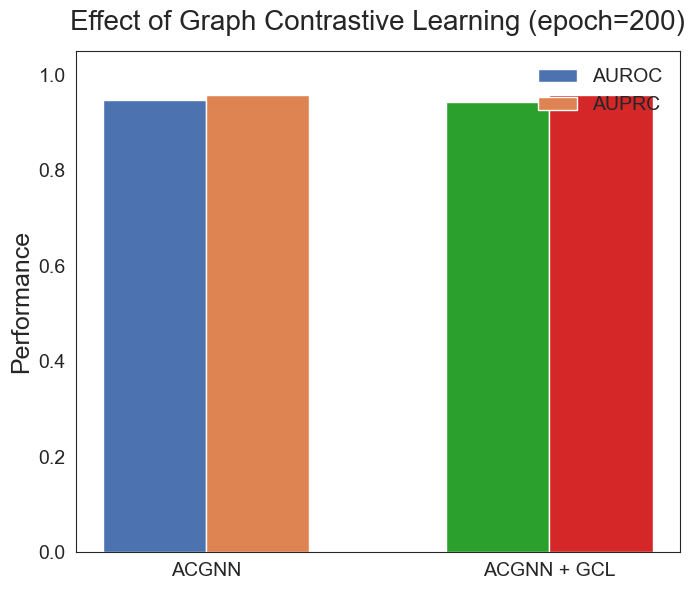

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Linear
from dgl.nn import SAGEConv, GATConv, GraphConv, GINConv, ChebConv
from torch_geometric.utils import dropout_edge, negative_sampling, remove_self_loops, add_self_loops
import math
from torch.nn import Parameter
import dgl
import dgl.function as fn
from dgl.nn.pytorch.conv import ChebConv


class ACGNN(nn.Module):
    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats,
        k=3,
        dropout=0.3,
        epsilon=1e-4
    ):
        super().__init__()

        # 🔹 SAVE ARCHITECTURE METADATA (for logging / CSV)
        self.in_feats = in_feats
        self.hidden_feats = hidden_feats
        self.out_feats = out_feats
        self.k = k
        self.dropout = dropout
        self.epsilon = epsilon

        # Chebyshev Convolution Layers
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.cheb3 = ChebConv(hidden_feats, hidden_feats, k)

        # Fully Connected Layer (MLP)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

        # Batch Normalization
        self.norm = nn.BatchNorm1d(hidden_feats)

        # Dropout
        self.dropout_layer = nn.Dropout(dropout)

    def forward(
        self,
        graph,
        features,
        lambda_max=None,
        return_embeddings=False
    ):
        if lambda_max is None:
            lambda_max = dgl.laplacian_lambda_max(graph)

        x = F.relu(
            self.cheb1(
                graph,
                features,
                lambda_max=lambda_max
            )
        )
        x = self.norm(x)

        prev_x = x.clone()

        for _ in range(1, self.k):

            x_new = F.relu(
                self.cheb2(
                    graph,
                    x,
                    lambda_max=lambda_max
                )
            )

            if torch.norm(x_new - prev_x) < self.epsilon:
                break

            prev_x = x_new.clone()
            x = x_new

        x_res = x

        x = F.relu(
            self.cheb3(
                graph,
                x,
                lambda_max=lambda_max
            )
        )

        x = self.dropout_layer(x) + x_res

        embeddings = x

        logits = self.mlp(embeddings)

        if return_embeddings:
            return logits, embeddings

        return logits
    
    def get_config(self):
        return {
            "in_feats": self.in_feats,
            "hidden_feats": self.hidden_feats,
            "out_feats": self.out_feats,
            # "num_layers": self.num_layers,
        }



# ============================================================
# ABLATION:
# EFFECT OF GRAPH CONTRASTIVE LEARNING (GCL)
# ============================================================

import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupervisedContrastiveLoss(torch.nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):

        device = embeddings.device

        embeddings = F.normalize(
            embeddings,
            p=2,
            dim=1
        )

        similarity = torch.matmul(
            embeddings,
            embeddings.T
        )

        similarity = (
            similarity / self.temperature
        )

        labels = labels.view(-1, 1)

        positive_mask = (
            labels == labels.T
        ).float().to(device)

        diag = torch.eye(
            labels.shape[0],
            device=device
        )

        positive_mask = (
            positive_mask - diag
        )

        exp_sim = torch.exp(similarity)

        denominator = (
            exp_sim * (1 - diag)
        ).sum(
            dim=1,
            keepdim=True
        )

        log_prob = (
            similarity
            -
            torch.log(
                denominator + 1e-8
            )
        )

        mean_log_prob_pos = (
            positive_mask * log_prob
        ).sum(dim=1)

        mean_log_prob_pos = (
            mean_log_prob_pos
            /
            (
                positive_mask.sum(dim=1)
                + 1e-8
            )
        )

        loss = -mean_log_prob_pos.mean()

        return loss


# ============================================================
# TRAIN + EVALUATE
# ============================================================

def run_model(
    use_contrastive=False,
    lambda_cl=0.1
):

    model = ACGNN(
        in_feats=in_feats,
        hidden_feats=hidden_feats,
        out_feats=1,
        k=5,
        epsilon=1e-4
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.learning_rate
    )

    cls_loss_fn = FocalLoss(
        alpha=0.25,
        gamma=2
    )

    cl_loss_fn = (
        SupervisedContrastiveLoss(
            temperature=0.2
        )
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(
        args.num_epochs
    ):

        model.train()

        logits, embeddings = model(
            graph,
            features,
            return_embeddings=True
        )

        logits = logits.squeeze()

        cls_loss = cls_loss_fn(
            logits[train_mask],
            labels[train_mask]
        )

        if use_contrastive:

            cl_loss = cl_loss_fn(
                embeddings[train_mask],
                labels[train_mask]
            )

            loss = (
                cls_loss
                +
                lambda_cl * cl_loss
            )

        else:

            cl_loss = torch.tensor(
                0.0,
                device=device
            )

            loss = cls_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        logits = model(
            graph,
            features
        ).squeeze()

        probs = torch.sigmoid(
            logits
        )

    y_true = labels[
        test_mask
    ].cpu().numpy()

    y_score = probs[
        test_mask
    ].cpu().numpy()

    auc = roc_auc_score(
        y_true,
        y_score
    )

    aupr = average_precision_score(
        y_true,
        y_score
    )

    return auc, aupr


# ============================================================
# RUN ABLATION
# ============================================================

results = []

print("Running baseline ACGNN...")

auc, aupr = run_model(
    use_contrastive=False
)

results.append({

    "Model":
        "ACGNN",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

print("Running ACGNN + GCL...")

auc, aupr = run_model(
    use_contrastive=True,
    lambda_cl=0.1
)

results.append({

    "Model":
        "ACGNN + GCL",

    "AUROC":
        auc,

    "AUPRC":
        aupr
})

# ============================================================
# RESULTS TABLE
# ============================================================

ablation_df = pd.DataFrame(
    results
)

display(
    ablation_df
)

ablation_csv = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.csv"
)

ablation_df.to_csv(
    ablation_csv,
    index=False
)

print(
    f"Saved: {ablation_csv}"
)

# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7,6)
)

x = np.arange(
    len(ablation_df)
)

width = 0.30

ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    f"Effect of Graph Contrastive Learning (epoch={args.num_epochs})",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {plot_path}"
)

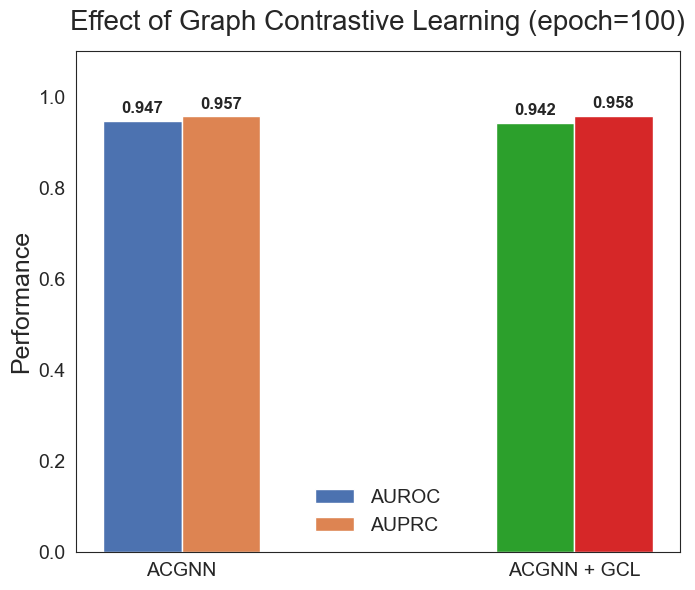

Saved: results/gene_prediction/ACGNN_GCL_ablation.png


In [ ]:
# ============================================================
# BARPLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

x = np.arange(
    len(ablation_df)
)

# smaller bars
width = 0.20

bars1 = ax.bar(
    x - width/2,
    ablation_df["AUROC"],
    width,
    label="AUROC",
    color=["#4C72B0", "#2CA02C"]
)

bars2 = ax.bar(
    x + width/2,
    ablation_df["AUPRC"],
    width,
    label="AUPRC",
    color=["#DD8452", "#D62728"]
)

# ============================================================
# ADD SCORES ON TOP OF BARS
# ============================================================

for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xticks(x)

ax.set_xticklabels(
    ablation_df["Model"],
    fontsize=16
)

ax.set_ylabel(
    "Performance",
    fontsize=18
)

ax.set_ylim(
    0,
    1.10
)

ax.set_title(
    "Effect of Graph Contrastive Learning (epoch=100)",
    fontsize=20,
    pad=15
)

ax.tick_params(
    axis="both",
    labelsize=14
)

ax.legend(
    fontsize=14,
    frameon=False
)

plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "ACGNN_GCL_ablation.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot_path}")